In [6]:
import asyncio
from sipyco.sync_struct import Subscriber

# Create an asyncio Event to wait for updates
dataset_updated = asyncio.Event()


async def connect_subscriber(name, db: dict, port=None, server=None):
    port = 3250 if port is None else port
    server = "137.222.69.28" if server is None else server

    def _create(data):
        db.update(data)
        return db

    def _update(mod):
        # Signal that an update has occurred
        dataset_updated.set()

    subscriber = Subscriber(name, _create, _update, None)
    try:
        await subscriber.connect(
            server,
            port,
        )
    except asyncio.TimeoutError:
        print(f"Failed to connect to Sub: {name} at {server}:{port}")
        return
    print(f"Connected to Sub: {name} at {server}:{port}")
    return subscriber

**DO NOT add extra code to this lower cell.**

Due to jupyter notebook async weirdness it won't actually await the return before running subsequent code

In [7]:
# Run the connection in an asyncio event loop
db = {}
sub = await connect_subscriber("datasets", db)
await dataset_updated.wait()
# await sub.close()
print("Received dataset update!")

Connected to Sub: datasets at 137.222.69.28:3250
Received dataset update!


In [8]:
import numpy as np

# get the RID of the latest dataset
keys = list(db.keys())
# find ones with ndscan.rid_NUM.source_id
rid_keys = [
    key.split(".")[1][4:]
    for key in keys
    if key.startswith("ndscan.rid_") and key.endswith(".source_id")
]
if rid_keys:
    RID = rid_keys[-1]  # Get the last RID in the list
else:
    raise ValueError("No ndscan datasets found.")
print(f"Selected RID: {RID} from {rid_keys}")

print(f"Dataset keys: {list(db.keys())}")


Selected RID: 29533 from ['29533']
Dataset keys: ['benchmark.load_unload.fit', 'benchmark.load_unload.loading_time_constant', 'benchmark.load_unload.sample_interval', 'benchmark.load_unload.time_axis', 'benchmark.load_unload.trace', 'benchmark.load_unload.unloading_time_constant', 'fastino.X1.enabled', 'fastino.X1.output', 'fastino.X2.enabled', 'fastino.X2.output', 'fastino.Y.enabled', 'fastino.Y.output', 'fastino.Z.enabled', 'fastino.Z.output', 'fastino.leds', 'fastino.push_780.enabled', 'fastino.push_780.output', 'fastino.push_852.enabled', 'fastino.push_852.output', 'mirny.repump.almazny_enabled', 'mirny.repump.attenuation', 'mirny.repump.frequency', 'mirny.repump.output_enabled', 'shutter.2DMOT.open', 'shutter.3DMOT.open', 'shutter.IMG.open', 'shutter.LATTICE.open', 'suservo.CDT1.attenuation', 'suservo.CDT1.calib_gain', 'suservo.CDT1.calib_offset', 'suservo.CDT1.frequency', 'suservo.CDT1.gain', 'suservo.CDT1.gl', 'suservo.CDT1.i', 'suservo.CDT1.iir_enabled', 'suservo.CDT1.offset', 

## For Benchmarking

Num points: 66
Failed shots: 100.00%
Mean atom number: 0.61e8 +- 0.05e8
std: 7.63%


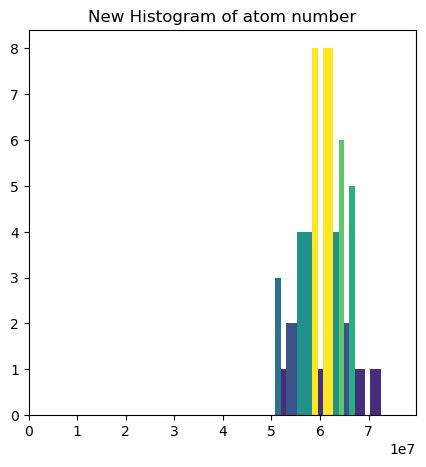

In [9]:
import matplotlib.pyplot as plt
import json
import numpy as np
from matplotlib import colors


axes = json.loads(db[f"ndscan.rid_{RID}.axes"][1])
num_axes = len(axes)

# make histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
N, bins, patches = ax.hist(
    np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1]),
    bins=20,
)

ax.set_xlim(
    0, max(np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])) * 1.1
)
ax.set_title("New Histogram of atom number")

# colour code by height
fracs = N / N.max()
norm = colors.Normalize(fracs.min(), fracs.max())

for thisfrac, thispatch in zip(fracs, patches):
    color = plt.cm.viridis(norm(thisfrac))
    thispatch.set_facecolor(color)

numbers = np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
print(f"Num points: {len(numbers)}")

# count the nummber of failed shots(atom < 30% mean )
# failed_shots = np.sum(numbers < 0.7 * np.mean(numbers))
failed_shots = 0
for i in range(len(numbers)):
    if numbers[i] < 1e8:
        failed_shots += 1
print(f"Failed shots: {failed_shots / len(numbers) * 100:.2f}%")


# atom number and uncertainty
print(
    f"Mean atom number: {np.mean(numbers) / 1e8:.2f}e8 +- {np.std(numbers) / 1e8:.2f}e8"
)
print(f"std: {np.std(numbers) / np.mean(numbers) * 100:.2f}%")

Compare with older dataset

Task was destroyed but it is pending!
task: <Task pending name='Task-6' coro=<Subscriber._receive_cr() running at /home/ae19663/anaconda3/envs/artiq/lib/python3.10/site-packages/sipyco/sync_struct.py:149> wait_for=<Future pending cb=[Task.task_wakeup()]>>


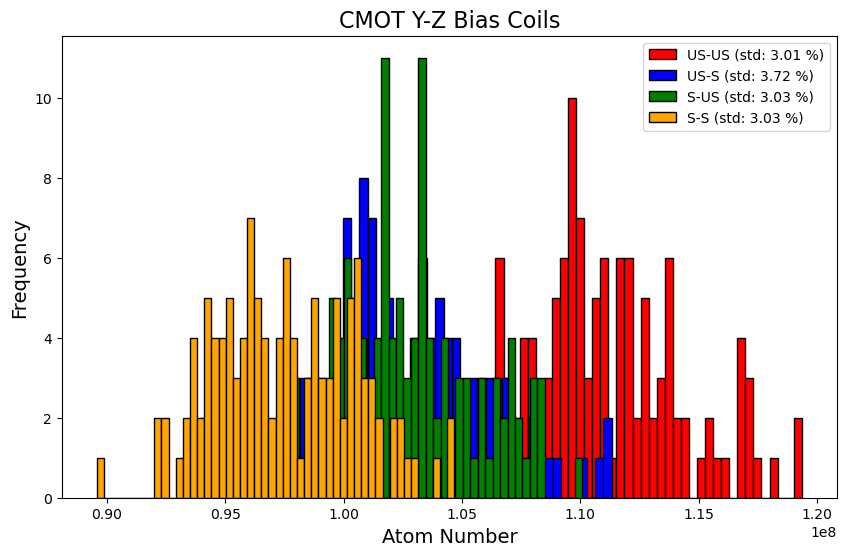

In [10]:
import pandas as pd

# US-US
df_1 = pd.DataFrame([
    {
        "point_index": 0,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 118239557.41251256,
        "custom_objective": 0.8772193603825518,
        "gaussian_fit_centre_x": 365.98241333485714,
        "gaussian_fit_centre_y": 237.99828248201015,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 118239557.41251256,\n            "peak_pixel": (252, 362, 1.8848910312489748),\n            "centroid_pixel": (237, 365, 1.7548944020690163),\n            "best_values_pixel": {\'A\': 1.7298740943653113, \'x0\': 365.98241333485714, \'y0\': 237.99828248201015, \'sx\': 67.81186389821842, \'sy\': 56.648191337210605, \'theta\': 0, \'z0\': 0.0051177765307472796},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1256301877757933.0, 3.635304793433213e-08, 6.035545054399253e-08),\n            "peak_optical_density": 1.8848910312489748,\n            "Peak density (atoms/cm^3)": 1.26e+09,\n            "sigmax": 67.81186389821842,\n            "sigmay": 56.648191337210605,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9268128728788934,\n            "sigmay_mm": 1.6096071987885832,\n        ',
        "peak_od": 1.8848910312489748,
        "phase_space_density": 6.035545054399253e-8,
        "sigmax": 67.81186389821842,
        "sigmax_mm": 1.9268128728788934,
        "sigmay": 56.648191337210605,
        "sigmay_mm": 1.6096071987885832,
    },
    {
        "point_index": 1,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 112729770.24760598,
        "custom_objective": 0.8211495736183971,
        "gaussian_fit_centre_x": 368.41180812698417,
        "gaussian_fit_centre_y": 238.4653718653428,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112729770.24760598,\n            "peak_pixel": (251, 361, 1.8716809261220422),\n            "centroid_pixel": (238, 368, 1.818722798543208),\n            "best_values_pixel": {\'A\': 1.7366060845672484, \'x0\': 368.41180812698417, \'y0\': 238.4653718653428, \'sx\': 64.95726757295128, \'sy\': 56.146992154764284, \'theta\': 0, \'z0\': 0.02756722594394512},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1316998424106772.8, 3.635304793433213e-08, 6.327144348024954e-08),\n            "peak_optical_density": 1.8716809261220422,\n            "Peak density (atoms/cm^3)": 1.32e+09,\n            "sigmax": 64.95726757295128,\n            "sigmay": 56.146992154764284,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8457020962358401,\n            "sigmay_mm": 1.595366076644183,\n        ',
        "peak_od": 1.8716809261220422,
        "phase_space_density": 6.327144348024954e-8,
        "sigmax": 64.95726757295128,
        "sigmax_mm": 1.8457020962358401,
        "sigmay": 56.146992154764284,
        "sigmay_mm": 1.595366076644183,
    },
    {
        "point_index": 2,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 113948699.3204073,
        "custom_objective": 0.7959180309948454,
        "gaussian_fit_centre_x": 368.78469109784703,
        "gaussian_fit_centre_y": 238.91672472986772,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113948699.3204073,\n            "peak_pixel": (252, 362, 1.9238236212360986),\n            "centroid_pixel": (239, 368, 1.8310492853582006),\n            "best_values_pixel": {\'A\': 1.7692575135255093, \'x0\': 368.78469109784703, \'y0\': 238.91672472986772, \'sx\': 64.70489065744583, \'sy\': 55.959464690618844, \'theta\': 0, \'z0\': 0.03239775277343589},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1346140004327141.5, 3.635304793433213e-08, 6.467146781747588e-08),\n            "peak_optical_density": 1.9238236212360986,\n            "Peak density (atoms/cm^3)": 1.35e+09,\n            "sigmax": 64.70489065744583,\n            "sigmay": 55.959464690618844,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8385310340992316,\n            "sigmay_mm": 1.5900376531034868,\n        ',
        "peak_od": 1.9238236212360986,
        "phase_space_density": 6.467146781747588e-8,
        "sigmax": 64.70489065744583,
        "sigmax_mm": 1.8385310340992316,
        "sigmay": 55.959464690618844,
        "sigmay_mm": 1.5900376531034868,
    },
    {
        "point_index": 3,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 107211169.14156103,
        "custom_objective": 0.8462696367485345,
        "gaussian_fit_centre_x": 368.44455517004263,
        "gaussian_fit_centre_y": 237.81978966333654,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107211169.14156103,\n            "peak_pixel": (252, 362, 1.8276411180368277),\n            "centroid_pixel": (238, 368, 1.7668848869520655),\n            "best_values_pixel": {\'A\': 1.670571934191876, \'x0\': 368.44455517004263, \'y0\': 237.81978966333654, \'sx\': 64.41642614801373, \'sy\': 55.913036050212824, \'theta\': 0, \'z0\': -0.06643536886824353},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1278975807637620.2, 3.635304793433213e-08, 6.144475501588722e-08),\n            "peak_optical_density": 1.8276411180368277,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 64.41642614801373,\n            "sigmay": 55.913036050212824,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.830334575571315,\n            "sigmay_mm": 1.5887184252152982,\n        ',
        "peak_od": 1.8276411180368277,
        "phase_space_density": 6.144475501588722e-8,
        "sigmax": 64.41642614801373,
        "sigmax_mm": 1.830334575571315,
        "sigmay": 55.913036050212824,
        "sigmay_mm": 1.5887184252152982,
    },
    {
        "point_index": 4,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 117593907.91027223,
        "custom_objective": 0.8582062877192895,
        "gaussian_fit_centre_x": 367.05387479650125,
        "gaussian_fit_centre_y": 238.17463942366402,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 117593907.91027223,\n            "peak_pixel": (248, 376, 1.8718410013714122),\n            "centroid_pixel": (237, 367, 1.7810535155111946),\n            "best_values_pixel": {\'A\': 1.7414795777514789, \'x0\': 367.05387479650125, \'y0\': 238.17463942366402, \'sx\': 67.04256011584539, \'sy\': 56.60092353838329, \'theta\': 0, \'z0\': 0.02286134471910095},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1279348165318295.2, 3.635304793433213e-08, 6.146264388159581e-08),\n            "peak_optical_density": 1.8718410013714122,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 67.04256011584539,\n            "sigmay": 56.60092353838329,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.90495380064847,\n            "sigmay_mm": 1.6082641269716837,\n        ',
        "peak_od": 1.8718410013714122,
        "phase_space_density": 6.146264388159581e-8,
        "sigmax": 67.04256011584539,
        "sigmax_mm": 1.90495380064847,
        "sigmay": 56.60092353838329,
        "sigmay_mm": 1.6082641269716837,
    },
    {
        "point_index": 5,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 115382501.33336568,
        "custom_objective": 0.8372808008782323,
        "gaussian_fit_centre_x": 367.7214450127241,
        "gaussian_fit_centre_y": 238.20060830071563,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 115382501.33336568,\n            "peak_pixel": (252, 362, 1.8729988975055556),\n            "centroid_pixel": (238, 367, 1.8048887633499175),\n            "best_values_pixel": {\'A\': 1.7431776557349512, \'x0\': 367.7214450127241, \'y0\': 238.20060830071563, \'sx\': 66.0031889387019, \'sy\': 56.35634772533627, \'theta\': 0, \'z0\': 0.03860691810691469},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1300756176430108.5, 3.635304793433213e-08, 6.249113088681324e-08),\n            "peak_optical_density": 1.8729988975055556,\n            "Peak density (atoms/cm^3)": 1.30e+09,\n            "sigmax": 66.0031889387019,\n            "sigmay": 56.35634772533627,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8754210072891067,\n            "sigmay_mm": 1.601314726116383,\n        ',
        "peak_od": 1.8729988975055556,
        "phase_space_density": 6.249113088681324e-8,
        "sigmax": 66.0031889387019,
        "sigmax_mm": 1.8754210072891067,
        "sigmay": 56.35634772533627,
        "sigmay_mm": 1.601314726116383,
    },
    {
        "point_index": 6,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 112393498.73071022,
        "custom_objective": 0.8076950203717728,
        "gaussian_fit_centre_x": 367.7842540583078,
        "gaussian_fit_centre_y": 238.05035830023795,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112393498.73071022,\n            "peak_pixel": (237, 372, 1.8714771435404862),\n            "centroid_pixel": (237, 367, 1.8010035366680743),\n            "best_values_pixel": {\'A\': 1.7438694410080722, \'x0\': 367.7842540583078, \'y0\': 238.05035830023795, \'sx\': 64.63821732004017, \'sy\': 55.9621689934761, \'theta\': 0, \'z0\': -0.00965310156317367},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1330443807569810.2, 3.635304793433213e-08, 6.39173886873813e-08),\n            "peak_optical_density": 1.8714771435404862,\n            "Peak density (atoms/cm^3)": 1.33e+09,\n            "sigmax": 64.63821732004017,\n            "sigmay": 55.9621689934761,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.836636571428454,\n            "sigmay_mm": 1.590114493426964,\n        ',
        "peak_od": 1.8714771435404862,
        "phase_space_density": 6.39173886873813e-8,
        "sigmax": 64.63821732004017,
        "sigmax_mm": 1.836636571428454,
        "sigmay": 55.9621689934761,
        "sigmay_mm": 1.590114493426964,
    },
    {
        "point_index": 7,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 115824127.38271497,
        "custom_objective": 0.843092929337505,
        "gaussian_fit_centre_x": 367.0788732011782,
        "gaussian_fit_centre_y": 237.5828762587404,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 115824127.38271497,\n            "peak_pixel": (251, 362, 1.878715869531093),\n            "centroid_pixel": (236, 367, 1.7226954362771494),\n            "best_values_pixel": {\'A\': 1.739490270510698, \'x0\': 367.0788732011782, \'y0\': 237.5828762587404, \'sx\': 66.1105116830476, \'sy\': 56.53649383980321, \'theta\': 0, \'z0\': -0.007921231007495342},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1297351783369285.0, 3.635304793433213e-08, 6.232757650497824e-08),\n            "peak_optical_density": 1.878715869531093,\n            "Peak density (atoms/cm^3)": 1.30e+09,\n            "sigmax": 66.1105116830476,\n            "sigmay": 56.53649383980321,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8784704861482686,\n            "sigmay_mm": 1.6064334152719413,\n        ',
        "peak_od": 1.878715869531093,
        "phase_space_density": 6.232757650497824e-8,
        "sigmax": 66.1105116830476,
        "sigmax_mm": 1.8784704861482686,
        "sigmay": 56.53649383980321,
        "sigmay_mm": 1.6064334152719413,
    },
    {
        "point_index": 8,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 117011423.9236947,
        "custom_objective": 0.8853019678944171,
        "gaussian_fit_centre_x": 364.2421896814311,
        "gaussian_fit_centre_y": 237.10445093738068,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 117011423.9236947,\n            "peak_pixel": (237, 371, 1.8530122866708372),\n            "centroid_pixel": (236, 364, 1.7060829577308354),\n            "best_values_pixel": {\'A\': 1.711694210744993, \'x0\': 364.2421896814311, \'y0\': 237.10445093738068, \'sx\': 67.7405051082826, \'sy\': 56.641030970023586, \'theta\': 0, \'z0\': -0.06290387745961858},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1246031089585483.8, 3.635304793433213e-08, 5.986201973841546e-08),\n            "peak_optical_density": 1.8530122866708372,\n            "Peak density (atoms/cm^3)": 1.25e+09,\n            "sigmax": 67.7405051082826,\n            "sigmay": 56.641030970023586,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9247852773058272,\n            "sigmay_mm": 1.609403743421375,\n        ',
        "peak_od": 1.8530122866708372,
        "phase_space_density": 5.986201973841546e-8,
        "sigmax": 67.7405051082826,
        "sigmax_mm": 1.9247852773058272,
        "sigmay": 56.641030970023586,
        "sigmay_mm": 1.609403743421375,
    },
    {
        "point_index": 9,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 109550174.61622687,
        "custom_objective": 0.9069401712906097,
        "gaussian_fit_centre_x": 366.3238336827505,
        "gaussian_fit_centre_y": 237.52413563223294,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109550174.61622687,\n            "peak_pixel": (252, 362, 1.784652078665217),\n            "centroid_pixel": (236, 366, 1.6780346754912752),\n            "best_values_pixel": {\'A\': 1.6391666060779766, \'x0\': 366.3238336827505, \'y0\': 237.52413563223294, \'sx\': 66.50326681759385, \'sy\': 56.43229100760665, \'theta\': 0, \'z0\': -0.01963781313046484},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1214865106364636.8, 3.635304793433213e-08, 5.836473871683668e-08),\n            "peak_optical_density": 1.784652078665217,\n            "Peak density (atoms/cm^3)": 1.21e+09,\n            "sigmax": 66.50326681759385,\n            "sigmay": 56.43229100760665,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.88963026860564,\n            "sigmay_mm": 1.6034725858989554,\n        ',
        "peak_od": 1.784652078665217,
        "phase_space_density": 5.836473871683668e-8,
        "sigmax": 66.50326681759385,
        "sigmax_mm": 1.88963026860564,
        "sigmay": 56.43229100760665,
        "sigmay_mm": 1.6034725858989554,
    },
    {
        "point_index": 10,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 110943336.9037688,
        "custom_objective": 0.9235628803246637,
        "gaussian_fit_centre_x": 366.4016874944727,
        "gaussian_fit_centre_y": 237.12456584629743,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110943336.9037688,\n            "peak_pixel": (251, 362, 1.7974386291099465),\n            "centroid_pixel": (236, 366, 1.6446584353540283),\n            "best_values_pixel": {\'A\': 1.636081180302028, \'x0\': 366.4016874944727, \'y0\': 237.12456584629743, \'sx\': 67.20233802272712, \'sy\': 56.66826669106334, \'theta\': 0, \'z0\': -0.030217326755181174},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1199833973098855.0, 3.635304793433213e-08, 5.7642610670620505e-08),\n            "peak_optical_density": 1.7974386291099465,\n            "Peak density (atoms/cm^3)": 1.20e+09,\n            "sigmax": 67.20233802272712,\n            "sigmay": 56.66826669106334,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.909493745579691,\n            "sigmay_mm": 1.6101776218385837,\n        ',
        "peak_od": 1.7974386291099465,
        "phase_space_density": 5.7642610670620505e-8,
        "sigmax": 67.20233802272712,
        "sigmax_mm": 1.909493745579691,
        "sigmay": 56.66826669106334,
        "sigmay_mm": 1.6101776218385837,
    },
    {
        "point_index": 11,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 107809730.28772153,
        "custom_objective": 0.8895206342057607,
        "gaussian_fit_centre_x": 363.11239490980023,
        "gaussian_fit_centre_y": 241.61681776283845,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107809730.28772153,\n            "peak_pixel": (245, 350, 1.7702628060926986),\n            "centroid_pixel": (241, 363, 1.6134282346653848),\n            "best_values_pixel": {\'A\': 1.640113612290667, \'x0\': 363.11239490980023, \'y0\': 241.61681776283845, \'sx\': 67.6203625590139, \'sy\': 54.57993381686954, \'theta\': 0, \'z0\': -0.01780244136055655},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1195634918180152.8, 3.635304793433213e-08, 5.74408790200004e-08),\n            "peak_optical_density": 1.7702628060926986,\n            "Peak density (atoms/cm^3)": 1.20e+09,\n            "sigmax": 67.6203625590139,\n            "sigmay": 54.57993381686954,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9213715352671348,\n            "sigmay_mm": 1.5508395291577468,\n        ',
        "peak_od": 1.7702628060926986,
        "phase_space_density": 5.74408790200004e-8,
        "sigmax": 67.6203625590139,
        "sigmax_mm": 1.9213715352671348,
        "sigmay": 54.57993381686954,
        "sigmay_mm": 1.5508395291577468,
    },
    {
        "point_index": 12,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 110375191.12117217,
        "custom_objective": 0.7412630305057473,
        "gaussian_fit_centre_x": 367.0233115737524,
        "gaussian_fit_centre_y": 242.25328843336808,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110375191.12117217,\n            "peak_pixel": (251, 362, 1.935325449370458),\n            "centroid_pixel": (242, 367, 1.7391228451893976),\n            "best_values_pixel": {\'A\': 1.7865068065378957, \'x0\': 367.0233115737524, \'y0\': 242.25328843336808, \'sx\': 64.07672267344239, \'sy\': 54.11569417830072, \'theta\': 0, \'z0\': -0.023397183656572045},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1374916355743602.5, 3.635304793433213e-08, 6.605394577560197e-08),\n            "peak_optical_density": 1.935325449370458,\n            "Peak density (atoms/cm^3)": 1.37e+09,\n            "sigmax": 64.07672267344239,\n            "sigmay": 54.11569417830072,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8206822081220413,\n            "sigmay_mm": 1.5376485790750642,\n        ',
        "peak_od": 1.935325449370458,
        "phase_space_density": 6.605394577560197e-8,
        "sigmax": 64.07672267344239,
        "sigmax_mm": 1.8206822081220413,
        "sigmay": 54.11569417830072,
        "sigmay_mm": 1.5376485790750642,
    },
    {
        "point_index": 13,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 109682571.96926759,
        "custom_objective": 0.7182098029590173,
        "gaussian_fit_centre_x": 367.11897778539037,
        "gaussian_fit_centre_y": 242.68829819137218,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109682571.96926759,\n            "peak_pixel": (237, 372, 1.93409605701814),\n            "centroid_pixel": (243, 367, 1.7506173969208032),\n            "best_values_pixel": {\'A\': 1.8037067624644223, \'x0\': 367.11897778539037, \'y0\': 242.68829819137218, \'sx\': 63.52343757609826, \'sy\': 53.79187301308887, \'theta\': 0, \'z0\': 0.02959585302224878},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1398561602469937.2, 3.635304793433213e-08, 6.718991440277518e-08),\n            "peak_optical_density": 1.93409605701814,\n            "Peak density (atoms/cm^3)": 1.40e+09,\n            "sigmax": 63.52343757609826,\n            "sigmay": 53.79187301308887,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.804961111743761,\n            "sigmay_mm": 1.5284474931031857,\n        ',
        "peak_od": 1.93409605701814,
        "phase_space_density": 6.718991440277518e-8,
        "sigmax": 63.52343757609826,
        "sigmax_mm": 1.804961111743761,
        "sigmay": 53.79187301308887,
        "sigmay_mm": 1.5284474931031857,
    },
    {
        "point_index": 14,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 116943906.29361746,
        "custom_objective": 0.6903905057377863,
        "gaussian_fit_centre_x": 366.15878974171216,
        "gaussian_fit_centre_y": 242.07591728589048,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 116943906.29361746,\n            "peak_pixel": (252, 362, 2.0349026554125724),\n            "centroid_pixel": (241, 366, 1.8475484586585078),\n            "best_values_pixel": {\'A\': 1.886224168332617, \'x0\': 366.15878974171216, \'y0\': 242.07591728589048, \'sx\': 64.39491524750504, \'sy\': 54.03537680287849, \'theta\': 0, \'z0\': -0.02636291957974536},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1444524411487314.0, 3.635304793433213e-08, 6.939806683462705e-08),\n            "peak_optical_density": 2.0349026554125724,\n            "Peak density (atoms/cm^3)": 1.44e+09,\n            "sigmax": 64.39491524750504,\n            "sigmay": 54.03537680287849,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8297233627595042,\n            "sigmay_mm": 1.5353664333857542,\n        ',
        "peak_od": 2.0349026554125724,
        "phase_space_density": 6.939806683462705e-8,
        "sigmax": 64.39491524750504,
        "sigmax_mm": 1.8297233627595042,
        "sigmay": 54.03537680287849,
        "sigmay_mm": 1.5353664333857542,
    },
    {
        "point_index": 15,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 109859626.00366111,
        "custom_objective": 0.8181918770459823,
        "gaussian_fit_centre_x": 364.54237277678703,
        "gaussian_fit_centre_y": 241.70325234262666,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109859626.00366111,\n            "peak_pixel": (244, 351, 1.8837534777639704),\n            "centroid_pixel": (241, 364, 1.6601658839131754),\n            "best_values_pixel": {\'A\': 1.715847646578144, \'x0\': 364.54237277678703, \'y0\': 241.70325234262666, \'sx\': 66.18585806279022, \'sy\': 54.318345304601216, \'theta\': 0, \'z0\': -0.018412974995015128},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1277879203884707.5, 3.635304793433213e-08, 6.139207180753812e-08),\n            "peak_optical_density": 1.8837534777639704,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 66.18585806279022,\n            "sigmay": 54.318345304601216,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8806113854845676,\n            "sigmay_mm": 1.543406727817964,\n        ',
        "peak_od": 1.8837534777639704,
        "phase_space_density": 6.139207180753812e-8,
        "sigmax": 66.18585806279022,
        "sigmax_mm": 1.8806113854845676,
        "sigmay": 54.318345304601216,
        "sigmay_mm": 1.543406727817964,
    },
    {
        "point_index": 16,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 109936118.53600778,
        "custom_objective": 0.7900551031749831,
        "gaussian_fit_centre_x": 365.0707504502973,
        "gaussian_fit_centre_y": 241.60313390470776,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109936118.53600778,\n            "peak_pixel": (244, 351, 1.9150425253148633),\n            "centroid_pixel": (241, 365, 1.697768993513117),\n            "best_values_pixel": {\'A\': 1.7394515363136929, \'x0\': 365.0707504502973, \'y0\': 241.60313390470776, \'sx\': 65.24927102678326, \'sy\': 54.347227041390745, \'theta\': 0, \'z0\': -0.03408600609308693},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1315044067901646.5, 3.635304793433213e-08, 6.317755199495274e-08),\n            "peak_optical_density": 1.9150425253148633,\n            "Peak density (atoms/cm^3)": 1.32e+09,\n            "sigmax": 65.24927102678326,\n            "sigmay": 54.347227041390745,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8539991106729161,\n            "sigmay_mm": 1.5442273762862126,\n        ',
        "peak_od": 1.9150425253148633,
        "phase_space_density": 6.317755199495274e-8,
        "sigmax": 65.24927102678326,
        "sigmax_mm": 1.8539991106729161,
        "sigmay": 54.347227041390745,
        "sigmay_mm": 1.5442273762862126,
    },
    {
        "point_index": 17,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 111528367.69068888,
        "custom_objective": 0.7509989085189809,
        "gaussian_fit_centre_x": 365.78878062278403,
        "gaussian_fit_centre_y": 242.34413795173657,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111528367.69068888,\n            "peak_pixel": (251, 362, 1.9420978020643118),\n            "centroid_pixel": (243, 366, 1.7325464064843918),\n            "best_values_pixel": {\'A\': 1.7882183455642664, \'x0\': 365.78878062278403, \'y0\': 242.34413795173657, \'sx\': 64.81139319405298, \'sy\': 54.04346986706662, \'theta\': 0, \'z0\': 0.010838362392474146},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1359778066227662.0, 3.635304793433213e-08, 6.532666971212064e-08),\n            "peak_optical_density": 1.9420978020643118,\n            "Peak density (atoms/cm^3)": 1.36e+09,\n            "sigmax": 64.81139319405298,\n            "sigmay": 54.04346986706662,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.841557207496219,\n            "sigmay_mm": 1.5355963904959458,\n        ',
        "peak_od": 1.9420978020643118,
        "phase_space_density": 6.532666971212064e-8,
        "sigmax": 64.81139319405298,
        "sigmax_mm": 1.841557207496219,
        "sigmay": 54.04346986706662,
        "sigmay_mm": 1.5355963904959458,
    },
    {
        "point_index": 18,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 111950914.62934023,
        "custom_objective": 0.7667639773456244,
        "gaussian_fit_centre_x": 364.93913031970163,
        "gaussian_fit_centre_y": 241.49508641327753,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111950914.62934023,\n            "peak_pixel": (251, 362, 1.9139673817622411),\n            "centroid_pixel": (241, 365, 1.7395684145479169),\n            "best_values_pixel": {\'A\': 1.7768318828170544, \'x0\': 364.93913031970163, \'y0\': 241.49508641327753, \'sx\': 65.22597000715596, \'sy\': 54.227368165668956, \'theta\': 0, \'z0\': -0.021755760309744538},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1343063823440546.0, 3.635304793433213e-08, 6.452368145605083e-08),\n            "peak_optical_density": 1.9139673817622411,\n            "Peak density (atoms/cm^3)": 1.34e+09,\n            "sigmax": 65.22597000715596,\n            "sigmay": 54.227368165668956,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8533370332429777,\n            "sigmay_mm": 1.5408216945751751,\n        ',
        "peak_od": 1.9139673817622411,
        "phase_space_density": 6.452368145605083e-8,
        "sigmax": 65.22597000715596,
        "sigmax_mm": 1.8533370332429777,
        "sigmay": 54.227368165668956,
        "sigmay_mm": 1.5408216945751751,
    },
    {
        "point_index": 19,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 109434730.12376867,
        "custom_objective": 0.9017653442849615,
        "gaussian_fit_centre_x": 362.37887145051286,
        "gaussian_fit_centre_y": 241.36681207599688,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109434730.12376867,\n            "peak_pixel": (245, 350, 1.7717212086273861),\n            "centroid_pixel": (240, 362, 1.694657186819479),\n            "best_values_pixel": {\'A\': 1.6420683110312504, \'x0\': 362.37887145051286, \'y0\': 241.36681207599688, \'sx\': 68.18271093735889, \'sy\': 54.871110011588335, \'theta\': 0, \'z0\': -0.02807341249501577},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1187384898338151.0, 3.635304793433213e-08, 5.7044530281391864e-08),\n            "peak_optical_density": 1.7717212086273861,\n            "Peak density (atoms/cm^3)": 1.19e+09,\n            "sigmax": 68.18271093735889,\n            "sigmay": 54.871110011588335,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9373501565901534,\n            "sigmay_mm": 1.559113037774206,\n        ',
        "peak_od": 1.7717212086273861,
        "phase_space_density": 5.7044530281391864e-8,
        "sigmax": 68.18271093735889,
        "sigmax_mm": 1.9373501565901534,
        "sigmay": 54.871110011588335,
        "sigmay_mm": 1.559113037774206,
    },
    {
        "point_index": 20,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 109222500.55587012,
        "custom_objective": 0.8664065949233943,
        "gaussian_fit_centre_x": 363.824500903413,
        "gaussian_fit_centre_y": 242.06842343579038,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109222500.55587012,\n            "peak_pixel": (244, 351, 1.8296889046210192),\n            "centroid_pixel": (242, 363, 1.6658326282207288),\n            "best_values_pixel": {\'A\': 1.6719812307241873, \'x0\': 363.824500903413, \'y0\': 242.06842343579038, \'sx\': 67.19827898381678, \'sy\': 54.6462389920244, \'theta\': 0, \'z0\': 0.0412193232405757},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1225079188413620.0, 3.635304793433213e-08, 5.8855445237995347e-08),\n            "peak_optical_density": 1.8296889046210192,\n            "Peak density (atoms/cm^3)": 1.23e+09,\n            "sigmax": 67.19827898381678,\n            "sigmay": 54.6462389920244,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9093784116547055,\n            "sigmay_mm": 1.552723530830649,\n        ',
        "peak_od": 1.8296889046210192,
        "phase_space_density": 5.8855445237995347e-8,
        "sigmax": 67.19827898381678,
        "sigmax_mm": 1.9093784116547055,
        "sigmay": 54.6462389920244,
        "sigmay_mm": 1.552723530830649,
    },
    {
        "point_index": 21,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 107758663.49631223,
        "custom_objective": 0.8652316731607327,
        "gaussian_fit_centre_x": 363.50429874932166,
        "gaussian_fit_centre_y": 241.28885154542135,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107758663.49631223,\n            "peak_pixel": (237, 351, 1.8128588052460617),\n            "centroid_pixel": (240, 363, 1.6335716522002333),\n            "best_values_pixel": {\'A\': 1.6591383257665253, \'x0\': 363.50429874932166, \'y0\': 241.28885154542135, \'sx\': 66.8376884024432, \'sy\': 54.53959591209112, \'theta\': 0, \'z0\': -0.03811477711272369},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1224125832697428.0, 3.635304793433213e-08, 5.880964397414453e-08),\n            "peak_optical_density": 1.8128588052460617,\n            "Peak density (atoms/cm^3)": 1.22e+09,\n            "sigmax": 66.8376884024432,\n            "sigmay": 54.53959591209112,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8991325559284522,\n            "sigmay_mm": 1.5496933640219723,\n        ',
        "peak_od": 1.8128588052460617,
        "phase_space_density": 5.880964397414453e-8,
        "sigmax": 66.8376884024432,
        "sigmax_mm": 1.8991325559284522,
        "sigmay": 54.53959591209112,
        "sigmay_mm": 1.5496933640219723,
    },
    {
        "point_index": 22,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 113286199.60880512,
        "custom_objective": 0.9104092599351765,
        "gaussian_fit_centre_x": 365.28298032871345,
        "gaussian_fit_centre_y": 237.47647818104596,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113286199.60880512,\n            "peak_pixel": (237, 372, 1.7778907676751103),\n            "centroid_pixel": (236, 365, 1.6356101414787438),\n            "best_values_pixel": {\'A\': 1.6632311420791832, \'x0\': 365.28298032871345, \'y0\': 237.47647818104596, \'sx\': 67.6564422346118, \'sy\': 56.506287518159624, \'theta\': 0, \'z0\': -0.04089661436004126},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1212245401480228.2, 3.635304793433213e-08, 5.8238882446628004e-08),\n            "peak_optical_density": 1.7778907676751103,\n            "Peak density (atoms/cm^3)": 1.21e+09,\n            "sigmax": 67.6564422346118,\n            "sigmay": 56.506287518159624,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9223967066662822,\n            "sigmay_mm": 1.6055751299212755,\n        ',
        "peak_od": 1.7778907676751103,
        "phase_space_density": 5.8238882446628004e-8,
        "sigmax": 67.6564422346118,
        "sigmax_mm": 1.9223967066662822,
        "sigmay": 56.506287518159624,
        "sigmay_mm": 1.6055751299212755,
    },
    {
        "point_index": 23,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 119358659.67117704,
        "custom_objective": 0.7422805730774148,
        "gaussian_fit_centre_x": 368.2573232110274,
        "gaussian_fit_centre_y": 238.8460326074076,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 119358659.67117704,\n            "peak_pixel": (237, 372, 2.01497783305129),\n            "centroid_pixel": (238, 368, 1.9438474878176026),\n            "best_values_pixel": {\'A\': 1.8588311495245247, \'x0\': 368.2573232110274, \'y0\': 238.8460326074076, \'sx\': 64.58784873809458, \'sy\': 55.85793727706752, \'theta\': 0, \'z0\': 0.04530819515785914},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1417738148054437.8, 3.635304793433213e-08, 6.811119699346549e-08),\n            "peak_optical_density": 2.01497783305129,\n            "Peak density (atoms/cm^3)": 1.42e+09,\n            "sigmax": 64.58784873809458,\n            "sigmay": 55.85793727706752,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8352053936595152,\n            "sigmay_mm": 1.5871528433351783,\n        ',
        "peak_od": 2.01497783305129,
        "phase_space_density": 6.811119699346549e-8,
        "sigmax": 64.58784873809458,
        "sigmax_mm": 1.8352053936595152,
        "sigmay": 55.85793727706752,
        "sigmay_mm": 1.5871528433351783,
    },
    {
        "point_index": 24,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 112583869.19286239,
        "custom_objective": 0.8000591701829105,
        "gaussian_fit_centre_x": 368.78852855893996,
        "gaussian_fit_centre_y": 238.9678058415307,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112583869.19286239,\n            "peak_pixel": (236, 372, 1.8891495552311468),\n            "centroid_pixel": (238, 368, 1.8355062354935652),\n            "best_values_pixel": {\'A\': 1.7546254387193676, \'x0\': 368.78852855893996, \'y0\': 238.9678058415307, \'sx\': 64.6388113481931, \'sy\': 55.795597583378566, \'theta\': 0, \'z0\': 0.02796004858217401},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1336651342103397.0, 3.635304793433213e-08, 6.421561202858227e-08),\n            "peak_optical_density": 1.8891495552311468,\n            "Peak density (atoms/cm^3)": 1.34e+09,\n            "sigmax": 64.6388113481931,\n            "sigmay": 55.795597583378566,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8366534502019625,\n            "sigmay_mm": 1.5853815172369679,\n        ',
        "peak_od": 1.8891495552311468,
        "phase_space_density": 6.421561202858227e-8,
        "sigmax": 64.6388113481931,
        "sigmax_mm": 1.8366534502019625,
        "sigmay": 55.795597583378566,
        "sigmay_mm": 1.5853815172369679,
    },
    {
        "point_index": 25,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 109646098.41889934,
        "custom_objective": 0.8391968439007059,
        "gaussian_fit_centre_x": 368.38513839255313,
        "gaussian_fit_centre_y": 238.34272824225488,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109646098.41889934,\n            "peak_pixel": (244, 374, 1.8307188977690123),\n            "centroid_pixel": (237, 368, 1.7533527669625917),\n            "best_values_pixel": {\'A\': 1.6961485918554715, \'x0\': 368.38513839255313, \'y0\': 238.34272824225488, \'sx\': 64.95632314698628, \'sy\': 55.87647560974503, \'theta\': 0, \'z0\': -0.028807935408047332},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1287211570948540.8, 3.635304793433213e-08, 6.184041884000838e-08),\n            "peak_optical_density": 1.8307188977690123,\n            "Peak density (atoms/cm^3)": 1.29e+09,\n            "sigmax": 64.95632314698628,\n            "sigmay": 55.87647560974503,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8456752612249403,\n            "sigmay_mm": 1.5876795933165435,\n        ',
        "peak_od": 1.8307188977690123,
        "phase_space_density": 6.184041884000838e-8,
        "sigmax": 64.95632314698628,
        "sigmax_mm": 1.8456752612249403,
        "sigmay": 55.87647560974503,
        "sigmay_mm": 1.5876795933165435,
    },
    {
        "point_index": 26,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 111575208.31161997,
        "custom_objective": 0.8690311043330159,
        "gaussian_fit_centre_x": 365.7316210493458,
        "gaussian_fit_centre_y": 237.7800233116022,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111575208.31161997,\n            "peak_pixel": (237, 371, 1.805205889667762),\n            "centroid_pixel": (236, 366, 1.6915977919229606),\n            "best_values_pixel": {\'A\': 1.6858690221762473, \'x0\': 365.7316210493458, \'y0\': 237.7800233116022, \'sx\': 66.0935668214142, \'sy\': 56.228557021958494, \'theta\': 0, \'z0\': -0.016150287693457336},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1257248173961463.2, 3.635304793433213e-08, 6.040091265363616e-08),\n            "peak_optical_density": 1.805205889667762,\n            "Peak density (atoms/cm^3)": 1.26e+09,\n            "sigmax": 66.0935668214142,\n            "sigmay": 56.228557021958494,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.877989013207584,\n            "sigmay_mm": 1.5976836686856046,\n        ',
        "peak_od": 1.805205889667762,
        "phase_space_density": 6.040091265363616e-8,
        "sigmax": 66.0935668214142,
        "sigmax_mm": 1.877989013207584,
        "sigmay": 56.228557021958494,
        "sigmay_mm": 1.5976836686856046,
    },
    {
        "point_index": 27,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 116775717.07490134,
        "custom_objective": 0.7920165806104384,
        "gaussian_fit_centre_x": 367.26945150938917,
        "gaussian_fit_centre_y": 238.10225575467547,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 116775717.07490134,\n            "peak_pixel": (245, 351, 1.942420789989186),\n            "centroid_pixel": (237, 367, 1.838931716318604),\n            "best_values_pixel": {\'A\': 1.7912282499523458, \'x0\': 367.26945150938917, \'y0\': 238.10225575467547, \'sx\': 65.2450470604771, \'sy\': 56.070897331201685, \'theta\': 0, \'z0\': -0.02919646572797364},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1354093221723630.0, 3.635304793433213e-08, 6.505355752675504e-08),\n            "peak_optical_density": 1.942420789989186,\n            "Peak density (atoms/cm^3)": 1.35e+09,\n            "sigmax": 65.2450470604771,\n            "sigmay": 56.070897331201685,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.853879090484922,\n            "sigmay_mm": 1.593203910952647,\n        ',
        "peak_od": 1.942420789989186,
        "phase_space_density": 6.505355752675504e-8,
        "sigmax": 65.2450470604771,
        "sigmax_mm": 1.853879090484922,
        "sigmay": 56.070897331201685,
        "sigmay_mm": 1.593203910952647,
    },
    {
        "point_index": 28,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 113744668.7424088,
        "custom_objective": 0.8024486296445846,
        "gaussian_fit_centre_x": 367.76003718500715,
        "gaussian_fit_centre_y": 238.20975808112468,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113744668.7424088,\n            "peak_pixel": (251, 361, 1.9135439587301775),\n            "centroid_pixel": (237, 368, 1.8426824751257602),\n            "best_values_pixel": {\'A\': 1.7594271590800594, \'x0\': 367.76003718500715, \'y0\': 238.20975808112468, \'sx\': 64.88406518644896, \'sy\': 55.93730614139932, \'theta\': 0, \'z0\': -0.024214582452207003},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1336847979340574.2, 3.635304793433213e-08, 6.422505890536696e-08),\n            "peak_optical_density": 1.9135439587301775,\n            "Peak density (atoms/cm^3)": 1.34e+09,\n            "sigmax": 64.88406518644896,\n            "sigmay": 55.93730614139932,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.843622116531259,\n            "sigmay_mm": 1.5894080379384388,\n        ',
        "peak_od": 1.9135439587301775,
        "phase_space_density": 6.422505890536696e-8,
        "sigmax": 64.88406518644896,
        "sigmax_mm": 1.843622116531259,
        "sigmay": 55.93730614139932,
        "sigmay_mm": 1.5894080379384388,
    },
    {
        "point_index": 29,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 111891387.37580855,
        "custom_objective": 0.8505806525733461,
        "gaussian_fit_centre_x": 366.61915431051136,
        "gaussian_fit_centre_y": 238.02010860644629,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111891387.37580855,\n            "peak_pixel": (236, 372, 1.8303228784245944),\n            "centroid_pixel": (237, 366, 1.7523281612347423),\n            "best_values_pixel": {\'A\': 1.7033005005327404, \'x0\': 366.61915431051136, \'y0\': 238.02010860644629, \'sx\': 65.6080269753181, \'sy\': 56.20399187356713, \'theta\': 0, \'z0\': -0.025436663297811513},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1280100793393549.2, 3.635304793433213e-08, 6.149880175684716e-08),\n            "peak_optical_density": 1.8303228784245944,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 65.6080269753181,\n            "sigmay": 56.20399187356713,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.864192836963884,\n            "sigmay_mm": 1.5969856721784492,\n        ',
        "peak_od": 1.8303228784245944,
        "phase_space_density": 6.149880175684716e-8,
        "sigmax": 65.6080269753181,
        "sigmax_mm": 1.864192836963884,
        "sigmay": 56.20399187356713,
        "sigmay_mm": 1.5969856721784492,
    },
    {
        "point_index": 30,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 105738492.08245088,
        "custom_objective": 1.0116212959815043,
        "gaussian_fit_centre_x": 365.6134632893608,
        "gaussian_fit_centre_y": 237.25740105746672,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105738492.08245088,\n            "peak_pixel": (251, 361, 1.6673338052255846),\n            "centroid_pixel": (236, 365, 1.5329679352587342),\n            "best_values_pixel": {\'A\': 1.528329108589317, \'x0\': 365.6134632893608, \'y0\': 237.25740105746672, \'sx\': 68.44367538876918, \'sy\': 56.76472983601113, \'theta\': 0, \'z0\': -0.014052459188745555},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1100567076843183.1, 3.635304793433213e-08, 5.287361497485091e-08),\n            "peak_optical_density": 1.6673338052255846,\n            "Peak density (atoms/cm^3)": 1.10e+09,\n            "sigmax": 68.44367538876918,\n            "sigmay": 56.76472983601113,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9447652258042343,\n            "sigmay_mm": 1.6129185349879813,\n        ',
        "peak_od": 1.6673338052255846,
        "phase_space_density": 5.287361497485091e-8,
        "sigmax": 68.44367538876918,
        "sigmax_mm": 1.9447652258042343,
        "sigmay": 56.76472983601113,
        "sigmay_mm": 1.6129185349879813,
    },
    {
        "point_index": 31,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 113766998.65684284,
        "custom_objective": 0.8789711231354002,
        "gaussian_fit_centre_x": 366.44325988500407,
        "gaussian_fit_centre_y": 237.73624116638732,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113766998.65684284,\n            "peak_pixel": (251, 361, 1.8364381593440628),\n            "centroid_pixel": (236, 366, 1.6945640204030175),\n            "best_values_pixel": {\'A\': 1.6946285744135074, \'x0\': 366.44325988500407, \'y0\': 237.73624116638732, \'sx\': 66.7988239178524, \'sy\': 56.458593781764066, \'theta\': 0, \'z0\': -0.025917761881920586},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1249905665686997.8, 3.635304793433213e-08, 6.004816272714617e-08),\n            "peak_optical_density": 1.8364381593440628,\n            "Peak density (atoms/cm^3)": 1.25e+09,\n            "sigmax": 66.7988239178524,\n            "sigmay": 56.458593781764066,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.898028256696687,\n            "sigmay_mm": 1.6042199554730316,\n        ',
        "peak_od": 1.8364381593440628,
        "phase_space_density": 6.004816272714617e-8,
        "sigmax": 66.7988239178524,
        "sigmax_mm": 1.898028256696687,
        "sigmay": 56.458593781764066,
        "sigmay_mm": 1.6042199554730316,
    },
    {
        "point_index": 32,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 107015703.9630411,
        "custom_objective": 0.9368225858389041,
        "gaussian_fit_centre_x": 365.86465352733035,
        "gaussian_fit_centre_y": 237.85135934972598,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107015703.9630411,\n            "peak_pixel": (251, 361, 1.7279726768970407),\n            "centroid_pixel": (236, 365, 1.5704518217975623),\n            "best_values_pixel": {\'A\': 1.5962859183806979, \'x0\': 365.86465352733035, \'y0\': 237.85135934972598, \'sx\': 66.86699502023184, \'sy\': 56.307333066401945, \'theta\': 0, \'z0\': -0.02973447918970407},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1176488175733715.8, 3.635304793433213e-08, 5.652102823631228e-08),\n            "peak_optical_density": 1.7279726768970407,\n            "Peak density (atoms/cm^3)": 1.18e+09,\n            "sigmax": 66.86699502023184,\n            "sigmay": 56.307333066401945,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8999652770065873,\n            "sigmay_mm": 1.5999220188471035,\n        ',
        "peak_od": 1.7279726768970407,
        "phase_space_density": 5.652102823631228e-8,
        "sigmax": 66.86699502023184,
        "sigmax_mm": 1.8999652770065873,
        "sigmay": 56.307333066401945,
        "sigmay_mm": 1.5999220188471035,
    },
    {
        "point_index": 33,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 115121466.40549032,
        "custom_objective": 0.8973547589920146,
        "gaussian_fit_centre_x": 365.41048613603624,
        "gaussian_fit_centre_y": 237.88084434537754,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 115121466.40549032,\n            "peak_pixel": (236, 371, 1.8225431959656322),\n            "centroid_pixel": (236, 365, 1.6675939764982144),\n            "best_values_pixel": {\'A\': 1.6884309903529906, \'x0\': 365.41048613603624, \'y0\': 237.88084434537754, \'sx\': 67.82715899153274, \'sy\': 56.44912421357134, \'theta\': 0, \'z0\': -0.049184876001097964},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1226931951813866.0, 3.635304793433213e-08, 5.894445598593185e-08),\n            "peak_optical_density": 1.8225431959656322,\n            "Peak density (atoms/cm^3)": 1.23e+09,\n            "sigmax": 67.82715899153274,\n            "sigmay": 56.44912421357134,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9272474691426702,\n            "sigmay_mm": 1.603950886244648,\n        ',
        "peak_od": 1.8225431959656322,
        "phase_space_density": 5.894445598593185e-8,
        "sigmax": 67.82715899153274,
        "sigmax_mm": 1.9272474691426702,
        "sigmay": 56.44912421357134,
        "sigmay_mm": 1.603950886244648,
    },
    {
        "point_index": 34,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 110988858.32051946,
        "custom_objective": 0.800912679145562,
        "gaussian_fit_centre_x": 368.3786135170517,
        "gaussian_fit_centre_y": 239.4604211296991,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110988858.32051946,\n            "peak_pixel": (251, 362, 1.9061401654938932),\n            "centroid_pixel": (240, 368, 1.754134943511131),\n            "best_values_pixel": {\'A\': 1.7414436074907516, \'x0\': 368.3786135170517, \'y0\': 239.4604211296991, \'sx\': 64.54135274367628, \'sy\': 55.506286796421136, \'theta\': 0, \'z0\': 0.04489851842930528},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1328586106425826.5, 3.635304793433213e-08, 6.382814071959084e-08),\n            "peak_optical_density": 1.9061401654938932,\n            "Peak density (atoms/cm^3)": 1.33e+09,\n            "sigmax": 64.54135274367628,\n            "sigmay": 55.506286796421136,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8338842519678942,\n            "sigmay_mm": 1.5771610124974285,\n        ',
        "peak_od": 1.9061401654938932,
        "phase_space_density": 6.382814071959084e-8,
        "sigmax": 64.54135274367628,
        "sigmax_mm": 1.8338842519678942,
        "sigmay": 55.506286796421136,
        "sigmay_mm": 1.5771610124974285,
    },
    {
        "point_index": 35,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 113579697.0322652,
        "custom_objective": 0.7618207557062597,
        "gaussian_fit_centre_x": 368.65901244311885,
        "gaussian_fit_centre_y": 239.25359013290625,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113579697.0322652,\n            "peak_pixel": (251, 361, 1.9771328756669138),\n            "centroid_pixel": (238, 368, 1.8916927052025856),\n            "best_values_pixel": {\'A\': 1.795181701635413, \'x0\': 368.65901244311885, \'y0\': 239.25359013290625, \'sx\': 63.990677826701905, \'sy\': 55.53739256068125, \'theta\': 0, \'z0\': 0.017029622747009834},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1382325832133942.0, 3.635304793433213e-08, 6.640991299474846e-08),\n            "peak_optical_density": 1.9771328756669138,\n            "Peak density (atoms/cm^3)": 1.38e+09,\n            "sigmax": 63.990677826701905,\n            "sigmay": 55.53739256068125,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.818237321507609,\n            "sigmay_mm": 1.578044854697771,\n        ',
        "peak_od": 1.9771328756669138,
        "phase_space_density": 6.640991299474846e-8,
        "sigmax": 63.990677826701905,
        "sigmax_mm": 1.818237321507609,
        "sigmay": 55.53739256068125,
        "sigmay_mm": 1.578044854697771,
    },
    {
        "point_index": 36,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 109002733.33068682,
        "custom_objective": 0.8120195761060933,
        "gaussian_fit_centre_x": 368.8496249149674,
        "gaussian_fit_centre_y": 238.92872124821469,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109002733.33068682,\n            "peak_pixel": (251, 361, 1.8837813426575316),\n            "centroid_pixel": (238, 368, 1.8155841324706534),\n            "best_values_pixel": {\'A\': 1.7141135290554566, \'x0\': 368.8496249149674, \'y0\': 238.92872124821469, \'sx\': 64.3475736709869, \'sy\': 55.480312342021506, \'theta\': 0, \'z0\': -0.03139776215195439},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1313296432577858.2, 3.635304793433213e-08, 6.309359182644446e-08),\n            "peak_optical_density": 1.8837813426575316,\n            "Peak density (atoms/cm^3)": 1.31e+09,\n            "sigmax": 64.3475736709869,\n            "sigmay": 55.480312342021506,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8283781946161475,\n            "sigmay_mm": 1.5764229718327696,\n        ',
        "peak_od": 1.8837813426575316,
        "phase_space_density": 6.309359182644446e-8,
        "sigmax": 64.3475736709869,
        "sigmax_mm": 1.8283781946161475,
        "sigmay": 55.480312342021506,
        "sigmay_mm": 1.5764229718327696,
    },
    {
        "point_index": 37,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 104261246.77765614,
        "custom_objective": 0.9333223458712716,
        "gaussian_fit_centre_x": 366.5579597699017,
        "gaussian_fit_centre_y": 237.699648460723,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104261246.77765614,\n            "peak_pixel": (251, 361, 1.6936852784351304),\n            "centroid_pixel": (238, 366, 1.598104348214223),\n            "best_values_pixel": {\'A\': 1.577287840487742, \'x0\': 366.5579597699017, \'y0\': 237.699648460723, \'sx\': 66.04556190632069, \'sy\': 56.17081927855833, \'theta\': 0, \'z0\': -0.05573654090063784},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1177751054972839.2, 3.635304793433213e-08, 5.6581699677475755e-08),\n            "peak_optical_density": 1.6936852784351304,\n            "Peak density (atoms/cm^3)": 1.18e+09,\n            "sigmax": 66.04556190632069,\n            "sigmay": 56.17081927855833,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.876624996897658,\n            "sigmay_mm": 1.5960431028489037,\n        ',
        "peak_od": 1.6936852784351304,
        "phase_space_density": 5.6581699677475755e-8,
        "sigmax": 66.04556190632069,
        "sigmax_mm": 1.876624996897658,
        "sigmay": 56.17081927855833,
        "sigmay_mm": 1.5960431028489037,
    },
    {
        "point_index": 38,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 114252572.13953556,
        "custom_objective": 0.815097268863432,
        "gaussian_fit_centre_x": 367.0735770523101,
        "gaussian_fit_centre_y": 239.0184340512825,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 114252572.13953556,\n            "peak_pixel": (251, 361, 1.8808274090617432),\n            "centroid_pixel": (238, 367, 1.8118379683111212),\n            "best_values_pixel": {\'A\': 1.753652465572584, \'x0\': 367.0735770523101, \'y0\': 239.0184340512825, \'sx\': 65.42812879806816, \'sy\': 55.94859496103008, \'theta\': 0, \'z0\': 0.0003492817509572824},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1320311562921442.2, 3.635304793433213e-08, 6.343061381137333e-08),\n            "peak_optical_density": 1.8808274090617432,\n            "Peak density (atoms/cm^3)": 1.32e+09,\n            "sigmax": 65.42812879806816,\n            "sigmay": 55.94859496103008,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8590811927204387,\n            "sigmay_mm": 1.5897287995534977,\n        ',
        "peak_od": 1.8808274090617432,
        "phase_space_density": 6.343061381137333e-8,
        "sigmax": 65.42812879806816,
        "sigmax_mm": 1.8590811927204387,
        "sigmay": 55.94859496103008,
        "sigmay_mm": 1.5897287995534977,
    },
    {
        "point_index": 39,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 112637598.85888006,
        "custom_objective": 0.8068667669679181,
        "gaussian_fit_centre_x": 367.4306744465989,
        "gaussian_fit_centre_y": 238.5356913442766,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112637598.85888006,\n            "peak_pixel": (252, 361, 1.8822211705453742),\n            "centroid_pixel": (237, 367, 1.80717060267751),\n            "best_values_pixel": {\'A\': 1.7469373741086927, \'x0\': 367.4306744465989, \'y0\': 238.5356913442766, \'sx\': 65.02322963956314, \'sy\': 55.66812784626704, \'theta\': 0, \'z0\': -0.033304469927389536},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1324549886283640.5, 3.635304793433213e-08, 6.363423200267392e-08),\n            "peak_optical_density": 1.8822211705453742,\n            "Peak density (atoms/cm^3)": 1.32e+09,\n            "sigmax": 65.02322963956314,\n            "sigmay": 55.66812784626704,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.847576348789349,\n            "sigmay_mm": 1.581759579772786,\n        ',
        "peak_od": 1.8822211705453742,
        "phase_space_density": 6.363423200267392e-8,
        "sigmax": 65.02322963956314,
        "sigmax_mm": 1.847576348789349,
        "sigmay": 55.66812784626704,
        "sigmay_mm": 1.581759579772786,
    },
    {
        "point_index": 40,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 113400821.54222243,
        "custom_objective": 0.8402201262074473,
        "gaussian_fit_centre_x": 367.46894532507184,
        "gaussian_fit_centre_y": 238.17339851841976,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113400821.54222243,\n            "peak_pixel": (251, 361, 1.8631498380202978),\n            "centroid_pixel": (237, 367, 1.7654219599624126),\n            "best_values_pixel": {\'A\': 1.7244929573112582, \'x0\': 367.46894532507184, \'y0\': 238.17339851841976, \'sx\': 65.84867619675106, \'sy\': 56.08375747568217, \'theta\': 0, \'z0\': -0.021065593573761227},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1290665277494976.5, 3.635304793433213e-08, 6.200634234800223e-08),\n            "peak_optical_density": 1.8631498380202978,\n            "Peak density (atoms/cm^3)": 1.29e+09,\n            "sigmax": 65.84867619675106,\n            "sigmay": 56.08375747568217,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8710306672645123,\n            "sigmay_mm": 1.593569320344273,\n        ',
        "peak_od": 1.8631498380202978,
        "phase_space_density": 6.200634234800223e-8,
        "sigmax": 65.84867619675106,
        "sigmax_mm": 1.8710306672645123,
        "sigmay": 56.08375747568217,
        "sigmay_mm": 1.593569320344273,
    },
    {
        "point_index": 41,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 107516443.96030848,
        "custom_objective": 0.9658005934938093,
        "gaussian_fit_centre_x": 364.9657861579969,
        "gaussian_fit_centre_y": 237.58138125636782,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107516443.96030848,\n            "peak_pixel": (245, 350, 1.6880471900753053),\n            "centroid_pixel": (236, 364, 1.560225285600389),\n            "best_values_pixel": {\'A\': 1.5768487095863666, \'x0\': 364.9657861579969, \'y0\': 237.58138125636782, \'sx\': 67.7940640812145, \'sy\': 56.47955666219394, \'theta\': 0, \'z0\': -0.02175999914414112},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1146380787357467.2, 3.635304793433213e-08, 5.5074604393187554e-08),\n            "peak_optical_density": 1.6880471900753053,\n            "Peak density (atoms/cm^3)": 1.15e+09,\n            "sigmax": 67.7940640812145,\n            "sigmay": 56.47955666219394,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9263071071534514,\n            "sigmay_mm": 1.604815596789211,\n        ',
        "peak_od": 1.6880471900753053,
        "phase_space_density": 5.5074604393187554e-8,
        "sigmax": 67.7940640812145,
        "sigmax_mm": 1.9263071071534514,
        "sigmay": 56.47955666219394,
        "sigmay_mm": 1.604815596789211,
    },
    {
        "point_index": 42,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 109278116.93257494,
        "custom_objective": 0.9174704203349503,
        "gaussian_fit_centre_x": 365.9548713108231,
        "gaussian_fit_centre_y": 237.97765218251877,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109278116.93257494,\n            "peak_pixel": (252, 362, 1.7536904022762643),\n            "centroid_pixel": (237, 365, 1.6294443423992),\n            "best_values_pixel": {\'A\': 1.628536744607119, \'x0\': 365.9548713108231, \'y0\': 237.97765218251877, \'sx\': 66.92702386539963, \'sy\': 56.30096349716577, \'theta\': 0, \'z0\': -0.02005724257027128},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1199341812071726.5, 3.635304793433213e-08, 5.761896619387615e-08),\n            "peak_optical_density": 1.7536904022762643,\n            "Peak density (atoms/cm^3)": 1.20e+09,\n            "sigmax": 66.92702386539963,\n            "sigmay": 56.30096349716577,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9016709424309586,\n            "sigmay_mm": 1.599741033289512,\n        ',
        "peak_od": 1.7536904022762643,
        "phase_space_density": 5.761896619387615e-8,
        "sigmax": 66.92702386539963,
        "sigmax_mm": 1.9016709424309586,
        "sigmay": 56.30096349716577,
        "sigmay_mm": 1.599741033289512,
    },
    {
        "point_index": 43,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 110025100.88208762,
        "custom_objective": 0.9170548701127431,
        "gaussian_fit_centre_x": 365.7439553468655,
        "gaussian_fit_centre_y": 238.37092789769295,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110025100.88208762,\n            "peak_pixel": (251, 361, 1.8052482398404175),\n            "centroid_pixel": (238, 365, 1.6215311259569825),\n            "best_values_pixel": {\'A\': 1.635666994165354, \'x0\': 365.7439553468655, \'y0\': 238.37092789769295, \'sx\': 67.29747331862919, \'sy\': 56.170414933920995, \'theta\': 0, \'z0\': 0.023425678555062744},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1197058157687798.5, 3.635304793433213e-08, 5.750925451416847e-08),\n            "peak_optical_density": 1.8052482398404175,\n            "Peak density (atoms/cm^3)": 1.20e+09,\n            "sigmax": 67.29747331862919,\n            "sigmay": 56.170414933920995,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9121969290976133,\n            "sigmay_mm": 1.5960316137611912,\n        ',
        "peak_od": 1.8052482398404175,
        "phase_space_density": 5.750925451416847e-8,
        "sigmax": 67.29747331862919,
        "sigmax_mm": 1.9121969290976133,
        "sigmay": 56.170414933920995,
        "sigmay_mm": 1.5960316137611912,
    },
    {
        "point_index": 44,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 111697029.70870587,
        "custom_objective": 0.8812072542585418,
        "gaussian_fit_centre_x": 361.8243574574643,
        "gaussian_fit_centre_y": 242.5137556417574,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111697029.70870587,\n            "peak_pixel": (252, 362, 1.8553978480521254),\n            "centroid_pixel": (243, 361, 1.7322264468087027),\n            "best_values_pixel": {\'A\': 1.6779814789613987, \'x0\': 361.8243574574643, \'y0\': 242.5137556417574, \'sx\': 68.56918598961416, \'sy\': 54.559214711467554, \'theta\': 0, \'z0\': 0.037722249104356016},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1205158452492583.5, 3.635304793433213e-08, 5.789841013921177e-08),\n            "peak_optical_density": 1.8553978480521254,\n            "Peak density (atoms/cm^3)": 1.21e+09,\n            "sigmax": 68.56918598961416,\n            "sigmay": 54.559214711467554,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9483314961806664,\n            "sigmay_mm": 1.5502508144888356,\n        ',
        "peak_od": 1.8553978480521254,
        "phase_space_density": 5.789841013921177e-8,
        "sigmax": 68.56918598961416,
        "sigmax_mm": 1.9483314961806664,
        "sigmay": 54.559214711467554,
        "sigmay_mm": 1.5502508144888356,
    },
    {
        "point_index": 45,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 108905539.9062722,
        "custom_objective": 0.7443816975106509,
        "gaussian_fit_centre_x": 366.20061708327154,
        "gaussian_fit_centre_y": 243.25097635105757,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108905539.9062722,\n            "peak_pixel": (252, 361, 1.9541726126206957),\n            "centroid_pixel": (243, 366, 1.7218557702052506),\n            "best_values_pixel": {\'A\': 1.7728529017475887, \'x0\': 366.20061708327154, \'y0\': 243.25097635105757, \'sx\': 64.37889752855229, \'sy\': 53.585396827240835, \'theta\': 0, \'z0\': -0.014307249218652054},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1357203827787333.5, 3.635304793433213e-08, 6.520299774790216e-08),\n            "peak_optical_density": 1.9541726126206957,\n            "Peak density (atoms/cm^3)": 1.36e+09,\n            "sigmax": 64.37889752855229,\n            "sigmay": 53.585396827240835,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8292682337408028,\n            "sigmay_mm": 1.5225806587475919,\n        ',
        "peak_od": 1.9541726126206957,
        "phase_space_density": 6.520299774790216e-8,
        "sigmax": 64.37889752855229,
        "sigmax_mm": 1.8292682337408028,
        "sigmay": 53.585396827240835,
        "sigmay_mm": 1.5225806587475919,
    },
    {
        "point_index": 46,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 102332668.46406305,
        "custom_objective": 0.784010020615039,
        "gaussian_fit_centre_x": 367.1823920464632,
        "gaussian_fit_centre_y": 242.71826978464097,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102332668.46406305,\n            "peak_pixel": (251, 361, 1.8482509888695493),\n            "centroid_pixel": (242, 367, 1.6426510975645503),\n            "best_values_pixel": {\'A\': 1.6842878439203537, \'x0\': 367.1823920464632, \'y0\': 242.71826978464097, \'sx\': 63.648673787318664, \'sy\': 53.59052009864346, \'theta\': 0, \'z0\': -0.01613204480743527},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1304596576337198.8, 3.635304793433213e-08, 6.267563197748676e-08),\n            "peak_optical_density": 1.8482509888695493,\n            "Peak density (atoms/cm^3)": 1.30e+09,\n            "sigmax": 63.648673787318664,\n            "sigmay": 53.59052009864346,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8085195855868077,\n            "sigmay_mm": 1.5227262318777546,\n        ',
        "peak_od": 1.8482509888695493,
        "phase_space_density": 6.267563197748676e-8,
        "sigmax": 63.648673787318664,
        "sigmax_mm": 1.8085195855868077,
        "sigmay": 53.59052009864346,
        "sigmay_mm": 1.5227262318777546,
    },
    {
        "point_index": 47,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 106771990.0982376,
        "custom_objective": 0.7623928092801593,
        "gaussian_fit_centre_x": 366.5074144521226,
        "gaussian_fit_centre_y": 242.51434294921648,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106771990.0982376,\n            "peak_pixel": (252, 362, 1.8735050786323855),\n            "centroid_pixel": (242, 366, 1.6734969482631905),\n            "best_values_pixel": {\'A\': 1.7386052720392136, \'x0\': 366.5074144521226, \'y0\': 242.51434294921648, \'sx\': 64.28922897131018, \'sy\': 53.612556262100014, \'theta\': 0, \'z0\': -0.009940313459697614},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1333653512595901.0, 3.635304793433213e-08, 6.407158983631913e-08),\n            "peak_optical_density": 1.8735050786323855,\n            "Peak density (atoms/cm^3)": 1.33e+09,\n            "sigmax": 64.28922897131018,\n            "sigmay": 53.612556262100014,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8267203826649807,\n            "sigmay_mm": 1.5233523695618727,\n        ',
        "peak_od": 1.8735050786323855,
        "phase_space_density": 6.407158983631913e-8,
        "sigmax": 64.28922897131018,
        "sigmax_mm": 1.8267203826649807,
        "sigmay": 53.612556262100014,
        "sigmay_mm": 1.5233523695618727,
    },
    {
        "point_index": 48,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 108648320.76108275,
        "custom_objective": 0.8165791497657762,
        "gaussian_fit_centre_x": 363.8093920281155,
        "gaussian_fit_centre_y": 242.3112760162011,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108648320.76108275,\n            "peak_pixel": (251, 361, 1.8536349492626416),\n            "centroid_pixel": (242, 364, 1.638308948121608),\n            "best_values_pixel": {\'A\': 1.708265940738271, \'x0\': 363.8093920281155, \'y0\': 242.3112760162011, \'sx\': 66.21496527910548, \'sy\': 53.950792848154215, \'theta\': 0, \'z0\': -0.016040817468859103},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1271280837743539.2, 3.635304793433213e-08, 6.107507207335388e-08),\n            "peak_optical_density": 1.8536349492626416,\n            "Peak density (atoms/cm^3)": 1.27e+09,\n            "sigmax": 66.21496527910548,\n            "sigmay": 53.950792848154215,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8814384407499134,\n            "sigmay_mm": 1.532963056698655,\n        ',
        "peak_od": 1.8536349492626416,
        "phase_space_density": 6.107507207335388e-8,
        "sigmax": 66.21496527910548,
        "sigmax_mm": 1.8814384407499134,
        "sigmay": 53.950792848154215,
        "sigmay_mm": 1.532963056698655,
    },
    {
        "point_index": 49,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 114417077.73691715,
        "custom_objective": 0.7507988736785605,
        "gaussian_fit_centre_x": 365.539492843779,
        "gaussian_fit_centre_y": 243.01825345942342,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 114417077.73691715,\n            "peak_pixel": (252, 362, 1.9744654247392976),\n            "centroid_pixel": (243, 365, 1.7481675149056157),\n            "best_values_pixel": {\'A\': 1.8120242707378325, \'x0\': 365.539492843779, \'y0\': 243.01825345942342, \'sx\': 65.71651263513687, \'sy\': 53.97956610998512, \'theta\': 0, \'z0\': 0.061600168850582435},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1358441903773742.2, 3.635304793433213e-08, 6.526247758733434e-08),\n            "peak_optical_density": 1.9744654247392976,\n            "Peak density (atoms/cm^3)": 1.36e+09,\n            "sigmax": 65.71651263513687,\n            "sigmay": 53.97956610998512,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8672753590160032,\n            "sigmay_mm": 1.5337806229489162,\n        ',
        "peak_od": 1.9744654247392976,
        "phase_space_density": 6.526247758733434e-8,
        "sigmax": 65.71651263513687,
        "sigmax_mm": 1.8672753590160032,
        "sigmay": 53.97956610998512,
        "sigmay_mm": 1.5337806229489162,
    },
    {
        "point_index": 50,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 111289137.06393354,
        "custom_objective": 0.7783881545849085,
        "gaussian_fit_centre_x": 365.94454174756817,
        "gaussian_fit_centre_y": 243.26987399370188,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111289137.06393354,\n            "peak_pixel": (252, 362, 1.9503971945109735),\n            "centroid_pixel": (244, 365, 1.7203132533707484),\n            "best_values_pixel": {\'A\': 1.7630827018203368, \'x0\': 365.94454174756817, \'y0\': 243.26987399370188, \'sx\': 65.71978019597819, \'sy\': 53.97338967710114, \'theta\': 0, \'z0\': 0.02698823537057344},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1321324542600584.5, 3.635304793433213e-08, 6.347927953894164e-08),\n            "peak_optical_density": 1.9503971945109735,\n            "Peak density (atoms/cm^3)": 1.32e+09,\n            "sigmax": 65.71978019597819,\n            "sigmay": 53.97338967710114,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8673682038064285,\n            "sigmay_mm": 1.5336051251863538,\n        ',
        "peak_od": 1.9503971945109735,
        "phase_space_density": 6.347927953894164e-8,
        "sigmax": 65.71978019597819,
        "sigmax_mm": 1.8673682038064285,
        "sigmay": 53.97338967710114,
        "sigmay_mm": 1.5336051251863538,
    },
    {
        "point_index": 51,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 115488048.82036828,
        "custom_objective": 0.7294959870724644,
        "gaussian_fit_centre_x": 364.74840400389047,
        "gaussian_fit_centre_y": 242.3683623637934,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 115488048.82036828,\n            "peak_pixel": (251, 361, 1.9789705716311967),\n            "centroid_pixel": (242, 365, 1.7419635417651278),\n            "best_values_pixel": {\'A\': 1.838035852265475, \'x0\': 364.74840400389047, \'y0\': 242.3683623637934, \'sx\': 65.43367130703905, \'sy\': 53.88896508397737, \'theta\': 0, \'z0\': -0.007754436800005994},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1385361932416410.5, 3.635304793433213e-08, 6.655577379754545e-08),\n            "peak_optical_density": 1.9789705716311967,\n            "Peak density (atoms/cm^3)": 1.39e+09,\n            "sigmax": 65.43367130703905,\n            "sigmay": 53.88896508397737,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.859238678107497,\n            "sigmay_mm": 1.5312062766152157,\n        ',
        "peak_od": 1.9789705716311967,
        "phase_space_density": 6.655577379754545e-8,
        "sigmax": 65.43367130703905,
        "sigmax_mm": 1.859238678107497,
        "sigmay": 53.88896508397737,
        "sigmay_mm": 1.5312062766152157,
    },
    {
        "point_index": 52,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 116840558.35689373,
        "custom_objective": 0.8172508582241391,
        "gaussian_fit_centre_x": 362.2539331365004,
        "gaussian_fit_centre_y": 241.98202741449293,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 116840558.35689373,\n            "peak_pixel": (245, 351, 1.901412709698822),\n            "centroid_pixel": (241, 362, 1.7566525771009363),\n            "best_values_pixel": {\'A\': 1.769567185685148, \'x0\': 362.2539331365004, \'y0\': 241.98202741449293, \'sx\': 68.05768613384176, \'sy\': 54.45126450736348, \'theta\': 0, \'z0\': -0.010109593758230988},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1282212244654738.5, 3.635304793433213e-08, 6.160024042730286e-08),\n            "peak_optical_density": 1.901412709698822,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 68.05768613384176,\n            "sigmay": 54.45126450736348,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.933797689706076,\n            "sigmay_mm": 1.5471835069272883,\n        ',
        "peak_od": 1.901412709698822,
        "phase_space_density": 6.160024042730286e-8,
        "sigmax": 68.05768613384176,
        "sigmax_mm": 1.933797689706076,
        "sigmay": 54.45126450736348,
        "sigmay_mm": 1.5471835069272883,
    },
    {
        "point_index": 53,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 109539650.42842978,
        "custom_objective": 0.8040676297761363,
        "gaussian_fit_centre_x": 363.9634474144666,
        "gaussian_fit_centre_y": 242.04495462927284,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109539650.42842978,\n            "peak_pixel": (251, 361, 1.8664136502763908),\n            "centroid_pixel": (243, 363, 1.7012414150340964),\n            "best_values_pixel": {\'A\': 1.723912621242958, \'x0\': 363.9634474144666, \'y0\': 242.04495462927284, \'sx\': 66.05538027594687, \'sy\': 53.96387330558509, \'theta\': 0, \'z0\': -0.06935824962723179},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1287598516279503.8, 3.635304793433213e-08, 6.185900852788487e-08),\n            "peak_optical_density": 1.8664136502763908,\n            "Peak density (atoms/cm^3)": 1.29e+09,\n            "sigmax": 66.05538027594687,\n            "sigmay": 53.96387330558509,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8769039770037765,\n            "sigmay_mm": 1.5333347260838053,\n        ',
        "peak_od": 1.8664136502763908,
        "phase_space_density": 6.185900852788487e-8,
        "sigmax": 66.05538027594687,
        "sigmax_mm": 1.8769039770037765,
        "sigmay": 53.96387330558509,
        "sigmay_mm": 1.5333347260838053,
    },
    {
        "point_index": 54,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 112050877.69841509,
        "custom_objective": 0.7971580770592473,
        "gaussian_fit_centre_x": 363.6707808068887,
        "gaussian_fit_centre_y": 241.7166887389137,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112050877.69841509,\n            "peak_pixel": (244, 350, 1.8870745467008017),\n            "centroid_pixel": (243, 363, 1.7588061951295355),\n            "best_values_pixel": {\'A\': 1.7486546113769093, \'x0\': 363.6707808068887, \'y0\': 241.7166887389137, \'sx\': 66.53091720917273, \'sy\': 54.00194050990173, \'theta\': 0, \'z0\': -0.061950559787111205},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1297440648851532.2, 3.635304793433213e-08, 6.233184579432166e-08),\n            "peak_optical_density": 1.8870745467008017,\n            "Peak density (atoms/cm^3)": 1.30e+09,\n            "sigmax": 66.53091720917273,\n            "sigmay": 54.00194050990173,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.890415929511736,\n            "sigmay_mm": 1.5344163713165908,\n        ',
        "peak_od": 1.8870745467008017,
        "phase_space_density": 6.233184579432166e-8,
        "sigmax": 66.53091720917273,
        "sigmax_mm": 1.890415929511736,
        "sigmay": 54.00194050990173,
        "sigmay_mm": 1.5344163713165908,
    },
    {
        "point_index": 55,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 110400003.5056578,
        "custom_objective": 0.9269240525064674,
        "gaussian_fit_centre_x": 364.430767552352,
        "gaussian_fit_centre_y": 239.5402946508765,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110400003.5056578,\n            "peak_pixel": (251, 362, 1.7539649850307566),\n            "centroid_pixel": (238, 363, 1.7341048313913046),\n            "best_values_pixel": {\'A\': 1.6297688778485047, \'x0\': 364.430767552352, \'y0\': 239.5402946508765, \'sx\': 67.9343631156995, \'sy\': 56.01426018540237, \'theta\': 0, \'z0\': 0.04012268517809346},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1182007116941872.5, 3.635304793433213e-08, 5.67861700696896e-08),\n            "peak_optical_density": 1.7539649850307566,\n            "Peak density (atoms/cm^3)": 1.18e+09,\n            "sigmax": 67.9343631156995,\n            "sigmay": 56.01426018540237,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9302935775165715,\n            "sigmay_mm": 1.5915946176028426,\n        ',
        "peak_od": 1.7539649850307566,
        "phase_space_density": 5.67861700696896e-8,
        "sigmax": 67.9343631156995,
        "sigmax_mm": 1.9302935775165715,
        "sigmay": 56.01426018540237,
        "sigmay_mm": 1.5915946176028426,
    },
    {
        "point_index": 56,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 107525902.97578357,
        "custom_objective": 0.7517323165870202,
        "gaussian_fit_centre_x": 367.44666517750744,
        "gaussian_fit_centre_y": 239.7415547280739,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107525902.97578357,\n            "peak_pixel": (244, 374, 1.8829528825676485),\n            "centroid_pixel": (240, 367, 1.7478661800523259),\n            "best_values_pixel": {\'A\': 1.751875080304637, \'x0\': 367.44666517750744, \'y0\': 239.7415547280739, \'sx\': 62.96710284161444, \'sy\': 54.6391587978098, \'theta\': 0, \'z0\': -0.06819167018903702},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1373758193830334.5, 3.635304793433213e-08, 6.599830518052228e-08),\n            "peak_optical_density": 1.8829528825676485,\n            "Peak density (atoms/cm^3)": 1.37e+09,\n            "sigmax": 62.96710284161444,\n            "sigmay": 54.6391587978098,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7891533626802338,\n            "sigmay_mm": 1.5525223535060493,\n        ',
        "peak_od": 1.8829528825676485,
        "phase_space_density": 6.599830518052228e-8,
        "sigmax": 62.96710284161444,
        "sigmax_mm": 1.7891533626802338,
        "sigmay": 54.6391587978098,
        "sigmay_mm": 1.5525223535060493,
    },
    {
        "point_index": 57,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 116722301.20855454,
        "custom_objective": 0.6878875831861384,
        "gaussian_fit_centre_x": 368.46702373464285,
        "gaussian_fit_centre_y": 239.67173481721917,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 116722301.20855454,\n            "peak_pixel": (237, 372, 2.0225287258681477),\n            "centroid_pixel": (240, 368, 1.9015947354528426),\n            "best_values_pixel": {\'A\': 1.8862047892616598, \'x0\': 368.46702373464285, \'y0\': 239.67173481721917, \'sx\': 63.229844390258556, \'sy\': 54.91010406728407, \'theta\': 0, \'z0\': -0.052614729487969025},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1471587104684023.2, 3.635304793433213e-08, 7.069821695757063e-08),\n            "peak_optical_density": 2.0225287258681477,\n            "Peak density (atoms/cm^3)": 1.47e+09,\n            "sigmax": 63.229844390258556,\n            "sigmay": 54.91010406728407,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7966189265073464,\n            "sigmay_mm": 1.5602210186519039,\n        ',
        "peak_od": 2.0225287258681477,
        "phase_space_density": 7.069821695757063e-8,
        "sigmax": 63.229844390258556,
        "sigmax_mm": 1.7966189265073464,
        "sigmay": 54.91010406728407,
        "sigmay_mm": 1.5602210186519039,
    },
    {
        "point_index": 58,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 109607038.25886916,
        "custom_objective": 0.7689579037171131,
        "gaussian_fit_centre_x": 367.7356279479289,
        "gaussian_fit_centre_y": 240.12983477272473,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109607038.25886916,\n            "peak_pixel": (236, 372, 1.913986659578962),\n            "centroid_pixel": (239, 368, 1.8130832473398237),\n            "best_values_pixel": {\'A\': 1.7558007019866937, \'x0\': 367.7356279479289, \'y0\': 240.12983477272473, \'sx\': 63.828599053869645, \'sy\': 54.89155887528039, \'theta\': 0, \'z0\': -0.040205674029677126},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1356534609367105.2, 3.635304793433213e-08, 6.517084705229283e-08),\n            "peak_optical_density": 1.913986659578962,\n            "Peak density (atoms/cm^3)": 1.36e+09,\n            "sigmax": 63.828599053869645,\n            "sigmay": 54.89155887528039,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8136319995482784,\n            "sigmay_mm": 1.55969407376898,\n        ',
        "peak_od": 1.913986659578962,
        "phase_space_density": 6.517084705229283e-8,
        "sigmax": 63.828599053869645,
        "sigmax_mm": 1.8136319995482784,
        "sigmay": 54.89155887528039,
        "sigmay_mm": 1.55969407376898,
    },
    {
        "point_index": 59,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 119027591.98355384,
        "custom_objective": 0.7643005917215855,
        "gaussian_fit_centre_x": 366.04621786719287,
        "gaussian_fit_centre_y": 239.06753677079945,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 119027591.98355384,\n            "peak_pixel": (236, 372, 1.946018035140711),\n            "centroid_pixel": (239, 365, 1.8266358652012877),\n            "best_values_pixel": {\'A\': 1.8328497040465284, \'x0\': 366.04621786719287, \'y0\': 239.06753677079945, \'sx\': 65.75982124519683, \'sy\': 55.392827362963814, \'theta\': 0, \'z0\': -0.04416317757031184},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1375312821453561.0, 3.635304793433213e-08, 6.607299284300944e-08),\n            "peak_optical_density": 1.946018035140711,\n            "Peak density (atoms/cm^3)": 1.38e+09,\n            "sigmax": 65.75982124519683,\n            "sigmay": 55.392827362963814,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8685059340595576,\n            "sigmay_mm": 1.5739371651591036,\n        ',
        "peak_od": 1.946018035140711,
        "phase_space_density": 6.607299284300944e-8,
        "sigmax": 65.75982124519683,
        "sigmax_mm": 1.8685059340595576,
        "sigmay": 55.392827362963814,
        "sigmay_mm": 1.5739371651591036,
    },
    {
        "point_index": 60,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 113391608.27848561,
        "custom_objective": 0.7856177732101509,
        "gaussian_fit_centre_x": 367.41829786643876,
        "gaussian_fit_centre_y": 239.48276444663725,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113391608.27848561,\n            "peak_pixel": (251, 361, 1.891776889154912),\n            "centroid_pixel": (239, 367, 1.788328886318784),\n            "best_values_pixel": {\'A\': 1.7705424459156867, \'x0\': 367.41829786643876, \'y0\': 239.48276444663725, \'sx\': 65.00245938376571, \'sy\': 55.28151918129448, \'theta\': 0, \'z0\': -0.06138722411353022},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1343599995666882.2, 3.635304793433213e-08, 6.454944032568451e-08),\n            "peak_optical_density": 1.891776889154912,\n            "Peak density (atoms/cm^3)": 1.34e+09,\n            "sigmax": 65.00245938376571,\n            "sigmay": 55.28151918129448,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8469861807281445,\n            "sigmay_mm": 1.5707744436975741,\n        ',
        "peak_od": 1.891776889154912,
        "phase_space_density": 6.454944032568451e-8,
        "sigmax": 65.00245938376571,
        "sigmax_mm": 1.8469861807281445,
        "sigmay": 55.28151918129448,
        "sigmay_mm": 1.5707744436975741,
    },
    {
        "point_index": 61,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 112167361.33612952,
        "custom_objective": 0.7802049548138748,
        "gaussian_fit_centre_x": 367.5516272528738,
        "gaussian_fit_centre_y": 239.72109513957415,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112167361.33612952,\n            "peak_pixel": (238, 371, 1.8732631273409703),\n            "centroid_pixel": (239, 367, 1.800052322715236),\n            "best_values_pixel": {\'A\': 1.7673200565061762, \'x0\': 367.5516272528738, \'y0\': 239.72109513957415, \'sx\': 64.48060197855123, \'sy\': 55.277461426591955, \'theta\': 0, \'z0\': 0.005143415561119257},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1350793219074399.0, 3.635304793433213e-08, 6.489501828533786e-08),\n            "peak_optical_density": 1.8732631273409703,\n            "Peak density (atoms/cm^3)": 1.35e+09,\n            "sigmax": 64.48060197855123,\n            "sigmay": 55.277461426591955,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8321580738398917,\n            "sigmay_mm": 1.5706591462621942,\n        ',
        "peak_od": 1.8732631273409703,
        "phase_space_density": 6.489501828533786e-8,
        "sigmax": 64.48060197855123,
        "sigmax_mm": 1.8321580738398917,
        "sigmay": 55.277461426591955,
        "sigmay_mm": 1.5706591462621942,
    },
    {
        "point_index": 62,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 106429473.1877804,
        "custom_objective": 0.8646213681601895,
        "gaussian_fit_centre_x": 366.67255004537145,
        "gaussian_fit_centre_y": 239.50150516137555,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106429473.1877804,\n            "peak_pixel": (251, 361, 1.8317153689729828),\n            "centroid_pixel": (239, 366, 1.6447966485437113),\n            "best_values_pixel": {\'A\': 1.649644614393583, \'x0\': 366.67255004537145, \'y0\': 239.50150516137555, \'sx\': 65.41831203216566, \'sy\': 55.36130707971198, \'theta\': 0, \'z0\': -0.023765687238147374},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1243327485346484.8, 3.635304793433213e-08, 5.973213276234196e-08),\n            "peak_optical_density": 1.8317153689729828,\n            "Peak density (atoms/cm^3)": 1.24e+09,\n            "sigmax": 65.41831203216566,\n            "sigmay": 55.36130707971198,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8588022581826804,\n            "sigmay_mm": 1.573041544775957,\n        ',
        "peak_od": 1.8317153689729828,
        "phase_space_density": 5.973213276234196e-8,
        "sigmax": 65.41831203216566,
        "sigmax_mm": 1.8588022581826804,
        "sigmay": 55.36130707971198,
        "sigmay_mm": 1.573041544775957,
    },
    {
        "point_index": 63,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 112446338.03920554,
        "custom_objective": 0.8890263213067394,
        "gaussian_fit_centre_x": 364.5235492419788,
        "gaussian_fit_centre_y": 238.94511391012347,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112446338.03920554,\n            "peak_pixel": (245, 350, 1.8070513526431182),\n            "centroid_pixel": (238, 364, 1.6931029969764482),\n            "best_values_pixel": {\'A\': 1.6751296337001695, \'x0\': 364.5235492419788, \'y0\': 238.94511391012347, \'sx\': 67.65595118906764, \'sy\': 55.69815831982774, \'theta\': 0, \'z0\': -0.031372089933578956},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1220734160788122.2, 3.635304793433213e-08, 5.864670074385272e-08),\n            "peak_optical_density": 1.8070513526431182,\n            "Peak density (atoms/cm^3)": 1.22e+09,\n            "sigmax": 67.65595118906764,\n            "sigmay": 55.69815831982774,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9223827540506,\n            "sigmay_mm": 1.5826128685589818,\n        ',
        "peak_od": 1.8070513526431182,
        "phase_space_density": 5.864670074385272e-8,
        "sigmax": 67.65595118906764,
        "sigmax_mm": 1.9223827540506,
        "sigmay": 55.69815831982774,
        "sigmay_mm": 1.5826128685589818,
    },
    {
        "point_index": 64,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 108704834.27069598,
        "custom_objective": 0.8594269733522992,
        "gaussian_fit_centre_x": 366.2405883785902,
        "gaussian_fit_centre_y": 239.25368511095604,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108704834.27069598,\n            "peak_pixel": (251, 361, 1.8030295552151172),\n            "centroid_pixel": (239, 366, 1.623571776167684),\n            "best_values_pixel": {\'A\': 1.6714226227801137, \'x0\': 366.2405883785902, \'y0\': 239.25368511095604, \'sx\': 65.89425721794015, \'sy\': 55.40176831766297, \'theta\': 0, \'z0\': -0.043252939895844944},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1250716049707785.5, 3.635304793433213e-08, 6.008709532253127e-08),\n            "peak_optical_density": 1.8030295552151172,\n            "Peak density (atoms/cm^3)": 1.25e+09,\n            "sigmax": 65.89425721794015,\n            "sigmay": 55.40176831766297,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.872325810818123,\n            "sigmay_mm": 1.57419121431245,\n        ',
        "peak_od": 1.8030295552151172,
        "phase_space_density": 6.008709532253127e-8,
        "sigmax": 65.89425721794015,
        "sigmax_mm": 1.872325810818123,
        "sigmay": 55.40176831766297,
        "sigmay_mm": 1.57419121431245,
    },
    {
        "point_index": 65,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 113142025.14258185,
        "custom_objective": 0.8398811101094873,
        "gaussian_fit_centre_x": 364.71315885224806,
        "gaussian_fit_centre_y": 239.30302314885554,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113142025.14258185,\n            "peak_pixel": (245, 351, 1.8464874047164992),\n            "centroid_pixel": (238, 364, 1.7672551940699084),\n            "best_values_pixel": {\'A\': 1.7226725342582192, \'x0\': 364.71315885224806, \'y0\': 239.30302314885554, \'sx\': 66.49565557913674, \'sy\': 55.46527059944296, \'theta\': 0, \'z0\': -0.0016020465331192473},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1276864735638009.8, 3.635304793433213e-08, 6.134333456597539e-08),\n            "peak_optical_density": 1.8464874047164992,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 66.49565557913674,\n            "sigmay": 55.46527059944296,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8894140021384667,\n            "sigmay_mm": 1.5759955743013527,\n        ',
        "peak_od": 1.8464874047164992,
        "phase_space_density": 6.134333456597539e-8,
        "sigmax": 66.49565557913674,
        "sigmax_mm": 1.8894140021384667,
        "sigmay": 55.46527059944296,
        "sigmay_mm": 1.5759955743013527,
    },
    {
        "point_index": 66,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 109168838.21203919,
        "custom_objective": 0.9432566466381497,
        "gaussian_fit_centre_x": 365.5839513331857,
        "gaussian_fit_centre_y": 237.99304537897203,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109168838.21203919,\n            "peak_pixel": (251, 361, 1.7287236975242766),\n            "centroid_pixel": (237, 365, 1.6086198198315262),\n            "best_values_pixel": {\'A\': 1.6070807852061904, \'x0\': 365.5839513331857, \'y0\': 237.99304537897203, \'sx\': 67.69848897901429, \'sy\': 56.35345085583921, \'theta\': 0, \'z0\': -0.03303403545261765},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1169900286235144.5, 3.635304793433213e-08, 5.620453182262395e-08),\n            "peak_optical_density": 1.7287236975242766,\n            "Peak density (atoms/cm^3)": 1.17e+09,\n            "sigmax": 67.69848897901429,\n            "sigmay": 56.35345085583921,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9235914269367493,\n            "sigmay_mm": 1.6012324141857395,\n        ',
        "peak_od": 1.7287236975242766,
        "phase_space_density": 5.620453182262395e-8,
        "sigmax": 67.69848897901429,
        "sigmax_mm": 1.9235914269367493,
        "sigmay": 56.35345085583921,
        "sigmay_mm": 1.6012324141857395,
    },
    {
        "point_index": 67,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 107863445.60151754,
        "custom_objective": 0.7950027314533274,
        "gaussian_fit_centre_x": 368.5535765753419,
        "gaussian_fit_centre_y": 239.23688218009477,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107863445.60151754,\n            "peak_pixel": (251, 361, 1.871295329147415),\n            "centroid_pixel": (238, 368, 1.7962579216254964),\n            "best_values_pixel": {\'A\': 1.719697420696121, \'x0\': 368.5535765753419, \'y0\': 239.23688218009477, \'sx\': 63.67076913218172, \'sy\': 55.303710018291724, \'theta\': 0, \'z0\': -0.037875605283919776},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1331583654885662.2, 3.635304793433213e-08, 6.39721494097185e-08),\n            "peak_optical_density": 1.871295329147415,\n            "Peak density (atoms/cm^3)": 1.33e+09,\n            "sigmax": 63.67076913218172,\n            "sigmay": 55.303710018291724,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8091474048571454,\n            "sigmay_mm": 1.5714049762906679,\n        ',
        "peak_od": 1.871295329147415,
        "phase_space_density": 6.39721494097185e-8,
        "sigmax": 63.67076913218172,
        "sigmax_mm": 1.8091474048571454,
        "sigmay": 55.303710018291724,
        "sigmay_mm": 1.5714049762906679,
    },
    {
        "point_index": 68,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 106426250.45244531,
        "custom_objective": 0.7956413193143793,
        "gaussian_fit_centre_x": 368.1478331521816,
        "gaussian_fit_centre_y": 238.9542364576485,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106426250.45244531,\n            "peak_pixel": (251, 361, 1.8453063598151074),\n            "centroid_pixel": (238, 368, 1.7791959054075792),\n            "best_values_pixel": {\'A\': 1.7069946578461757, \'x0\': 368.1478331521816, \'y0\': 238.9542364576485, \'sx\': 63.272119966257016, \'sy\': 55.29780345361987, \'theta\': 0, \'z0\': -0.05723625026133869},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1330591467737752.2, 3.635304793433213e-08, 6.392448260017513e-08),\n            "peak_optical_density": 1.8453063598151074,\n            "Peak density (atoms/cm^3)": 1.33e+09,\n            "sigmax": 63.272119966257016,\n            "sigmay": 55.29780345361987,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.797820148820959,\n            "sigmay_mm": 1.5712371465896393,\n        ',
        "peak_od": 1.8453063598151074,
        "phase_space_density": 6.392448260017513e-8,
        "sigmax": 63.272119966257016,
        "sigmax_mm": 1.797820148820959,
        "sigmay": 55.29780345361987,
        "sigmay_mm": 1.5712371465896393,
    },
    {
        "point_index": 69,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 106572400.65844865,
        "custom_objective": 0.8260398611235006,
        "gaussian_fit_centre_x": 368.2467951773371,
        "gaussian_fit_centre_y": 238.8277417148513,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106572400.65844865,\n            "peak_pixel": (251, 361, 1.8058947996438468),\n            "centroid_pixel": (238, 368, 1.7716238258865777),\n            "best_values_pixel": {\'A\': 1.682439048946181, \'x0\': 368.2467951773371, \'y0\': 238.8277417148513, \'sx\': 64.0619711940768, \'sy\': 55.49053625240364, \'theta\': 0, \'z0\': -0.02919394740715071},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1295250762240629.8, 3.635304793433213e-08, 6.222663892057476e-08),\n            "peak_optical_density": 1.8058947996438468,\n            "Peak density (atoms/cm^3)": 1.30e+09,\n            "sigmax": 64.0619711940768,\n            "sigmay": 55.49053625240364,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8202630581576886,\n            "sigmay_mm": 1.5767134750132312,\n        ',
        "peak_od": 1.8058947996438468,
        "phase_space_density": 6.222663892057476e-8,
        "sigmax": 64.0619711940768,
        "sigmax_mm": 1.8202630581576886,
        "sigmay": 55.49053625240364,
        "sigmay_mm": 1.5767134750132312,
    },
    {
        "point_index": 70,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 111008678.6748915,
        "custom_objective": 0.8928775293730323,
        "gaussian_fit_centre_x": 366.7748518731392,
        "gaussian_fit_centre_y": 238.95616278589844,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111008678.6748915,\n            "peak_pixel": (251, 362, 1.789458016941591),\n            "centroid_pixel": (238, 366, 1.6627001891826225),\n            "best_values_pixel": {\'A\': 1.662788922936388, \'x0\': 366.7748518731392, \'y0\': 238.95616278589844, \'sx\': 66.82074711713743, \'sy\': 56.140671116390905, \'theta\': 0, \'z0\': 0.03550860190198924},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1225703155626494.8, 3.635304793433213e-08, 5.888542196805082e-08),\n            "peak_optical_density": 1.789458016941591,\n            "Peak density (atoms/cm^3)": 1.23e+09,\n            "sigmax": 66.82074711713743,\n            "sigmay": 56.140671116390905,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.898651184605887,\n            "sigmay_mm": 1.5951864700472305,\n        ',
        "peak_od": 1.789458016941591,
        "phase_space_density": 5.888542196805082e-8,
        "sigmax": 66.82074711713743,
        "sigmax_mm": 1.898651184605887,
        "sigmay": 56.140671116390905,
        "sigmay_mm": 1.5951864700472305,
    },
    {
        "point_index": 71,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 111675262.78300834,
        "custom_objective": 0.8418286813762248,
        "gaussian_fit_centre_x": 366.9641901043485,
        "gaussian_fit_centre_y": 239.3046390910801,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111675262.78300834,\n            "peak_pixel": (251, 361, 1.854737848459267),\n            "centroid_pixel": (239, 366, 1.704765142154465),\n            "best_values_pixel": {\'A\': 1.7115537856617495, \'x0\': 366.9641901043485, \'y0\': 239.3046390910801, \'sx\': 65.66540548440696, \'sy\': 55.855662216960575, \'theta\': 0, \'z0\': 0.04011010096246151},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1283350080985744.8, 3.635304793433213e-08, 6.16549045375928e-08),\n            "peak_optical_density": 1.854737848459267,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 65.66540548440696,\n            "sigmay": 55.855662216960575,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.865823195482048,\n            "sigmay_mm": 1.5870881995568091,\n        ',
        "peak_od": 1.854737848459267,
        "phase_space_density": 6.16549045375928e-8,
        "sigmax": 65.66540548440696,
        "sigmax_mm": 1.865823195482048,
        "sigmay": 55.855662216960575,
        "sigmay_mm": 1.5870881995568091,
    },
    {
        "point_index": 72,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 109568294.55383588,
        "custom_objective": 0.8384839304887524,
        "gaussian_fit_centre_x": 366.7288039912549,
        "gaussian_fit_centre_y": 238.79162310233394,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109568294.55383588,\n            "peak_pixel": (251, 361, 1.8278222749815232),\n            "centroid_pixel": (237, 366, 1.7151633338694936),\n            "best_values_pixel": {\'A\': 1.6959075202976286, \'x0\': 366.7288039912549, \'y0\': 238.79162310233394, \'sx\': 65.09491107794645, \'sy\': 55.717863283558124, \'theta\': 0, \'z0\': 0.00023663865937929846},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1284473052525356.8, 3.635304793433213e-08, 6.17088545112586e-08),\n            "peak_optical_density": 1.8278222749815232,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 65.09491107794645,\n            "sigmay": 55.717863283558124,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8496131121266721,\n            "sigmay_mm": 1.5831727673081493,\n        ',
        "peak_od": 1.8278222749815232,
        "phase_space_density": 6.17088545112586e-8,
        "sigmax": 65.09491107794645,
        "sigmax_mm": 1.8496131121266721,
        "sigmay": 55.717863283558124,
        "sigmay_mm": 1.5831727673081493,
    },
    {
        "point_index": 73,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 107966153.74415556,
        "custom_objective": 0.8782969377378415,
        "gaussian_fit_centre_x": 367.0525345177792,
        "gaussian_fit_centre_y": 239.184955786046,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107966153.74415556,\n            "peak_pixel": (252, 361, 1.8253632756547806),\n            "centroid_pixel": (239, 367, 1.6898210293504274),\n            "best_values_pixel": {\'A\': 1.6518244037568315, \'x0\': 367.0525345177792, \'y0\': 239.184955786046, \'sx\': 65.81029698374309, \'sy\': 55.8077212349391, \'theta\': 0, \'z0\': 0.02159211901995866},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1236329591836801.0, 3.635304793433213e-08, 5.939593887207284e-08),\n            "peak_optical_density": 1.8253632756547806,\n            "Peak density (atoms/cm^3)": 1.24e+09,\n            "sigmax": 65.81029698374309,\n            "sigmay": 55.8077212349391,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8699401565865323,\n            "sigmay_mm": 1.5857259998473883,\n        ',
        "peak_od": 1.8253632756547806,
        "phase_space_density": 5.939593887207284e-8,
        "sigmax": 65.81029698374309,
        "sigmax_mm": 1.8699401565865323,
        "sigmay": 55.8077212349391,
        "sigmay_mm": 1.5857259998473883,
    },
    {
        "point_index": 74,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 108677446.80459481,
        "custom_objective": 0.9344515254088678,
        "gaussian_fit_centre_x": 364.6693590072629,
        "gaussian_fit_centre_y": 237.98856683721738,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108677446.80459481,\n            "peak_pixel": (251, 361, 1.783571960743719),\n            "centroid_pixel": (237, 364, 1.5914882799214098),\n            "best_values_pixel": {\'A\': 1.6102107238101266, \'x0\': 364.6693590072629, \'y0\': 237.98856683721738, \'sx\': 67.42507472032635, \'sy\': 56.20648363356902, \'theta\': 0, \'z0\': -0.032718955035973905},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1177168854869175.2, 3.635304793433213e-08, 5.6553729529388334e-08),\n            "peak_optical_density": 1.783571960743719,\n            "Peak density (atoms/cm^3)": 1.18e+09,\n            "sigmax": 67.42507472032635,\n            "sigmay": 56.20648363356902,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9158226076920921,\n            "sigmay_mm": 1.597056473288635,\n        ',
        "peak_od": 1.783571960743719,
        "phase_space_density": 5.6553729529388334e-8,
        "sigmax": 67.42507472032635,
        "sigmax_mm": 1.9158226076920921,
        "sigmay": 56.20648363356902,
        "sigmay_mm": 1.597056473288635,
    },
    {
        "point_index": 75,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 106630353.68664129,
        "custom_objective": 0.908961033693751,
        "gaussian_fit_centre_x": 366.5934067585732,
        "gaussian_fit_centre_y": 238.3593921953244,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106630353.68664129,\n            "peak_pixel": (237, 371, 1.758112670181612),\n            "centroid_pixel": (237, 366, 1.6055610902352047),\n            "best_values_pixel": {\'A\': 1.6157711328062636, \'x0\': 366.5934067585732, \'y0\': 238.3593921953244, \'sx\': 66.20041555259404, \'sy\': 55.986414906087234, \'theta\': 0, \'z0\': -0.003912879926243832},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1202833140728563.5, 3.635304793433213e-08, 5.778669714915946e-08),\n            "peak_optical_density": 1.758112670181612,\n            "Peak density (atoms/cm^3)": 1.20e+09,\n            "sigmax": 66.20041555259404,\n            "sigmay": 55.986414906087234,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8810250234107115,\n            "sigmay_mm": 1.590803419137721,\n        ',
        "peak_od": 1.758112670181612,
        "phase_space_density": 5.778669714915946e-8,
        "sigmax": 66.20041555259404,
        "sigmax_mm": 1.8810250234107115,
        "sigmay": 55.986414906087234,
        "sigmay_mm": 1.590803419137721,
    },
    {
        "point_index": 76,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 109254929.23836532,
        "custom_objective": 0.8911533462914358,
        "gaussian_fit_centre_x": 366.1227255663633,
        "gaussian_fit_centre_y": 238.53916888838174,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109254929.23836532,\n            "peak_pixel": (237, 371, 1.77913038724981),\n            "centroid_pixel": (237, 365, 1.6324997086488355),\n            "best_values_pixel": {\'A\': 1.650491957756029, \'x0\': 366.1227255663633, \'y0\': 238.53916888838174, \'sx\': 66.51074393926287, \'sy\': 55.906817837660526, \'theta\': 0, \'z0\': -0.03837227016171566},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1222703853036364.8, 3.635304793433213e-08, 5.874132900572227e-08),\n            "peak_optical_density": 1.77913038724981,\n            "Peak density (atoms/cm^3)": 1.22e+09,\n            "sigmax": 66.51074393926287,\n            "sigmay": 55.906817837660526,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8898427242653983,\n            "sigmay_mm": 1.588541740321191,\n        ',
        "peak_od": 1.77913038724981,
        "phase_space_density": 5.874132900572227e-8,
        "sigmax": 66.51074393926287,
        "sigmax_mm": 1.8898427242653983,
        "sigmay": 55.906817837660526,
        "sigmay_mm": 1.588541740321191,
    },
    {
        "point_index": 77,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 108957299.14854074,
        "custom_objective": 0.8985350610736188,
        "gaussian_fit_centre_x": 364.00647938474117,
        "gaussian_fit_centre_y": 238.37401516818105,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108957299.14854074,\n            "peak_pixel": (252, 361, 1.7685782157719399),\n            "centroid_pixel": (237, 363, 1.6329868992116692),\n            "best_values_pixel": {\'A\': 1.6418904459883024, \'x0\': 364.00647938474117, \'y0\': 238.37401516818105, \'sx\': 66.74165153468178, \'sy\': 55.843186695319176, \'theta\': 0, \'z0\': -0.035162458294515336},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1212330029521929.8, 3.635304793433213e-08, 5.8242948160192536e-08),\n            "peak_optical_density": 1.7685782157719399,\n            "Peak density (atoms/cm^3)": 1.21e+09,\n            "sigmax": 66.74165153468178,\n            "sigmay": 55.843186695319176,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8964037550603412,\n            "sigmay_mm": 1.586733718875809,\n        ',
        "peak_od": 1.7685782157719399,
        "phase_space_density": 5.8242948160192536e-8,
        "sigmax": 66.74165153468178,
        "sigmax_mm": 1.8964037550603412,
        "sigmay": 55.843186695319176,
        "sigmay_mm": 1.586733718875809,
    },
    {
        "point_index": 78,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 110221517.78821316,
        "custom_objective": 0.7504136067187772,
        "gaussian_fit_centre_x": 368.1916041656733,
        "gaussian_fit_centre_y": 239.7678273249545,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110221517.78821316,\n            "peak_pixel": (251, 361, 1.91415951906416),\n            "centroid_pixel": (238, 368, 1.863898486583014),\n            "best_values_pixel": {\'A\': 1.777148396392065, \'x0\': 368.1916041656733, \'y0\': 239.7678273249545, \'sx\': 63.43533677069932, \'sy\': 54.87528091036978, \'theta\': 0, \'z0\': -0.029030239788257074},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1381515481818344.8, 3.635304793433213e-08, 6.637098201863338e-08),\n            "peak_optical_density": 1.91415951906416,\n            "Peak density (atoms/cm^3)": 1.38e+09,\n            "sigmax": 63.43533677069932,\n            "sigmay": 54.87528091036978,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8024578069207515,\n            "sigmay_mm": 1.55923155009641,\n        ',
        "peak_od": 1.91415951906416,
        "phase_space_density": 6.637098201863338e-8,
        "sigmax": 63.43533677069932,
        "sigmax_mm": 1.8024578069207515,
        "sigmay": 54.87528091036978,
        "sigmay_mm": 1.55923155009641,
    },
    {
        "point_index": 79,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 113780533.47246858,
        "custom_objective": 0.713375285504494,
        "gaussian_fit_centre_x": 368.2797812387074,
        "gaussian_fit_centre_y": 239.36857157316254,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113780533.47246858,\n            "peak_pixel": (252, 361, 1.9722526861880423),\n            "centroid_pixel": (238, 368, 1.9202495292645079),\n            "best_values_pixel": {\'A\': 1.8394366730448755, \'x0\': 368.2797812387074, \'y0\': 239.36857157316254, \'sx\': 63.12379823243169, \'sy\': 55.00129351284445, \'theta\': 0, \'z0\': -0.03242178978662347},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1436936053280851.0, 3.635304793433213e-08, 6.903350574740043e-08),\n            "peak_optical_density": 1.9722526861880423,\n            "Peak density (atoms/cm^3)": 1.44e+09,\n            "sigmax": 63.12379823243169,\n            "sigmay": 55.00129351284445,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7936057207012526,\n            "sigmay_mm": 1.5628120843958002,\n        ',
        "peak_od": 1.9722526861880423,
        "phase_space_density": 6.903350574740043e-8,
        "sigmax": 63.12379823243169,
        "sigmax_mm": 1.7936057207012526,
        "sigmay": 55.00129351284445,
        "sigmay_mm": 1.5628120843958002,
    },
    {
        "point_index": 80,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 113772295.3102247,
        "custom_objective": 0.7630720120188875,
        "gaussian_fit_centre_x": 368.45007550863716,
        "gaussian_fit_centre_y": 239.9464313419728,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113772295.3102247,\n            "peak_pixel": (251, 361, 1.9258751258168068),\n            "centroid_pixel": (239, 368, 1.846069454655812),\n            "best_values_pixel": {\'A\': 1.7961424483147783, \'x0\': 368.45007550863716, \'y0\': 239.9464313419728, \'sx\': 64.41202994699373, \'sy\': 55.25541235414617, \'theta\': 0, \'z0\': 0.05097324296291798},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1373587558301313.8, 3.635304793433213e-08, 6.599010748185193e-08),\n            "peak_optical_density": 1.9258751258168068,\n            "Peak density (atoms/cm^3)": 1.37e+09,\n            "sigmax": 64.41202994699373,\n            "sigmay": 55.25541235414617,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.830209661489469,\n            "sigmay_mm": 1.5700326417808053,\n        ',
        "peak_od": 1.9258751258168068,
        "phase_space_density": 6.599010748185193e-8,
        "sigmax": 64.41202994699373,
        "sigmax_mm": 1.830209661489469,
        "sigmay": 55.25541235414617,
        "sigmay_mm": 1.5700326417808053,
    },
    {
        "point_index": 81,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 109110635.71979757,
        "custom_objective": 0.8688533903757786,
        "gaussian_fit_centre_x": 366.15462290494366,
        "gaussian_fit_centre_y": 239.12291926411322,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109110635.71979757,\n            "peak_pixel": (251, 361, 1.810065154644655),\n            "centroid_pixel": (238, 366, 1.6642006272403027),\n            "best_values_pixel": {\'A\': 1.6668646871044077, \'x0\': 366.15462290494366, \'y0\': 239.12291926411322, \'sx\': 66.098535236008, \'sy\': 55.5949562150464, \'theta\': 0, \'z0\': -0.05318161655031026},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1243302044384518.5, 3.635304793433213e-08, 5.973091052368345e-08),\n            "peak_optical_density": 1.810065154644655,\n            "Peak density (atoms/cm^3)": 1.24e+09,\n            "sigmax": 66.098535236008,\n            "sigmay": 55.5949562150464,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8781301862213726,\n            "sigmay_mm": 1.579680473951759,\n        ',
        "peak_od": 1.810065154644655,
        "phase_space_density": 5.973091052368345e-8,
        "sigmax": 66.098535236008,
        "sigmax_mm": 1.8781301862213726,
        "sigmay": 55.5949562150464,
        "sigmay_mm": 1.579680473951759,
    },
    {
        "point_index": 82,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 109905486.50958793,
        "custom_objective": 0.8428350289403058,
        "gaussian_fit_centre_x": 366.3776043552369,
        "gaussian_fit_centre_y": 239.16275044425046,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109905486.50958793,\n            "peak_pixel": (251, 361, 1.8514496820505049),\n            "centroid_pixel": (239, 366, 1.6459329103863056),\n            "best_values_pixel": {\'A\': 1.6958516406237727, \'x0\': 366.3776043552369, \'y0\': 239.16275044425046, \'sx\': 65.48498499044541, \'sy\': 55.59193920998513, \'theta\': 0, \'z0\': 0.0264182662742865},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1276005980285373.5, 3.635304793433213e-08, 6.130207810752932e-08),\n            "peak_optical_density": 1.8514496820505049,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 65.48498499044541,\n            "sigmay": 55.59193920998513,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8606967100809377,\n            "sigmay_mm": 1.579594748477551,\n        ',
        "peak_od": 1.8514496820505049,
        "phase_space_density": 6.130207810752932e-8,
        "sigmax": 65.48498499044541,
        "sigmax_mm": 1.8606967100809377,
        "sigmay": 55.59193920998513,
        "sigmay_mm": 1.579594748477551,
    },
    {
        "point_index": 83,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 108977796.18123806,
        "custom_objective": 0.7930421148206815,
        "gaussian_fit_centre_x": 367.63739450445365,
        "gaussian_fit_centre_y": 239.24671663040002,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108977796.18123806,\n            "peak_pixel": (251, 361, 1.8777567925780927),\n            "centroid_pixel": (238, 367, 1.793016011556387),\n            "best_values_pixel": {\'A\': 1.730834476557106, \'x0\': 367.63739450445365, \'y0\': 239.24671663040002, \'sx\': 64.12873283541018, \'sy\': 55.13759609613429, \'theta\': 0, \'z0\': -0.0214118244471829},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1330189457772395.5, 3.635304793433213e-08, 6.390516917478602e-08),\n            "peak_optical_density": 1.8777567925780927,\n            "Peak density (atoms/cm^3)": 1.33e+09,\n            "sigmax": 64.12873283541018,\n            "sigmay": 55.13759609613429,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8221600299048264,\n            "sigmay_mm": 1.5666849992073397,\n        ',
        "peak_od": 1.8777567925780927,
        "phase_space_density": 6.390516917478602e-8,
        "sigmax": 64.12873283541018,
        "sigmax_mm": 1.8221600299048264,
        "sigmay": 55.13759609613429,
        "sigmay_mm": 1.5666849992073397,
    },
    {
        "point_index": 84,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 112642686.75880249,
        "custom_objective": 0.8030621748070362,
        "gaussian_fit_centre_x": 366.88700616025966,
        "gaussian_fit_centre_y": 239.09810924971427,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112642686.75880249,\n            "peak_pixel": (251, 361, 1.9075605712538826),\n            "centroid_pixel": (238, 367, 1.7862664106642385),\n            "best_values_pixel": {\'A\': 1.7508602596684435, \'x0\': 366.88700616025966, \'y0\': 239.09810924971427, \'sx\': 65.15314720639418, \'sy\': 55.452790461269814, \'theta\': 0, \'z0\': -0.02496332987495442},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1324455656480849.2, 3.635304793433213e-08, 6.362970499980715e-08),\n            "peak_optical_density": 1.9075605712538826,\n            "Peak density (atoms/cm^3)": 1.32e+09,\n            "sigmax": 65.15314720639418,\n            "sigmay": 55.452790461269814,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.851267839124416,\n            "sigmay_mm": 1.5756409624457721,\n        ',
        "peak_od": 1.9075605712538826,
        "phase_space_density": 6.362970499980715e-8,
        "sigmax": 65.15314720639418,
        "sigmax_mm": 1.851267839124416,
        "sigmay": 55.452790461269814,
        "sigmay_mm": 1.5756409624457721,
    },
    {
        "point_index": 85,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 113908533.58937311,
        "custom_objective": 0.8923809254708897,
        "gaussian_fit_centre_x": 364.73449610477616,
        "gaussian_fit_centre_y": 238.6047579441773,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113908533.58937311,\n            "peak_pixel": (251, 361, 1.8235366884505806),\n            "centroid_pixel": (237, 364, 1.6742954375089347),\n            "best_values_pixel": {\'A\': 1.6829977694543863, \'x0\': 364.73449610477616, \'y0\': 238.6047579441773, \'sx\': 67.91679557828003, \'sy\': 55.93756634366892, \'theta\': 0, \'z0\': -0.020327381983804876},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1221875464913022.2, 3.635304793433213e-08, 5.870153145443718e-08),\n            "peak_optical_density": 1.8235366884505806,\n            "Peak density (atoms/cm^3)": 1.22e+09,\n            "sigmax": 67.91679557828003,\n            "sigmay": 55.93756634366892,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.929794411805754,\n            "sigmay_mm": 1.5894154313509448,\n        ',
        "peak_od": 1.8235366884505806,
        "phase_space_density": 5.870153145443718e-8,
        "sigmax": 67.91679557828003,
        "sigmax_mm": 1.929794411805754,
        "sigmay": 55.93756634366892,
        "sigmay_mm": 1.5894154313509448,
    },
    {
        "point_index": 86,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 111891263.21855341,
        "custom_objective": 0.867620519835209,
        "gaussian_fit_centre_x": 366.2114485088748,
        "gaussian_fit_centre_y": 239.4790462586922,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111891263.21855341,\n            "peak_pixel": (251, 361, 1.8540240780493824),\n            "centroid_pixel": (239, 366, 1.6568538382424751),\n            "best_values_pixel": {\'A\': 1.691025527540326, \'x0\': 366.2114485088748, \'y0\': 239.4790462586922, \'sx\': 66.63321315667999, \'sy\': 55.81273474487142, \'theta\': 0, \'z0\': 0.002968523294052493},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1249712135052883.5, 3.635304793433213e-08, 6.003886509826984e-08),\n            "peak_optical_density": 1.8540240780493824,\n            "Peak density (atoms/cm^3)": 1.25e+09,\n            "sigmax": 66.63321315667999,\n            "sigmay": 55.81273474487142,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.893322576478352,\n            "sigmay_mm": 1.585868454204496,\n        ',
        "peak_od": 1.8540240780493824,
        "phase_space_density": 6.003886509826984e-8,
        "sigmax": 66.63321315667999,
        "sigmax_mm": 1.893322576478352,
        "sigmay": 55.81273474487142,
        "sigmay_mm": 1.585868454204496,
    },
    {
        "point_index": 87,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 112951631.90470716,
        "custom_objective": 0.8488952491976318,
        "gaussian_fit_centre_x": 365.7448272236815,
        "gaussian_fit_centre_y": 238.88277574807896,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112951631.90470716,\n            "peak_pixel": (236, 372, 1.8359353381442018),\n            "centroid_pixel": (237, 365, 1.702939298244522),\n            "best_values_pixel": {\'A\': 1.712706474905489, \'x0\': 365.7448272236815, \'y0\': 238.88277574807896, \'sx\': 66.42654516657672, \'sy\': 55.72684027647135, \'theta\': 0, \'z0\': -0.016000086133795437},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1271374173486180.8, 3.635304793433213e-08, 6.107955612364364e-08),\n            "peak_optical_density": 1.8359353381442018,\n            "Peak density (atoms/cm^3)": 1.27e+09,\n            "sigmax": 66.42654516657672,\n            "sigmay": 55.72684027647135,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8874502921780607,\n            "sigmay_mm": 1.5834278404548023,\n        ',
        "peak_od": 1.8359353381442018,
        "phase_space_density": 6.107955612364364e-8,
        "sigmax": 66.42654516657672,
        "sigmax_mm": 1.8874502921780607,
        "sigmay": 55.72684027647135,
        "sigmay_mm": 1.5834278404548023,
    },
    {
        "point_index": 88,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 109684595.93956318,
        "custom_objective": 0.8855891251603398,
        "gaussian_fit_centre_x": 363.76345554546134,
        "gaussian_fit_centre_y": 240.13099638332676,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109684595.93956318,\n            "peak_pixel": (251, 362, 1.788703891221727),\n            "centroid_pixel": (239, 363, 1.6908481431655313),\n            "best_values_pixel": {\'A\': 1.6566887772467689, \'x0\': 363.76345554546134, \'y0\': 240.13099638332676, \'sx\': 67.3876683379838, \'sy\': 55.13408782475949, \'theta\': 0, \'z0\': -0.02874950952202043},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1212532007725845.8, 3.635304793433213e-08, 5.825265162853342e-08),\n            "peak_optical_density": 1.788703891221727,\n            "Peak density (atoms/cm^3)": 1.21e+09,\n            "sigmax": 67.3876683379838,\n            "sigmay": 55.13408782475949,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9147597391189226,\n            "sigmay_mm": 1.5665853148444877,\n        ',
        "peak_od": 1.788703891221727,
        "phase_space_density": 5.825265162853342e-8,
        "sigmax": 67.3876683379838,
        "sigmax_mm": 1.9147597391189226,
        "sigmay": 55.13408782475949,
        "sigmay_mm": 1.5665853148444877,
    },
    {
        "point_index": 89,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 112002901.33503361,
        "custom_objective": 0.7123298351531121,
        "gaussian_fit_centre_x": 367.84237132159456,
        "gaussian_fit_centre_y": 241.21118472700073,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112002901.33503361,\n            "peak_pixel": (251, 361, 1.969048856833573),\n            "centroid_pixel": (240, 368, 1.8142002808225757),\n            "best_values_pixel": {\'A\': 1.8256248046524202, \'x0\': 367.84237132159456, \'y0\': 241.21118472700073, \'sx\': 63.528153157029486, \'sy\': 54.19427779619122, \'theta\': 0, \'z0\': -0.03638933379835226},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1417333345067159.8, 3.635304793433213e-08, 6.809174938528208e-08),\n            "peak_optical_density": 1.969048856833573,\n            "Peak density (atoms/cm^3)": 1.42e+09,\n            "sigmax": 63.528153157029486,\n            "sigmay": 54.19427779619122,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8050951007173575,\n            "sigmay_mm": 1.5398814616098386,\n        ',
        "peak_od": 1.969048856833573,
        "phase_space_density": 6.809174938528208e-8,
        "sigmax": 63.528153157029486,
        "sigmax_mm": 1.8050951007173575,
        "sigmay": 54.19427779619122,
        "sigmay_mm": 1.5398814616098386,
    },
    {
        "point_index": 90,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 111611751.60082684,
        "custom_objective": 0.6884851700016578,
        "gaussian_fit_centre_x": 368.62743608808404,
        "gaussian_fit_centre_y": 241.4864641509685,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111611751.60082684,\n            "peak_pixel": (252, 362, 2.0272225026479043),\n            "centroid_pixel": (241, 369, 1.8350380135876097),\n            "best_values_pixel": {\'A\': 1.8450207802639953, \'x0\': 368.62743608808404, \'y0\': 241.4864641509685, \'sx\': 62.75238392350441, \'sy\': 54.119273308474476, \'theta\': 0, \'z0\': -0.03157318740946678},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1449526416663427.8, 3.635304793433213e-08, 6.963837394661395e-08),\n            "peak_optical_density": 2.0272225026479043,\n            "Peak density (atoms/cm^3)": 1.45e+09,\n            "sigmax": 62.75238392350441,\n            "sigmay": 54.119273308474476,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7830523185312925,\n            "sigmay_mm": 1.5377502768266975,\n        ',
        "peak_od": 2.0272225026479043,
        "phase_space_density": 6.963837394661395e-8,
        "sigmax": 62.75238392350441,
        "sigmax_mm": 1.7830523185312925,
        "sigmay": 54.119273308474476,
        "sigmay_mm": 1.5377502768266975,
    },
    {
        "point_index": 91,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 111154737.12642376,
        "custom_objective": 0.7341718573566343,
        "gaussian_fit_centre_x": 367.27885963914053,
        "gaussian_fit_centre_y": 241.093222253698,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111154737.12642376,\n            "peak_pixel": (251, 361, 1.9522897990979793),\n            "centroid_pixel": (240, 367, 1.7668382168617767),\n            "best_values_pixel": {\'A\': 1.7992003757602317, \'x0\': 367.27885963914053, \'y0\': 241.093222253698, \'sx\': 63.85849562744602, \'sy\': 54.299179403073154, \'theta\': 0, \'z0\': -0.005362672311202007},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1389395756775549.2, 3.635304793433213e-08, 6.674956741587996e-08),\n            "peak_optical_density": 1.9522897990979793,\n            "Peak density (atoms/cm^3)": 1.39e+09,\n            "sigmax": 63.85849562744602,\n            "sigmay": 54.299179403073154,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8144814836873424,\n            "sigmay_mm": 1.5428621460344571,\n        ',
        "peak_od": 1.9522897990979793,
        "phase_space_density": 6.674956741587996e-8,
        "sigmax": 63.85849562744602,
        "sigmax_mm": 1.8144814836873424,
        "sigmay": 54.299179403073154,
        "sigmay_mm": 1.5428621460344571,
    },
    {
        "point_index": 92,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 109961849.29947312,
        "custom_objective": 0.8270781190520796,
        "gaussian_fit_centre_x": 365.51893671265435,
        "gaussian_fit_centre_y": 240.77864594372377,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109961849.29947312,\n            "peak_pixel": (251, 362, 1.8449264503732006),\n            "centroid_pixel": (240, 365, 1.6311125552406585),\n            "best_values_pixel": {\'A\': 1.7084566713731304, \'x0\': 365.51893671265435, \'y0\': 240.77864594372377, \'sx\': 65.99035031648091, \'sy\': 54.747322435725685, \'theta\': 0, \'z0\': -0.041311785264936285},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1276576686193944.2, 3.635304793433213e-08, 6.132949604970528e-08),\n            "peak_optical_density": 1.8449264503732006,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 65.99035031648091,\n            "sigmay": 54.747322435725685,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8750562094330478,\n            "sigmay_mm": 1.5555957255966106,\n        ',
        "peak_od": 1.8449264503732006,
        "phase_space_density": 6.132949604970528e-8,
        "sigmax": 65.99035031648091,
        "sigmax_mm": 1.8750562094330478,
        "sigmay": 54.747322435725685,
        "sigmay_mm": 1.5555957255966106,
    },
    {
        "point_index": 93,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 110656187.6619252,
        "custom_objective": 0.7686839717845967,
        "gaussian_fit_centre_x": 366.35945369140086,
        "gaussian_fit_centre_y": 241.05172404205652,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110656187.6619252,\n            "peak_pixel": (237, 371, 1.8998530933807098),\n            "centroid_pixel": (240, 366, 1.7046552866347917),\n            "best_values_pixel": {\'A\': 1.7641891909468057, \'x0\': 366.35945369140086, \'y0\': 241.05172404205652, \'sx\': 64.72046798161747, \'sy\': 54.386157373967556, \'theta\': 0, \'z0\': -0.040754208496019816},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1344412853705994.2, 3.635304793433213e-08, 6.458849177824339e-08),\n            "peak_optical_density": 1.8998530933807098,\n            "Peak density (atoms/cm^3)": 1.34e+09,\n            "sigmax": 64.72046798161747,\n            "sigmay": 54.386157373967556,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8389736496979414,\n            "sigmay_mm": 1.5453335465290339,\n        ',
        "peak_od": 1.8998530933807098,
        "phase_space_density": 6.458849177824339e-8,
        "sigmax": 64.72046798161747,
        "sigmax_mm": 1.8389736496979414,
        "sigmay": 54.386157373967556,
        "sigmay_mm": 1.5453335465290339,
    },
    {
        "point_index": 94,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 110560116.85488465,
        "custom_objective": 0.7431970073161076,
        "gaussian_fit_centre_x": 367.63235226547636,
        "gaussian_fit_centre_y": 240.9200542699389,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110560116.85488465,\n            "peak_pixel": (251, 361, 1.9112101623557711),\n            "centroid_pixel": (240, 367, 1.7396121621640341),\n            "best_values_pixel": {\'A\': 1.7864938048359813, \'x0\': 367.63235226547636, \'y0\': 240.9200542699389, \'sx\': 63.92603277500491, \'sy\': 54.34120186238608, \'theta\': 0, \'z0\': -0.035861794806541496},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1377978268265686.8, 3.635304793433213e-08, 6.620104665403614e-08),\n            "peak_optical_density": 1.9112101623557711,\n            "Peak density (atoms/cm^3)": 1.38e+09,\n            "sigmax": 63.92603277500491,\n            "sigmay": 54.34120186238608,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8164004907435314,\n            "sigmay_mm": 1.544056176266036,\n        ',
        "peak_od": 1.9112101623557711,
        "phase_space_density": 6.620104665403614e-8,
        "sigmax": 63.92603277500491,
        "sigmax_mm": 1.8164004907435314,
        "sigmay": 54.34120186238608,
        "sigmay_mm": 1.544056176266036,
    },
    {
        "point_index": 95,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 110798013.50296731,
        "custom_objective": 0.8122741523286812,
        "gaussian_fit_centre_x": 366.05210308134286,
        "gaussian_fit_centre_y": 240.93897125484557,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110798013.50296731,\n            "peak_pixel": (251, 362, 1.8636326974989046),\n            "centroid_pixel": (240, 366, 1.6837082939768528),\n            "best_values_pixel": {\'A\': 1.7283840615583375, \'x0\': 366.05210308134286, \'y0\': 240.93897125484557, \'sx\': 65.65788965097383, \'sy\': 54.82602083787701, \'theta\': 0, \'z0\': 0.016763752545946663},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1297478090295564.8, 3.635304793433213e-08, 6.233364456200929e-08),\n            "peak_optical_density": 1.8636326974989046,\n            "Peak density (atoms/cm^3)": 1.30e+09,\n            "sigmax": 65.65788965097383,\n            "sigmay": 54.82602083787701,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8656096398624722,\n            "sigmay_mm": 1.5578318696224964,\n        ',
        "peak_od": 1.8636326974989046,
        "phase_space_density": 6.233364456200929e-8,
        "sigmax": 65.65788965097383,
        "sigmax_mm": 1.8656096398624722,
        "sigmay": 54.82602083787701,
        "sigmay_mm": 1.5578318696224964,
    },
    {
        "point_index": 96,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 111617151.0595327,
        "custom_objective": 0.9255860196819351,
        "gaussian_fit_centre_x": 363.6124530412315,
        "gaussian_fit_centre_y": 240.37210502689277,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111617151.0595327,\n            "peak_pixel": (237, 350, 1.7717334247785392),\n            "centroid_pixel": (240, 362, 1.6522843963622438),\n            "best_values_pixel": {\'A\': 1.6396960871527713, \'x0\': 363.6124530412315, \'y0\': 240.37210502689277, \'sx\': 68.8818772107905, \'sy\': 55.51029192420301, \'theta\': 0, \'z0\': 0.03742219229909885},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1172940814693673.2, 3.635304793433213e-08, 5.635060536454513e-08),\n            "peak_optical_density": 1.7717334247785392,\n            "Peak density (atoms/cm^3)": 1.17e+09,\n            "sigmax": 68.8818772107905,\n            "sigmay": 55.51029192420301,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9572163348440474,\n            "sigmay_mm": 1.5772748145863849,\n        ',
        "peak_od": 1.7717334247785392,
        "phase_space_density": 5.635060536454513e-8,
        "sigmax": 68.8818772107905,
        "sigmax_mm": 1.9572163348440474,
        "sigmay": 55.51029192420301,
        "sigmay_mm": 1.5772748145863849,
    },
    {
        "point_index": 97,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 109990462.4984437,
        "custom_objective": 0.8235190515594306,
        "gaussian_fit_centre_x": 364.54706173722064,
        "gaussian_fit_centre_y": 240.61171883787873,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109990462.4984437,\n            "peak_pixel": (251, 361, 1.893912541171359),\n            "centroid_pixel": (240, 364, 1.6988396811034294),\n            "best_values_pixel": {\'A\': 1.7123783829940054, \'x0\': 364.54706173722064, \'y0\': 240.61171883787873, \'sx\': 65.90715040410103, \'sy\': 54.726092200919204, \'theta\': 0, \'z0\': -0.020665896374572383},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1280631400215059.5, 3.635304793433213e-08, 6.152429325243508e-08),\n            "peak_optical_density": 1.893912541171359,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 65.90715040410103,\n            "sigmay": 54.726092200919204,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8726921590592582,\n            "sigmay_mm": 1.5549924876472636,\n        ',
        "peak_od": 1.893912541171359,
        "phase_space_density": 6.152429325243508e-8,
        "sigmax": 65.90715040410103,
        "sigmax_mm": 1.8726921590592582,
        "sigmay": 54.726092200919204,
        "sigmay_mm": 1.5549924876472636,
    },
    {
        "point_index": 98,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 116060833.03992262,
        "custom_objective": 0.7962182716982011,
        "gaussian_fit_centre_x": 364.46032081928,
        "gaussian_fit_centre_y": 240.33072302579345,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 116060833.03992262,\n            "peak_pixel": (237, 351, 1.9024837482066945),\n            "centroid_pixel": (240, 364, 1.752212883848164),\n            "best_values_pixel": {\'A\': 1.7815929665204067, \'x0\': 364.46032081928, \'y0\': 240.33072302579345, \'sx\': 66.53592450409752, \'sy\': 54.92977440034604, \'theta\': 0, \'z0\': -0.02977110961647159},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1320973489323255.0, 3.635304793433213e-08, 6.346241418269783e-08),\n            "peak_optical_density": 1.9024837482066945,\n            "Peak density (atoms/cm^3)": 1.32e+09,\n            "sigmax": 66.53592450409752,\n            "sigmay": 54.92977440034604,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8905582072750176,\n            "sigmay_mm": 1.5607799334019028,\n        ',
        "peak_od": 1.9024837482066945,
        "phase_space_density": 6.346241418269783e-8,
        "sigmax": 66.53592450409752,
        "sigmax_mm": 1.8905582072750176,
        "sigmay": 54.92977440034604,
        "sigmay_mm": 1.5607799334019028,
    },
    {
        "point_index": 99,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 112653397.03344168,
        "custom_objective": 0.8909820674718194,
        "gaussian_fit_centre_x": 364.3445991893707,
        "gaussian_fit_centre_y": 240.0871091218398,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 112653397.03344168,\n            "peak_pixel": (237, 371, 1.808770887365077),\n            "centroid_pixel": (240, 363, 1.6773080617216531),\n            "best_values_pixel": {\'A\': 1.676363908306377, \'x0\': 364.3445991893707, \'y0\': 240.0871091218398, \'sx\': 67.96028749489187, \'sy\': 55.55406016984476, \'theta\': 0, \'z0\': 0.019700620222714696},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1215197025312050.0, 3.635304793433213e-08, 5.838068481862152e-08),\n            "peak_optical_density": 1.808770887365077,\n            "Peak density (atoms/cm^3)": 1.22e+09,\n            "sigmax": 67.96028749489187,\n            "sigmay": 55.55406016984476,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9310301953394384,\n            "sigmay_mm": 1.578518449759906,\n        ',
        "peak_od": 1.808770887365077,
        "phase_space_density": 5.838068481862152e-8,
        "sigmax": 67.96028749489187,
        "sigmax_mm": 1.9310301953394384,
        "sigmay": 55.55406016984476,
        "sigmay_mm": 1.578518449759906,
    },
    {
        "point_index": 100,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 117086226.27332366,
        "custom_objective": 0.7029184635422832,
        "gaussian_fit_centre_x": 367.0355006279875,
        "gaussian_fit_centre_y": 240.60037267519033,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 117086226.27332366,\n            "peak_pixel": (252, 362, 2.0163635998258926),\n            "centroid_pixel": (240, 367, 1.8569037649741684),\n            "best_values_pixel": {\'A\': 1.8773166182975454, \'x0\': 367.0355006279875, \'y0\': 240.60037267519033, \'sx\': 64.06062523785975, \'sy\': 54.69191179220235, \'theta\': 0, \'z0\': 0.01740525052546286},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1443872959162265.2, 3.635304793433213e-08, 6.93667696605303e-08),\n            "peak_optical_density": 2.0163635998258926,\n            "Peak density (atoms/cm^3)": 1.44e+09,\n            "sigmax": 64.06062523785975,\n            "sigmay": 54.69191179220235,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8202248140272923,\n            "sigmay_mm": 1.5540212822013442,\n        ',
        "peak_od": 2.0163635998258926,
        "phase_space_density": 6.93667696605303e-8,
        "sigmax": 64.06062523785975,
        "sigmax_mm": 1.8202248140272923,
        "sigmay": 54.69191179220235,
        "sigmay_mm": 1.5540212822013442,
    },
    {
        "point_index": 101,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 110010714.98254399,
        "custom_objective": 0.7161168605728354,
        "gaussian_fit_centre_x": 368.27662575326065,
        "gaussian_fit_centre_y": 240.5843116966478,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110010714.98254399,\n            "peak_pixel": (251, 362, 1.9504065851935133),\n            "centroid_pixel": (241, 368, 1.7862181356944518),\n            "best_values_pixel": {\'A\': 1.8054910766304215, \'x0\': 368.27662575326065, \'y0\': 240.5843116966478, \'sx\': 62.968787477484334, \'sy\': 54.289961278346965, \'theta\': 0, \'z0\': -0.0752755420440916},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1414468952680947.5, 3.635304793433213e-08, 6.795413779998925e-08),\n            "peak_optical_density": 1.9504065851935133,\n            "Peak density (atoms/cm^3)": 1.41e+09,\n            "sigmax": 62.968787477484334,\n            "sigmay": 54.289961278346965,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7892012300871099,\n            "sigmay_mm": 1.5426002213451007,\n        ',
        "peak_od": 1.9504065851935133,
        "phase_space_density": 6.795413779998925e-8,
        "sigmax": 62.968787477484334,
        "sigmax_mm": 1.7892012300871099,
        "sigmay": 54.289961278346965,
        "sigmay_mm": 1.5426002213451007,
    },
    {
        "point_index": 102,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 117111371.74178496,
        "custom_objective": 0.7189933068505576,
        "gaussian_fit_centre_x": 367.694253437804,
        "gaussian_fit_centre_y": 240.89854155346978,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 117111371.74178496,\n            "peak_pixel": (251, 361, 2.0165416584041966),\n            "centroid_pixel": (241, 368, 1.8294410611815746),\n            "best_values_pixel": {\'A\': 1.8625182287495599, \'x0\': 367.694253437804, \'y0\': 240.89854155346978, \'sx\': 64.42580753033698, \'sy\': 54.826641651036866, \'theta\': 0, \'z0\': 0.003345628938859839},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1424348645816726.8, 3.635304793433213e-08, 6.842877955688173e-08),\n            "peak_optical_density": 2.0165416584041966,\n            "Peak density (atoms/cm^3)": 1.42e+09,\n            "sigmax": 64.42580753033698,\n            "sigmay": 54.826641651036866,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8306011390778567,\n            "sigmay_mm": 1.5578495094677876,\n        ',
        "peak_od": 2.0165416584041966,
        "phase_space_density": 6.842877955688173e-8,
        "sigmax": 64.42580753033698,
        "sigmax_mm": 1.8306011390778567,
        "sigmay": 54.826641651036866,
        "sigmay_mm": 1.5578495094677876,
    },
    {
        "point_index": 103,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 110643966.37769817,
        "custom_objective": 0.8099659174909841,
        "gaussian_fit_centre_x": 366.4337531876454,
        "gaussian_fit_centre_y": 239.88144313885277,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110643966.37769817,\n            "peak_pixel": (252, 362, 1.863650877057931),\n            "centroid_pixel": (240, 366, 1.6733438073892601),\n            "best_values_pixel": {\'A\': 1.7273005626341909, \'x0\': 366.4337531876454, \'y0\': 239.88144313885277, \'sx\': 65.34085613871426, \'sy\': 54.99022290400607, \'theta\': 0, \'z0\': -0.03773047464998303},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1304371316183794.0, 3.635304793433213e-08, 6.26648099941012e-08),\n            "peak_optical_density": 1.863650877057931,\n            "Peak density (atoms/cm^3)": 1.30e+09,\n            "sigmax": 65.34085613871426,\n            "sigmay": 54.99022290400607,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8566014189194138,\n            "sigmay_mm": 1.562497523043344,\n        ',
        "peak_od": 1.863650877057931,
        "phase_space_density": 6.26648099941012e-8,
        "sigmax": 65.34085613871426,
        "sigmax_mm": 1.8566014189194138,
        "sigmay": 54.99022290400607,
        "sigmay_mm": 1.562497523043344,
    },
    {
        "point_index": 104,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 106518864.3375834,
        "custom_objective": 0.8152166045533616,
        "gaussian_fit_centre_x": 367.17294702653254,
        "gaussian_fit_centre_y": 240.23024106738083,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106518864.3375834,\n            "peak_pixel": (251, 362, 1.8352565221714263),\n            "centroid_pixel": (239, 366, 1.6952148437027448),\n            "best_values_pixel": {\'A\': 1.6921891261439321, \'x0\': 367.17294702653254, \'y0\': 240.23024106738083, \'sx\': 64.4949894255525, \'sy\': 54.80673022151677, \'theta\': 0, \'z0\': -0.017635206738326456},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1293210756027673.0, 3.635304793433213e-08, 6.212863262425745e-08),\n            "peak_optical_density": 1.8352565221714263,\n            "Peak density (atoms/cm^3)": 1.29e+09,\n            "sigmax": 64.4949894255525,\n            "sigmay": 54.80673022151677,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8325668801533639,\n            "sigmay_mm": 1.5572837441796614,\n        ',
        "peak_od": 1.8352565221714263,
        "phase_space_density": 6.212863262425745e-8,
        "sigmax": 64.4949894255525,
        "sigmax_mm": 1.8325668801533639,
        "sigmay": 54.80673022151677,
        "sigmay_mm": 1.5572837441796614,
    },
    {
        "point_index": 105,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 106744360.50095104,
        "custom_objective": 0.81414485680289,
        "gaussian_fit_centre_x": 367.40050441055564,
        "gaussian_fit_centre_y": 240.1369564151448,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106744360.50095104,\n            "peak_pixel": (252, 362, 1.8413381675536165),\n            "centroid_pixel": (239, 367, 1.730677105400159),\n            "best_values_pixel": {\'A\': 1.694203514333149, \'x0\': 367.40050441055564, \'y0\': 240.1369564151448, \'sx\': 64.57842203029577, \'sy\': 54.764473762114406, \'theta\': 0, \'z0\': -0.033895535745480806},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1293599348950775.8, 3.635304793433213e-08, 6.214730146601221e-08),\n            "peak_optical_density": 1.8413381675536165,\n            "Peak density (atoms/cm^3)": 1.29e+09,\n            "sigmax": 64.57842203029577,\n            "sigmay": 54.764473762114406,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8349375422705185,\n            "sigmay_mm": 1.556083065046863,\n        ',
        "peak_od": 1.8413381675536165,
        "phase_space_density": 6.214730146601221e-8,
        "sigmax": 64.57842203029577,
        "sigmax_mm": 1.8349375422705185,
        "sigmay": 54.764473762114406,
        "sigmay_mm": 1.556083065046863,
    },
    {
        "point_index": 106,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 109626024.92798412,
        "custom_objective": 0.829107480346382,
        "gaussian_fit_centre_x": 366.83076828779065,
        "gaussian_fit_centre_y": 239.96449115583658,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109626024.92798412,\n            "peak_pixel": (251, 361, 1.8590411327430394),\n            "centroid_pixel": (239, 366, 1.665043438602691),\n            "best_values_pixel": {\'A\': 1.703326662330192, \'x0\': 366.83076828779065, \'y0\': 239.96449115583658, \'sx\': 65.54191356523822, \'sy\': 55.09354103027217, \'theta\': 0, \'z0\': -0.05563068852572513},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1282045301359118.0, 3.635304793433213e-08, 6.159222011148477e-08),\n            "peak_optical_density": 1.8590411327430394,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 65.54191356523822,\n            "sigmay": 55.09354103027217,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8623142841224074,\n            "sigmay_mm": 1.5654332142962795,\n        ',
        "peak_od": 1.8590411327430394,
        "phase_space_density": 6.159222011148477e-8,
        "sigmax": 65.54191356523822,
        "sigmax_mm": 1.8623142841224074,
        "sigmay": 55.09354103027217,
        "sigmay_mm": 1.5654332142962795,
    },
    {
        "point_index": 107,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 109554277.90457433,
        "custom_objective": 0.9004756988985105,
        "gaussian_fit_centre_x": 363.5045231567017,
        "gaussian_fit_centre_y": 239.56188831446633,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109554277.90457433,\n            "peak_pixel": (251, 361, 1.7936412907706503),\n            "centroid_pixel": (238, 363, 1.6981225252862286),\n            "best_values_pixel": {\'A\': 1.643964090544343, \'x0\': 363.5045231567017, \'y0\': 239.56188831446633, \'sx\': 67.53998318322603, \'sy\': 55.387798575478186, \'theta\': 0, \'z0\': -0.021485560996665817},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1200112516760393.8, 3.635304793433213e-08, 5.7655992508605454e-08),\n            "peak_optical_density": 1.7936412907706503,\n            "Peak density (atoms/cm^3)": 1.20e+09,\n            "sigmax": 67.53998318322603,\n            "sigmay": 55.387798575478186,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9190876278934266,\n            "sigmay_mm": 1.5737942767041158,\n        ',
        "peak_od": 1.7936412907706503,
        "phase_space_density": 5.7655992508605454e-8,
        "sigmax": 67.53998318322603,
        "sigmax_mm": 1.9190876278934266,
        "sigmay": 55.387798575478186,
        "sigmay_mm": 1.5737942767041158,
    },
    {
        "point_index": 108,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 114189031.58716999,
        "custom_objective": 0.8291314519538596,
        "gaussian_fit_centre_x": 365.0535081723408,
        "gaussian_fit_centre_y": 240.67970626159834,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 114189031.58716999,\n            "peak_pixel": (251, 361, 1.9178564144592452),\n            "centroid_pixel": (241, 364, 1.6813394496644496),\n            "best_values_pixel": {\'A\': 1.7414127282674463, \'x0\': 365.0535081723408, \'y0\': 240.67970626159834, \'sx\': 66.82185070262892, \'sy\': 55.15207679711043, \'theta\': 0, \'z0\': 0.0608761652911617},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1283376683446407.0, 3.635304793433213e-08, 6.165618257715261e-08),\n            "peak_optical_density": 1.9178564144592452,\n            "Peak density (atoms/cm^3)": 1.28e+09,\n            "sigmax": 66.82185070262892,\n            "sigmay": 55.15207679711043,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8986825419909976,\n            "sigmay_mm": 1.5670964552482918,\n        ',
        "peak_od": 1.9178564144592452,
        "phase_space_density": 6.165618257715261e-8,
        "sigmax": 66.82185070262892,
        "sigmax_mm": 1.8986825419909976,
        "sigmay": 55.15207679711043,
        "sigmay_mm": 1.5670964552482918,
    },
    {
        "point_index": 109,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 110949261.34258217,
        "custom_objective": 0.8639965750669679,
        "gaussian_fit_centre_x": 364.57139877078396,
        "gaussian_fit_centre_y": 239.70170771413788,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110949261.34258217,\n            "peak_pixel": (252, 362, 1.81818096901088),\n            "centroid_pixel": (240, 364, 1.6297426799101984),\n            "best_values_pixel": {\'A\': 1.6838532160759994, \'x0\': 364.57139877078396, \'y0\': 239.70170771413788, \'sx\': 66.88384177692136, \'sy\': 55.26880031012233, \'theta\': 0, \'z0\': -0.07627194956164778},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1242025696168025.2, 3.635304793433213e-08, 5.966959200381072e-08),\n            "peak_optical_density": 1.81818096901088,\n            "Peak density (atoms/cm^3)": 1.24e+09,\n            "sigmax": 66.88384177692136,\n            "sigmay": 55.26880031012233,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9004439623838887,\n            "sigmay_mm": 1.5704130484594228,\n        ',
        "peak_od": 1.81818096901088,
        "phase_space_density": 5.966959200381072e-8,
        "sigmax": 66.88384177692136,
        "sigmax_mm": 1.9004439623838887,
        "sigmay": 55.26880031012233,
        "sigmay_mm": 1.5704130484594228,
    },
    {
        "point_index": 110,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 105182970.9717105,
        "custom_objective": 0.9134980654440495,
        "gaussian_fit_centre_x": 362.0528796157363,
        "gaussian_fit_centre_y": 242.18075957493633,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105182970.9717105,\n            "peak_pixel": (251, 361, 1.736804927901979),\n            "centroid_pixel": (242, 361, 1.5729139846636775),\n            "best_values_pixel": {\'A\': 1.5997164484368938, \'x0\': 362.0528796157363, \'y0\': 242.18075957493633, \'sx\': 67.8209261401671, \'sy\': 54.39978129686374, \'theta\': 0, \'z0\': -0.04133867883178999},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1163454685418221.0, 3.635304793433213e-08, 5.5894871263948014e-08),\n            "peak_optical_density": 1.736804927901979,\n            "Peak density (atoms/cm^3)": 1.16e+09,\n            "sigmax": 67.8209261401671,\n            "sigmay": 54.39978129686374,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.927070368299902,\n            "sigmay_mm": 1.5457206579945864,\n        ',
        "peak_od": 1.736804927901979,
        "phase_space_density": 5.5894871263948014e-8,
        "sigmax": 67.8209261401671,
        "sigmax_mm": 1.927070368299902,
        "sigmay": 54.39978129686374,
        "sigmay_mm": 1.5457206579945864,
    },
    {
        "point_index": 111,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 108032959.75503755,
        "custom_objective": 0.7406594845207785,
        "gaussian_fit_centre_x": 366.04590331642027,
        "gaussian_fit_centre_y": 242.9021156171826,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108032959.75503755,\n            "peak_pixel": (251, 361, 1.9210380265942721),\n            "centroid_pixel": (242, 366, 1.697734808427799),\n            "best_values_pixel": {\'A\': 1.7683945216017791, \'x0\': 366.04590331642027, \'y0\': 242.9021156171826, \'sx\': 63.97337168290589, \'sy\': 53.60874355699268, \'theta\': 0, \'z0\': -0.009964428903489097},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1362858571129762.5, 3.635304793433213e-08, 6.547466380857226e-08),\n            "peak_optical_density": 1.9210380265942721,\n            "Peak density (atoms/cm^3)": 1.36e+09,\n            "sigmax": 63.97337168290589,\n            "sigmay": 53.60874355699268,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8177455830605416,\n            "sigmay_mm": 1.5232440349894394,\n        ',
        "peak_od": 1.9210380265942721,
        "phase_space_density": 6.547466380857226e-8,
        "sigmax": 63.97337168290589,
        "sigmax_mm": 1.8177455830605416,
        "sigmay": 53.60874355699268,
        "sigmay_mm": 1.5232440349894394,
    },
    {
        "point_index": 112,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 109229634.6962135,
        "custom_objective": 0.7065995101695545,
        "gaussian_fit_centre_x": 366.75059974668784,
        "gaussian_fit_centre_y": 243.23214342425578,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109229634.6962135,\n            "peak_pixel": (251, 361, 1.9657373002603395),\n            "centroid_pixel": (243, 366, 1.7082682356415146),\n            "best_values_pixel": {\'A\': 1.8086179266536795, \'x0\': 366.75059974668784, \'y0\': 243.23214342425578, \'sx\': 63.61192273346989, \'sy\': 53.29573063745639, \'theta\': 0, \'z0\': -0.02010003595010717},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1401843849251663.0, 3.635304793433213e-08, 6.734760061403927e-08),\n            "peak_optical_density": 1.9657373002603395,\n            "Peak density (atoms/cm^3)": 1.40e+09,\n            "sigmax": 63.61192273346989,\n            "sigmay": 53.29573063745639,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8074753375809725,\n            "sigmay_mm": 1.5143500555576812,\n        ',
        "peak_od": 1.9657373002603395,
        "phase_space_density": 6.734760061403927e-8,
        "sigmax": 63.61192273346989,
        "sigmax_mm": 1.8074753375809725,
        "sigmay": 53.29573063745639,
        "sigmay_mm": 1.5143500555576812,
    },
    {
        "point_index": 113,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 107174908.36275266,
        "custom_objective": 0.7584893356451605,
        "gaussian_fit_centre_x": 365.6507930941585,
        "gaussian_fit_centre_y": 243.1597727888862,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107174908.36275266,\n            "peak_pixel": (251, 361, 1.881142328241259),\n            "centroid_pixel": (243, 365, 1.6506988336299544),\n            "best_values_pixel": {\'A\': 1.7457731515912676, \'x0\': 365.6507930941585, \'y0\': 243.1597727888862, \'sx\': 64.40865356239608, \'sy\': 53.50948546201852, \'theta\': 0, \'z0\': -0.0020184115065231606},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1336295574421404.5, 3.635304793433213e-08, 6.419852018217512e-08),\n            "peak_optical_density": 1.881142328241259,\n            "Peak density (atoms/cm^3)": 1.34e+09,\n            "sigmax": 64.40865356239608,\n            "sigmay": 53.50948546201852,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.830113724570285,\n            "sigmay_mm": 1.5204237058591163,\n        ',
        "peak_od": 1.881142328241259,
        "phase_space_density": 6.419852018217512e-8,
        "sigmax": 64.40865356239608,
        "sigmax_mm": 1.830113724570285,
        "sigmay": 53.50948546201852,
        "sigmay_mm": 1.5204237058591163,
    },
    {
        "point_index": 114,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 104318471.78014243,
        "custom_objective": 0.8572071446967076,
        "gaussian_fit_centre_x": 363.8966688516641,
        "gaussian_fit_centre_y": 242.15010377288468,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104318471.78014243,\n            "peak_pixel": (237, 371, 1.7651646676663482),\n            "centroid_pixel": (244, 363, 1.6181990244115763),\n            "best_values_pixel": {\'A\': 1.6373737643103972, \'x0\': 363.8966688516641, \'y0\': 242.15010377288468, \'sx\': 66.22708370083687, \'sy\': 53.939847163076315, \'theta\': 0, \'z0\': -0.05145998643314066},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1220418737892369.2, 3.635304793433213e-08, 5.863154714795184e-08),\n            "peak_optical_density": 1.7651646676663482,\n            "Peak density (atoms/cm^3)": 1.22e+09,\n            "sigmax": 66.22708370083687,\n            "sigmay": 53.939847163076315,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8817827747594615,\n            "sigmay_mm": 1.532652044942036,\n        ',
        "peak_od": 1.7651646676663482,
        "phase_space_density": 5.863154714795184e-8,
        "sigmax": 66.22708370083687,
        "sigmax_mm": 1.8817827747594615,
        "sigmay": 53.939847163076315,
        "sigmay_mm": 1.532652044942036,
    },
    {
        "point_index": 115,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 104829886.23240349,
        "custom_objective": 0.8095123775290168,
        "gaussian_fit_centre_x": 365.77293805999545,
        "gaussian_fit_centre_y": 243.04382216821003,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104829886.23240349,\n            "peak_pixel": (252, 361, 1.8257882563496912),\n            "centroid_pixel": (243, 365, 1.5969967388637765),\n            "best_values_pixel": {\'A\': 1.682935590851773, \'x0\': 365.77293805999545, \'y0\': 243.04382216821003, \'sx\': 65.14388889572166, \'sy\': 53.67558962940932, \'theta\': 0, \'z0\': -0.004453166647556611},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1273765710383884.2, 3.635304793433213e-08, 6.11944507118863e-08),\n            "peak_optical_density": 1.8257882563496912,\n            "Peak density (atoms/cm^3)": 1.27e+09,\n            "sigmax": 65.14388889572166,\n            "sigmay": 53.67558962940932,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8510047725876857,\n            "sigmay_mm": 1.5251434057695599,\n        ',
        "peak_od": 1.8257882563496912,
        "phase_space_density": 6.11944507118863e-8,
        "sigmax": 65.14388889572166,
        "sigmax_mm": 1.8510047725876857,
        "sigmay": 53.67558962940932,
        "sigmay_mm": 1.5251434057695599,
    },
    {
        "point_index": 116,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 110917255.75603808,
        "custom_objective": 0.7832889076062647,
        "gaussian_fit_centre_x": 365.8664820313524,
        "gaussian_fit_centre_y": 243.57684632233526,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110917255.75603808,\n            "peak_pixel": (251, 361, 1.9462009977305714),\n            "centroid_pixel": (244, 365, 1.6835326285417802),\n            "best_values_pixel": {\'A\': 1.7551055806560119, \'x0\': 365.8664820313524, \'y0\': 243.57684632233526, \'sx\': 65.95042092290156, \'sy\': 53.8264304162594, \'theta\': 0, \'z0\': 0.039541306893761376},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1311284772141088.5, 3.635304793433213e-08, 6.299694732232301e-08),\n            "peak_optical_density": 1.9462009977305714,\n            "Peak density (atoms/cm^3)": 1.31e+09,\n            "sigmax": 65.95042092290156,\n            "sigmay": 53.8264304162594,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8739216517740749,\n            "sigmay_mm": 1.5294294105060489,\n        ',
        "peak_od": 1.9462009977305714,
        "phase_space_density": 6.299694732232301e-8,
        "sigmax": 65.95042092290156,
        "sigmax_mm": 1.8739216517740749,
        "sigmay": 53.8264304162594,
        "sigmay_mm": 1.5294294105060489,
    },
    {
        "point_index": 117,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 107554467.95532228,
        "custom_objective": 0.7882711146741244,
        "gaussian_fit_centre_x": 364.9943284939981,
        "gaussian_fit_centre_y": 242.73029028952172,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107554467.95532228,\n            "peak_pixel": (251, 361, 1.865292432672838),\n            "centroid_pixel": (242, 364, 1.6225206849383333),\n            "best_values_pixel": {\'A\': 1.7227532588616816, \'x0\': 364.9943284939981, \'y0\': 242.73029028952172, \'sx\': 65.30257995950481, \'sy\': 53.66354450040288, \'theta\': 0, \'z0\': -0.03696813299045346},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1300819526734759.5, 3.635304793433213e-08, 6.24941743720193e-08),\n            "peak_optical_density": 1.865292432672838,\n            "Peak density (atoms/cm^3)": 1.30e+09,\n            "sigmax": 65.30257995950481,\n            "sigmay": 53.66354450040288,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8555138358537708,\n            "sigmay_mm": 1.5248011543066013,\n        ',
        "peak_od": 1.865292432672838,
        "phase_space_density": 6.24941743720193e-8,
        "sigmax": 65.30257995950481,
        "sigmax_mm": 1.8555138358537708,
        "sigmay": 53.66354450040288,
        "sigmay_mm": 1.5248011543066013,
    },
    {
        "point_index": 118,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 110837564.77579826,
        "custom_objective": 0.8711410194156691,
        "gaussian_fit_centre_x": 362.165155850897,
        "gaussian_fit_centre_y": 242.48014791843093,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110837564.77579826,\n            "peak_pixel": (251, 361, 1.808542878105864),\n            "centroid_pixel": (242, 362, 1.6346781585043617),\n            "best_values_pixel": {\'A\': 1.6777147523831104, \'x0\': 362.165155850897, \'y0\': 242.48014791843093, \'sx\': 68.42525252520414, \'sy\': 54.18979599634693, \'theta\': 0, \'z0\': -0.03938526779889058},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1209108478777020.5, 3.635304793433213e-08, 5.808817791738566e-08),\n            "peak_optical_density": 1.808542878105864,\n            "Peak density (atoms/cm^3)": 1.21e+09,\n            "sigmax": 68.42525252520414,\n            "sigmay": 54.18979599634693,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9442417567734214,\n            "sigmay_mm": 1.5397541153147032,\n        ',
        "peak_od": 1.808542878105864,
        "phase_space_density": 5.808817791738566e-8,
        "sigmax": 68.42525252520414,
        "sigmax_mm": 1.9442417567734214,
        "sigmay": 54.18979599634693,
        "sigmay_mm": 1.5397541153147032,
    },
    {
        "point_index": 119,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 109705656.10571526,
        "custom_objective": 0.8279649728950774,
        "gaussian_fit_centre_x": 364.02377072497836,
        "gaussian_fit_centre_y": 242.51113519735037,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109705656.10571526,\n            "peak_pixel": (251, 361, 1.8524475825030748),\n            "centroid_pixel": (242, 364, 1.6361132230275084),\n            "best_values_pixel": {\'A\': 1.705730227345145, \'x0\': 364.02377072497836, \'y0\': 242.51113519735037, \'sx\': 66.83611483565647, \'sy\': 54.01547392934001, \'theta\': 0, \'z0\': -0.012751371339210166},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1258395220848648.0, 3.635304793433213e-08, 6.045601925890103e-08),\n            "peak_optical_density": 1.8524475825030748,\n            "Peak density (atoms/cm^3)": 1.26e+09,\n            "sigmax": 66.83611483565647,\n            "sigmay": 54.01547392934001,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8990878444492696,\n            "sigmay_mm": 1.5348009112081191,\n        ',
        "peak_od": 1.8524475825030748,
        "phase_space_density": 6.045601925890103e-8,
        "sigmax": 66.83611483565647,
        "sigmax_mm": 1.8990878444492696,
        "sigmay": 54.01547392934001,
        "sigmay_mm": 1.5348009112081191,
    },
    {
        "point_index": 120,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 106934942.37212627,
        "custom_objective": 0.8614677539109422,
        "gaussian_fit_centre_x": 363.9703392967472,
        "gaussian_fit_centre_y": 242.6778222408063,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106934942.37212627,\n            "peak_pixel": (251, 361, 1.8098063134517006),\n            "centroid_pixel": (242, 363, 1.5715801867969892),\n            "best_values_pixel": {\'A\': 1.6559439318207632, \'x0\': 363.9703392967472, \'y0\': 242.6778222408063, \'sx\': 67.13961557683446, \'sy\': 53.9847238264963, \'theta\': 0, \'z0\': -0.04064168814003576},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1216241114230685.2, 3.635304793433213e-08, 5.843084510112041e-08),\n            "peak_optical_density": 1.8098063134517006,\n            "Peak density (atoms/cm^3)": 1.22e+09,\n            "sigmax": 67.13961557683446,\n            "sigmay": 53.9847238264963,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9077115439232695,\n            "sigmay_mm": 1.5339271748057317,\n        ',
        "peak_od": 1.8098063134517006,
        "phase_space_density": 5.843084510112041e-8,
        "sigmax": 67.13961557683446,
        "sigmax_mm": 1.9077115439232695,
        "sigmay": 53.9847238264963,
        "sigmay_mm": 1.5339271748057317,
    },
])

# US-S
df_2 = pd.DataFrame([
    {
        "point_index": 0,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 98077413.88658118,
        "custom_objective": 1.5604023152871063,
        "gaussian_fit_centre_x": 360.29572548546633,
        "gaussian_fit_centre_y": 252.41797113199578,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98077413.88658118,\n            "peak_pixel": (251, 360, 1.2128472558277452),\n            "centroid_pixel": (253, 359, 1.1501921407321005),\n            "best_values_pixel": {\'A\': 1.118173580612718, \'x0\': 360.29572548546633, \'y0\': 252.41797113199578, \'sx\': 79.31982451535023, \'sy\': 62.06751875901461, \'theta\': 0, \'z0\': -0.024504429818999248},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (695135962915566.1, 3.635304793433213e-08, 3.3395830233078025e-08),\n            "peak_optical_density": 1.2128472558277452,\n            "Peak density (atoms/cm^3)": 6.95e+08,\n            "sigmax": 79.31982451535023,\n            "sigmay": 62.06751875901461,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2538011811630354,\n            "sigmay_mm": 1.763592493372882,\n        ',
        "peak_od": 1.2128472558277452,
        "phase_space_density": 3.3395830233078025e-8,
        "sigmax": 79.31982451535023,
        "sigmax_mm": 2.2538011811630354,
        "sigmay": 62.06751875901461,
        "sigmay_mm": 1.763592493372882,
    },
    {
        "point_index": 1,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 97517912.2847058,
        "custom_objective": 1.4077281508832595,
        "gaussian_fit_centre_x": 364.74215321258026,
        "gaussian_fit_centre_y": 252.65469273764216,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97517912.2847058,\n            "peak_pixel": (257, 372, 1.3042542962126666),\n            "centroid_pixel": (254, 363, 1.2442796526249933),\n            "best_values_pixel": {\'A\': 1.2034135183158734, \'x0\': 364.74215321258026, \'y0\': 252.65469273764216, \'sx\': 73.94708012838596, \'sy\': 61.50777539836754, \'theta\': 0, \'z0\': -0.07214670542339206},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (802492422224785.9, 3.635304793433213e-08, 3.8553465977425974e-08),\n            "peak_optical_density": 1.3042542962126666,\n            "Peak density (atoms/cm^3)": 8.02e+08,\n            "sigmax": 73.94708012838596,\n            "sigmay": 61.50777539836754,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.101139501445328,\n            "sigmay_mm": 1.747687891275201,\n        ',
        "peak_od": 1.3042542962126666,
        "phase_space_density": 3.8553465977425974e-8,
        "sigmax": 73.94708012838596,
        "sigmax_mm": 2.101139501445328,
        "sigmay": 61.50777539836754,
        "sigmay_mm": 1.747687891275201,
    },
    {
        "point_index": 2,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 93561419.84486789,
        "custom_objective": 1.5610233819514225,
        "gaussian_fit_centre_x": 361.52808893961213,
        "gaussian_fit_centre_y": 251.96264225396456,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 93561419.84486789,\n            "peak_pixel": (248, 359, 1.1808010941422347),\n            "centroid_pixel": (254, 360, 1.1395401848217157),\n            "best_values_pixel": {\'A\': 1.0902552909633032, \'x0\': 361.52808893961213, \'y0\': 251.96264225396456, \'sx\': 77.83208045543073, \'sy\': 61.799683583418684, \'theta\': 0, \'z0\': -0.071564557459519},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (691706566998292.2, 3.635304793433213e-08, 3.323107466011798e-08),\n            "peak_optical_density": 1.1808010941422347,\n            "Peak density (atoms/cm^3)": 6.92e+08,\n            "sigmax": 77.83208045543073,\n            "sigmay": 61.799683583418684,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2115282772578335,\n            "sigmay_mm": 1.7559821987359052,\n        ',
        "peak_od": 1.1808010941422347,
        "phase_space_density": 3.323107466011798e-8,
        "sigmax": 77.83208045543073,
        "sigmax_mm": 2.2115282772578335,
        "sigmay": 61.799683583418684,
        "sigmay_mm": 1.7559821987359052,
    },
    {
        "point_index": 3,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 95469252.70592225,
        "custom_objective": 1.534152134694945,
        "gaussian_fit_centre_x": 363.95635269154747,
        "gaussian_fit_centre_y": 253.44583957926233,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95469252.70592225,\n            "peak_pixel": (251, 361, 1.2158019110047218),\n            "centroid_pixel": (255, 362, 1.1595770346612067),\n            "best_values_pixel": {\'A\': 1.1194800259363749, \'x0\': 363.95635269154747, \'y0\': 253.44583957926233, \'sx\': 77.05987604542271, \'sy\': 62.21067694526503, \'theta\': 0, \'z0\': 0.016998285445931884},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (715270986119861.4, 3.635304793433213e-08, 3.436316015491004e-08),\n            "peak_optical_density": 1.2158019110047218,\n            "Peak density (atoms/cm^3)": 7.15e+08,\n            "sigmax": 77.05987604542271,\n            "sigmay": 62.21067694526503,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1895867863126717,\n            "sigmay_mm": 1.767660203951363,\n        ',
        "peak_od": 1.2158019110047218,
        "phase_space_density": 3.436316015491004e-8,
        "sigmax": 77.05987604542271,
        "sigmax_mm": 2.1895867863126717,
        "sigmay": 62.21067694526503,
        "sigmay_mm": 1.767660203951363,
    },
    {
        "point_index": 4,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 95202175.59612273,
        "custom_objective": 1.4777466668976507,
        "gaussian_fit_centre_x": 365.00511677631084,
        "gaussian_fit_centre_y": 252.6699619212887,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95202175.59612273,\n            "peak_pixel": (251, 361, 1.2454072217903616),\n            "centroid_pixel": (253, 364, 1.1542646724765795),\n            "best_values_pixel": {\'A\': 1.1480736993637652, \'x0\': 365.00511677631084, \'y0\': 252.6699619212887, \'sx\': 75.04111377811019, \'sy\': 62.02079734094661, \'theta\': 0, \'z0\': -0.03019374156440201},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (754465891142142.2, 3.635304793433213e-08, 3.624616788858515e-08),\n            "peak_optical_density": 1.2454072217903616,\n            "Peak density (atoms/cm^3)": 7.54e+08,\n            "sigmax": 75.04111377811019,\n            "sigmay": 62.02079734094661,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1322254795982847,\n            "sigmay_mm": 1.7622649464718307,\n        ',
        "peak_od": 1.2454072217903616,
        "phase_space_density": 3.624616788858515e-8,
        "sigmax": 75.04111377811019,
        "sigmax_mm": 2.1322254795982847,
        "sigmay": 62.02079734094661,
        "sigmay_mm": 1.7622649464718307,
    },
    {
        "point_index": 5,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 99891405.23477057,
        "custom_objective": 1.501905210368127,
        "gaussian_fit_centre_x": 362.5730625916524,
        "gaussian_fit_centre_y": 252.23334278921305,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99891405.23477057,\n            "peak_pixel": (251, 368, 1.24485853189005),\n            "centroid_pixel": (253, 361, 1.2130398032446765),\n            "best_values_pixel": {\'A\': 1.1618444624693731, \'x0\': 362.5730625916524, \'y0\': 252.23334278921305, \'sx\': 77.65897532550485, \'sy\': 62.134319524171076, \'theta\': 0, \'z0\': -0.03880396066424644},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (737805501917910.1, 3.635304793433213e-08, 3.5445766873773834e-08),\n            "peak_optical_density": 1.24485853189005,\n            "Peak density (atoms/cm^3)": 7.38e+08,\n            "sigmax": 77.65897532550485,\n            "sigmay": 62.134319524171076,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2066096513194107,\n            "sigmay_mm": 1.7654905767881208,\n        ',
        "peak_od": 1.24485853189005,
        "phase_space_density": 3.5445766873773834e-8,
        "sigmax": 77.65897532550485,
        "sigmax_mm": 2.2066096513194107,
        "sigmay": 62.134319524171076,
        "sigmay_mm": 1.7654905767881208,
    },
    {
        "point_index": 6,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 102766592.68884073,
        "custom_objective": 1.5421187312443942,
        "gaussian_fit_centre_x": 359.80140664023395,
        "gaussian_fit_centre_y": 252.48844018255554,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102766592.68884073,\n            "peak_pixel": (252, 362, 1.2646708487006002),\n            "centroid_pixel": (253, 358, 1.155708516015131),\n            "best_values_pixel": {\'A\': 1.1553608204325798, \'x0\': 359.80140664023395, \'y0\': 252.48844018255554, \'sx\': 79.96176283439695, \'sy\': 62.45036986427551, \'theta\': 0, \'z0\': -0.013844561945703354},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (712329364432953.1, 3.635304793433213e-08, 3.422183830752079e-08),\n            "peak_optical_density": 1.2646708487006002,\n            "Peak density (atoms/cm^3)": 7.12e+08,\n            "sigmax": 79.96176283439695,\n            "sigmay": 62.45036986427551,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.272041278774715,\n            "sigmay_mm": 1.7744708617822775,\n        ',
        "peak_od": 1.2646708487006002,
        "phase_space_density": 3.422183830752079e-8,
        "sigmax": 79.96176283439695,
        "sigmax_mm": 2.272041278774715,
        "sigmay": 62.45036986427551,
        "sigmay_mm": 1.7744708617822775,
    },
    {
        "point_index": 7,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 101085644.27132381,
        "custom_objective": 1.5113291514277263,
        "gaussian_fit_centre_x": 360.857965407479,
        "gaussian_fit_centre_y": 252.637304444206,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101085644.27132381,\n            "peak_pixel": (251, 361, 1.2714074306263516),\n            "centroid_pixel": (253, 360, 1.2285254602566946),\n            "best_values_pixel": {\'A\': 1.1633900510466821, \'x0\': 360.857965407479, \'y0\': 252.637304444206, \'sx\': 78.3960723535536, \'sy\': 62.20939252726759, \'theta\': 0, \'z0\': -0.042115996635442195},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (731768208856745.5, 3.635304793433213e-08, 3.515572229991472e-08),\n            "peak_optical_density": 1.2714074306263516,\n            "Peak density (atoms/cm^3)": 7.32e+08,\n            "sigmax": 78.3960723535536,\n            "sigmay": 62.20939252726759,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2275535977111045,\n            "sigmay_mm": 1.7676237083739026,\n        ',
        "peak_od": 1.2714074306263516,
        "phase_space_density": 3.515572229991472e-8,
        "sigmax": 78.3960723535536,
        "sigmax_mm": 2.2275535977111045,
        "sigmay": 62.20939252726759,
        "sigmay_mm": 1.7676237083739026,
    },
    {
        "point_index": 8,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 100687457.72110069,
        "custom_objective": 1.4635548452935907,
        "gaussian_fit_centre_x": 362.38175366160976,
        "gaussian_fit_centre_y": 252.8114603503577,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100687457.72110069,\n            "peak_pixel": (252, 361, 1.2885541116753614),\n            "centroid_pixel": (253, 361, 1.2655993787641233),\n            "best_values_pixel": {\'A\': 1.1889558854884916, \'x0\': 362.38175366160976, \'y0\': 252.8114603503577, \'sx\': 76.68388434494325, \'sy\': 61.97478791877876, \'theta\': 0, \'z0\': -0.04327597484713634},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (764681783225024.8, 3.635304793433213e-08, 3.67369613676744e-08),\n            "peak_optical_density": 1.2885541116753614,\n            "Peak density (atoms/cm^3)": 7.65e+08,\n            "sigmax": 76.68388434494325,\n            "sigmay": 61.97478791877876,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1789033216955236,\n            "sigmay_mm": 1.7609576302912906,\n        ',
        "peak_od": 1.2885541116753614,
        "phase_space_density": 3.67369613676744e-8,
        "sigmax": 76.68388434494325,
        "sigmax_mm": 2.1789033216955236,
        "sigmay": 61.97478791877876,
        "sigmay_mm": 1.7609576302912906,
    },
    {
        "point_index": 9,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 99081513.84859984,
        "custom_objective": 1.44478600943244,
        "gaussian_fit_centre_x": 363.18188625236473,
        "gaussian_fit_centre_y": 252.58823458482516,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99081513.84859984,\n            "peak_pixel": (257, 372, 1.2727414097753016),\n            "centroid_pixel": (254, 362, 1.2466749879039212),\n            "best_values_pixel": {\'A\': 1.189955559435154, \'x0\': 363.18188625236473, \'y0\': 252.58823458482516, \'sx\': 75.7098475436931, \'sy\': 61.68787487829063, \'theta\': 0, \'z0\': -0.07489921205022318},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (775562328858112.5, 3.635304793433213e-08, 3.725968623617613e-08),\n            "peak_optical_density": 1.2727414097753016,\n            "Peak density (atoms/cm^3)": 7.76e+08,\n            "sigmax": 75.7098475436931,\n            "sigmay": 61.68787487829063,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1512269456247597,\n            "sigmay_mm": 1.7528052553523106,\n        ',
        "peak_od": 1.2727414097753016,
        "phase_space_density": 3.725968623617613e-8,
        "sigmax": 75.7098475436931,
        "sigmax_mm": 2.1512269456247597,
        "sigmay": 61.68787487829063,
        "sigmay_mm": 1.7528052553523106,
    },
    {
        "point_index": 10,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 93991788.60249498,
        "custom_objective": 1.460484685764874,
        "gaussian_fit_centre_x": 364.6687766941876,
        "gaussian_fit_centre_y": 252.92609861581764,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 93991788.60249498,\n            "peak_pixel": (251, 361, 1.248425017551297),\n            "centroid_pixel": (253, 363, 1.2020126187151443),\n            "best_values_pixel": {\'A\': 1.1517328825604083, \'x0\': 364.6687766941876, \'y0\': 252.92609861581764, \'sx\': 74.32374167362775, \'sy\': 61.68537087689267, \'theta\': 0, \'z0\': -0.029323257976224953},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (763451105944351.9, 3.635304793433213e-08, 3.6677836978015905e-08),\n            "peak_optical_density": 1.248425017551297,\n            "Peak density (atoms/cm^3)": 7.63e+08,\n            "sigmax": 74.32374167362775,\n            "sigmay": 61.68537087689267,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.111841999096471,\n            "sigmay_mm": 1.7527341064139104,\n        ',
        "peak_od": 1.248425017551297,
        "phase_space_density": 3.6677836978015905e-8,
        "sigmax": 74.32374167362775,
        "sigmax_mm": 2.111841999096471,
        "sigmay": 61.68537087689267,
        "sigmay_mm": 1.7527341064139104,
    },
    {
        "point_index": 11,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 101773917.66369763,
        "custom_objective": 1.6050343769875481,
        "gaussian_fit_centre_x": 360.3859745907588,
        "gaussian_fit_centre_y": 252.9070164226762,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101773917.66369763,\n            "peak_pixel": (252, 361, 1.208620840465152),\n            "centroid_pixel": (253, 359, 1.1525509105077782),\n            "best_values_pixel": {\'A\': 1.1149787454010416, \'x0\': 360.3859745907588, \'y0\': 252.9070164226762, \'sx\': 81.05078364850802, \'sy\': 63.272410919045576, \'theta\': 0, \'z0\': -0.032928493501979336},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (677698146913781.5, 3.635304793433213e-08, 3.255807995989588e-08),\n            "peak_optical_density": 1.208620840465152,\n            "Peak density (atoms/cm^3)": 6.78e+08,\n            "sigmax": 81.05078364850802,\n            "sigmay": 63.272410919045576,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3029848217307345,\n            "sigmay_mm": 1.7978284159816913,\n        ',
        "peak_od": 1.208620840465152,
        "phase_space_density": 3.255807995989588e-8,
        "sigmax": 81.05078364850802,
        "sigmax_mm": 2.3029848217307345,
        "sigmay": 63.272410919045576,
        "sigmay_mm": 1.7978284159816913,
    },
    {
        "point_index": 12,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 103216133.68266515,
        "custom_objective": 1.3817496102370754,
        "gaussian_fit_centre_x": 365.0589724046825,
        "gaussian_fit_centre_y": 253.3541137519438,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103216133.68266515,\n            "peak_pixel": (257, 372, 1.3604577005942469),\n            "centroid_pixel": (254, 364, 1.2951932917709763),\n            "best_values_pixel": {\'A\': 1.2537818190603771, \'x0\': 365.0589724046825, \'y0\': 253.3541137519438, \'sx\': 74.28176825811883, \'sy\': 62.18122076843286, \'theta\': 0, \'z0\': -0.07203698005139086},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (832630856165293.6, 3.635304793433213e-08, 4.0001381316385766e-08),\n            "peak_optical_density": 1.3604577005942469,\n            "Peak density (atoms/cm^3)": 8.33e+08,\n            "sigmax": 74.28176825811883,\n            "sigmay": 62.18122076843286,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1106493624002924,\n            "sigmay_mm": 1.7668232332880702,\n        ',
        "peak_od": 1.3604577005942469,
        "phase_space_density": 4.0001381316385766e-8,
        "sigmax": 74.28176825811883,
        "sigmax_mm": 2.1106493624002924,
        "sigmay": 62.18122076843286,
        "sigmay_mm": 1.7668232332880702,
    },
    {
        "point_index": 13,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 97993811.66896133,
        "custom_objective": 1.600759700895738,
        "gaussian_fit_centre_x": 360.63115759927473,
        "gaussian_fit_centre_y": 253.02707593316464,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97993811.66896133,\n            "peak_pixel": (252, 361, 1.1962232081687765),\n            "centroid_pixel": (254, 359, 1.1192911451233163),\n            "best_values_pixel": {\'A\': 1.09550675988989, \'x0\': 360.63115759927473, \'y0\': 253.02707593316464, \'sx\': 79.98449775432339, \'sy\': 62.77961155555311, \'theta\': 0, \'z0\': -0.022920600282613342},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (675300400855550.6, 3.635304793433213e-08, 3.244288707019577e-08),\n            "peak_optical_density": 1.1962232081687765,\n            "Peak density (atoms/cm^3)": 6.75e+08,\n            "sigmax": 79.98449775432339,\n            "sigmay": 62.77961155555311,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.272687270992889,\n            "sigmay_mm": 1.7838259671071257,\n        ',
        "peak_od": 1.1962232081687765,
        "phase_space_density": 3.244288707019577e-8,
        "sigmax": 79.98449775432339,
        "sigmax_mm": 2.272687270992889,
        "sigmay": 62.77961155555311,
        "sigmay_mm": 1.7838259671071257,
    },
    {
        "point_index": 14,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 101199555.51258716,
        "custom_objective": 1.493763744312989,
        "gaussian_fit_centre_x": 363.0201408871649,
        "gaussian_fit_centre_y": 253.11280654856773,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101199555.51258716,\n            "peak_pixel": (252, 361, 1.2755809208068931),\n            "centroid_pixel": (253, 362, 1.2476222206063137),\n            "best_values_pixel": {\'A\': 1.1746358421849477, \'x0\': 363.0201408871649, \'y0\': 253.11280654856773, \'sx\': 77.02902977453726, \'sy\': 62.79515242386277, \'theta\': 0, \'z0\': -0.027606366360641756},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (751747955753917.0, 3.635304793433213e-08, 3.6115592413207725e-08),\n            "peak_optical_density": 1.2755809208068931,\n            "Peak density (atoms/cm^3)": 7.52e+08,\n            "sigmax": 77.02902977453726,\n            "sigmay": 62.79515242386277,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1887103173822258,\n            "sigmay_mm": 1.7842675468454396,\n        ',
        "peak_od": 1.2755809208068931,
        "phase_space_density": 3.6115592413207725e-8,
        "sigmax": 77.02902977453726,
        "sigmax_mm": 2.1887103173822258,
        "sigmay": 62.79515242386277,
        "sigmay_mm": 1.7842675468454396,
    },
    {
        "point_index": 15,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 107815579.21164842,
        "custom_objective": 1.438209831253116,
        "gaussian_fit_centre_x": 365.1056092510455,
        "gaussian_fit_centre_y": 253.97844990133785,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107815579.21164842,\n            "peak_pixel": (258, 373, 1.3535972910968237),\n            "centroid_pixel": (255, 363, 1.28520688658658),\n            "best_values_pixel": {\'A\': 1.2475918062050015, \'x0\': 365.1056092510455, \'y0\': 253.97844990133785, \'sx\': 77.08105343587707, \'sy\': 62.99716184883359, \'theta\': 0, \'z0\': 0.0080748794420066},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (797248808338986.6, 3.635304793433213e-08, 3.830155146216555e-08),\n            "peak_optical_density": 1.3535972910968237,\n            "Peak density (atoms/cm^3)": 7.97e+08,\n            "sigmax": 77.08105343587707,\n            "sigmay": 62.99716184883359,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1901885227374756,\n            "sigmay_mm": 1.7900074622245667,\n        ',
        "peak_od": 1.3535972910968237,
        "phase_space_density": 3.830155146216555e-8,
        "sigmax": 77.08105343587707,
        "sigmax_mm": 2.1901885227374756,
        "sigmay": 62.99716184883359,
        "sigmay_mm": 1.7900074622245667,
    },
    {
        "point_index": 16,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 100929288.38998476,
        "custom_objective": 1.581922437993966,
        "gaussian_fit_centre_x": 361.5130987605834,
        "gaussian_fit_centre_y": 253.72453650265248,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100929288.38998476,\n            "peak_pixel": (251, 361, 1.2260340629223963),\n            "centroid_pixel": (255, 360, 1.1606005482677488),\n            "best_values_pixel": {\'A\': 1.1237475743738061, \'x0\': 361.5130987605834, \'y0\': 253.72453650265248, \'sx\': 79.89949353140877, \'sy\': 63.18285416786201, \'theta\': 0, \'z0\': 0.042084068264865805},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (692561815687974.9, 3.635304793433213e-08, 3.327216265091608e-08),\n            "peak_optical_density": 1.2260340629223963,\n            "Peak density (atoms/cm^3)": 6.93e+08,\n            "sigmax": 79.89949353140877,\n            "sigmay": 63.18285416786201,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2702719527646984,\n            "sigmay_mm": 1.7952837417740526,\n        ',
        "peak_od": 1.2260340629223963,
        "phase_space_density": 3.327216265091608e-8,
        "sigmax": 79.89949353140877,
        "sigmax_mm": 2.2702719527646984,
        "sigmay": 63.18285416786201,
        "sigmay_mm": 1.7952837417740526,
    },
    {
        "point_index": 17,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 99728284.90039371,
        "custom_objective": 1.621192487447055,
        "gaussian_fit_centre_x": 360.6272616855175,
        "gaussian_fit_centre_y": 252.81285796090285,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99728284.90039371,\n            "peak_pixel": (252, 362, 1.1995187667882516),\n            "centroid_pixel": (253, 359, 1.1108079637932295),\n            "best_values_pixel": {\'A\': 1.0934563388681855, \'x0\': 360.6272616855175, \'y0\': 252.81285796090285, \'sx\': 81.09437888949428, \'sy\': 63.10742610125558, \'theta\': 0, \'z0\': -0.021802029460835173},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (665097023532316.2, 3.635304793433213e-08, 3.195269482713934e-08),\n            "peak_optical_density": 1.1995187667882516,\n            "Peak density (atoms/cm^3)": 6.65e+08,\n            "sigmax": 81.09437888949428,\n            "sigmay": 63.10742610125558,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3042235411332075,\n            "sigmay_mm": 1.7931405213792881,\n        ',
        "peak_od": 1.1995187667882516,
        "phase_space_density": 3.195269482713934e-8,
        "sigmax": 81.09437888949428,
        "sigmax_mm": 2.3042235411332075,
        "sigmay": 63.10742610125558,
        "sigmay_mm": 1.7931405213792881,
    },
    {
        "point_index": 18,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 103985390.51477,
        "custom_objective": 1.5084103336034196,
        "gaussian_fit_centre_x": 361.77320844349026,
        "gaussian_fit_centre_y": 253.36159346066614,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103985390.51477,\n            "peak_pixel": (251, 361, 1.28902170656659),\n            "centroid_pixel": (253, 361, 1.2470717881255717),\n            "best_values_pixel": {\'A\': 1.1816738089947152, \'x0\': 361.77320844349026, \'y0\': 253.36159346066614, \'sx\': 78.6733786679874, \'sy\': 62.781266505505755, \'theta\': 0, \'z0\': -0.04035676924476138},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (740653836101655.0, 3.635304793433213e-08, 3.558260698840184e-08),\n            "peak_optical_density": 1.28902170656659,\n            "Peak density (atoms/cm^3)": 7.41e+08,\n            "sigmax": 78.6733786679874,\n            "sigmay": 62.781266505505755,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2354330062049277,\n            "sigmay_mm": 1.7838729910154716,\n        ',
        "peak_od": 1.28902170656659,
        "phase_space_density": 3.558260698840184e-8,
        "sigmax": 78.6733786679874,
        "sigmax_mm": 2.2354330062049277,
        "sigmay": 62.781266505505755,
        "sigmay_mm": 1.7838729910154716,
    },
    {
        "point_index": 19,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 104821158.91812488,
        "custom_objective": 1.5138066051233912,
        "gaussian_fit_centre_x": 362.9079416797268,
        "gaussian_fit_centre_y": 254.04047299897388,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104821158.91812488,\n            "peak_pixel": (252, 362, 1.3056627180908178),\n            "centroid_pixel": (255, 361, 1.2592778732475391),\n            "best_values_pixel": {\'A\': 1.1851237533286114, \'x0\': 362.9079416797268, \'y0\': 254.04047299897388, \'sx\': 78.76670201464985, \'sy\': 63.12847712328065, \'theta\': 0, \'z0\': 0.02694585935864614},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (740741958989131.9, 3.635304793433213e-08, 3.5586840601891615e-08),\n            "peak_optical_density": 1.3056627180908178,\n            "Peak density (atoms/cm^3)": 7.41e+08,\n            "sigmax": 78.76670201464985,\n            "sigmay": 63.12847712328065,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2380847048215484,\n            "sigmay_mm": 1.7937386671592959,\n        ',
        "peak_od": 1.3056627180908178,
        "phase_space_density": 3.5586840601891615e-8,
        "sigmax": 78.76670201464985,
        "sigmax_mm": 2.2380847048215484,
        "sigmay": 63.12847712328065,
        "sigmay_mm": 1.7937386671592959,
    },
    {
        "point_index": 20,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 106949175.99111882,
        "custom_objective": 1.450303574551701,
        "gaussian_fit_centre_x": 363.49373412314316,
        "gaussian_fit_centre_y": 253.36191982143595,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106949175.99111882,\n            "peak_pixel": (251, 362, 1.3403014278046768),\n            "centroid_pixel": (253, 362, 1.3184095639965348),\n            "best_values_pixel": {\'A\': 1.234211664908643, \'x0\': 363.49373412314316, \'y0\': 253.36191982143595, \'sx\': 77.24939717022644, \'sy\': 62.98651946507433, \'theta\': 0, \'z0\': -0.00482816788287177},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (787532090151490.6, 3.635304793433213e-08, 3.783473937313011e-08),\n            "peak_optical_density": 1.3403014278046768,\n            "Peak density (atoms/cm^3)": 7.88e+08,\n            "sigmax": 77.24939717022644,\n            "sigmay": 62.98651946507433,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.194971857920531,\n            "sigmay_mm": 1.7897050685010105,\n        ',
        "peak_od": 1.3403014278046768,
        "phase_space_density": 3.783473937313011e-8,
        "sigmax": 77.24939717022644,
        "sigmax_mm": 2.194971857920531,
        "sigmay": 62.98651946507433,
        "sigmay_mm": 1.7897050685010105,
    },
    {
        "point_index": 21,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 101302398.22317128,
        "custom_objective": 1.4707357933188496,
        "gaussian_fit_centre_x": 364.9619009195862,
        "gaussian_fit_centre_y": 253.33615596203262,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101302398.22317128,\n            "peak_pixel": (251, 361, 1.2897332020838375),\n            "centroid_pixel": (254, 364, 1.2248428791316783),\n            "best_values_pixel": {\'A\': 1.1885046018213636, \'x0\': 364.9619009195862, \'y0\': 253.33615596203262, \'sx\': 76.13741813865458, \'sy\': 62.835128276962145, \'theta\': 0, \'z0\': -0.017089687013276542},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (769749747137289.8, 3.635304793433213e-08, 3.69804372795399e-08),\n            "peak_optical_density": 1.2897332020838375,\n            "Peak density (atoms/cm^3)": 7.70e+08,\n            "sigmax": 76.13741813865458,\n            "sigmay": 62.835128276962145,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.163375977948555,\n            "sigmay_mm": 1.785403424609717,\n        ',
        "peak_od": 1.2897332020838375,
        "phase_space_density": 3.69804372795399e-8,
        "sigmax": 76.13741813865458,
        "sigmax_mm": 2.163375977948555,
        "sigmay": 62.835128276962145,
        "sigmay_mm": 1.785403424609717,
    },
    {
        "point_index": 22,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 105557260.12730347,
        "custom_objective": 1.3813208347392938,
        "gaussian_fit_centre_x": 359.68258128496666,
        "gaussian_fit_centre_y": 251.56409939826716,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105557260.12730347,\n            "peak_pixel": (251, 361, 1.3817765846610655),\n            "centroid_pixel": (252, 359, 1.2997495053464476),\n            "best_values_pixel": {\'A\': 1.2691339657125336, \'x0\': 359.68258128496666, \'y0\': 251.56409939826716, \'sx\': 77.43385066437695, \'sy\': 60.309784201889734, \'theta\': 0, \'z0\': -0.018051244580642473},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (807917930047308.1, 3.635304793433213e-08, 3.881411906953365e-08),\n            "peak_optical_density": 1.3817765846610655,\n            "Peak density (atoms/cm^3)": 8.08e+08,\n            "sigmax": 77.43385066437695,\n            "sigmay": 60.309784201889734,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2002129373798733,\n            "sigmay_mm": 1.7136480533136067,\n        ',
        "peak_od": 1.3817765846610655,
        "phase_space_density": 3.881411906953365e-8,
        "sigmax": 77.43385066437695,
        "sigmax_mm": 2.2002129373798733,
        "sigmay": 60.309784201889734,
        "sigmay_mm": 1.7136480533136067,
    },
    {
        "point_index": 23,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 111157901.89167967,
        "custom_objective": 1.2185443238823046,
        "gaussian_fit_centre_x": 364.6596903333451,
        "gaussian_fit_centre_y": 252.54628288471943,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111157901.89167967,\n            "peak_pixel": (251, 361, 1.5478890097272466),\n            "centroid_pixel": (253, 364, 1.4585240832710666),\n            "best_values_pixel": {\'A\': 1.413830891081278, \'x0\': 364.6596903333451, \'y0\': 252.54628288471943, \'sx\': 73.32483789879831, \'sy\': 60.24862852102438, \'theta\': 0, \'z0\': 0.01074392683713618},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (949772471440777.1, 3.635304793433213e-08, 4.562911704819937e-08),\n            "peak_optical_density": 1.5478890097272466,\n            "Peak density (atoms/cm^3)": 9.50e+08,\n            "sigmax": 73.32483789879831,\n            "sigmay": 60.24862852102438,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.08345905042841,\n            "sigmay_mm": 1.7119103698705163,\n        ',
        "peak_od": 1.5478890097272466,
        "phase_space_density": 4.562911704819937e-8,
        "sigmax": 73.32483789879831,
        "sigmax_mm": 2.08345905042841,
        "sigmay": 60.24862852102438,
        "sigmay_mm": 1.7119103698705163,
    },
    {
        "point_index": 24,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 105442268.08215639,
        "custom_objective": 1.3680715498093619,
        "gaussian_fit_centre_x": 361.0781604389536,
        "gaussian_fit_centre_y": 251.71738653094567,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105442268.08215639,\n            "peak_pixel": (251, 361, 1.3685476192738686),\n            "centroid_pixel": (252, 360, 1.333378198443257),\n            "best_values_pixel": {\'A\': 1.2759807474902989, \'x0\': 361.0781604389536, \'y0\': 251.71738653094567, \'sx\': 76.83088691145048, \'sy\': 60.34885767426289, \'theta\': 0, \'z0\': -0.023224491309057148},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (819223906237026.4, 3.635304793433213e-08, 3.935728253911941e-08),\n            "peak_optical_density": 1.3685476192738686,\n            "Peak density (atoms/cm^3)": 8.19e+08,\n            "sigmax": 76.83088691145048,\n            "sigmay": 60.34885767426289,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.183080266867205,\n            "sigmay_mm": 1.7147582907444738,\n        ',
        "peak_od": 1.3685476192738686,
        "phase_space_density": 3.935728253911941e-8,
        "sigmax": 76.83088691145048,
        "sigmax_mm": 2.183080266867205,
        "sigmay": 60.34885767426289,
        "sigmay_mm": 1.7147582907444738,
    },
    {
        "point_index": 25,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 110838717.27390273,
        "custom_objective": 1.2632037028365766,
        "gaussian_fit_centre_x": 362.5373768212304,
        "gaussian_fit_centre_y": 251.84631510753508,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110838717.27390273,\n            "peak_pixel": (251, 361, 1.5090649201743684),\n            "centroid_pixel": (252, 362, 1.487787085747359),\n            "best_values_pixel": {\'A\': 1.3791158672555928, \'x0\': 362.5373768212304, \'y0\': 251.84631510753508, \'sx\': 75.02027624863064, \'sy\': 60.1302284417761, \'theta\': 0, \'z0\': -0.009009019981983292},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (906504458371813.5, 3.635304793433213e-08, 4.355042842315232e-08),\n            "peak_optical_density": 1.5090649201743684,\n            "Peak density (atoms/cm^3)": 9.07e+08,\n            "sigmax": 75.02027624863064,\n            "sigmay": 60.1302284417761,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1316334000161565,\n            "sigmay_mm": 1.708546138543858,\n        ',
        "peak_od": 1.5090649201743684,
        "phase_space_density": 4.355042842315232e-8,
        "sigmax": 75.02027624863064,
        "sigmax_mm": 2.1316334000161565,
        "sigmay": 60.1302284417761,
        "sigmay_mm": 1.708546138543858,
    },
    {
        "point_index": 26,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 104146933.30239502,
        "custom_objective": 1.2687850714906292,
        "gaussian_fit_centre_x": 363.695281205497,
        "gaussian_fit_centre_y": 251.47728533397108,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104146933.30239502,\n            "peak_pixel": (251, 361, 1.432559129438556),\n            "centroid_pixel": (253, 363, 1.4029522642791992),\n            "best_values_pixel": {\'A\': 1.3324791239302338, \'x0\': 363.695281205497, \'y0\': 251.47728533397108, \'sx\': 73.17435148374469, \'sy\': 59.924180993673694, \'theta\': 0, \'z0\': -0.06792183586650632},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (898369998605751.4, 3.635304793433213e-08, 4.3159631439716424e-08),\n            "peak_optical_density": 1.432559129438556,\n            "Peak density (atoms/cm^3)": 8.98e+08,\n            "sigmax": 73.17435148374469,\n            "sigmay": 59.924180993673694,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0791831148464897,\n            "sigmay_mm": 1.70269148638412,\n        ',
        "peak_od": 1.432559129438556,
        "phase_space_density": 4.3159631439716424e-8,
        "sigmax": 73.17435148374469,
        "sigmax_mm": 2.0791831148464897,
        "sigmay": 59.924180993673694,
        "sigmay_mm": 1.70269148638412,
    },
    {
        "point_index": 27,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 106390521.26968849,
        "custom_objective": 1.3649082502310843,
        "gaussian_fit_centre_x": 362.12981399607366,
        "gaussian_fit_centre_y": 251.98239931150624,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106390521.26968849,\n            "peak_pixel": (251, 361, 1.417056259890404),\n            "centroid_pixel": (253, 361, 1.3835722015465608),\n            "best_values_pixel": {\'A\': 1.2858567594185055, \'x0\': 362.12981399607366, \'y0\': 251.98239931150624, \'sx\': 76.62560840467049, \'sy\': 60.685950943092095, \'theta\': 0, \'z0\': 0.014609664097107112},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (826409933073058.0, 3.635304793433213e-08, 3.970251475996424e-08),\n            "peak_optical_density": 1.417056259890404,\n            "Peak density (atoms/cm^3)": 8.26e+08,\n            "sigmax": 76.62560840467049,\n            "sigmay": 60.685950943092095,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.177247463480725,\n            "sigmay_mm": 1.7243364915548194,\n        ',
        "peak_od": 1.417056259890404,
        "phase_space_density": 3.970251475996424e-8,
        "sigmax": 76.62560840467049,
        "sigmax_mm": 2.177247463480725,
        "sigmay": 60.685950943092095,
        "sigmay_mm": 1.7243364915548194,
    },
    {
        "point_index": 28,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 104493026.00995788,
        "custom_objective": 1.4106338650461516,
        "gaussian_fit_centre_x": 359.85912610743014,
        "gaussian_fit_centre_y": 251.90091008054316,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104493026.00995788,\n            "peak_pixel": (252, 361, 1.3517901541583408),\n            "centroid_pixel": (253, 359, 1.2757570540959187),\n            "best_values_pixel": {\'A\': 1.2434610259982979, \'x0\': 359.85912610743014, \'y0\': 251.90091008054316, \'sx\': 78.25474725337072, \'sy\': 60.25218212418438, \'theta\': 0, \'z0\': -0.046281073521377766},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (783829789513378.1, 3.635304793433213e-08, 3.7656872869052776e-08),\n            "peak_optical_density": 1.3517901541583408,\n            "Peak density (atoms/cm^3)": 7.84e+08,\n            "sigmax": 78.25474725337072,\n            "sigmay": 60.25218212418438,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.223537972617802,\n            "sigmay_mm": 1.7120113422951067,\n        ',
        "peak_od": 1.3517901541583408,
        "phase_space_density": 3.7656872869052776e-8,
        "sigmax": 78.25474725337072,
        "sigmax_mm": 2.223537972617802,
        "sigmay": 60.25218212418438,
        "sigmay_mm": 1.7120113422951067,
    },
    {
        "point_index": 29,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 109965251.64594738,
        "custom_objective": 1.3263508216450255,
        "gaussian_fit_centre_x": 361.36992074067246,
        "gaussian_fit_centre_y": 251.85424901929667,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109965251.64594738,\n            "peak_pixel": (251, 361, 1.4572299793214083),\n            "centroid_pixel": (252, 360, 1.41328586501495),\n            "best_values_pixel": {\'A\': 1.3304277735338774, \'x0\': 361.36992074067246, \'y0\': 251.85424901929667, \'sx\': 76.65263183477646, \'sy\': 60.49767093718972, \'theta\': 0, \'z0\': -0.011138398765476044},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (856231696343121.4, 3.635304793433213e-08, 4.113521655723702e-08),\n            "peak_optical_density": 1.4572299793214083,\n            "Peak density (atoms/cm^3)": 8.56e+08,\n            "sigmax": 76.65263183477646,\n            "sigmay": 60.49767093718972,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1780153098427673,\n            "sigmay_mm": 1.7189866852197075,\n        ',
        "peak_od": 1.4572299793214083,
        "phase_space_density": 4.113521655723702e-8,
        "sigmax": 76.65263183477646,
        "sigmax_mm": 2.1780153098427673,
        "sigmay": 60.49767093718972,
        "sigmay_mm": 1.7189866852197075,
    },
    {
        "point_index": 30,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 103274605.62255864,
        "custom_objective": 1.3501444735816435,
        "gaussian_fit_centre_x": 362.83885880192645,
        "gaussian_fit_centre_y": 251.7862551749681,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103274605.62255864,\n            "peak_pixel": (252, 361, 1.3876812798678317),\n            "centroid_pixel": (252, 361, 1.3876812798678317),\n            "best_values_pixel": {\'A\': 1.2749296492501934, \'x0\': 362.83885880192645, \'y0\': 251.7862551749681, \'sx\': 75.33111595879036, \'sy\': 60.370821727541156, \'theta\': 0, \'z0\': -0.005829923737251279},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (834346177961564.1, 3.635304793433213e-08, 4.0083789073370575e-08),\n            "peak_optical_density": 1.3876812798678317,\n            "Peak density (atoms/cm^3)": 8.34e+08,\n            "sigmax": 75.33111595879036,\n            "sigmay": 60.370821727541156,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1404656296660693,\n            "sigmay_mm": 1.7153823794829974,\n        ',
        "peak_od": 1.3876812798678317,
        "phase_space_density": 4.0083789073370575e-8,
        "sigmax": 75.33111595879036,
        "sigmax_mm": 2.1404656296660693,
        "sigmay": 60.370821727541156,
        "sigmay_mm": 1.7153823794829974,
    },
    {
        "point_index": 31,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 111331559.98065941,
        "custom_objective": 1.2876582267982921,
        "gaussian_fit_centre_x": 363.7469704000059,
        "gaussian_fit_centre_y": 252.68738556138862,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 111331559.98065941,\n            "peak_pixel": (251, 361, 1.4870892137664455),\n            "centroid_pixel": (254, 362, 1.4434515956372462),\n            "best_values_pixel": {\'A\': 1.3664554086181977, \'x0\': 363.7469704000059, \'y0\': 252.68738556138862, \'sx\': 75.63020521373907, \'sy\': 60.513164973723384, \'theta\': 0, \'z0\': 0.03470563810933181},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (890238749402812.0, 3.635304793433213e-08, 4.2768988698654275e-08),\n            "peak_optical_density": 1.4870892137664455,\n            "Peak density (atoms/cm^3)": 8.90e+08,\n            "sigmax": 75.63020521373907,\n            "sigmay": 60.513164973723384,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1489639807428063,\n            "sigmay_mm": 1.7194269342753998,\n        ',
        "peak_od": 1.4870892137664455,
        "phase_space_density": 4.2768988698654275e-8,
        "sigmax": 75.63020521373907,
        "sigmax_mm": 2.1489639807428063,
        "sigmay": 60.513164973723384,
        "sigmay_mm": 1.7194269342753998,
    },
    {
        "point_index": 32,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 106700442.70273791,
        "custom_objective": 1.236536575819234,
        "gaussian_fit_centre_x": 365.13807640381555,
        "gaussian_fit_centre_y": 251.97306857540832,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106700442.70273791,\n            "peak_pixel": (252, 362, 1.490818118781832),\n            "centroid_pixel": (252, 364, 1.3802319200016842),\n            "best_values_pixel": {\'A\': 1.3708269239350948, \'x0\': 365.13807640381555, \'y0\': 251.97306857540832, \'sx\': 72.838721712263, \'sy\': 59.95920547860418, \'theta\': 0, \'z0\': -0.01528067647526353},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (928355567040422.4, 3.635304793433213e-08, 4.460020279022825e-08),\n            "peak_optical_density": 1.490818118781832,\n            "Peak density (atoms/cm^3)": 9.28e+08,\n            "sigmax": 72.838721712263,\n            "sigmay": 59.95920547860418,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0696464979916134,\n            "sigmay_mm": 1.7036866754933786,\n        ',
        "peak_od": 1.490818118781832,
        "phase_space_density": 4.460020279022825e-8,
        "sigmax": 72.838721712263,
        "sigmax_mm": 2.0696464979916134,
        "sigmay": 59.95920547860418,
        "sigmay_mm": 1.7036866754933786,
    },
    {
        "point_index": 33,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 104358829.9748466,
        "custom_objective": 1.2411619722516403,
        "gaussian_fit_centre_x": 360.29798966966683,
        "gaussian_fit_centre_y": 250.38301572131223,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104358829.9748466,\n            "peak_pixel": (252, 362, 1.4781597428178934),\n            "centroid_pixel": (251, 359, 1.398302996825599),\n            "best_values_pixel": {\'A\': 1.3520689370080088, \'x0\': 360.29798966966683, \'y0\': 250.38301572131223, \'sx\': 74.37336219732839, \'sy\': 58.208532698141575, \'theta\': 0, \'z0\': -0.05639695632569496},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (897090679338757.9, 3.635304793433213e-08, 4.309817018417265e-08),\n            "peak_optical_density": 1.4781597428178934,\n            "Peak density (atoms/cm^3)": 8.97e+08,\n            "sigmax": 74.37336219732839,\n            "sigmay": 58.208532698141575,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1132519214659387,\n            "sigmay_mm": 1.6539428894405863,\n        ',
        "peak_od": 1.4781597428178934,
        "phase_space_density": 4.309817018417265e-8,
        "sigmax": 74.37336219732839,
        "sigmax_mm": 2.1132519214659387,
        "sigmay": 58.208532698141575,
        "sigmay_mm": 1.6539428894405863,
    },
    {
        "point_index": 34,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 108292443.08468492,
        "custom_objective": 1.0884605326896521,
        "gaussian_fit_centre_x": 364.7792924145018,
        "gaussian_fit_centre_y": 250.84408449363096,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108292443.08468492,\n            "peak_pixel": (251, 361, 1.6115222774760118),\n            "centroid_pixel": (251, 364, 1.4226583858428212),\n            "best_values_pixel": {\'A\': 1.486954002008641, \'x0\': 364.7792924145018, \'y0\': 250.84408449363096, \'sx\': 70.6892899469553, \'sy\': 57.79978546288064, \'theta\': 0, \'z0\': -0.06992204789746011},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1037751360909727.4, 3.635304793433213e-08, 4.985581256324162e-08),\n            "peak_optical_density": 1.6115222774760118,\n            "Peak density (atoms/cm^3)": 1.04e+09,\n            "sigmax": 70.6892899469553,\n            "sigmay": 57.79978546288064,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.008572335497188,\n            "sigmay_mm": 1.642328705883613,\n        ',
        "peak_od": 1.6115222774760118,
        "phase_space_density": 4.985581256324162e-8,
        "sigmax": 70.6892899469553,
        "sigmax_mm": 2.008572335497188,
        "sigmay": 57.79978546288064,
        "sigmay_mm": 1.642328705883613,
    },
    {
        "point_index": 35,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 108532531.810919,
        "custom_objective": 1.2081864747382682,
        "gaussian_fit_centre_x": 359.8547023082347,
        "gaussian_fit_centre_y": 250.27567276356962,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108532531.810919,\n            "peak_pixel": (252, 362, 1.5308360439886561),\n            "centroid_pixel": (250, 359, 1.4333893515607186),\n            "best_values_pixel": {\'A\': 1.4018027389410936, \'x0\': 359.8547023082347, \'y0\': 250.27567276356962, \'sx\': 74.4837071315776, \'sy\': 58.303900699227945, \'theta\': 0, \'z0\': -0.030274975439349615},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (928684892059150.2, 3.635304793433213e-08, 4.461602427408705e-08),\n            "peak_optical_density": 1.5308360439886561,\n            "Peak density (atoms/cm^3)": 9.29e+08,\n            "sigmax": 74.4837071315776,\n            "sigmay": 58.303900699227945,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1163872731219184,\n            "sigmay_mm": 1.6566526850661683,\n        ',
        "peak_od": 1.5308360439886561,
        "phase_space_density": 4.461602427408705e-8,
        "sigmax": 74.4837071315776,
        "sigmax_mm": 2.1163872731219184,
        "sigmay": 58.303900699227945,
        "sigmay_mm": 1.6566526850661683,
    },
    {
        "point_index": 36,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 107905577.42036222,
        "custom_objective": 1.1562179424483967,
        "gaussian_fit_centre_x": 362.3584958802131,
        "gaussian_fit_centre_y": 250.36489234512004,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107905577.42036222,\n            "peak_pixel": (248, 359, 1.5502355103676622),\n            "centroid_pixel": (251, 361, 1.5434230424785345),\n            "best_values_pixel": {\'A\': 1.4350088044585185, \'x0\': 362.3584958802131, \'y0\': 250.36489234512004, \'sx\': 72.65481057687919, \'sy\': 58.069979976022154, \'theta\': 0, \'z0\': -0.019084674648727713},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (974298630864873.6, 3.635304793433213e-08, 4.680740662044528e-08),\n            "peak_optical_density": 1.5502355103676622,\n            "Peak density (atoms/cm^3)": 9.74e+08,\n            "sigmax": 72.65481057687919,\n            "sigmay": 58.069979976022154,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.064420829166831,\n            "sigmay_mm": 1.650006038966268,\n        ',
        "peak_od": 1.5502355103676622,
        "phase_space_density": 4.680740662044528e-8,
        "sigmax": 72.65481057687919,
        "sigmax_mm": 2.064420829166831,
        "sigmay": 58.069979976022154,
        "sigmay_mm": 1.650006038966268,
    },
    {
        "point_index": 37,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 103987150.2928892,
        "custom_objective": 1.1454884996884511,
        "gaussian_fit_centre_x": 363.8505518930421,
        "gaussian_fit_centre_y": 250.82096244288203,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103987150.2928892,\n            "peak_pixel": (251, 361, 1.5379674081564274),\n            "centroid_pixel": (251, 363, 1.4514419759471844),\n            "best_values_pixel": {\'A\': 1.4168780977202522, \'x0\': 363.8505518930421, \'y0\': 250.82096244288203, \'sx\': 71.16459337178698, \'sy\': 57.88820749875077, \'theta\': 0, \'z0\': -0.04112234071826569},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (981725915627342.4, 3.635304793433213e-08, 4.7164229392180174e-08),\n            "peak_optical_density": 1.5379674081564274,\n            "Peak density (atoms/cm^3)": 9.82e+08,\n            "sigmax": 71.16459337178698,\n            "sigmay": 57.88820749875077,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.022077653075004,\n            "sigmay_mm": 1.6448411381803631,\n        ',
        "peak_od": 1.5379674081564274,
        "phase_space_density": 4.7164229392180174e-8,
        "sigmax": 71.16459337178698,
        "sigmax_mm": 2.022077653075004,
        "sigmay": 57.88820749875077,
        "sigmay_mm": 1.6448411381803631,
    },
    {
        "point_index": 38,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 100550619.09986484,
        "custom_objective": 1.2671628951383327,
        "gaussian_fit_centre_x": 361.2398347015724,
        "gaussian_fit_centre_y": 250.42828890516535,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100550619.09986484,\n            "peak_pixel": (252, 361, 1.4024639489222046),\n            "centroid_pixel": (251, 360, 1.391421861819205),\n            "best_values_pixel": {\'A\': 1.3105640595801298, \'x0\': 361.2398347015724, \'y0\': 250.42828890516535, \'sx\': 73.69362113051103, \'sy\': 58.41817322416909, \'theta\': 0, \'z0\': -0.02457740966250765},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (877214107383262.4, 3.635304793433213e-08, 4.214325681750237e-08),\n            "peak_optical_density": 1.4024639489222046,\n            "Peak density (atoms/cm^3)": 8.77e+08,\n            "sigmax": 73.69362113051103,\n            "sigmay": 58.41817322416909,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0939376929154014,\n            "sigmay_mm": 1.6598996356647162,\n        ',
        "peak_od": 1.4024639489222046,
        "phase_space_density": 4.214325681750237e-8,
        "sigmax": 73.69362113051103,
        "sigmax_mm": 2.0939376929154014,
        "sigmay": 58.41817322416909,
        "sigmay_mm": 1.6598996356647162,
    },
    {
        "point_index": 39,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 101185815.59358834,
        "custom_objective": 1.3209175078487634,
        "gaussian_fit_centre_x": 359.41870661802784,
        "gaussian_fit_centre_y": 250.24184565349358,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101185815.59358834,\n            "peak_pixel": (252, 361, 1.3845889907110709),\n            "centroid_pixel": (251, 358, 1.2792359749040971),\n            "best_values_pixel": {\'A\': 1.2798114438586607, \'x0\': 359.41870661802784, \'y0\': 250.24184565349358, \'sx\': 75.8573321266854, \'sy\': 58.48175734081327, \'theta\': 0, \'z0\': -0.022452939982323002},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (832209593614875.5, 3.635304793433213e-08, 3.998114295530557e-08),\n            "peak_optical_density": 1.3845889907110709,\n            "Peak density (atoms/cm^3)": 8.32e+08,\n            "sigmax": 75.8573321266854,\n            "sigmay": 58.48175734081327,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.155417586859563,\n            "sigmay_mm": 1.6617063209173812,\n        ',
        "peak_od": 1.3845889907110709,
        "phase_space_density": 3.998114295530557e-8,
        "sigmax": 75.8573321266854,
        "sigmax_mm": 2.155417586859563,
        "sigmay": 58.48175734081327,
        "sigmay_mm": 1.6617063209173812,
    },
    {
        "point_index": 40,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 105896875.63267966,
        "custom_objective": 1.1973909396385523,
        "gaussian_fit_centre_x": 361.5449429970756,
        "gaussian_fit_centre_y": 250.65373333807847,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105896875.63267966,\n            "peak_pixel": (251, 369, 1.4873898724384385),\n            "centroid_pixel": (251, 360, 1.4663768252421028),\n            "best_values_pixel": {\'A\': 1.3917315004866742, \'x0\': 361.5449429970756, \'y0\': 250.65373333807847, \'sx\': 73.48615524508772, \'sy\': 58.05916089431157, \'theta\': 0, \'z0\': -0.03478301024173099},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (934824240491250.9, 3.635304793433213e-08, 4.491097180797698e-08),\n            "peak_optical_density": 1.4873898724384385,\n            "Peak density (atoms/cm^3)": 9.35e+08,\n            "sigmax": 73.48615524508772,\n            "sigmay": 58.05916089431157,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0880427371401575,\n            "sigmay_mm": 1.649698624529998,\n        ',
        "peak_od": 1.4873898724384385,
        "phase_space_density": 4.491097180797698e-8,
        "sigmax": 73.48615524508772,
        "sigmax_mm": 2.0880427371401575,
        "sigmay": 58.05916089431157,
        "sigmay_mm": 1.649698624529998,
    },
    {
        "point_index": 41,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 104588452.91530177,
        "custom_objective": 1.1898215104036913,
        "gaussian_fit_centre_x": 362.14254319906513,
        "gaussian_fit_centre_y": 250.51600052809388,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104588452.91530177,\n            "peak_pixel": (248, 359, 1.4761436925049762),\n            "centroid_pixel": (251, 361, 1.4695212486528655),\n            "best_values_pixel": {\'A\': 1.3892011822853199, \'x0\': 362.14254319906513, \'y0\': 250.51600052809388, \'sx\': 72.92337949437297, \'sy\': 57.92500888876075, \'theta\': 0, \'z0\': -0.03751069803719489},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (939750749914182.0, 3.635304793433213e-08, 4.5147651941227186e-08),\n            "peak_optical_density": 1.4761436925049762,\n            "Peak density (atoms/cm^3)": 9.40e+08,\n            "sigmax": 72.92337949437297,\n            "sigmay": 57.92500888876075,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.072051972417205,\n            "sigmay_mm": 1.6458868164427614,\n        ',
        "peak_od": 1.4761436925049762,
        "phase_space_density": 4.5147651941227186e-8,
        "sigmax": 72.92337949437297,
        "sigmax_mm": 2.072051972417205,
        "sigmay": 57.92500888876075,
        "sigmay_mm": 1.6458868164427614,
    },
    {
        "point_index": 42,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 98373379.6736786,
        "custom_objective": 1.2091803568227144,
        "gaussian_fit_centre_x": 363.6068885861547,
        "gaussian_fit_centre_y": 250.5955911874809,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98373379.6736786,\n            "peak_pixel": (251, 361, 1.4357897650466196),\n            "centroid_pixel": (251, 362, 1.4056197992761947),\n            "best_values_pixel": {\'A\': 1.3349201887204636, \'x0\': 363.6068885861547, \'y0\': 250.5955911874809, \'sx\': 71.53445413175491, \'sy\': 57.825350691950426, \'theta\': 0, \'z0\': -0.02626145909453526},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (920147407781376.4, 3.635304793433213e-08, 4.4205865124267984e-08),\n            "peak_optical_density": 1.4357897650466196,\n            "Peak density (atoms/cm^3)": 9.20e+08,\n            "sigmax": 71.53445413175491,\n            "sigmay": 57.825350691950426,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0325869125542693,\n            "sigmay_mm": 1.643055118780089,\n        ',
        "peak_od": 1.4357897650466196,
        "phase_space_density": 4.4205865124267984e-8,
        "sigmax": 71.53445413175491,
        "sigmax_mm": 2.0325869125542693,
        "sigmay": 57.825350691950426,
        "sigmay_mm": 1.643055118780089,
    },
    {
        "point_index": 43,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 101168969.15707546,
        "custom_objective": 1.215697247461877,
        "gaussian_fit_centre_x": 364.10397461523866,
        "gaussian_fit_centre_y": 251.63352352280276,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101168969.15707546,\n            "peak_pixel": (251, 361, 1.4831515363252719),\n            "centroid_pixel": (254, 362, 1.394848412970499),\n            "best_values_pixel": {\'A\': 1.3515563645016488, \'x0\': 364.10397461523866, \'y0\': 251.63352352280276, \'sx\': 72.34004326209146, \'sy\': 58.177461821199024, \'theta\': 0, \'z0\': 0.0316315998949213},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (919736986941819.1, 3.635304793433213e-08, 4.4186147622350106e-08),\n            "peak_optical_density": 1.4831515363252719,\n            "Peak density (atoms/cm^3)": 9.20e+08,\n            "sigmax": 72.34004326209146,\n            "sigmay": 58.177461821199024,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0554770001783695,\n            "sigmay_mm": 1.6530600385318663,\n        ',
        "peak_od": 1.4831515363252719,
        "phase_space_density": 4.4186147622350106e-8,
        "sigmax": 72.34004326209146,
        "sigmax_mm": 2.0554770001783695,
        "sigmay": 58.177461821199024,
        "sigmay_mm": 1.6530600385318663,
    },
    {
        "point_index": 44,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 95763301.49662694,
        "custom_objective": 1.6783781211433466,
        "gaussian_fit_centre_x": 359.8326300984702,
        "gaussian_fit_centre_y": 253.19593014725913,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95763301.49662694,\n            "peak_pixel": (251, 369, 1.128969510851687),\n            "centroid_pixel": (254, 358, 1.0719999772729212),\n            "best_values_pixel": {\'A\': 1.0421525163737178, \'x0\': 359.8326300984702, \'y0\': 253.19593014725913, \'sx\': 80.91990286358866, \'sy\': 63.77110598702774, \'theta\': 0, \'z0\': -0.030942320433505612},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (634735927046026.9, 3.635304793433213e-08, 3.0494082299464126e-08),\n            "peak_optical_density": 1.128969510851687,\n            "Peak density (atoms/cm^3)": 6.35e+08,\n            "sigmax": 80.91990286358866,\n            "sigmay": 63.77110598702774,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.299265962423554,\n            "sigmay_mm": 1.811998385975017,\n        ',
        "peak_od": 1.128969510851687,
        "phase_space_density": 3.0494082299464126e-8,
        "sigmax": 80.91990286358866,
        "sigmax_mm": 2.299265962423554,
        "sigmay": 63.77110598702774,
        "sigmay_mm": 1.811998385975017,
    },
    {
        "point_index": 45,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 102840685.84582697,
        "custom_objective": 1.480241783046556,
        "gaussian_fit_centre_x": 365.02253570109406,
        "gaussian_fit_centre_y": 253.90671973883698,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102840685.84582697,\n            "peak_pixel": (257, 372, 1.3093636087630054),\n            "centroid_pixel": (254, 364, 1.2308843653609745),\n            "best_values_pixel": {\'A\': 1.1921044856961256, \'x0\': 365.02253570109406, \'y0\': 253.90671973883698, \'sx\': 76.33355436094897, \'sy\': 63.4485913494183, \'theta\': 0, \'z0\': -0.04547372300690163},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (769911194964919.9, 3.635304793433213e-08, 3.6988193581228594e-08),\n            "peak_optical_density": 1.3093636087630054,\n            "Peak density (atoms/cm^3)": 7.70e+08,\n            "sigmax": 76.33355436094897,\n            "sigmay": 63.4485913494183,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1689490115776247,\n            "sigmay_mm": 1.8028344238050573,\n        ',
        "peak_od": 1.3093636087630054,
        "phase_space_density": 3.6988193581228594e-8,
        "sigmax": 76.33355436094897,
        "sigmax_mm": 2.1689490115776247,
        "sigmay": 63.4485913494183,
        "sigmay_mm": 1.8028344238050573,
    },
    {
        "point_index": 46,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 96376213.84664242,
        "custom_objective": 1.651408843213401,
        "gaussian_fit_centre_x": 361.5073432706779,
        "gaussian_fit_centre_y": 253.2524085411709,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96376213.84664242,\n            "peak_pixel": (258, 373, 1.1506729596385208),\n            "centroid_pixel": (254, 360, 1.1114652938390421),\n            "best_values_pixel": {\'A\': 1.0596722228137905, \'x0\': 361.5073432706779, \'y0\': 253.2524085411709, \'sx\': 80.17252874465822, \'sy\': 63.706359919751016, \'theta\': 0, \'z0\': -0.030424229167674035},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (651425164304275.4, 3.635304793433213e-08, 3.12958692360202e-08),\n            "peak_optical_density": 1.1506729596385208,\n            "Peak density (atoms/cm^3)": 6.51e+08,\n            "sigmax": 80.17252874465822,\n            "sigmay": 63.706359919751016,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2780300017755306,\n            "sigmay_mm": 1.8101586849444669,\n        ',
        "peak_od": 1.1506729596385208,
        "phase_space_density": 3.12958692360202e-8,
        "sigmax": 80.17252874465822,
        "sigmax_mm": 2.2780300017755306,
        "sigmay": 63.706359919751016,
        "sigmay_mm": 1.8101586849444669,
    },
    {
        "point_index": 47,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 100230075.11664444,
        "custom_objective": 1.554881112167319,
        "gaussian_fit_centre_x": 363.8494644352549,
        "gaussian_fit_centre_y": 253.47596133923196,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100230075.11664444,\n            "peak_pixel": (257, 372, 1.2228727427763944),\n            "centroid_pixel": (254, 363, 1.199820002568735),\n            "best_values_pixel": {\'A\': 1.133968424818019, \'x0\': 363.8494644352549, \'y0\': 253.47596133923196, \'sx\': 78.25122962389536, \'sy\': 63.42647405583628, \'theta\': 0, \'z0\': -0.047423711677564845},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (714288684780655.5, 3.635304793433213e-08, 3.4315968280928645e-08),\n            "peak_optical_density": 1.2228727427763944,\n            "Peak density (atoms/cm^3)": 7.14e+08,\n            "sigmax": 78.25122962389536,\n            "sigmay": 63.42647405583628,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2234380223529735,\n            "sigmay_mm": 1.8022059808816915,\n        ',
        "peak_od": 1.2228727427763944,
        "phase_space_density": 3.4315968280928645e-8,
        "sigmax": 78.25122962389536,
        "sigmax_mm": 2.2234380223529735,
        "sigmay": 63.42647405583628,
        "sigmay_mm": 1.8022059808816915,
    },
    {
        "point_index": 48,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 100272867.4451127,
        "custom_objective": 1.504417619216425,
        "gaussian_fit_centre_x": 364.65864191651843,
        "gaussian_fit_centre_y": 253.56623345048848,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100272867.4451127,\n            "peak_pixel": (257, 372, 1.2639666149032207),\n            "centroid_pixel": (254, 363, 1.1937606535527001),\n            "best_values_pixel": {\'A\': 1.1628244478086494, \'x0\': 364.65864191651843, \'y0\': 253.56623345048848, \'sx\': 76.54545337758887, \'sy\': 63.237839089614695, \'theta\': 0, \'z0\': -0.08745801758985931},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (749024871781814.9, 3.635304793433213e-08, 3.598476958876153e-08),\n            "peak_optical_density": 1.2639666149032207,\n            "Peak density (atoms/cm^3)": 7.49e+08,\n            "sigmax": 76.54545337758887,\n            "sigmay": 63.237839089614695,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1749699307728996,\n            "sigmay_mm": 1.7968460886696687,\n        ',
        "peak_od": 1.2639666149032207,
        "phase_space_density": 3.598476958876153e-8,
        "sigmax": 76.54545337758887,
        "sigmax_mm": 2.1749699307728996,
        "sigmay": 63.237839089614695,
        "sigmay_mm": 1.7968460886696687,
    },
    {
        "point_index": 49,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 102242946.13820538,
        "custom_objective": 1.6343155019328575,
        "gaussian_fit_centre_x": 362.47527698503455,
        "gaussian_fit_centre_y": 254.47429279483094,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102242946.13820538,\n            "peak_pixel": (251, 368, 1.204763126585748),\n            "centroid_pixel": (256, 360, 1.1686659883121542),\n            "best_values_pixel": {\'A\': 1.102258631796256, \'x0\': 362.47527698503455, \'y0\': 254.47429279483094, \'sx\': 81.3346327215461, \'sy\': 64.12875938145284, \'theta\': 0, \'z0\': 0.026297327455994977},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (667049591175879.6, 3.635304793433213e-08, 3.2046500386082873e-08),\n            "peak_optical_density": 1.204763126585748,\n            "Peak density (atoms/cm^3)": 6.67e+08,\n            "sigmax": 81.3346327215461,\n            "sigmay": 64.12875938145284,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.31105013680164,\n            "sigmay_mm": 1.8221607841866552,\n        ',
        "peak_od": 1.204763126585748,
        "phase_space_density": 3.2046500386082873e-8,
        "sigmax": 81.3346327215461,
        "sigmax_mm": 2.31105013680164,
        "sigmay": 64.12875938145284,
        "sigmay_mm": 1.8221607841866552,
    },
    {
        "point_index": 50,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 97996112.00202434,
        "custom_objective": 1.6888025717509263,
        "gaussian_fit_centre_x": 359.1212526772325,
        "gaussian_fit_centre_y": 253.2561771358794,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97996112.00202434,\n            "peak_pixel": (251, 361, 1.13974005052039),\n            "centroid_pixel": (253, 358, 1.0624519966185095),\n            "best_values_pixel": {\'A\': 1.04829098550401, \'x0\': 359.1212526772325, \'y0\': 253.2561771358794, \'sx\': 82.23744594249078, \'sy\': 63.80845015653199, \'theta\': 0, \'z0\': -0.012140119595617187},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (628521367140345.1, 3.635304793433213e-08, 3.019552144424241e-08),\n            "peak_optical_density": 1.13974005052039,\n            "Peak density (atoms/cm^3)": 6.29e+08,\n            "sigmax": 82.23744594249078,\n            "sigmay": 63.80845015653199,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3367027591588787,\n            "sigmay_mm": 1.8130594868265697,\n        ',
        "peak_od": 1.13974005052039,
        "phase_space_density": 3.019552144424241e-8,
        "sigmax": 82.23744594249078,
        "sigmax_mm": 2.3367027591588787,
        "sigmay": 63.80845015653199,
        "sigmay_mm": 1.8130594868265697,
    },
    {
        "point_index": 51,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 101620802.14271557,
        "custom_objective": 1.561314108889693,
        "gaussian_fit_centre_x": 361.5731220436155,
        "gaussian_fit_centre_y": 252.92159475962885,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101620802.14271557,\n            "peak_pixel": (257, 372, 1.226923792719985),\n            "centroid_pixel": (254, 360, 1.1943612180398098),\n            "best_values_pixel": {\'A\': 1.1366401864449434, \'x0\': 361.5731220436155, \'y0\': 252.92159475962885, \'sx\': 78.90835105740872, \'sy\': 63.53718370204282, \'theta\': 0, \'z0\': -0.05735223582957052},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (710947198128667.9, 3.635304793433213e-08, 3.4155436058587804e-08),\n            "peak_optical_density": 1.226923792719985,\n            "Peak density (atoms/cm^3)": 7.11e+08,\n            "sigmax": 78.90835105740872,\n            "sigmay": 63.53718370204282,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2421095344506,\n            "sigmay_mm": 1.805351695498573,\n        ',
        "peak_od": 1.226923792719985,
        "phase_space_density": 3.4155436058587804e-8,
        "sigmax": 78.90835105740872,
        "sigmax_mm": 2.2421095344506,
        "sigmay": 63.53718370204282,
        "sigmay_mm": 1.805351695498573,
    },
    {
        "point_index": 52,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 96150515.78777815,
        "custom_objective": 1.570255306958799,
        "gaussian_fit_centre_x": 362.63488446478885,
        "gaussian_fit_centre_y": 252.89000042063893,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96150515.78777815,\n            "peak_pixel": (251, 369, 1.191294663989098),\n            "centroid_pixel": (254, 361, 1.1755879339086277),\n            "best_values_pixel": {\'A\': 1.101034205359791, \'x0\': 362.63488446478885, \'y0\': 252.89000042063893, \'sx\': 77.39323807366371, \'sy\': 63.29566506776131, \'theta\': 0, \'z0\': -0.058005901177501734},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (701940403114769.5, 3.635304793433213e-08, 3.3722730209264886e-08),\n            "peak_optical_density": 1.191294663989098,\n            "Peak density (atoms/cm^3)": 7.02e+08,\n            "sigmax": 77.39323807366371,\n            "sigmay": 63.29566506776131,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.199058967291325,\n            "sigmay_mm": 1.7984891616170064,\n        ',
        "peak_od": 1.191294663989098,
        "phase_space_density": 3.3722730209264886e-8,
        "sigmax": 77.39323807366371,
        "sigmax_mm": 2.199058967291325,
        "sigmay": 63.29566506776131,
        "sigmay_mm": 1.7984891616170064,
    },
    {
        "point_index": 53,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 100803917.27959934,
        "custom_objective": 1.5328351104807751,
        "gaussian_fit_centre_x": 363.8083352556628,
        "gaussian_fit_centre_y": 253.6760726592671,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100803917.27959934,\n            "peak_pixel": (251, 361, 1.2557168572356088),\n            "centroid_pixel": (254, 362, 1.2134682558036738),\n            "best_values_pixel": {\'A\': 1.1498928583707884, \'x0\': 363.8083352556628, \'y0\': 253.6760726592671, \'sx\': 77.68735132089644, \'sy\': 63.367106021366155, \'theta\': 0, \'z0\': -0.020094154358001715},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (729527271377923.5, 3.635304793433213e-08, 3.5048062832417464e-08),\n            "peak_optical_density": 1.2557168572356088,\n            "Peak density (atoms/cm^3)": 7.30e+08,\n            "sigmax": 77.68735132089644,\n            "sigmay": 63.367106021366155,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2074159296025635,\n            "sigmay_mm": 1.8005190917965272,\n        ',
        "peak_od": 1.2557168572356088,
        "phase_space_density": 3.5048062832417464e-8,
        "sigmax": 77.68735132089644,
        "sigmax_mm": 2.2074159296025635,
        "sigmay": 63.367106021366155,
        "sigmay_mm": 1.8005190917965272,
    },
    {
        "point_index": 54,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 103847154.60064377,
        "custom_objective": 1.4709050619851003,
        "gaussian_fit_centre_x": 364.95268519419744,
        "gaussian_fit_centre_y": 253.69742255318167,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103847154.60064377,\n            "peak_pixel": (252, 362, 1.3088766688744184),\n            "centroid_pixel": (254, 364, 1.231183325042527),\n            "best_values_pixel": {\'A\': 1.2038715327634792, \'x0\': 364.95268519419744, \'y0\': 253.69742255318167, \'sx\': 76.33205344245131, \'sy\': 63.46260564437173, \'theta\': 0, \'z0\': -0.028538692272058637},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (777304954366178.9, 3.635304793433213e-08, 3.734340572233697e-08),\n            "peak_optical_density": 1.3088766688744184,\n            "Peak density (atoms/cm^3)": 7.77e+08,\n            "sigmax": 76.33205344245131,\n            "sigmay": 63.46260564437173,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1689063643339686,\n            "sigmay_mm": 1.8032326273400776,\n        ',
        "peak_od": 1.3088766688744184,
        "phase_space_density": 3.734340572233697e-8,
        "sigmax": 76.33205344245131,
        "sigmax_mm": 2.1689063643339686,
        "sigmay": 63.46260564437173,
        "sigmay_mm": 1.8032326273400776,
    },
    {
        "point_index": 55,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 103134294.84816162,
        "custom_objective": 1.45912841484657,
        "gaussian_fit_centre_x": 360.2167922683114,
        "gaussian_fit_centre_y": 252.02910685956294,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103134294.84816162,\n            "peak_pixel": (252, 361, 1.307899935646674),\n            "centroid_pixel": (252, 359, 1.2355569782779263),\n            "best_values_pixel": {\'A\': 1.2061930329259107, \'x0\': 360.2167922683114, \'y0\': 252.02910685956294, \'sx\': 78.41164460287938, \'sy\': 61.205615104627675, \'theta\': 0, \'z0\': -0.024300715937806017},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (758541482603928.6, 3.635304793433213e-08, 3.64419680885724e-08),\n            "peak_optical_density": 1.307899935646674,\n            "Peak density (atoms/cm^3)": 7.59e+08,\n            "sigmax": 78.41164460287938,\n            "sigmay": 61.205615104627675,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2279960691126517,\n            "sigmay_mm": 1.7391022794046187,\n        ',
        "peak_od": 1.307899935646674,
        "phase_space_density": 3.64419680885724e-8,
        "sigmax": 78.41164460287938,
        "sigmax_mm": 2.2279960691126517,
        "sigmay": 61.205615104627675,
        "sigmay_mm": 1.7391022794046187,
    },
    {
        "point_index": 56,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 106084147.44445989,
        "custom_objective": 1.2912288779660979,
        "gaussian_fit_centre_x": 365.29398468824024,
        "gaussian_fit_centre_y": 252.5213495728209,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106084147.44445989,\n            "peak_pixel": (251, 361, 1.4477928114985306),\n            "centroid_pixel": (253, 364, 1.3562602237178785),\n            "best_values_pixel": {\'A\': 1.330522471939158, \'x0\': 365.29398468824024, \'y0\': 252.5213495728209, \'sx\': 73.61483515072531, \'sy\': 60.795475292510055, \'theta\': 0, \'z0\': -0.017032058276039756},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (891204087589282.5, 3.635304793433213e-08, 4.281536562620908e-08),\n            "peak_optical_density": 1.4477928114985306,\n            "Peak density (atoms/cm^3)": 8.91e+08,\n            "sigmax": 73.61483515072531,\n            "sigmay": 60.795475292510055,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.091699060450124,\n            "sigmay_mm": 1.727448527033876,\n        ',
        "peak_od": 1.4477928114985306,
        "phase_space_density": 4.281536562620908e-8,
        "sigmax": 73.61483515072531,
        "sigmax_mm": 2.091699060450124,
        "sigmay": 60.795475292510055,
        "sigmay_mm": 1.727448527033876,
    },
    {
        "point_index": 57,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 101107203.99478278,
        "custom_objective": 1.4637110225471235,
        "gaussian_fit_centre_x": 360.6080501017338,
        "gaussian_fit_centre_y": 251.94108773544482,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101107203.99478278,\n            "peak_pixel": (252, 361, 1.3058129996450056),\n            "centroid_pixel": (252, 360, 1.278005679896691),\n            "best_values_pixel": {\'A\': 1.191143327552915, \'x0\': 360.6080501017338, \'y0\': 251.94108773544482, \'sx\': 77.9003282870999, \'sy\': 61.13883246337827, \'theta\': 0, \'z0\': -0.045641469911241926},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (754249461953073.5, 3.635304793433213e-08, 3.6235770163764087e-08),\n            "peak_optical_density": 1.3058129996450056,\n            "Peak density (atoms/cm^3)": 7.54e+08,\n            "sigmax": 77.9003282870999,\n            "sigmay": 61.13883246337827,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2134674777612084,\n            "sigmay_mm": 1.7372047109638318,\n        ',
        "peak_od": 1.3058129996450056,
        "phase_space_density": 3.6235770163764087e-8,
        "sigmax": 77.9003282870999,
        "sigmax_mm": 2.2134674777612084,
        "sigmay": 61.13883246337827,
        "sigmay_mm": 1.7372047109638318,
    },
    {
        "point_index": 58,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 104726815.49206527,
        "custom_objective": 1.3588642295990365,
        "gaussian_fit_centre_x": 363.7242959179676,
        "gaussian_fit_centre_y": 252.54198603241196,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104726815.49206527,\n            "peak_pixel": (251, 361, 1.392804351317762),\n            "centroid_pixel": (253, 363, 1.3440422506177419),\n            "best_values_pixel": {\'A\': 1.2786573465561364, \'x0\': 363.7242959179676, \'y0\': 252.54198603241196, \'sx\': 75.30633435500336, \'sy\': 61.07952168464312, \'theta\': 0, \'z0\': -0.03366116442018823},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (836811960898345.2, 3.635304793433213e-08, 4.020225060139019e-08),\n            "peak_optical_density": 1.392804351317762,\n            "Peak density (atoms/cm^3)": 8.37e+08,\n            "sigmax": 75.30633435500336,\n            "sigmay": 61.07952168464312,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1397614827743245,\n            "sigmay_mm": 1.73551944874867,\n        ',
        "peak_od": 1.392804351317762,
        "phase_space_density": 4.020225060139019e-8,
        "sigmax": 75.30633435500336,
        "sigmax_mm": 2.1397614827743245,
        "sigmay": 61.07952168464312,
        "sigmay_mm": 1.73551944874867,
    },
    {
        "point_index": 59,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 105699501.86908191,
        "custom_objective": 1.2830812820115198,
        "gaussian_fit_centre_x": 364.4709240664398,
        "gaussian_fit_centre_y": 252.03057501612642,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105699501.86908191,\n            "peak_pixel": (253, 362, 1.4286528198519681),\n            "centroid_pixel": (253, 363, 1.4117110332555927),\n            "best_values_pixel": {\'A\': 1.332645191356632, \'x0\': 364.4709240664398, \'y0\': 252.03057501612642, \'sx\': 73.42013033894426, \'sy\': 60.598719587735154, \'theta\': 0, \'z0\': -0.04816592827164005},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (895587071453753.8, 3.635304793433213e-08, 4.302593361989808e-08),\n            "peak_optical_density": 1.4286528198519681,\n            "Peak density (atoms/cm^3)": 8.96e+08,\n            "sigmax": 73.42013033894426,\n            "sigmay": 60.598719587735154,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.086166699058108,\n            "sigmay_mm": 1.721857891369567,\n        ',
        "peak_od": 1.4286528198519681,
        "phase_space_density": 4.302593361989808e-8,
        "sigmax": 73.42013033894426,
        "sigmax_mm": 2.086166699058108,
        "sigmay": 60.598719587735154,
        "sigmay_mm": 1.721857891369567,
    },
    {
        "point_index": 60,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 99585148.01065266,
        "custom_objective": 1.4383974018386199,
        "gaussian_fit_centre_x": 362.2990517189141,
        "gaussian_fit_centre_y": 251.9190122702511,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99585148.01065266,\n            "peak_pixel": (251, 361, 1.2854358993436175),\n            "centroid_pixel": (253, 361, 1.2580946584791126),\n            "best_values_pixel": {\'A\': 1.1962819031903118, \'x0\': 362.2990517189141, \'y0\': 251.9190122702511, \'sx\': 76.67919556687251, \'sy\': 60.867902199613155, \'theta\': 0, \'z0\': -0.0682161955105636},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (770157888267204.6, 3.635304793433213e-08, 3.700004525929196e-08),\n            "peak_optical_density": 1.2854358993436175,\n            "Peak density (atoms/cm^3)": 7.70e+08,\n            "sigmax": 76.67919556687251,\n            "sigmay": 60.867902199613155,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1787700943010027,\n            "sigmay_mm": 1.7295064721916513,\n        ',
        "peak_od": 1.2854358993436175,
        "phase_space_density": 3.700004525929196e-8,
        "sigmax": 76.67919556687251,
        "sigmax_mm": 2.1787700943010027,
        "sigmay": 60.867902199613155,
        "sigmay_mm": 1.7295064721916513,
    },
    {
        "point_index": 61,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 102597194.74997392,
        "custom_objective": 1.503411511747832,
        "gaussian_fit_centre_x": 359.2632523720087,
        "gaussian_fit_centre_y": 251.69133336027613,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102597194.74997392,\n            "peak_pixel": (252, 361, 1.2740926023242412),\n            "centroid_pixel": (252, 358, 1.1873131643226693),\n            "best_values_pixel": {\'A\': 1.176770053740896, \'x0\': 359.2632523720087, \'y0\': 251.69133336027613, \'sx\': 79.54594311665049, \'sy\': 61.522778098629644, \'theta\': 0, \'z0\': -0.03735447139336202},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (729444245852428.5, 3.635304793433213e-08, 3.504407410718619e-08),\n            "peak_optical_density": 1.2740926023242412,\n            "Peak density (atoms/cm^3)": 7.29e+08,\n            "sigmax": 79.54594311665049,\n            "sigmay": 61.522778098629644,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.260226137014959,\n            "sigmay_mm": 1.7481141794544544,\n        ',
        "peak_od": 1.2740926023242412,
        "phase_space_density": 3.504407410718619e-8,
        "sigmax": 79.54594311665049,
        "sigmax_mm": 2.260226137014959,
        "sigmay": 61.522778098629644,
        "sigmay_mm": 1.7481141794544544,
    },
    {
        "point_index": 62,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 100174362.36233701,
        "custom_objective": 1.461491977645896,
        "gaussian_fit_centre_x": 361.0581120901788,
        "gaussian_fit_centre_y": 252.12627556994397,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100174362.36233701,\n            "peak_pixel": (252, 361, 1.29524714250648),\n            "centroid_pixel": (252, 360, 1.2764937195187671),\n            "best_values_pixel": {\'A\': 1.1875419967590286, \'x0\': 361.0581120901788, \'y0\': 252.12627556994397, \'sx\': 77.3907850020727, \'sy\': 61.18888797079464, \'theta\': 0, \'z0\': -0.025495698900098288},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (756543923758319.1, 3.635304793433213e-08, 3.634600105529051e-08),\n            "peak_optical_density": 1.29524714250648,\n            "Peak density (atoms/cm^3)": 7.57e+08,\n            "sigmax": 77.3907850020727,\n            "sigmay": 61.18888797079464,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1989892654773957,\n            "sigmay_mm": 1.738626993002755,\n        ',
        "peak_od": 1.29524714250648,
        "phase_space_density": 3.634600105529051e-8,
        "sigmax": 77.3907850020727,
        "sigmax_mm": 2.1989892654773957,
        "sigmay": 61.18888797079464,
        "sigmay_mm": 1.738626993002755,
    },
    {
        "point_index": 63,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 105971098.3502686,
        "custom_objective": 1.3704076665530098,
        "gaussian_fit_centre_x": 362.45490385047844,
        "gaussian_fit_centre_y": 252.23328236318378,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105971098.3502686,\n            "peak_pixel": (252, 361, 1.4123130437228253),\n            "centroid_pixel": (252, 361, 1.4123130437228253),\n            "best_values_pixel": {\'A\': 1.2779909408438972, \'x0\': 362.45490385047844, \'y0\': 252.23328236318378, \'sx\': 76.10951149187788, \'sy\': 61.144809406172975, \'theta\': 0, \'z0\': -0.04415988546970293},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (828092013870162.6, 3.635304793433213e-08, 3.9783325547688156e-08),\n            "peak_optical_density": 1.4123130437228253,\n            "Peak density (atoms/cm^3)": 8.28e+08,\n            "sigmax": 76.10951149187788,\n            "sigmay": 61.144809406172975,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.162583035782433,\n            "sigmay_mm": 1.7373745403956635,\n        ',
        "peak_od": 1.4123130437228253,
        "phase_space_density": 3.9783325547688156e-8,
        "sigmax": 76.10951149187788,
        "sigmax_mm": 2.162583035782433,
        "sigmay": 61.144809406172975,
        "sigmay_mm": 1.7373745403956635,
    },
    {
        "point_index": 64,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 106984216.48164262,
        "custom_objective": 1.3616668882835894,
        "gaussian_fit_centre_x": 362.98349974032226,
        "gaussian_fit_centre_y": 252.23495060907075,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106984216.48164262,\n            "peak_pixel": (251, 361, 1.4053299771418988),\n            "centroid_pixel": (252, 362, 1.3762239235425324),\n            "best_values_pixel": {\'A\': 1.2894903236131297, \'x0\': 362.98349974032226, \'y0\': 252.23495060907075, \'sx\': 75.92571412460673, \'sy\': 61.31655494198054, \'theta\': 0, \'z0\': -0.009429788951712034},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (837708300319500.4, 3.635304793433213e-08, 4.0245312679511656e-08),\n            "peak_optical_density": 1.4053299771418988,\n            "Peak density (atoms/cm^3)": 8.38e+08,\n            "sigmax": 75.92571412460673,\n            "sigmay": 61.31655494198054,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1573605995758296,\n            "sigmay_mm": 1.7422545346950415,\n        ',
        "peak_od": 1.4053299771418988,
        "phase_space_density": 4.0245312679511656e-8,
        "sigmax": 75.92571412460673,
        "sigmax_mm": 2.1573605995758296,
        "sigmay": 61.31655494198054,
        "sigmay_mm": 1.7422545346950415,
    },
    {
        "point_index": 65,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 106851966.77423939,
        "custom_objective": 1.3104531067540375,
        "gaussian_fit_centre_x": 364.6029821882579,
        "gaussian_fit_centre_y": 252.44421091352368,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106851966.77423939,\n            "peak_pixel": (251, 361, 1.4301792045967405),\n            "centroid_pixel": (252, 364, 1.31869619183579),\n            "best_values_pixel": {\'A\': 1.3227173141422555, \'x0\': 364.6029821882579, \'y0\': 252.44421091352368, \'sx\': 74.15937121769153, \'sy\': 61.152056456586664, \'theta\': 0, \'z0\': -0.011218858486930687},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (879362621759860.0, 3.635304793433213e-08, 4.224647607992298e-08),\n            "peak_optical_density": 1.4301792045967405,\n            "Peak density (atoms/cm^3)": 8.79e+08,\n            "sigmax": 74.15937121769153,\n            "sigmay": 61.152056456586664,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1071715610313233,\n            "sigmay_mm": 1.7375804587884756,\n        ',
        "peak_od": 1.4301792045967405,
        "phase_space_density": 4.224647607992298e-8,
        "sigmax": 74.15937121769153,
        "sigmax_mm": 2.1071715610313233,
        "sigmay": 61.152056456586664,
        "sigmay_mm": 1.7375804587884756,
    },
    {
        "point_index": 66,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 106578984.07508834,
        "custom_objective": 1.315012605996399,
        "gaussian_fit_centre_x": 359.96793277510864,
        "gaussian_fit_centre_y": 250.93891151687066,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106578984.07508834,\n            "peak_pixel": (251, 361, 1.4251357596595935),\n            "centroid_pixel": (252, 359, 1.344428387599589),\n            "best_values_pixel": {\'A\': 1.31696397463908, \'x0\': 359.96793277510864, \'y0\': 250.93891151687066, \'sx\': 76.71651240367282, \'sy\': 59.17290141777276, \'theta\': 0, \'z0\': -0.013751681974777942},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (847031642132527.2, 3.635304793433213e-08, 4.069322611947653e-08),\n            "peak_optical_density": 1.4251357596595935,\n            "Peak density (atoms/cm^3)": 8.47e+08,\n            "sigmax": 76.71651240367282,\n            "sigmay": 59.17290141777276,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1798304185184567,\n            "sigmay_mm": 1.6813445557032347,\n        ',
        "peak_od": 1.4251357596595935,
        "phase_space_density": 4.069322611947653e-8,
        "sigmax": 76.71651240367282,
        "sigmax_mm": 2.1798304185184567,
        "sigmay": 59.17290141777276,
        "sigmay_mm": 1.6813445557032347,
    },
    {
        "point_index": 67,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 104910254.08255075,
        "custom_objective": 1.1585809657497992,
        "gaussian_fit_centre_x": 365.0302771603228,
        "gaussian_fit_centre_y": 251.14278825790691,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104910254.08255075,\n            "peak_pixel": (251, 361, 1.5429097576408695),\n            "centroid_pixel": (252, 364, 1.3950678886337355),\n            "best_values_pixel": {\'A\': 1.4143994098972292, \'x0\': 365.0302771603228, \'y0\': 251.14278825790691, \'sx\': 71.06948838227812, \'sy\': 58.60477581625072, \'theta\': 0, \'z0\': -0.03579857779455231},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (980950689888561.5, 3.635304793433213e-08, 4.712698587645693e-08),\n            "peak_optical_density": 1.5429097576408695,\n            "Peak density (atoms/cm^3)": 9.81e+08,\n            "sigmax": 71.06948838227812,\n            "sigmay": 58.60477581625072,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.019375330685876,\n            "sigmay_mm": 1.6652017798009564,\n        ',
        "peak_od": 1.5429097576408695,
        "phase_space_density": 4.712698587645693e-8,
        "sigmax": 71.06948838227812,
        "sigmax_mm": 2.019375330685876,
        "sigmay": 58.60477581625072,
        "sigmay_mm": 1.6652017798009564,
    },
    {
        "point_index": 68,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 104108583.40493923,
        "custom_objective": 1.3525781115653708,
        "gaussian_fit_centre_x": 360.87264442451317,
        "gaussian_fit_centre_y": 251.29396055021758,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104108583.40493923,\n            "peak_pixel": (251, 361, 1.4138775213934056),\n            "centroid_pixel": (252, 360, 1.3799472702456093),\n            "best_values_pixel": {\'A\': 1.2789110355163167, \'x0\': 360.87264442451317, \'y0\': 251.29396055021758, \'sx\': 76.76249347549064, \'sy\': 59.55625333565264, \'theta\': 0, \'z0\': 0.016810709208035155},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (821087889613372.2, 3.635304793433213e-08, 3.9446832318895777e-08),\n            "peak_optical_density": 1.4138775213934056,\n            "Peak density (atoms/cm^3)": 8.21e+08,\n            "sigmax": 76.76249347549064,\n            "sigmay": 59.55625333565264,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1811369291494036,\n            "sigmay_mm": 1.692237154250923,\n        ',
        "peak_od": 1.4138775213934056,
        "phase_space_density": 3.9446832318895777e-8,
        "sigmax": 76.76249347549064,
        "sigmax_mm": 2.1811369291494036,
        "sigmay": 59.55625333565264,
        "sigmay_mm": 1.692237154250923,
    },
    {
        "point_index": 69,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 105452882.8801689,
        "custom_objective": 1.2214730678502088,
        "gaussian_fit_centre_x": 363.32448316607497,
        "gaussian_fit_centre_y": 250.9700339975942,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105452882.8801689,\n            "peak_pixel": (257, 373, 1.484100088491703),\n            "centroid_pixel": (251, 362, 1.4612539908489877),\n            "best_values_pixel": {\'A\': 1.3731133724139495, \'x0\': 363.32448316607497, \'y0\': 250.9700339975942, \'sx\': 73.13647226674543, \'sy\': 58.91953289810417, \'theta\': 0, \'z0\': -0.017448025140735703},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (926104021945645.8, 3.635304793433213e-08, 4.449203370999263e-08),\n            "peak_optical_density": 1.484100088491703,\n            "Peak density (atoms/cm^3)": 9.26e+08,\n            "sigmax": 73.13647226674543,\n            "sigmay": 58.91953289810417,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0781068111035594,\n            "sigmay_mm": 1.674145318029832,\n        ',
        "peak_od": 1.484100088491703,
        "phase_space_density": 4.449203370999263e-8,
        "sigmax": 73.13647226674543,
        "sigmax_mm": 2.0781068111035594,
        "sigmay": 58.91953289810417,
        "sigmay_mm": 1.674145318029832,
    },
    {
        "point_index": 70,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 102019250.83893003,
        "custom_objective": 1.2204480695344244,
        "gaussian_fit_centre_x": 364.29134274457243,
        "gaussian_fit_centre_y": 251.16066113027497,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102019250.83893003,\n            "peak_pixel": (252, 361, 1.4723316911490478),\n            "centroid_pixel": (252, 363, 1.404299252902869),\n            "best_values_pixel": {\'A\': 1.3517647616597686, \'x0\': 364.29134274457243, \'y0\': 251.16066113027497, \'sx\': 72.07908433183034, \'sy\': 58.772383476096785, \'theta\': 0, \'z0\': -0.021121412153074427},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (924738480113655.5, 3.635304793433213e-08, 4.442643013654774e-08),\n            "peak_optical_density": 1.4723316911490478,\n            "Peak density (atoms/cm^3)": 9.25e+08,\n            "sigmax": 72.07908433183034,\n            "sigmay": 58.772383476096785,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0480620878427565,\n            "sigmay_mm": 1.6699642000917367,\n        ',
        "peak_od": 1.4723316911490478,
        "phase_space_density": 4.442643013654774e-8,
        "sigmax": 72.07908433183034,
        "sigmax_mm": 2.0480620878427565,
        "sigmay": 58.772383476096785,
        "sigmay_mm": 1.6699642000917367,
    },
    {
        "point_index": 71,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 109147296.52921681,
        "custom_objective": 1.2778227612958308,
        "gaussian_fit_centre_x": 361.7880009237885,
        "gaussian_fit_centre_y": 251.6524813713135,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 109147296.52921681,\n            "peak_pixel": (248, 359, 1.4764303701579076),\n            "centroid_pixel": (253, 361, 1.4421252525157968),\n            "best_values_pixel": {\'A\': 1.3601322195388186, \'x0\': 361.7880009237885, \'y0\': 251.6524813713135, \'sx\': 75.95714919293164, \'sy\': 59.36604138802349, \'theta\': 0, \'z0\': 0.031248104483253127},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (881995165640738.2, 3.635304793433213e-08, 4.2372949163200384e-08),\n            "peak_optical_density": 1.4764303701579076,\n            "Peak density (atoms/cm^3)": 8.82e+08,\n            "sigmax": 75.95714919293164,\n            "sigmay": 59.36604138802349,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.158253798653784,\n            "sigmay_mm": 1.6868324535363501,\n        ',
        "peak_od": 1.4764303701579076,
        "phase_space_density": 4.2372949163200384e-8,
        "sigmax": 75.95714919293164,
        "sigmax_mm": 2.158253798653784,
        "sigmay": 59.36604138802349,
        "sigmay_mm": 1.6868324535363501,
    },
    {
        "point_index": 72,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 100096007.38930142,
        "custom_objective": 1.3848970417578046,
        "gaussian_fit_centre_x": 359.58628372936715,
        "gaussian_fit_centre_y": 250.8175886017564,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100096007.38930142,\n            "peak_pixel": (248, 359, 1.3418722872035616),\n            "centroid_pixel": (251, 358, 1.2518773820491256),\n            "best_values_pixel": {\'A\': 1.2320586398558138, \'x0\': 359.58628372936715, \'y0\': 250.8175886017564, \'sx\': 76.90471162286933, \'sy\': 59.238843242404656, \'theta\': 0, \'z0\': 0.016694834723784406},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (790738554533582.4, 3.635304793433213e-08, 3.798878483454404e-08),\n            "peak_optical_density": 1.3418722872035616,\n            "Peak density (atoms/cm^3)": 7.91e+08,\n            "sigmax": 76.90471162286933,\n            "sigmay": 59.238843242404656,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1851779293722777,\n            "sigmay_mm": 1.683218233099163,\n        ',
        "peak_od": 1.3418722872035616,
        "phase_space_density": 3.798878483454404e-8,
        "sigmax": 76.90471162286933,
        "sigmax_mm": 2.1851779293722777,
        "sigmay": 59.238843242404656,
        "sigmay_mm": 1.683218233099163,
    },
    {
        "point_index": 73,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 98904449.05118278,
        "custom_objective": 1.320072948939014,
        "gaussian_fit_centre_x": 361.23483822539697,
        "gaussian_fit_centre_y": 250.84562146748476,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98904449.05118278,\n            "peak_pixel": (251, 361, 1.3781898582794883),\n            "centroid_pixel": (252, 360, 1.3592405989034506),\n            "best_values_pixel": {\'A\': 1.2651094105994911, \'x0\': 361.23483822539697, \'y0\': 250.84562146748476, \'sx\': 74.56018115847868, \'sy\': 58.799783447850736, \'theta\': 0, \'z0\': -0.06281214229978056},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (837442152916051.4, 3.635304793433213e-08, 4.02325263844892e-08),\n            "peak_optical_density": 1.3781898582794883,\n            "Peak density (atoms/cm^3)": 8.37e+08,\n            "sigmax": 74.56018115847868,\n            "sigmay": 58.799783447850736,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1185602135338653,\n            "sigmay_mm": 1.6707427455446573,\n        ',
        "peak_od": 1.3781898582794883,
        "phase_space_density": 4.02325263844892e-8,
        "sigmax": 74.56018115847868,
        "sigmax_mm": 2.1185602135338653,
        "sigmay": 58.799783447850736,
        "sigmay_mm": 1.6707427455446573,
    },
    {
        "point_index": 74,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 103993969.70642966,
        "custom_objective": 1.2867622163493746,
        "gaussian_fit_centre_x": 362.35893846055757,
        "gaussian_fit_centre_y": 251.63869761457892,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103993969.70642966,\n            "peak_pixel": (257, 372, 1.415731186629216),\n            "centroid_pixel": (253, 361, 1.3872478048472368),\n            "best_values_pixel": {\'A\': 1.3209768582060248, \'x0\': 362.35893846055757, \'y0\': 251.63869761457892, \'sx\': 74.67195696945195, \'sy\': 59.20903439807858, \'theta\': 0, \'z0\': 0.02552569760189038},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (871833869423671.5, 3.635304793433213e-08, 4.188477858720272e-08),\n            "peak_optical_density": 1.415731186629216,\n            "Peak density (atoms/cm^3)": 8.72e+08,\n            "sigmax": 74.67195696945195,\n            "sigmay": 59.20903439807858,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.121736222259758,\n            "sigmay_mm": 1.682371241707519,\n        ',
        "peak_od": 1.415731186629216,
        "phase_space_density": 4.188477858720272e-8,
        "sigmax": 74.67195696945195,
        "sigmax_mm": 2.121736222259758,
        "sigmay": 59.20903439807858,
        "sigmay_mm": 1.682371241707519,
    },
    {
        "point_index": 75,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 104575379.07744958,
        "custom_objective": 1.2228137737735458,
        "gaussian_fit_centre_x": 362.76211246752797,
        "gaussian_fit_centre_y": 251.12381460526106,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104575379.07744958,\n            "peak_pixel": (251, 361, 1.4642856057094253),\n            "centroid_pixel": (252, 362, 1.4263133308418938),\n            "best_values_pixel": {\'A\': 1.3665504305458922, \'x0\': 362.76211246752797, \'y0\': 251.12381460526106, \'sx\': 72.9895927397414, \'sy\': 58.83137366841697, \'theta\': 0, \'z0\': -0.010250692644822989},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (923479380373097.1, 3.635304793433213e-08, 4.436594027064318e-08),\n            "peak_optical_density": 1.4642856057094253,\n            "Peak density (atoms/cm^3)": 9.23e+08,\n            "sigmax": 72.9895927397414,\n            "sigmay": 58.83137366841697,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0739333619882467,\n            "sigmay_mm": 1.6716403531334336,\n        ',
        "peak_od": 1.4642856057094253,
        "phase_space_density": 4.436594027064318e-8,
        "sigmax": 72.9895927397414,
        "sigmax_mm": 2.0739333619882467,
        "sigmay": 58.83137366841697,
        "sigmay_mm": 1.6716403531334336,
    },
    {
        "point_index": 76,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 104453649.91385733,
        "custom_objective": 1.204513824333838,
        "gaussian_fit_centre_x": 364.64956780652966,
        "gaussian_fit_centre_y": 251.73304933804025,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104453649.91385733,\n            "peak_pixel": (257, 372, 1.4947134782790858),\n            "centroid_pixel": (253, 364, 1.418873903363179),\n            "best_values_pixel": {\'A\': 1.3800961768258386, \'x0\': 364.64956780652966, \'y0\': 251.73304933804025, \'sx\': 72.31839935763422, \'sy\': 58.80231536131149, \'theta\': 0, \'z0\': 0.03624960349504771},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (940070031193011.4, 3.635304793433213e-08, 4.5162990902168964e-08),\n            "peak_optical_density": 1.4947134782790858,\n            "Peak density (atoms/cm^3)": 9.40e+08,\n            "sigmax": 72.31839935763422,\n            "sigmay": 58.80231536131149,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0548620081794744,\n            "sigmay_mm": 1.670814687579115,\n        ',
        "peak_od": 1.4947134782790858,
        "phase_space_density": 4.5162990902168964e-8,
        "sigmax": 72.31839935763422,
        "sigmax_mm": 2.0548620081794744,
        "sigmay": 58.80231536131149,
        "sigmay_mm": 1.670814687579115,
    },
    {
        "point_index": 77,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 103598268.51671654,
        "custom_objective": 1.2109971674165176,
        "gaussian_fit_centre_x": 359.93316224400786,
        "gaussian_fit_centre_y": 249.5653571118651,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103598268.51671654,\n            "peak_pixel": (251, 347, 1.4621265961340328),\n            "centroid_pixel": (250, 359, 1.4086350787865307),\n            "best_values_pixel": {\'A\': 1.3686423041195772, \'x0\': 359.93316224400786, \'y0\': 249.5653571118651, \'sx\': 73.98141619675435, \'sy\': 57.43053605793357, \'theta\': 0, \'z0\': -0.02368693673228933},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (912206097455297.2, 3.635304793433213e-08, 4.382434745632057e-08),\n            "peak_optical_density": 1.4621265961340328,\n            "Peak density (atoms/cm^3)": 9.12e+08,\n            "sigmax": 73.98141619675435,\n            "sigmay": 57.43053605793357,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.102115129819672,\n            "sigmay_mm": 1.6318368175051607,\n        ',
        "peak_od": 1.4621265961340328,
        "phase_space_density": 4.382434745632057e-8,
        "sigmax": 73.98141619675435,
        "sigmax_mm": 2.102115129819672,
        "sigmay": 57.43053605793357,
        "sigmay_mm": 1.6318368175051607,
    },
    {
        "point_index": 78,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 105174438.89474256,
        "custom_objective": 1.0183495492096402,
        "gaussian_fit_centre_x": 364.87168882401477,
        "gaussian_fit_centre_y": 250.08057744511905,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105174438.89474256,\n            "peak_pixel": (251, 369, 1.6045898152695608),\n            "centroid_pixel": (251, 364, 1.451830707200203),\n            "best_values_pixel": {\'A\': 1.5174107479482617, \'x0\': 364.87168882401477, \'y0\': 250.08057744511905, \'sx\': 68.87334290222863, \'sy\': 56.44952637115031, \'theta\': 0, \'z0\': -0.0500867281063603},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1087116783838168.9, 3.635304793433213e-08, 5.222743390273859e-08),\n            "peak_optical_density": 1.6045898152695608,\n            "Peak density (atoms/cm^3)": 1.09e+09,\n            "sigmax": 68.87334290222863,\n            "sigmay": 56.44952637115031,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9569738401734562,\n            "sigmay_mm": 1.6039623131890726,\n        ',
        "peak_od": 1.6045898152695608,
        "phase_space_density": 5.222743390273859e-8,
        "sigmax": 68.87334290222863,
        "sigmax_mm": 1.9569738401734562,
        "sigmay": 56.44952637115031,
        "sigmay_mm": 1.6039623131890726,
    },
    {
        "point_index": 79,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 107231086.74914645,
        "custom_objective": 1.1990057937291605,
        "gaussian_fit_centre_x": 360.54226810057554,
        "gaussian_fit_centre_y": 250.181679723852,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107231086.74914645,\n            "peak_pixel": (248, 359, 1.5165442207190136),\n            "centroid_pixel": (251, 359, 1.4684536229408485),\n            "best_values_pixel": {\'A\': 1.4011777632115074, \'x0\': 360.54226810057554, \'y0\': 250.181679723852, \'sx\': 74.57102037310027, \'sy\': 57.620316100991964, \'theta\': 0, \'z0\': 0.01065672717574981},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (926261311740712.4, 3.635304793433213e-08, 4.449959025083308e-08),\n            "peak_optical_density": 1.5165442207190136,\n            "Peak density (atoms/cm^3)": 9.26e+08,\n            "sigmax": 74.57102037310027,\n            "sigmay": 57.620316100991964,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.11886820002862,\n            "sigmay_mm": 1.6372292460414015,\n        ',
        "peak_od": 1.5165442207190136,
        "phase_space_density": 4.449959025083308e-8,
        "sigmax": 74.57102037310027,
        "sigmax_mm": 2.11886820002862,
        "sigmay": 57.620316100991964,
        "sigmay_mm": 1.6372292460414015,
    },
    {
        "point_index": 80,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 106151885.61672702,
        "custom_objective": 1.084584918937043,
        "gaussian_fit_centre_x": 362.9653925395045,
        "gaussian_fit_centre_y": 250.05027431181864,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106151885.61672702,\n            "peak_pixel": (252, 361, 1.60709309976607),\n            "centroid_pixel": (250, 362, 1.5552308124482583),\n            "best_values_pixel": {\'A\': 1.475270670857755, \'x0\': 362.9653925395045, \'y0\': 250.05027431181864, \'sx\': 70.87986741691628, \'sy\': 56.96133393930462, \'theta\': 0, \'z0\': -0.04429567175646987},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1026668870450892.5, 3.635304793433213e-08, 4.9323385829958204e-08),\n            "peak_optical_density": 1.60709309976607,\n            "Peak density (atoms/cm^3)": 1.03e+09,\n            "sigmax": 70.87986741691628,\n            "sigmay": 56.96133393930462,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0139874221987224,\n            "sigmay_mm": 1.618504863033105,\n        ',
        "peak_od": 1.60709309976607,
        "phase_space_density": 4.9323385829958204e-8,
        "sigmax": 70.87986741691628,
        "sigmax_mm": 2.0139874221987224,
        "sigmay": 56.96133393930462,
        "sigmay_mm": 1.618504863033105,
    },
    {
        "point_index": 81,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 97786303.16713296,
        "custom_objective": 1.1274308094092405,
        "gaussian_fit_centre_x": 363.87220455989075,
        "gaussian_fit_centre_y": 250.0588809958696,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97786303.16713296,\n            "peak_pixel": (251, 369, 1.5133614666597694),\n            "centroid_pixel": (250, 363, 1.3616910383184109),\n            "best_values_pixel": {\'A\': 1.3862638496666253, \'x0\': 363.87220455989075, \'y0\': 250.0588809958696, \'sx\': 69.92547909013076, \'sy\': 56.616969752595914, \'theta\': 0, \'z0\': -0.10389470595688195},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (977662889531022.4, 3.635304793433213e-08, 4.6969032859438346e-08),\n            "peak_optical_density": 1.5133614666597694,\n            "Peak density (atoms/cm^3)": 9.78e+08,\n            "sigmax": 69.92547909013076,\n            "sigmay": 56.616969752595914,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9868693397856536,\n            "sigmay_mm": 1.6087200656574607,\n        ',
        "peak_od": 1.5133614666597694,
        "phase_space_density": 4.6969032859438346e-8,
        "sigmax": 69.92547909013076,
        "sigmax_mm": 1.9868693397856536,
        "sigmay": 56.616969752595914,
        "sigmay_mm": 1.6087200656574607,
    },
    {
        "point_index": 82,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 100552803.67444974,
        "custom_objective": 1.190199262799189,
        "gaussian_fit_centre_x": 361.54378269443004,
        "gaussian_fit_centre_y": 249.66400745113566,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100552803.67444974,\n            "peak_pixel": (251, 368, 1.466034597756991),\n            "centroid_pixel": (250, 361, 1.4113622794749476),\n            "best_values_pixel": {\'A\': 1.3619583063083969, \'x0\': 361.54378269443004, \'y0\': 249.66400745113566, \'sx\': 72.43134832570095, \'sy\': 57.19309209734596, \'theta\': 0, \'z0\': -0.05768028462173056},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (927526001299036.4, 3.635304793433213e-08, 4.456034866363364e-08),\n            "peak_optical_density": 1.466034597756991,\n            "Peak density (atoms/cm^3)": 9.28e+08,\n            "sigmax": 72.43134832570095,\n            "sigmay": 57.19309209734596,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0580713511047186,\n            "sigmay_mm": 1.6250900617968345,\n        ',
        "peak_od": 1.466034597756991,
        "phase_space_density": 4.456034866363364e-8,
        "sigmax": 72.43134832570095,
        "sigmax_mm": 2.0580713511047186,
        "sigmay": 57.19309209734596,
        "sigmay_mm": 1.6250900617968345,
    },
    {
        "point_index": 83,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 103117454.81155357,
        "custom_objective": 1.2180558197609863,
        "gaussian_fit_centre_x": 358.72898391915714,
        "gaussian_fit_centre_y": 249.70034422187447,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103117454.81155357,\n            "peak_pixel": (251, 368, 1.4629553490194072),\n            "centroid_pixel": (250, 358, 1.3875472166743097),\n            "best_values_pixel": {\'A\': 1.3600204791018433, \'x0\': 358.72898391915714, \'y0\': 249.70034422187447, \'sx\': 74.28756981486447, \'sy\': 57.26271957917219, \'theta\': 0, \'z0\': -0.003075283945650204},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (903143035423871.1, 3.635304793433213e-08, 4.3388938418175136e-08),\n            "peak_optical_density": 1.4629553490194072,\n            "Peak density (atoms/cm^3)": 9.03e+08,\n            "sigmax": 74.28756981486447,\n            "sigmay": 57.26271957917219,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1108142083959285,\n            "sigmay_mm": 1.627068463813483,\n        ',
        "peak_od": 1.4629553490194072,
        "phase_space_density": 4.3388938418175136e-8,
        "sigmax": 74.28756981486447,
        "sigmax_mm": 2.1108142083959285,
        "sigmay": 57.26271957917219,
        "sigmay_mm": 1.627068463813483,
    },
    {
        "point_index": 84,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 100149262.00332895,
        "custom_objective": 1.224229721165905,
        "gaussian_fit_centre_x": 361.3125627808537,
        "gaussian_fit_centre_y": 250.40731395517201,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100149262.00332895,\n            "peak_pixel": (251, 361, 1.4652048078264475),\n            "centroid_pixel": (252, 360, 1.4509468414879634),\n            "best_values_pixel": {\'A\': 1.337675804920915, \'x0\': 361.3125627808537, \'y0\': 250.40731395517201, \'sx\': 73.41646264863962, \'sy\': 57.278692509446905, \'theta\': 0, \'z0\': 0.030350693071958937},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (897834669796513.0, 3.635304793433213e-08, 4.3133913089658374e-08),\n            "peak_optical_density": 1.4652048078264475,\n            "Peak density (atoms/cm^3)": 8.98e+08,\n            "sigmax": 73.41646264863962,\n            "sigmay": 57.278692509446905,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0860624849503324,\n            "sigmay_mm": 1.6275223202023457,\n        ',
        "peak_od": 1.4652048078264475,
        "phase_space_density": 4.3133913089658374e-8,
        "sigmax": 73.41646264863962,
        "sigmax_mm": 2.0860624849503324,
        "sigmay": 57.278692509446905,
        "sigmay_mm": 1.6275223202023457,
    },
    {
        "point_index": 85,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 103307558.06020391,
        "custom_objective": 1.1435453177948698,
        "gaussian_fit_centre_x": 362.04163404332627,
        "gaussian_fit_centre_y": 249.78420196665311,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103307558.06020391,\n            "peak_pixel": (248, 359, 1.5403638509841173),\n            "centroid_pixel": (250, 361, 1.4749040992225257),\n            "best_values_pixel": {\'A\': 1.4133139709825497, \'x0\': 362.04163404332627, \'y0\': 249.78420196665311, \'sx\': 72.09184722657751, \'sy\': 56.90129800204603, \'theta\': 0, \'z0\': -0.047412110754520224},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (966865892859912.2, 3.635304793433213e-08, 4.645032186318494e-08),\n            "peak_optical_density": 1.5403638509841173,\n            "Peak density (atoms/cm^3)": 9.67e+08,\n            "sigmax": 72.09184722657751,\n            "sigmay": 56.90129800204603,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.048424733971035,\n            "sigmay_mm": 1.6167989960933784,\n        ',
        "peak_od": 1.5403638509841173,
        "phase_space_density": 4.645032186318494e-8,
        "sigmax": 72.09184722657751,
        "sigmax_mm": 2.048424733971035,
        "sigmay": 56.90129800204603,
        "sigmay_mm": 1.6167989960933784,
    },
    {
        "point_index": 86,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 101957649.31508711,
        "custom_objective": 1.115571660433273,
        "gaussian_fit_centre_x": 363.56794872038824,
        "gaussian_fit_centre_y": 250.1520754447411,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101957649.31508711,\n            "peak_pixel": (248, 359, 1.5228385194605187),\n            "centroid_pixel": (251, 363, 1.4116810838334986),\n            "best_values_pixel": {\'A\': 1.4235416095053353, \'x0\': 363.56794872038824, \'y0\': 250.1520754447411, \'sx\': 70.86993009676617, \'sy\': 56.704272013484115, \'theta\': 0, \'z0\': 0.011150899556068383},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (990851682535797.0, 3.635304793433213e-08, 4.7602650907797265e-08),\n            "peak_optical_density": 1.5228385194605187,\n            "Peak density (atoms/cm^3)": 9.91e+08,\n            "sigmax": 70.86993009676617,\n            "sigmay": 56.704272013484115,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0137050622208887,\n            "sigmay_mm": 1.6112006805593504,\n        ',
        "peak_od": 1.5228385194605187,
        "phase_space_density": 4.7602650907797265e-8,
        "sigmax": 70.86993009676617,
        "sigmax_mm": 2.0137050622208887,
        "sigmay": 56.704272013484115,
        "sigmay_mm": 1.6112006805593504,
    },
    {
        "point_index": 87,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 103302407.8239644,
        "custom_objective": 1.0545269738307002,
        "gaussian_fit_centre_x": 364.32685234283167,
        "gaussian_fit_centre_y": 249.78051127479839,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103302407.8239644,\n            "peak_pixel": (248, 359, 1.5965294596628372),\n            "centroid_pixel": (250, 364, 1.4335787171108365),\n            "best_values_pixel": {\'A\': 1.47848174634541, \'x0\': 364.32685234283167, \'y0\': 249.78051127479839, \'sx\': 69.31110386827386, \'sy\': 56.606277739430006, \'theta\': 0, \'z0\': -0.02784557655093007},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1051402100737528.4, 3.635304793433213e-08, 5.051162353284402e-08),\n            "peak_optical_density": 1.5965294596628372,\n            "Peak density (atoms/cm^3)": 1.05e+09,\n            "sigmax": 69.31110386827386,\n            "sigmay": 56.606277739430006,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9694124226888385,\n            "sigmay_mm": 1.6084162617591344,\n        ',
        "peak_od": 1.5965294596628372,
        "phase_space_density": 5.051162353284402e-8,
        "sigmax": 69.31110386827386,
        "sigmax_mm": 1.9694124226888385,
        "sigmay": 56.606277739430006,
        "sigmay_mm": 1.6084162617591344,
    },
    {
        "point_index": 88,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 98414394.7251911,
        "custom_objective": 1.7016954631540582,
        "gaussian_fit_centre_x": 360.0778947341333,
        "gaussian_fit_centre_y": 253.64082539175118,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98414394.7251911,\n            "peak_pixel": (251, 368, 1.132187383354092),\n            "centroid_pixel": (253, 359, 1.0731097989150127),\n            "best_values_pixel": {\'A\': 1.044674458516849, \'x0\': 360.0778947341333, \'y0\': 253.64082539175118, \'sx\': 81.9595034627001, \'sy\': 64.57628210409999, \'theta\': 0, \'z0\': -0.042875140156447146},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (627936280530307.8, 3.635304793433213e-08, 3.0167412622166075e-08),\n            "peak_optical_density": 1.132187383354092,\n            "Peak density (atoms/cm^3)": 6.28e+08,\n            "sigmax": 81.9595034627001,\n            "sigmay": 64.57628210409999,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.32880527460095,\n            "sigmay_mm": 1.8348767382001976,\n        ',
        "peak_od": 1.132187383354092,
        "phase_space_density": 3.0167412622166075e-8,
        "sigmax": 81.9595034627001,
        "sigmax_mm": 2.32880527460095,
        "sigmay": 64.57628210409999,
        "sigmay_mm": 1.8348767382001976,
    },
    {
        "point_index": 89,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 101884608.07398386,
        "custom_objective": 1.5821539765014754,
        "gaussian_fit_centre_x": 366.2924012508114,
        "gaussian_fit_centre_y": 254.9032087879948,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101884608.07398386,\n            "peak_pixel": (257, 372, 1.2446871880318617),\n            "centroid_pixel": (257, 364, 1.1244918392663454),\n            "best_values_pixel": {\'A\': 1.1301304861621442, \'x0\': 366.2924012508114, \'y0\': 254.9032087879948, \'sx\': 78.43406328135455, \'sy\': 64.67471364950173, \'theta\': 0, \'z0\': 0.05515267246705679},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (708750309056533.5, 3.635304793433213e-08, 3.404989277150741e-08),\n            "peak_optical_density": 1.2446871880318617,\n            "Peak density (atoms/cm^3)": 7.09e+08,\n            "sigmax": 78.43406328135455,\n            "sigmay": 64.67471364950173,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2286330756155808,\n            "sigmay_mm": 1.8376735816708638,\n        ',
        "peak_od": 1.2446871880318617,
        "phase_space_density": 3.404989277150741e-8,
        "sigmax": 78.43406328135455,
        "sigmax_mm": 2.2286330756155808,
        "sigmay": 64.67471364950173,
        "sigmay_mm": 1.8376735816708638,
    },
    {
        "point_index": 90,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 97754286.85830562,
        "custom_objective": 1.7132737056504208,
        "gaussian_fit_centre_x": 361.21204925368,
        "gaussian_fit_centre_y": 253.4727331388373,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97754286.85830562,\n            "peak_pixel": (252, 361, 1.1450758901690483),\n            "centroid_pixel": (253, 360, 1.1125637790301093),\n            "best_values_pixel": {\'A\': 1.0349287032007268, \'x0\': 361.21204925368, \'y0\': 253.4727331388373, \'sx\': 81.7747959843997, \'sy\': 64.87922645420318, \'theta\': 0, \'z0\': -0.04347650995230358},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (623619713090747.6, 3.635304793433213e-08, 2.996003541671038e-08),\n            "peak_optical_density": 1.1450758901690483,\n            "Peak density (atoms/cm^3)": 6.24e+08,\n            "sigmax": 81.7747959843997,\n            "sigmay": 64.87922645420318,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3235569784113568,\n            "sigmay_mm": 1.843484628324275,\n        ',
        "peak_od": 1.1450758901690483,
        "phase_space_density": 2.996003541671038e-8,
        "sigmax": 81.7747959843997,
        "sigmax_mm": 2.3235569784113568,
        "sigmay": 64.87922645420318,
        "sigmay_mm": 1.843484628324275,
    },
    {
        "point_index": 91,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 103395500.22255439,
        "custom_objective": 1.6040876187318023,
        "gaussian_fit_centre_x": 363.13116147674367,
        "gaussian_fit_centre_y": 253.91061868758365,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103395500.22255439,\n            "peak_pixel": (248, 359, 1.2190459110020841),\n            "centroid_pixel": (254, 362, 1.1758915828694962),\n            "best_values_pixel": {\'A\': 1.12466052779459, \'x0\': 363.13116147674367, \'y0\': 253.91061868758365, \'sx\': 79.84436110497364, \'sy\': 64.70745787694705, \'theta\': 0, \'z0\': -0.0032417272196933076},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (693725127231717.8, 3.635304793433213e-08, 3.332805064534536e-08),\n            "peak_optical_density": 1.2190459110020841,\n            "Peak density (atoms/cm^3)": 6.94e+08,\n            "sigmax": 79.84436110497364,\n            "sigmay": 64.70745787694705,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.26870541465674,\n            "sigmay_mm": 1.8386039793229445,\n        ',
        "peak_od": 1.2190459110020841,
        "phase_space_density": 3.332805064534536e-8,
        "sigmax": 79.84436110497364,
        "sigmax_mm": 2.26870541465674,
        "sigmay": 64.70745787694705,
        "sigmay_mm": 1.8386039793229445,
    },
    {
        "point_index": 92,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 103719253.52975012,
        "custom_objective": 1.55438388224907,
        "gaussian_fit_centre_x": 363.97560610409414,
        "gaussian_fit_centre_y": 254.04281923239802,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103719253.52975012,\n            "peak_pixel": (252, 369, 1.2552737482450642),\n            "centroid_pixel": (254, 363, 1.1960374636853353),\n            "best_values_pixel": {\'A\': 1.1544136471223778, \'x0\': 363.97560610409414, \'y0\': 254.04281923239802, \'sx\': 78.03762729663151, \'sy\': 64.6815434643107, \'theta\': 0, \'z0\': -0.04911788509433589},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (728785159147425.5, 3.635304793433213e-08, 3.501241016101825e-08),\n            "peak_optical_density": 1.2552737482450642,\n            "Peak density (atoms/cm^3)": 7.29e+08,\n            "sigmax": 78.03762729663151,\n            "sigmay": 64.6815434643107,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2173687051245516,\n            "sigmay_mm": 1.8378676446907667,\n        ',
        "peak_od": 1.2552737482450642,
        "phase_space_density": 3.501241016101825e-8,
        "sigmax": 78.03762729663151,
        "sigmax_mm": 2.2173687051245516,
        "sigmay": 64.6815434643107,
        "sigmay_mm": 1.8378676446907667,
    },
    {
        "point_index": 93,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 100835930.74674867,
        "custom_objective": 1.6890008187826488,
        "gaussian_fit_centre_x": 362.6370814968813,
        "gaussian_fit_centre_y": 254.48668392884306,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100835930.74674867,\n            "peak_pixel": (251, 369, 1.169942330823108),\n            "centroid_pixel": (256, 361, 1.1236988985363634),\n            "best_values_pixel": {\'A\': 1.0648856665962345, \'x0\': 362.6370814968813, \'y0\': 254.48668392884306, \'sx\': 81.74724822329962, \'sy\': 65.12098328651116, \'theta\': 0, \'z0\': 0.003108515477816587},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (641322832816210.5, 3.635304793433213e-08, 3.081053145271999e-08),\n            "peak_optical_density": 1.169942330823108,\n            "Peak density (atoms/cm^3)": 6.41e+08,\n            "sigmax": 81.74724822329962,\n            "sigmay": 65.12098328651116,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.322774233657632,\n            "sigmay_mm": 1.8503539303876517,\n        ',
        "peak_od": 1.169942330823108,
        "phase_space_density": 3.081053145271999e-8,
        "sigmax": 81.74724822329962,
        "sigmax_mm": 2.322774233657632,
        "sigmay": 65.12098328651116,
        "sigmay_mm": 1.8503539303876517,
    },
    {
        "point_index": 94,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 101860674.9310982,
        "custom_objective": 1.6863375253042205,
        "gaussian_fit_centre_x": 360.28636587396494,
        "gaussian_fit_centre_y": 253.50083841037983,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101860674.9310982,\n            "peak_pixel": (252, 362, 1.163710565971921),\n            "centroid_pixel": (254, 359, 1.1004599738794125),\n            "best_values_pixel": {\'A\': 1.0715530165011184, \'x0\': 360.28636587396494, \'y0\': 253.50083841037983, \'sx\': 82.56848922818227, \'sy\': 64.71382137371698, \'theta\': 0, \'z0\': -0.04515632758360653},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (639012645008070.4, 3.635304793433213e-08, 3.069954505011238e-08),\n            "peak_optical_density": 1.163710565971921,\n            "Peak density (atoms/cm^3)": 6.39e+08,\n            "sigmax": 82.56848922818227,\n            "sigmay": 64.71382137371698,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.346109055162007,\n            "sigmay_mm": 1.838784792336892,\n        ',
        "peak_od": 1.163710565971921,
        "phase_space_density": 3.069954505011238e-8,
        "sigmax": 82.56848922818227,
        "sigmax_mm": 2.346109055162007,
        "sigmay": 64.71382137371698,
        "sigmay_mm": 1.838784792336892,
    },
    {
        "point_index": 95,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 100717261.70444576,
        "custom_objective": 1.6471582925520112,
        "gaussian_fit_centre_x": 362.2215595966311,
        "gaussian_fit_centre_y": 253.45099451844766,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100717261.70444576,\n            "peak_pixel": (251, 369, 1.1747495329853908),\n            "centroid_pixel": (253, 361, 1.1412016662731506),\n            "best_values_pixel": {\'A\': 1.0858415744730927, \'x0\': 362.2215595966311, \'y0\': 253.45099451844766, \'sx\': 80.70611612715442, \'sy\': 64.55738851746689, \'theta\': 0, \'z0\': -0.05223755301048484},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (662939177182613.5, 3.635304793433213e-08, 3.184902723661289e-08),\n            "peak_optical_density": 1.1747495329853908,\n            "Peak density (atoms/cm^3)": 6.63e+08,\n            "sigmax": 80.70611612715442,\n            "sigmay": 64.55738851746689,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2931914053750924,\n            "sigmay_mm": 1.8343398939985085,\n        ',
        "peak_od": 1.1747495329853908,
        "phase_space_density": 3.184902723661289e-8,
        "sigmax": 80.70611612715442,
        "sigmax_mm": 2.2931914053750924,
        "sigmay": 64.55738851746689,
        "sigmay_mm": 1.8343398939985085,
    },
    {
        "point_index": 96,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 100170525.53684135,
        "custom_objective": 1.6355000405181834,
        "gaussian_fit_centre_x": 362.20714664704644,
        "gaussian_fit_centre_y": 254.02677002909314,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100170525.53684135,\n            "peak_pixel": (248, 359, 1.1912413701742413),\n            "centroid_pixel": (254, 361, 1.16351463322962),\n            "best_values_pixel": {\'A\': 1.0895240934638366, \'x0\': 362.20714664704644, \'y0\': 254.02677002909314, \'sx\': 80.05307586728259, \'sy\': 64.52987777839321, \'theta\': 0, \'z0\': 0.004800907704717916},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (670427296094001.4, 3.635304793433213e-08, 3.220877261200816e-08),\n            "peak_optical_density": 1.1912413701742413,\n            "Peak density (atoms/cm^3)": 6.70e+08,\n            "sigmax": 80.05307586728259,\n            "sigmay": 64.52987777839321,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2746358561408484,\n            "sigmay_mm": 1.8335582011922298,\n        ',
        "peak_od": 1.1912413701742413,
        "phase_space_density": 3.220877261200816e-8,
        "sigmax": 80.05307586728259,
        "sigmax_mm": 2.2746358561408484,
        "sigmay": 64.52987777839321,
        "sigmay_mm": 1.8335582011922298,
    },
    {
        "point_index": 97,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 100410084.10118395,
        "custom_objective": 1.6397079511055042,
        "gaussian_fit_centre_x": 364.2999957730199,
        "gaussian_fit_centre_y": 254.99944711414048,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100410084.10118395,\n            "peak_pixel": (251, 369, 1.189036600779956),\n            "centroid_pixel": (257, 362, 1.1213314599797033),\n            "best_values_pixel": {\'A\': 1.0898929105421673, \'x0\': 364.2999957730199, \'y0\': 254.99944711414048, \'sx\': 79.6542031377396, \'sy\': 65.06727127424169, \'theta\': 0, \'z0\': 0.07556865047199574},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (673171881723202.6, 3.635304793433213e-08, 3.234062842241468e-08),\n            "peak_optical_density": 1.189036600779956,\n            "Peak density (atoms/cm^3)": 6.73e+08,\n            "sigmax": 79.6542031377396,\n            "sigmay": 65.06727127424169,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.263302247746345,\n            "sigmay_mm": 1.8488277520654577,\n        ',
        "peak_od": 1.189036600779956,
        "phase_space_density": 3.234062842241468e-8,
        "sigmax": 79.6542031377396,
        "sigmax_mm": 2.263302247746345,
        "sigmay": 65.06727127424169,
        "sigmay_mm": 1.8488277520654577,
    },
    {
        "point_index": 98,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 99697569.85749517,
        "custom_objective": 1.5680539344127975,
        "gaussian_fit_centre_x": 364.8722338998606,
        "gaussian_fit_centre_y": 254.17697185655643,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99697569.85749517,\n            "peak_pixel": (251, 361, 1.2409770586034061),\n            "centroid_pixel": (254, 363, 1.1715637514290025),\n            "best_values_pixel": {\'A\': 1.1241151625279813, \'x0\': 364.8722338998606, \'y0\': 254.17697185655643, \'sx\': 77.5014975589833, \'sy\': 64.291764576374, \'theta\': 0, \'z0\': -0.03926564608203676},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (714558291430439.4, 3.635304793433213e-08, 3.432892076560247e-08),\n            "peak_optical_density": 1.2409770586034061,\n            "Peak density (atoms/cm^3)": 7.15e+08,\n            "sigmax": 77.5014975589833,\n            "sigmay": 64.291764576374,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.202135062799305,\n            "sigmay_mm": 1.8267924295930058,\n        ',
        "peak_od": 1.2409770586034061,
        "phase_space_density": 3.432892076560247e-8,
        "sigmax": 77.5014975589833,
        "sigmax_mm": 2.202135062799305,
        "sigmay": 64.291764576374,
        "sigmay_mm": 1.8267924295930058,
    },
    {
        "point_index": 99,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 98689716.00610499,
        "custom_objective": 1.6776250185029282,
        "gaussian_fit_centre_x": 361.1157815268726,
        "gaussian_fit_centre_y": 253.33123907907714,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98689716.00610499,\n            "peak_pixel": (251, 361, 1.142202950430831),\n            "centroid_pixel": (254, 360, 1.1149034390255124),\n            "best_values_pixel": {\'A\': 1.0587805675773336, \'x0\': 361.1157815268726, \'y0\': 253.33123907907714, \'sx\': 81.47729973929101, \'sy\': 64.27107066076175, \'theta\': 0, \'z0\': -0.04601047436839498},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (640194199219176.5, 3.635304793433213e-08, 3.075630946160935e-08),\n            "peak_optical_density": 1.142202950430831,\n            "Peak density (atoms/cm^3)": 6.40e+08,\n            "sigmax": 81.47729973929101,\n            "sigmay": 64.27107066076175,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3151038912706037,\n            "sigmay_mm": 1.8262044306692213,\n        ',
        "peak_od": 1.142202950430831,
        "phase_space_density": 3.075630946160935e-8,
        "sigmax": 81.47729973929101,
        "sigmax_mm": 2.3151038912706037,
        "sigmay": 64.27107066076175,
        "sigmay_mm": 1.8262044306692213,
    },
    {
        "point_index": 100,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 95541473.76819155,
        "custom_objective": 1.5726038852350035,
        "gaussian_fit_centre_x": 365.7695428749954,
        "gaussian_fit_centre_y": 253.9925168321378,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95541473.76819155,\n            "peak_pixel": (257, 372, 1.18653640371848),\n            "centroid_pixel": (254, 365, 1.1005114042642459),\n            "best_values_pixel": {\'A\': 1.0979300772482894, \'x0\': 365.7695428749954, \'y0\': 253.9925168321378, \'sx\': 76.6638422324557, \'sy\': 63.77001951838577, \'theta\': 0, \'z0\': -0.0477692948987419},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (705541962231574.2, 3.635304793433213e-08, 3.3895756873479946e-08),\n            "peak_optical_density": 1.18653640371848,\n            "Peak density (atoms/cm^3)": 7.06e+08,\n            "sigmax": 76.6638422324557,\n            "sigmay": 63.77001951838577,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1783338431688954,\n            "sigmay_mm": 1.8119675149497276,\n        ',
        "peak_od": 1.18653640371848,
        "phase_space_density": 3.3895756873479946e-8,
        "sigmax": 76.6638422324557,
        "sigmax_mm": 2.1783338431688954,
        "sigmay": 63.77001951838577,
        "sigmay_mm": 1.8119675149497276,
    },
    {
        "point_index": 101,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 98273563.81091724,
        "custom_objective": 1.6733866917035212,
        "gaussian_fit_centre_x": 361.2692403865285,
        "gaussian_fit_centre_y": 253.11761469629414,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98273563.81091724,\n            "peak_pixel": (256, 360, 1.136627967373716),\n            "centroid_pixel": (253, 360, 1.122041459843315),\n            "best_values_pixel": {\'A\': 1.0589379992664716, \'x0\': 361.2692403865285, \'y0\': 253.11761469629414, \'sx\': 81.14523227913305, \'sy\': 64.26155296771684, \'theta\': 0, \'z0\': -0.05306327777615963},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (642818102686150.0, 3.635304793433213e-08, 3.0882367440775755e-08),\n            "peak_optical_density": 1.136627967373716,\n            "Peak density (atoms/cm^3)": 6.43e+08,\n            "sigmax": 81.14523227913305,\n            "sigmay": 64.26155296771684,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3056684942749257,\n            "sigmay_mm": 1.8259339940166237,\n        ',
        "peak_od": 1.136627967373716,
        "phase_space_density": 3.0882367440775755e-8,
        "sigmax": 81.14523227913305,
        "sigmax_mm": 2.3056684942749257,
        "sigmay": 64.26155296771684,
        "sigmay_mm": 1.8259339940166237,
    },
    {
        "point_index": 102,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 100998110.92441386,
        "custom_objective": 1.596427240664717,
        "gaussian_fit_centre_x": 363.4028211172256,
        "gaussian_fit_centre_y": 253.77761972401882,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100998110.92441386,\n            "peak_pixel": (251, 361, 1.195640183849807),\n            "centroid_pixel": (254, 362, 1.1562432688976403),\n            "best_values_pixel": {\'A\': 1.1151197303296778, \'x0\': 363.4028211172256, \'y0\': 253.77761972401882, \'sx\': 79.28976348413187, \'sy\': 64.15401511674337, \'theta\': 0, \'z0\': -0.030449978569768405},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (693080673930656.5, 3.635304793433213e-08, 3.329708971944948e-08),\n            "peak_optical_density": 1.195640183849807,\n            "Peak density (atoms/cm^3)": 6.93e+08,\n            "sigmax": 79.28976348413187,\n            "sigmay": 64.15401511674337,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2529470241085927,\n            "sigmay_mm": 1.822878403096893,\n        ',
        "peak_od": 1.195640183849807,
        "phase_space_density": 3.329708971944948e-8,
        "sigmax": 79.28976348413187,
        "sigmax_mm": 2.2529470241085927,
        "sigmay": 64.15401511674337,
        "sigmay_mm": 1.822878403096893,
    },
    {
        "point_index": 103,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 100844825.55742373,
        "custom_objective": 1.5441876541415982,
        "gaussian_fit_centre_x": 364.61562756879283,
        "gaussian_fit_centre_y": 253.79755202868,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100844825.55742373,\n            "peak_pixel": (252, 362, 1.263639766447703),\n            "centroid_pixel": (254, 363, 1.2144178147699927),\n            "best_values_pixel": {\'A\': 1.1446270390979578, \'x0\': 364.61562756879283, \'y0\': 253.79755202868, \'sx\': 77.45537332834712, \'sy\': 63.931650269150715, \'theta\': 0, \'z0\': -0.029861147100300064},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (727718182328034.5, 3.635304793433213e-08, 3.4961150294425303e-08),\n            "peak_optical_density": 1.263639766447703,\n            "Peak density (atoms/cm^3)": 7.28e+08,\n            "sigmax": 77.45537332834712,\n            "sigmay": 63.931650269150715,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.200824484439819,\n            "sigmay_mm": 1.816560106766617,\n        ',
        "peak_od": 1.263639766447703,
        "phase_space_density": 3.4961150294425303e-8,
        "sigmax": 77.45537332834712,
        "sigmax_mm": 2.200824484439819,
        "sigmay": 63.931650269150715,
        "sigmay_mm": 1.816560106766617,
    },
    {
        "point_index": 104,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 99682882.11931801,
        "custom_objective": 1.6329649755188194,
        "gaussian_fit_centre_x": 361.26902836132604,
        "gaussian_fit_centre_y": 253.5295112577024,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99682882.11931801,\n            "peak_pixel": (258, 373, 1.1786986898891225),\n            "centroid_pixel": (253, 360, 1.1757573633948062),\n            "best_values_pixel": {\'A\': 1.0874991651755956, \'x0\': 361.26902836132604, \'y0\': 253.5295112577024, \'sx\': 79.99446545197998, \'sy\': 64.33817829318843, \'theta\': 0, \'z0\': -0.042925319352462105},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (670132329238067.2, 3.635304793433213e-08, 3.219460176835932e-08),\n            "peak_optical_density": 1.1786986898891225,\n            "Peak density (atoms/cm^3)": 6.70e+08,\n            "sigmax": 79.99446545197998,\n            "sigmay": 64.33817829318843,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2729704941201354,\n            "sigmay_mm": 1.8281112334408165,\n        ',
        "peak_od": 1.1786986898891225,
        "phase_space_density": 3.219460176835932e-8,
        "sigmax": 79.99446545197998,
        "sigmax_mm": 2.2729704941201354,
        "sigmay": 64.33817829318843,
        "sigmay_mm": 1.8281112334408165,
    },
    {
        "point_index": 105,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 101304036.33147107,
        "custom_objective": 1.7330576840787615,
        "gaussian_fit_centre_x": 359.6252688768817,
        "gaussian_fit_centre_y": 254.1363456239125,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101304036.33147107,\n            "peak_pixel": (257, 360, 1.1403893458171093),\n            "centroid_pixel": (255, 358, 1.1026586954575468),\n            "best_values_pixel": {\'A\': 1.0446127129207454, \'x0\': 359.6252688768817, \'y0\': 254.1363456239125, \'sx\': 84.14287481257635, \'sy\': 64.8260099862132, \'theta\': 0, \'z0\': 0.004937686686484132},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (610901780675036.1, 3.635304793433213e-08, 2.9349038526131652e-08),\n            "peak_optical_density": 1.1403893458171093,\n            "Peak density (atoms/cm^3)": 6.11e+08,\n            "sigmax": 84.14287481257635,\n            "sigmay": 64.8260099862132,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3908437997406056,\n            "sigmay_mm": 1.8419725304452645,\n        ',
        "peak_od": 1.1403893458171093,
        "phase_space_density": 2.9349038526131652e-8,
        "sigmax": 84.14287481257635,
        "sigmax_mm": 2.3908437997406056,
        "sigmay": 64.8260099862132,
        "sigmay_mm": 1.8419725304452645,
    },
    {
        "point_index": 106,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 106156751.9595105,
        "custom_objective": 1.5745581360259162,
        "gaussian_fit_centre_x": 361.6829400926115,
        "gaussian_fit_centre_y": 253.8051930852705,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106156751.9595105,\n            "peak_pixel": (257, 372, 1.2479083773289965),\n            "centroid_pixel": (254, 360, 1.2008041124955489),\n            "best_values_pixel": {\'A\': 1.1561086801635447, \'x0\': 361.6829400926115, \'y0\': 253.8051930852705, \'sx\': 80.28824739376667, \'sy\': 64.24766621332442, \'theta\': 0, \'z0\': -0.07558968717749114},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (709438796935015.8, 3.635304793433213e-08, 3.4082969213432366e-08),\n            "peak_optical_density": 1.2479083773289965,\n            "Peak density (atoms/cm^3)": 7.09e+08,\n            "sigmax": 80.28824739376667,\n            "sigmay": 64.24766621332442,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2813180426863218,\n            "sigmay_mm": 1.8255394144314645,\n        ',
        "peak_od": 1.2479083773289965,
        "phase_space_density": 3.4082969213432366e-8,
        "sigmax": 80.28824739376667,
        "sigmax_mm": 2.2813180426863218,
        "sigmay": 64.24766621332442,
        "sigmay_mm": 1.8255394144314645,
    },
    {
        "point_index": 107,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 100798759.83362764,
        "custom_objective": 1.5697741189260732,
        "gaussian_fit_centre_x": 362.13221998288026,
        "gaussian_fit_centre_y": 253.01911387014508,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100798759.83362764,\n            "peak_pixel": (251, 361, 1.2325312736630967),\n            "centroid_pixel": (254, 361, 1.1881008391018684),\n            "best_values_pixel": {\'A\': 1.1283010737274874, \'x0\': 362.13221998288026, \'y0\': 253.01911387014508, \'sx\': 78.50501314926882, \'sy\': 63.874408439596344, \'theta\': 0, \'z0\': -0.05868257338019638},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (708699524879639.4, 3.635304793433213e-08, 3.404745299016885e-08),\n            "peak_optical_density": 1.2325312736630967,\n            "Peak density (atoms/cm^3)": 7.09e+08,\n            "sigmax": 78.50501314926882,\n            "sigmay": 63.874408439596344,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2306490520386952,\n            "sigmay_mm": 1.814933631873993,\n        ',
        "peak_od": 1.2325312736630967,
        "phase_space_density": 3.404745299016885e-8,
        "sigmax": 78.50501314926882,
        "sigmax_mm": 2.2306490520386952,
        "sigmay": 63.874408439596344,
        "sigmay_mm": 1.814933631873993,
    },
    {
        "point_index": 108,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 100294073.2139481,
        "custom_objective": 1.565522531048933,
        "gaussian_fit_centre_x": 363.371533330153,
        "gaussian_fit_centre_y": 253.6573665508043,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100294073.2139481,\n            "peak_pixel": (251, 361, 1.2391231021804545),\n            "centroid_pixel": (254, 362, 1.177916325726415),\n            "best_values_pixel": {\'A\': 1.1283857220488225, \'x0\': 363.371533330153, \'y0\': 253.6573665508043, \'sx\': 77.99097455402472, \'sy\': 63.99805190117078, \'theta\': 0, \'z0\': -0.03619508889928545},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (713096731755081.1, 3.635304793433213e-08, 3.425870428796685e-08),\n            "peak_optical_density": 1.2391231021804545,\n            "Peak density (atoms/cm^3)": 7.13e+08,\n            "sigmax": 77.99097455402472,\n            "sigmay": 63.99805190117078,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.216043109574711,\n            "sigmay_mm": 1.8184468491742358,\n        ',
        "peak_od": 1.2391231021804545,
        "phase_space_density": 3.425870428796685e-8,
        "sigmax": 77.99097455402472,
        "sigmax_mm": 2.216043109574711,
        "sigmay": 63.99805190117078,
        "sigmay_mm": 1.8184468491742358,
    },
    {
        "point_index": 109,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 103816638.51351368,
        "custom_objective": 1.5178716110492363,
        "gaussian_fit_centre_x": 365.10312296176704,
        "gaussian_fit_centre_y": 253.967288583359,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103816638.51351368,\n            "peak_pixel": (258, 373, 1.2747830795806991),\n            "centroid_pixel": (254, 364, 1.2392036672156956),\n            "best_values_pixel": {\'A\': 1.1765447626258714, \'x0\': 365.10312296176704, \'y0\': 253.967288583359, \'sx\': 77.35669666541219, \'sy\': 64.10055153536456, \'theta\': 0, \'z0\': 0.023288154699534325},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (749096882441042.1, 3.635304793433213e-08, 3.598822913607144e-08),\n            "peak_optical_density": 1.2747830795806991,\n            "Peak density (atoms/cm^3)": 7.49e+08,\n            "sigmax": 77.35669666541219,\n            "sigmay": 64.10055153536456,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.1980206761758088,\n            "sigmay_mm": 1.8213592837141028,\n        ',
        "peak_od": 1.2747830795806991,
        "phase_space_density": 3.598822913607144e-8,
        "sigmax": 77.35669666541219,
        "sigmax_mm": 2.1980206761758088,
        "sigmay": 64.10055153536456,
        "sigmay_mm": 1.8213592837141028,
    },
    {
        "point_index": 110,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 94330340.25470549,
        "custom_objective": 1.7881052555676797,
        "gaussian_fit_centre_x": 360.4205088237231,
        "gaussian_fit_centre_y": 253.8700294350048,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94330340.25470549,\n            "peak_pixel": (249, 359, 1.0684272232661298),\n            "centroid_pixel": (254, 359, 1.0174000194733623),\n            "best_values_pixel": {\'A\': 0.9791515610252186, \'x0\': 360.4205088237231, \'y0\': 253.8700294350048, \'sx\': 83.052812257074, \'sy\': 65.14454408091933, \'theta\': 0, \'z0\': -0.04044065630884555},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (581022956200878.9, 3.635304793433213e-08, 2.7913595385601616e-08),\n            "peak_optical_density": 1.0684272232661298,\n            "Peak density (atoms/cm^3)": 5.81e+08,\n            "sigmax": 83.052812257074,\n            "sigmay": 65.14454408091933,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.359870656643732,\n            "sigmay_mm": 1.8510233890833905,\n        ',
        "peak_od": 1.0684272232661298,
        "phase_space_density": 2.7913595385601616e-8,
        "sigmax": 83.052812257074,
        "sigmax_mm": 2.359870656643732,
        "sigmay": 65.14454408091933,
        "sigmay_mm": 1.8510233890833905,
    },
    {
        "point_index": 111,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 100414021.32597531,
        "custom_objective": 1.5741307726110092,
        "gaussian_fit_centre_x": 365.3543441309811,
        "gaussian_fit_centre_y": 254.14444286274656,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100414021.32597531,\n            "peak_pixel": (257, 372, 1.2170480462557398),\n            "centroid_pixel": (254, 364, 1.1713078297980086),\n            "best_values_pixel": {\'A\': 1.1241752223309411, \'x0\': 365.3543441309811, \'y0\': 254.14444286274656, \'sx\': 77.46281880346682, \'sy\': 64.75101879069375, \'theta\': 0, \'z0\': -0.03499471516381094},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (715302570806631.8, 3.635304793433213e-08, 3.4364677551352774e-08),\n            "peak_optical_density": 1.2170480462557398,\n            "Peak density (atoms/cm^3)": 7.15e+08,\n            "sigmax": 77.46281880346682,\n            "sigmay": 64.75101879069375,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2010360408914575,\n            "sigmay_mm": 1.8398417233479059,\n        ',
        "peak_od": 1.2170480462557398,
        "phase_space_density": 3.4364677551352774e-8,
        "sigmax": 77.46281880346682,
        "sigmax_mm": 2.2010360408914575,
        "sigmay": 64.75101879069375,
        "sigmay_mm": 1.8398417233479059,
    },
    {
        "point_index": 112,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 107600037.6134824,
        "custom_objective": 1.6622367826478555,
        "gaussian_fit_centre_x": 360.8847029920132,
        "gaussian_fit_centre_y": 254.66581305443864,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107600037.6134824,\n            "peak_pixel": (252, 361, 1.2177566134244866),\n            "centroid_pixel": (256, 359, 1.1748162929842565),\n            "best_values_pixel": {\'A\': 1.1148889712037253, \'x0\': 360.8847029920132, \'y0\': 254.66581305443864, \'sx\': 82.83042830134256, \'sy\': 65.50749677596033, \'theta\': 0, \'z0\': 0.036427286015295726},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (662628681422433.4, 3.635304793433213e-08, 3.1834110350926856e-08),\n            "peak_optical_density": 1.2177566134244866,\n            "Peak density (atoms/cm^3)": 6.63e+08,\n            "sigmax": 82.83042830134256,\n            "sigmay": 65.50749677596033,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.3535518173729493,\n            "sigmay_mm": 1.8613363621363175,\n        ',
        "peak_od": 1.2177566134244866,
        "phase_space_density": 3.1834110350926856e-8,
        "sigmax": 82.83042830134256,
        "sigmax_mm": 2.3535518173729493,
        "sigmay": 65.50749677596033,
        "sigmay_mm": 1.8613363621363175,
    },
    {
        "point_index": 113,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 100635429.24399905,
        "custom_objective": 1.582534184365849,
        "gaussian_fit_centre_x": 363.9076420934906,
        "gaussian_fit_centre_y": 253.52725492447752,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100635429.24399905,\n            "peak_pixel": (251, 369, 1.2026500232865107),\n            "centroid_pixel": (255, 363, 1.128161923633804),\n            "best_values_pixel": {\'A\': 1.1193540224600271, \'x0\': 363.9076420934906, \'y0\': 253.52725492447752, \'sx\': 77.97199584649744, \'sy\': 64.670214432104, \'theta\': 0, \'z0\': -0.07363526598740687},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (708431601038599.8, 3.635304793433213e-08, 3.40345813512549e-08),\n            "peak_optical_density": 1.2026500232865107,\n            "Peak density (atoms/cm^3)": 7.08e+08,\n            "sigmax": 77.97199584649744,\n            "sigmay": 64.670214432104,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2155038467396846,\n            "sigmay_mm": 1.8375457404716773,\n        ',
        "peak_od": 1.2026500232865107,
        "phase_space_density": 3.40345813512549e-8,
        "sigmax": 77.97199584649744,
        "sigmax_mm": 2.2155038467396846,
        "sigmay": 64.670214432104,
        "sigmay_mm": 1.8375457404716773,
    },
    {
        "point_index": 114,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 103248730.09651154,
        "custom_objective": 1.5808925791899382,
        "gaussian_fit_centre_x": 364.33058223635385,
        "gaussian_fit_centre_y": 254.3188263309621,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103248730.09651154,\n            "peak_pixel": (251, 369, 1.2319831846645655),\n            "centroid_pixel": (254, 363, 1.1825105614806894),\n            "best_values_pixel": {\'A\': 1.1367182448110955, \'x0\': 364.33058223635385, \'y0\': 254.3188263309621, \'sx\': 78.68473106422154, \'sy\': 64.85790628400403, \'theta\': 0, \'z0\': -0.03501421898341193},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (711654974577922.4, 3.635304793433213e-08, 3.418943916503497e-08),\n            "peak_optical_density": 1.2319831846645655,\n            "Peak density (atoms/cm^3)": 7.12e+08,\n            "sigmax": 78.68473106422154,\n            "sigmay": 64.85790628400403,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2357555742917574,\n            "sigmay_mm": 1.8428788349419645,\n        ',
        "peak_od": 1.2319831846645655,
        "phase_space_density": 3.418943916503497e-8,
        "sigmax": 78.68473106422154,
        "sigmax_mm": 2.2357555742917574,
        "sigmay": 64.85790628400403,
        "sigmay_mm": 1.8428788349419645,
    },
    {
        "point_index": 115,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 97237484.77957565,
        "custom_objective": 1.6995180466559172,
        "gaussian_fit_centre_x": 361.7178666540148,
        "gaussian_fit_centre_y": 253.625847385429,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97237484.77957565,\n            "peak_pixel": (257, 372, 1.1236826369545232),\n            "centroid_pixel": (254, 360, 1.0931646319993535),\n            "best_values_pixel": {\'A\': 1.0394937587665956, \'x0\': 361.7178666540148, \'y0\': 253.625847385429, \'sx\': 80.57800903822707, \'sy\': 65.21846141710094, \'theta\': 0, \'z0\': -0.03523449948045955},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (635563177690735.1, 3.635304793433213e-08, 3.0533825203823445e-08),\n            "peak_optical_density": 1.1236826369545232,\n            "Peak density (atoms/cm^3)": 6.36e+08,\n            "sigmax": 80.57800903822707,\n            "sigmay": 65.21846141710094,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2895513581346454,\n            "sigmay_mm": 1.8531236834374494,\n        ',
        "peak_od": 1.1236826369545232,
        "phase_space_density": 3.0533825203823445e-8,
        "sigmax": 80.57800903822707,
        "sigmax_mm": 2.2895513581346454,
        "sigmay": 65.21846141710094,
        "sigmay_mm": 1.8531236834374494,
    },
    {
        "point_index": 116,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 102189818.02128169,
        "custom_objective": 1.7790049447501137,
        "gaussian_fit_centre_x": 359.66097177792324,
        "gaussian_fit_centre_y": 254.60321189296565,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102189818.02128169,\n            "peak_pixel": (248, 359, 1.1100203618510127),\n            "centroid_pixel": (256, 358, 1.082465201754748),\n            "best_values_pixel": {\'A\': 1.0253842907672797, \'x0\': 359.66097177792324, \'y0\': 254.60321189296565, \'sx\': 85.23082604083648, \'sy\': 65.77149281503237, \'theta\': 0, \'z0\': 0.03392834634684419},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (591977440492722.4, 3.635304793433213e-08, 2.8439872426666977e-08),\n            "peak_optical_density": 1.1100203618510127,\n            "Peak density (atoms/cm^3)": 5.92e+08,\n            "sigmax": 85.23082604083648,\n            "sigmay": 65.77149281503237,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4217569513805954,\n            "sigmay_mm": 1.8688375711760299,\n        ',
        "peak_od": 1.1100203618510127,
        "phase_space_density": 2.8439872426666977e-8,
        "sigmax": 85.23082604083648,
        "sigmax_mm": 2.4217569513805954,
        "sigmay": 65.77149281503237,
        "sigmay_mm": 1.8688375711760299,
    },
    {
        "point_index": 117,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 93947386.81874801,
        "custom_objective": 1.7004530769386168,
        "gaussian_fit_centre_x": 361.67834062702764,
        "gaussian_fit_centre_y": 253.44514172219093,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 93947386.81874801,\n            "peak_pixel": (251, 369, 1.1126507203358462),\n            "centroid_pixel": (254, 360, 1.0943961272769056),\n            "best_values_pixel": {\'A\': 1.0204628099995563, \'x0\': 361.67834062702764, \'y0\': 253.44514172219093, \'sx\': 80.05106106581353, \'sy\': 64.55777024668866, \'theta\': 0, \'z0\': -0.06459290617466104},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (628536672646600.1, 3.635304793433213e-08, 3.019625675375852e-08),\n            "peak_optical_density": 1.1126507203358462,\n            "Peak density (atoms/cm^3)": 6.29e+08,\n            "sigmax": 80.05106106581353,\n            "sigmay": 64.55777024668866,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2745786073766396,\n            "sigmay_mm": 1.8343507404896116,\n        ',
        "peak_od": 1.1126507203358462,
        "phase_space_density": 3.019625675375852e-8,
        "sigmax": 80.05106106581353,
        "sigmax_mm": 2.2745786073766396,
        "sigmay": 64.55777024668866,
        "sigmay_mm": 1.8343507404896116,
    },
    {
        "point_index": 118,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 96889924.63522652,
        "custom_objective": 1.685351950513981,
        "gaussian_fit_centre_x": 362.64489225205256,
        "gaussian_fit_centre_y": 253.962979302803,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96889924.63522652,\n            "peak_pixel": (257, 372, 1.1389123253300317),\n            "centroid_pixel": (254, 361, 1.1013583192243606),\n            "best_values_pixel": {\'A\': 1.0447580670544954, \'x0\': 362.64489225205256, \'y0\': 253.962979302803, \'sx\': 79.99296341157587, \'sy\': 65.11508587541933, \'theta\': 0, \'z0\': -0.038366415782481525},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (643608918866678.0, 3.635304793433213e-08, 3.092035995493042e-08),\n            "peak_optical_density": 1.1389123253300317,\n            "Peak density (atoms/cm^3)": 6.44e+08,\n            "sigmax": 79.99296341157587,\n            "sigmay": 65.11508587541933,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2729278149985213,\n            "sigmay_mm": 1.850186360777333,\n        ',
        "peak_od": 1.1389123253300317,
        "phase_space_density": 3.092035995493042e-8,
        "sigmax": 79.99296341157587,
        "sigmax_mm": 2.2729278149985213,
        "sigmay": 65.11508587541933,
        "sigmay_mm": 1.850186360777333,
    },
    {
        "point_index": 119,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 98935968.55109717,
        "custom_objective": 1.6401191202938572,
        "gaussian_fit_centre_x": 363.3614789450048,
        "gaussian_fit_centre_y": 253.95339978029168,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98935968.55109717,\n            "peak_pixel": (248, 359, 1.173312943911675),\n            "centroid_pixel": (254, 362, 1.12737200530119),\n            "best_values_pixel": {\'A\': 1.0802644724760762, \'x0\': 363.3614789450048, \'y0\': 253.95339978029168, \'sx\': 79.15747264665096, \'sy\': 65.00654665013394, \'theta\': 0, \'z0\': -0.06199290482979684},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (672267165548176.6, 3.635304793433213e-08, 3.2297163906978644e-08),\n            "peak_optical_density": 1.173312943911675,\n            "Peak density (atoms/cm^3)": 6.72e+08,\n            "sigmax": 79.15747264665096,\n            "sigmay": 65.00654665013394,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2491880994312714,\n            "sigmay_mm": 1.8471023167108542,\n        ',
        "peak_od": 1.173312943911675,
        "phase_space_density": 3.2297163906978644e-8,
        "sigmax": 79.15747264665096,
        "sigmax_mm": 2.2491880994312714,
        "sigmay": 65.00654665013394,
        "sigmay_mm": 1.8471023167108542,
    },
    {
        "point_index": 120,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 102877132.90472203,
        "custom_objective": 1.5640384468794588,
        "gaussian_fit_centre_x": 365.00453368892363,
        "gaussian_fit_centre_y": 254.19334278216124,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102877132.90472203,\n            "peak_pixel": (251, 369, 1.2456098590978468),\n            "centroid_pixel": (254, 364, 1.1817325488521928),\n            "best_values_pixel": {\'A\': 1.1442537373723822, \'x0\': 365.00453368892363, \'y0\': 254.19334278216124, \'sx\': 77.888404552881, \'sy\': 64.85415723421595, \'theta\': 0, \'z0\': -0.029862071578236053},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (723709113185083.2, 3.635304793433213e-08, 3.476854597004375e-08),\n            "peak_optical_density": 1.2456098590978468,\n            "Peak density (atoms/cm^3)": 7.24e+08,\n            "sigmax": 77.888404552881,\n            "sigmay": 64.85415723421595,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.2131286756215083,\n            "sigmay_mm": 1.842772309077942,\n        ',
        "peak_od": 1.2456098590978468,
        "phase_space_density": 3.476854597004375e-8,
        "sigmax": 77.888404552881,
        "sigmax_mm": 2.2131286756215083,
        "sigmay": 64.85415723421595,
        "sigmay_mm": 1.842772309077942,
    },
])

# S-US
df_3 = pd.DataFrame([
    {
        "point_index": 0,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 102023350.31587142,
        "custom_objective": 0.6483565951679269,
        "gaussian_fit_centre_x": 374.03950287189673,
        "gaussian_fit_centre_y": 241.03969928457283,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102023350.31587142,\n            "peak_pixel": (245, 379, 1.9634836995484393),\n            "centroid_pixel": (241, 374, 1.7746354015123098),\n            "best_values_pixel": {\'A\': 1.798555037915447, \'x0\': 374.03950287189673, \'y0\': 241.03969928457283, \'sx\': 59.36148708606336, \'sy\': 53.61155853211533, \'theta\': 0, \'z0\': -0.02685072003788437},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1494721320843799.2, 3.635304793433213e-08, 7.180963457464628e-08),\n            "peak_optical_density": 1.9634836995484393,\n            "Peak density (atoms/cm^3)": 1.49e+09,\n            "sigmax": 59.36148708606336,\n            "sigmay": 53.61155853211533,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.686703047159069,\n            "sigmay_mm": 1.5233240199653915,\n        ',
        "peak_od": 1.9634836995484393,
        "phase_space_density": 7.180963457464628e-8,
        "sigmax": 59.36148708606336,
        "sigmax_mm": 1.686703047159069,
        "sigmay": 53.61155853211533,
        "sigmay_mm": 1.5233240199653915,
    },
    {
        "point_index": 1,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 102485828.44936144,
        "custom_objective": 0.6522469100050299,
        "gaussian_fit_centre_x": 374.41528886712143,
        "gaussian_fit_centre_y": 241.03308208559343,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102485828.44936144,\n            "peak_pixel": (236, 372, 1.9260819332997277),\n            "centroid_pixel": (240, 374, 1.7909078952417883),\n            "best_values_pixel": {\'A\': 1.7986230357056232, \'x0\': 374.41528886712143, \'y0\': 241.03308208559343, \'sx\': 59.53130745650892, \'sy\': 53.68397588043282, \'theta\': 0, \'z0\': -0.04640630649905636},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1490928878830561.5, 3.635304793433213e-08, 7.16274374845811e-08),\n            "peak_optical_density": 1.9260819332997277,\n            "Peak density (atoms/cm^3)": 1.49e+09,\n            "sigmax": 59.53130745650892,\n            "sigmay": 53.68397588043282,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6915283396232708,\n            "sigmay_mm": 1.525381693518906,\n        ',
        "peak_od": 1.9260819332997277,
        "phase_space_density": 7.16274374845811e-8,
        "sigmax": 59.53130745650892,
        "sigmax_mm": 1.6915283396232708,
        "sigmay": 53.68397588043282,
        "sigmay_mm": 1.525381693518906,
    },
    {
        "point_index": 2,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 107088034.44646768,
        "custom_objective": 0.5956317810209516,
        "gaussian_fit_centre_x": 374.68714125344223,
        "gaussian_fit_centre_y": 240.91563617603424,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107088034.44646768,\n            "peak_pixel": (244, 378, 2.0500221559668588),\n            "centroid_pixel": (242, 375, 1.8868840777154392),\n            "best_values_pixel": {\'A\': 1.8911311942032571, \'x0\': 374.68714125344223, \'y0\': 240.91563617603424, \'sx\': 59.2040197334724, \'sy\': 53.639367147236435, \'theta\': 0, \'z0\': -0.07447399472646095},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1576462112836622.2, 3.635304793433213e-08, 7.57366384388403e-08),\n            "peak_optical_density": 2.0500221559668588,\n            "Peak density (atoms/cm^3)": 1.58e+09,\n            "sigmax": 59.2040197334724,\n            "sigmay": 53.639367147236435,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.682228754541396,\n            "sigmay_mm": 1.5241141766505506,\n        ',
        "peak_od": 2.0500221559668588,
        "phase_space_density": 7.57366384388403e-8,
        "sigmax": 59.2040197334724,
        "sigmax_mm": 1.682228754541396,
        "sigmay": 53.639367147236435,
        "sigmay_mm": 1.5241141766505506,
    },
    {
        "point_index": 3,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 103267546.92075327,
        "custom_objective": 0.6343341979161167,
        "gaussian_fit_centre_x": 374.0563813784377,
        "gaussian_fit_centre_y": 240.77008280465046,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103267546.92075327,\n            "peak_pixel": (251, 369, 1.9701324093485528),\n            "centroid_pixel": (241, 373, 1.778150012575271),\n            "best_values_pixel": {\'A\': 1.8223716646387182, \'x0\': 374.0563813784377, \'y0\': 240.77008280465046, \'sx\': 59.31671072171811, \'sy\': 53.60105768458554, \'theta\': 0, \'z0\': 0.009666836097821848},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1515531634057338.0, 3.635304793433213e-08, 7.280940688431304e-08),\n            "peak_optical_density": 1.9701324093485528,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 59.31671072171811,\n            "sigmay": 53.60105768458554,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6854307672030033,\n            "sigmay_mm": 1.5230256478659767,\n        ',
        "peak_od": 1.9701324093485528,
        "phase_space_density": 7.280940688431304e-8,
        "sigmax": 59.31671072171811,
        "sigmax_mm": 1.6854307672030033,
        "sigmay": 53.60105768458554,
        "sigmay_mm": 1.5230256478659767,
    },
    {
        "point_index": 4,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 107893779.84908415,
        "custom_objective": 0.5932794762922969,
        "gaussian_fit_centre_x": 373.4437444560912,
        "gaussian_fit_centre_y": 240.57224736276575,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107893779.84908415,\n            "peak_pixel": (245, 379, 2.0621522356075754),\n            "centroid_pixel": (240, 373, 1.8444945123103744),\n            "best_values_pixel": {\'A\': 1.9009817102835753, \'x0\': 373.4437444560912, \'y0\': 240.57224736276575, \'sx\': 59.237998201484686, \'sy\': 53.74664994319216, \'theta\': 0, \'z0\': -0.07607514154497344},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1583335266337211.8, 3.635304793433213e-08, 7.606683955015794e-08),\n            "peak_optical_density": 2.0621522356075754,\n            "Peak density (atoms/cm^3)": 1.58e+09,\n            "sigmax": 59.237998201484686,\n            "sigmay": 53.74664994319216,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6831942220245646,\n            "sigmay_mm": 1.527162520412288,\n        ',
        "peak_od": 2.0621522356075754,
        "phase_space_density": 7.606683955015794e-8,
        "sigmax": 59.237998201484686,
        "sigmax_mm": 1.6831942220245646,
        "sigmay": 53.74664994319216,
        "sigmay_mm": 1.527162520412288,
    },
    {
        "point_index": 5,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 106346409.46042782,
        "custom_objective": 0.6361956871294454,
        "gaussian_fit_centre_x": 373.30182714491195,
        "gaussian_fit_centre_y": 241.10774823684804,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106346409.46042782,\n            "peak_pixel": (252, 361, 1.993615545440707),\n            "centroid_pixel": (241, 373, 1.8333888849723703),\n            "best_values_pixel": {\'A\': 1.8485780632329138, \'x0\': 373.30182714491195, \'y0\': 241.10774823684804, \'sx\': 59.95361253952077, \'sy\': 53.86650093043497, \'theta\': 0, \'z0\': 0.0068524839415756},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1520204372764098.0, 3.635304793433213e-08, 7.30338953252793e-08),\n            "peak_optical_density": 1.993615545440707,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 59.95361253952077,\n            "sigmay": 53.86650093043497,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7035277571802154,\n            "sigmay_mm": 1.5305679779793193,\n        ',
        "peak_od": 1.993615545440707,
        "phase_space_density": 7.30338953252793e-8,
        "sigmax": 59.95361253952077,
        "sigmax_mm": 1.7035277571802154,
        "sigmay": 53.86650093043497,
        "sigmay_mm": 1.5305679779793193,
    },
    {
        "point_index": 6,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 104024156.43514912,
        "custom_objective": 0.6174405317207194,
        "gaussian_fit_centre_x": 374.14808688608605,
        "gaussian_fit_centre_y": 240.46652968089623,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104024156.43514912,\n            "peak_pixel": (245, 379, 1.9701941599753028),\n            "centroid_pixel": (242, 373, 1.831312785485211),\n            "best_values_pixel": {\'A\': 1.8426179945864045, \'x0\': 374.14808688608605, \'y0\': 240.46652968089623, \'sx\': 58.99149925826525, \'sy\': 53.638638271610525, \'theta\': 0, \'z0\': -0.057608080209547226},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1542432673234336.0, 3.635304793433213e-08, 7.410179079965584e-08),\n            "peak_optical_density": 1.9701941599753028,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 58.99149925826525,\n            "sigmay": 53.638638271610525,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6761901771621623,\n            "sigmay_mm": 1.524093466307876,\n        ',
        "peak_od": 1.9701941599753028,
        "phase_space_density": 7.410179079965584e-8,
        "sigmax": 58.99149925826525,
        "sigmax_mm": 1.6761901771621623,
        "sigmay": 53.638638271610525,
        "sigmay_mm": 1.524093466307876,
    },
    {
        "point_index": 7,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 108487743.71371508,
        "custom_objective": 0.6406969036753086,
        "gaussian_fit_centre_x": 373.7428314815322,
        "gaussian_fit_centre_y": 241.32699589279963,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108487743.71371508,\n            "peak_pixel": (237, 372, 2.0304346771443464),\n            "centroid_pixel": (242, 373, 1.8592574778998312),\n            "best_values_pixel": {\'A\': 1.8642548016273943, \'x0\': 373.7428314815322, \'y0\': 241.32699589279963, \'sx\': 60.4443949743061, \'sy\': 54.08594685024244, \'theta\': 0, \'z0\': 0.04628282682778191},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1519542304492021.5, 3.635304793433213e-08, 7.300208813820147e-08),\n            "peak_optical_density": 2.0304346771443464,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 60.4443949743061,\n            "sigmay": 54.08594685024244,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7174728968470234,\n            "sigmay_mm": 1.5368033356126156,\n        ',
        "peak_od": 2.0304346771443464,
        "phase_space_density": 7.300208813820147e-8,
        "sigmax": 60.4443949743061,
        "sigmax_mm": 1.7174728968470234,
        "sigmay": 54.08594685024244,
        "sigmay_mm": 1.5368033356126156,
    },
    {
        "point_index": 8,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 110072203.54917037,
        "custom_objective": 0.6085841565313891,
        "gaussian_fit_centre_x": 373.84745065054733,
        "gaussian_fit_centre_y": 241.444130132225,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 110072203.54917037,\n            "peak_pixel": (237, 372, 2.0606111095715547),\n            "centroid_pixel": (241, 374, 1.8796992106622568),\n            "best_values_pixel": {\'A\': 1.9075028012350108, \'x0\': 373.84745065054733, \'y0\': 241.444130132225, \'sx\': 60.094224437693065, \'sy\': 53.92411604780983, \'theta\': 0, \'z0\': 0.030341114026771775},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1564435930841082.5, 3.635304793433213e-08, 7.515887472972268e-08),\n            "peak_optical_density": 2.0606111095715547,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 60.094224437693065,\n            "sigmay": 53.92411604780983,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7075231172824679,\n            "sigmay_mm": 1.5322050595082528,\n        ',
        "peak_od": 2.0606111095715547,
        "phase_space_density": 7.515887472972268e-8,
        "sigmax": 60.094224437693065,
        "sigmax_mm": 1.7075231172824679,
        "sigmay": 53.92411604780983,
        "sigmay_mm": 1.5322050595082528,
    },
    {
        "point_index": 9,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 108053146.49683493,
        "custom_objective": 0.6024009315923544,
        "gaussian_fit_centre_x": 374.2431457845396,
        "gaussian_fit_centre_y": 240.84014472855395,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108053146.49683493,\n            "peak_pixel": (238, 370, 2.021483766807676),\n            "centroid_pixel": (241, 374, 1.8914022945882598),\n            "best_values_pixel": {\'A\': 1.892817219313384, \'x0\': 374.2431457845396, \'y0\': 240.84014472855395, \'sx\': 59.41426433783396, \'sy\': 53.87189512579496, \'theta\': 0, \'z0\': -0.06835018936676637},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1572614737858633.5, 3.635304793433213e-08, 7.555180225072395e-08),\n            "peak_optical_density": 2.021483766807676,\n            "Peak density (atoms/cm^3)": 1.57e+09,\n            "sigmax": 59.41426433783396,\n            "sigmay": 53.87189512579496,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6882026651058546,\n            "sigmay_mm": 1.5307212491690636,\n        ',
        "peak_od": 2.021483766807676,
        "phase_space_density": 7.555180225072395e-8,
        "sigmax": 59.41426433783396,
        "sigmax_mm": 1.6882026651058546,
        "sigmay": 53.87189512579496,
        "sigmay_mm": 1.5307212491690636,
    },
    {
        "point_index": 10,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 104966895.78909864,
        "custom_objective": 0.6322845879253527,
        "gaussian_fit_centre_x": 374.1146104012781,
        "gaussian_fit_centre_y": 240.6173838823611,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104966895.78909864,\n            "peak_pixel": (251, 369, 1.9558839676745177),\n            "centroid_pixel": (241, 374, 1.835691015924456),\n            "best_values_pixel": {\'A\': 1.83768174500376, \'x0\': 374.1146104012781, \'y0\': 240.6173838823611, \'sx\': 59.44111295976896, \'sy\': 53.87194637076776, \'theta\': 0, \'z0\': -0.06344866141630376},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1526315966933338.8, 3.635304793433213e-08, 7.332750948454877e-08),\n            "peak_optical_density": 1.9558839676745177,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 59.44111295976896,\n            "sigmay": 53.87194637076776,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6889655444515848,\n            "sigmay_mm": 1.5307227052486874,\n        ',
        "peak_od": 1.9558839676745177,
        "phase_space_density": 7.332750948454877e-8,
        "sigmax": 59.44111295976896,
        "sigmax_mm": 1.6889655444515848,
        "sigmay": 53.87194637076776,
        "sigmay_mm": 1.5307227052486874,
    },
    {
        "point_index": 11,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 104406116.8838389,
        "custom_objective": 0.5580808650326835,
        "gaussian_fit_centre_x": 372.87520056099373,
        "gaussian_fit_centre_y": 243.06930145514127,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104406116.8838389,\n            "peak_pixel": (251, 368, 2.0406109188536248),\n            "centroid_pixel": (244, 373, 1.9255443145735618),\n            "best_values_pixel": {\'A\': 1.9029272807371191, \'x0\': 372.87520056099373, \'y0\': 243.06930145514127, \'sx\': 58.81937525919864, \'sy\': 52.31820712767577, \'theta\': 0, \'z0\': -0.08922811353835142},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1596470511331179.2, 3.635304793433213e-08, 7.669788503663884e-08),\n            "peak_optical_density": 2.0406109188536248,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 58.81937525919864,\n            "sigmay": 52.31820712767577,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6712994291710623,\n            "sigmay_mm": 1.4865746078128137,\n        ',
        "peak_od": 2.0406109188536248,
        "phase_space_density": 7.669788503663884e-8,
        "sigmax": 58.81937525919864,
        "sigmax_mm": 1.6712994291710623,
        "sigmay": 52.31820712767577,
        "sigmay_mm": 1.4865746078128137,
    },
    {
        "point_index": 12,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 101365916.42442203,
        "custom_objective": 0.6067747096980395,
        "gaussian_fit_centre_x": 372.94838740160986,
        "gaussian_fit_centre_y": 242.9933133885683,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101365916.42442203,\n            "peak_pixel": (251, 369, 1.9654649890758409),\n            "centroid_pixel": (243, 373, 1.8807843598227174),\n            "best_values_pixel": {\'A\': 1.8310404231268147, \'x0\': 372.94838740160986, \'y0\': 242.9933133885683, \'sx\': 59.01425586701864, \'sy\': 52.646931394869206, \'theta\': 0, \'z0\': -0.04562074171273218},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1530148718282574.5, 3.635304793433213e-08, 7.35116431220142e-08),\n            "peak_optical_density": 1.9654649890758409,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 59.01425586701864,\n            "sigmay": 52.646931394869206,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6768367856487674,\n            "sigmay_mm": 1.4959150109995873,\n        ',
        "peak_od": 1.9654649890758409,
        "phase_space_density": 7.35116431220142e-8,
        "sigmax": 59.01425586701864,
        "sigmax_mm": 1.6768367856487674,
        "sigmay": 52.646931394869206,
        "sigmay_mm": 1.4959150109995873,
    },
    {
        "point_index": 13,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 107172552.1971433,
        "custom_objective": 0.5396344012668006,
        "gaussian_fit_centre_x": 372.87855169741937,
        "gaussian_fit_centre_y": 242.96486668289504,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107172552.1971433,\n            "peak_pixel": (251, 369, 2.0984533601840547),\n            "centroid_pixel": (243, 373, 1.9820655479275553),\n            "best_values_pixel": {\'A\': 1.9452826730514716, \'x0\': 372.87855169741937, \'y0\': 242.96486668289504, \'sx\': 58.89175505252328, \'sy\': 52.45561453168162, \'theta\': 0, \'z0\': -0.07046534915591231},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1630464039874556.8, 3.635304793433213e-08, 7.833100743113625e-08),\n            "peak_optical_density": 2.0984533601840547,\n            "Peak density (atoms/cm^3)": 1.63e+09,\n            "sigmax": 58.89175505252328,\n            "sigmay": 52.45561453168162,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6733560356333705,\n            "sigmay_mm": 1.4904789151072528,\n        ',
        "peak_od": 2.0984533601840547,
        "phase_space_density": 7.833100743113625e-8,
        "sigmax": 58.89175505252328,
        "sigmax_mm": 1.6733560356333705,
        "sigmay": 52.45561453168162,
        "sigmay_mm": 1.4904789151072528,
    },
    {
        "point_index": 14,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 100206541.35857607,
        "custom_objective": 0.6020652905718885,
        "gaussian_fit_centre_x": 373.17283824279394,
        "gaussian_fit_centre_y": 243.0730950026368,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100206541.35857607,\n            "peak_pixel": (251, 369, 1.9437762707750657),\n            "centroid_pixel": (244, 373, 1.8538134450847659),\n            "best_values_pixel": {\'A\': 1.822655355544835, \'x0\': 373.17283824279394, \'y0\': 243.0730950026368, \'sx\': 58.76463613294002, \'sy\': 52.44370552324473, \'theta\': 0, \'z0\': -0.09024638062895335},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1531437315113021.5, 3.635304793433213e-08, 7.357355009170686e-08),\n            "peak_optical_density": 1.9437762707750657,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 58.76463613294002,\n            "sigmay": 52.44370552324473,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6697440663324363,\n            "sigmay_mm": 1.4901405313873501,\n        ',
        "peak_od": 1.9437762707750657,
        "phase_space_density": 7.357355009170686e-8,
        "sigmax": 58.76463613294002,
        "sigmax_mm": 1.6697440663324363,
        "sigmay": 52.44370552324473,
        "sigmay_mm": 1.4901405313873501,
    },
    {
        "point_index": 15,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 107352927.09808667,
        "custom_objective": 0.5437925580004443,
        "gaussian_fit_centre_x": 373.257133145769,
        "gaussian_fit_centre_y": 243.37168060422704,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107352927.09808667,\n            "peak_pixel": (251, 369, 2.101669000313772),\n            "centroid_pixel": (243, 374, 1.9489035663324883),\n            "best_values_pixel": {\'A\': 1.9433945475102288, \'x0\': 373.257133145769, \'y0\': 243.37168060422704, \'sx\': 59.074841833254794, \'sy\': 52.445955214425545, \'theta\': 0, \'z0\': -0.01876226853510151},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1623399398743414.0, 3.635304793433213e-08, 7.799160684123767e-08),\n            "peak_optical_density": 2.101669000313772,\n            "Peak density (atoms/cm^3)": 1.62e+09,\n            "sigmax": 59.074841833254794,\n            "sigmay": 52.445955214425545,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6785582811651691,\n            "sigmay_mm": 1.4902044543305935,\n        ',
        "peak_od": 2.101669000313772,
        "phase_space_density": 7.799160684123767e-8,
        "sigmax": 59.074841833254794,
        "sigmax_mm": 1.6785582811651691,
        "sigmay": 52.445955214425545,
        "sigmay_mm": 1.4902044543305935,
    },
    {
        "point_index": 16,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 106809167.55045907,
        "custom_objective": 0.5299968651539034,
        "gaussian_fit_centre_x": 372.8290140142499,
        "gaussian_fit_centre_y": 243.48588254427145,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106809167.55045907,\n            "peak_pixel": (251, 369, 2.1079925695448374),\n            "centroid_pixel": (244, 373, 1.9722566173819653),\n            "best_values_pixel": {\'A\': 1.9505175379424404, \'x0\': 372.8290140142499, \'y0\': 243.48588254427145, \'sx\': 58.73268333178025, \'sy\': 52.256022200267516, \'theta\': 0, \'z0\': -0.0737563023994004},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1639989705296583.2, 3.635304793433213e-08, 7.878864093344685e-08),\n            "peak_optical_density": 2.1079925695448374,\n            "Peak density (atoms/cm^3)": 1.64e+09,\n            "sigmax": 58.73268333178025,\n            "sigmay": 52.256022200267516,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6688361563435354,\n            "sigmay_mm": 1.4848076792587024,\n        ',
        "peak_od": 2.1079925695448374,
        "phase_space_density": 7.878864093344685e-8,
        "sigmax": 58.73268333178025,
        "sigmax_mm": 1.6688361563435354,
        "sigmay": 52.256022200267516,
        "sigmay_mm": 1.4848076792587024,
    },
    {
        "point_index": 17,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 105332483.41668966,
        "custom_objective": 0.5960758585911264,
        "gaussian_fit_centre_x": 373.4483763297945,
        "gaussian_fit_centre_y": 244.02167812163515,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105332483.41668966,\n            "peak_pixel": (251, 369, 2.0433284475290967),\n            "centroid_pixel": (245, 373, 1.8426731629069368),\n            "best_values_pixel": {\'A\': 1.8780674496217962, \'x0\': 373.4483763297945, \'y0\': 244.02167812163515, \'sx\': 59.73358876417322, \'sy\': 52.73796293096935, \'theta\': 0, \'z0\': 0.08287266886726233},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1549281670201914.0, 3.635304793433213e-08, 7.443083137905093e-08),\n            "peak_optical_density": 2.0433284475290967,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 59.73358876417322,\n            "sigmay": 52.73796293096935,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6972759803036002,\n            "sigmay_mm": 1.4985015898887766,\n        ',
        "peak_od": 2.0433284475290967,
        "phase_space_density": 7.443083137905093e-8,
        "sigmax": 59.73358876417322,
        "sigmax_mm": 1.6972759803036002,
        "sigmay": 52.73796293096935,
        "sigmay_mm": 1.4985015898887766,
    },
    {
        "point_index": 18,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 100282215.2171276,
        "custom_objective": 0.603723929916381,
        "gaussian_fit_centre_x": 372.62110847674717,
        "gaussian_fit_centre_y": 243.1248543561961,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100282215.2171276,\n            "peak_pixel": (251, 369, 1.9833842084184499),\n            "centroid_pixel": (243, 373, 1.8608185620194502),\n            "best_values_pixel": {\'A\': 1.8228566998330795, \'x0\': 372.62110847674717, \'y0\': 243.1248543561961, \'sx\': 58.86966827495503, \'sy\': 52.41335077464107, \'theta\': 0, \'z0\': -0.02491841644715262},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1528014381721247.8, 3.635304793433213e-08, 7.340910499240376e-08),\n            "peak_optical_density": 1.9833842084184499,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 58.86966827495503,\n            "sigmay": 52.41335077464107,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6727284597949776,\n            "sigmay_mm": 1.4892780286186558,\n        ',
        "peak_od": 1.9833842084184499,
        "phase_space_density": 7.340910499240376e-8,
        "sigmax": 58.86966827495503,
        "sigmax_mm": 1.6727284597949776,
        "sigmay": 52.41335077464107,
        "sigmay_mm": 1.4892780286186558,
    },
    {
        "point_index": 19,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 101877931.74166597,
        "custom_objective": 0.5872574276402677,
        "gaussian_fit_centre_x": 373.23279673916414,
        "gaussian_fit_centre_y": 243.40462261975875,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101877931.74166597,\n            "peak_pixel": (251, 369, 2.0148107282320113),\n            "centroid_pixel": (243, 373, 1.849046180546186),\n            "best_values_pixel": {\'A\': 1.8523730251937496, \'x0\': 373.23279673916414, \'y0\': 243.40462261975875, \'sx\': 58.8975341324265, \'sy\': 52.37075631838382, \'theta\': 0, \'z0\': -0.0209613496809759},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1552121353604139.0, 3.635304793433213e-08, 7.456725589148536e-08),\n            "peak_optical_density": 2.0148107282320113,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 58.8975341324265,\n            "sigmay": 52.37075631838382,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6735202429698275,\n            "sigmay_mm": 1.4880677456104652,\n        ',
        "peak_od": 2.0148107282320113,
        "phase_space_density": 7.456725589148536e-8,
        "sigmax": 58.8975341324265,
        "sigmax_mm": 1.6735202429698275,
        "sigmay": 52.37075631838382,
        "sigmay_mm": 1.4880677456104652,
    },
    {
        "point_index": 20,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 99830013.3761234,
        "custom_objective": 0.6104719795259475,
        "gaussian_fit_centre_x": 373.413509196066,
        "gaussian_fit_centre_y": 243.46612404105443,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99830013.3761234,\n            "peak_pixel": (251, 369, 1.9594629877469634),\n            "centroid_pixel": (243, 374, 1.8229403642707773),\n            "best_values_pixel": {\'A\': 1.8128393922541512, \'x0\': 373.413509196066, \'y0\': 243.46612404105443, \'sx\': 58.90583474194457, \'sy\': 52.439570314277795, \'theta\': 0, \'z0\': -0.02405422301425621},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1518497218209872.2, 3.635304793433213e-08, 7.295187994020926e-08),\n            "peak_optical_density": 1.9594629877469634,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 58.90583474194457,\n            "sigmay": 52.439570314277795,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6737560972931385,\n            "sigmay_mm": 1.4900230331589945,\n        ',
        "peak_od": 1.9594629877469634,
        "phase_space_density": 7.295187994020926e-8,
        "sigmax": 58.90583474194457,
        "sigmax_mm": 1.6737560972931385,
        "sigmay": 52.439570314277795,
        "sigmay_mm": 1.4900230331589945,
    },
    {
        "point_index": 21,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 108225515.54999056,
        "custom_objective": 0.5628544384882149,
        "gaussian_fit_centre_x": 372.50606779664986,
        "gaussian_fit_centre_y": 243.47625438629774,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108225515.54999056,\n            "peak_pixel": (251, 369, 2.1165875168373867),\n            "centroid_pixel": (244, 372, 1.9097630151560803),\n            "best_values_pixel": {\'A\': 1.9347147344082982, \'x0\': 372.50606779664986, \'y0\': 243.47625438629774, \'sx\': 59.583656456515975, \'sy\': 52.70897095802842, \'theta\': 0, \'z0\': 0.007653479172286223},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1600735030096714.0, 3.635304793433213e-08, 7.690276171158779e-08),\n            "peak_optical_density": 2.1165875168373867,\n            "Peak density (atoms/cm^3)": 1.60e+09,\n            "sigmax": 59.583656456515975,\n            "sigmay": 52.70897095802842,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6930157891829427,\n            "sigmay_mm": 1.4976778091598382,\n        ',
        "peak_od": 2.1165875168373867,
        "phase_space_density": 7.690276171158779e-8,
        "sigmax": 59.583656456515975,
        "sigmax_mm": 1.6930157891829427,
        "sigmay": 52.70897095802842,
        "sigmay_mm": 1.4976778091598382,
    },
    {
        "point_index": 22,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 106985132.82989913,
        "custom_objective": 0.6117721230102284,
        "gaussian_fit_centre_x": 373.521423939523,
        "gaussian_fit_centre_y": 240.0365361241875,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106985132.82989913,\n            "peak_pixel": (251, 369, 2.0364268232759346),\n            "centroid_pixel": (241, 373, 1.8437821575937239),\n            "best_values_pixel": {\'A\': 1.8748145493618469, \'x0\': 373.521423939523, \'y0\': 240.0365361241875, \'sx\': 59.33941265036083, \'sy\': 53.924691456144814, \'theta\': 0, \'z0\': -0.06618391696072108},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1559473143377509.8, 3.635304793433213e-08, 7.492045172119182e-08),\n            "peak_optical_density": 2.0364268232759346,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 59.33941265036083,\n            "sigmay": 53.924691456144814,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6860758220036445,\n            "sigmay_mm": 1.5322214092164494,\n        ',
        "peak_od": 2.0364268232759346,
        "phase_space_density": 7.492045172119182e-8,
        "sigmax": 59.33941265036083,
        "sigmax_mm": 1.6860758220036445,
        "sigmay": 53.924691456144814,
        "sigmay_mm": 1.5322214092164494,
    },
    {
        "point_index": 23,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 102048365.42433406,
        "custom_objective": 0.6709049777953816,
        "gaussian_fit_centre_x": 373.8964771934637,
        "gaussian_fit_centre_y": 240.42294753081055,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102048365.42433406,\n            "peak_pixel": (245, 379, 1.9294648935193621),\n            "centroid_pixel": (240, 374, 1.69456489117397),\n            "best_values_pixel": {\'A\': 1.7788047550517172, \'x0\': 373.8964771934637, \'y0\': 240.42294753081055, \'sx\': 59.63800945129944, \'sy\': 53.97462332323009, \'theta\': 0, \'z0\': -0.005453945098373393},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1471291678674694.2, 3.635304793433213e-08, 7.068402405520285e-08),\n            "peak_optical_density": 1.9294648935193621,\n            "Peak density (atoms/cm^3)": 1.47e+09,\n            "sigmax": 59.63800945129944,\n            "sigmay": 53.97462332323009,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6945601804444113,\n            "sigmay_mm": 1.5336401781270221,\n        ',
        "peak_od": 1.9294648935193621,
        "phase_space_density": 7.068402405520285e-8,
        "sigmax": 59.63800945129944,
        "sigmax_mm": 1.6945601804444113,
        "sigmay": 53.97462332323009,
        "sigmay_mm": 1.5336401781270221,
    },
    {
        "point_index": 24,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 101621075.95342465,
        "custom_objective": 0.671753424988646,
        "gaussian_fit_centre_x": 373.1271477085082,
        "gaussian_fit_centre_y": 239.8947478820477,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101621075.95342465,\n            "peak_pixel": (251, 369, 1.9488261396893343),\n            "centroid_pixel": (240, 373, 1.6885845572693154),\n            "best_values_pixel": {\'A\': 1.7739012481351109, \'x0\': 373.1271477085082, \'y0\': 239.8947478820477, \'sx\': 59.45624104474626, \'sy\': 54.049093820137145, \'theta\': 0, \'z0\': -0.05155330620621566},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1472072160904297.8, 3.635304793433213e-08, 7.072152010407717e-08),\n            "peak_optical_density": 1.9488261396893343,\n            "Peak density (atoms/cm^3)": 1.47e+09,\n            "sigmax": 59.45624104474626,\n            "sigmay": 54.049093820137145,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6893953953242877,\n            "sigmay_mm": 1.5357561900435441,\n        ',
        "peak_od": 1.9488261396893343,
        "phase_space_density": 7.072152010407717e-8,
        "sigmax": 59.45624104474626,
        "sigmax_mm": 1.6893953953242877,
        "sigmay": 54.049093820137145,
        "sigmay_mm": 1.5357561900435441,
    },
    {
        "point_index": 25,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 101827569.68767954,
        "custom_objective": 0.6816705292960549,
        "gaussian_fit_centre_x": 373.83468975152823,
        "gaussian_fit_centre_y": 240.53883341290927,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101827569.68767954,\n            "peak_pixel": (251, 369, 1.9278432099222989),\n            "centroid_pixel": (241, 373, 1.7074600872202574),\n            "best_values_pixel": {\'A\': 1.768777466849976, \'x0\': 373.83468975152823, \'y0\': 240.53883341290927, \'sx\': 59.80446527652152, \'sy\': 54.05632547097779, \'theta\': 0, \'z0\': 0.04495565663284781},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1457740633839606.2, 3.635304793433213e-08, 7.003300264797292e-08),\n            "peak_optical_density": 1.9278432099222989,\n            "Peak density (atoms/cm^3)": 1.46e+09,\n            "sigmax": 59.80446527652152,\n            "sigmay": 54.05632547097779,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.699289872394554,\n            "sigmay_mm": 1.535961670871395,\n        ',
        "peak_od": 1.9278432099222989,
        "phase_space_density": 7.003300264797292e-8,
        "sigmax": 59.80446527652152,
        "sigmax_mm": 1.699289872394554,
        "sigmay": 54.05632547097779,
        "sigmay_mm": 1.535961670871395,
    },
    {
        "point_index": 26,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 102326115.91987821,
        "custom_objective": 0.676873154973508,
        "gaussian_fit_centre_x": 373.78440206304526,
        "gaussian_fit_centre_y": 240.48187118224132,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102326115.91987821,\n            "peak_pixel": (245, 379, 1.9250166631428558),\n            "centroid_pixel": (240, 373, 1.711258407733338),\n            "best_values_pixel": {\'A\': 1.7769766057812477, \'x0\': 373.78440206304526, \'y0\': 240.48187118224132, \'sx\': 59.763208683111955, \'sy\': 54.09598644654958, \'theta\': 0, \'z0\': 0.009693767534329302},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1465825446546126.5, 3.635304793433213e-08, 7.042141447963926e-08),\n            "peak_optical_density": 1.9250166631428558,\n            "Peak density (atoms/cm^3)": 1.47e+09,\n            "sigmax": 59.763208683111955,\n            "sigmay": 54.09598644654958,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6981176035509784,\n            "sigmay_mm": 1.5370886016750869,\n        ',
        "peak_od": 1.9250166631428558,
        "phase_space_density": 7.042141447963926e-8,
        "sigmax": 59.763208683111955,
        "sigmax_mm": 1.6981176035509784,
        "sigmay": 54.09598644654958,
        "sigmay_mm": 1.5370886016750869,
    },
    {
        "point_index": 27,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 103159909.32845981,
        "custom_objective": 0.6553116644643058,
        "gaussian_fit_centre_x": 373.9902155299176,
        "gaussian_fit_centre_y": 240.3683286191592,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103159909.32845981,\n            "peak_pixel": (251, 369, 1.9641629439173873),\n            "centroid_pixel": (240, 374, 1.7545479163095317),\n            "best_values_pixel": {\'A\': 1.8030398106980796, \'x0\': 373.9902155299176, \'y0\': 240.3683286191592, \'sx\': 59.48030968088658, \'sy\': 53.98908202385131, \'theta\': 0, \'z0\': 0.0160895259621075},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1494814120504512.0, 3.635304793433213e-08, 7.18140928704045e-08),\n            "peak_optical_density": 1.9641629439173873,\n            "Peak density (atoms/cm^3)": 1.49e+09,\n            "sigmax": 59.48030968088658,\n            "sigmay": 53.98908202385131,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.690079283884222,\n            "sigmay_mm": 1.5340510090477573,\n        ',
        "peak_od": 1.9641629439173873,
        "phase_space_density": 7.18140928704045e-8,
        "sigmax": 59.48030968088658,
        "sigmax_mm": 1.690079283884222,
        "sigmay": 53.98908202385131,
        "sigmay_mm": 1.5340510090477573,
    },
    {
        "point_index": 28,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 100145399.92462346,
        "custom_objective": 0.6844061578581365,
        "gaussian_fit_centre_x": 373.5684334498928,
        "gaussian_fit_centre_y": 240.2349227031443,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100145399.92462346,\n            "peak_pixel": (251, 368, 1.9312901438639465),\n            "centroid_pixel": (240, 373, 1.6874930648297246),\n            "best_values_pixel": {\'A\': 1.750113475361768, \'x0\': 373.5684334498928, \'y0\': 240.2349227031443, \'sx\': 59.47748450255184, \'sy\': 53.97645864413233, \'theta\': 0, \'z0\': 0.001824233313707671},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1451610356256411.5, 3.635304793433213e-08, 6.973849089721937e-08),\n            "peak_optical_density": 1.9312901438639465,\n            "Peak density (atoms/cm^3)": 1.45e+09,\n            "sigmax": 59.47748450255184,\n            "sigmay": 53.97645864413233,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6899990089932129,\n            "sigmay_mm": 1.533692327113011,\n        ',
        "peak_od": 1.9312901438639465,
        "phase_space_density": 6.973849089721937e-8,
        "sigmax": 59.47748450255184,
        "sigmax_mm": 1.6899990089932129,
        "sigmay": 53.97645864413233,
        "sigmay_mm": 1.533692327113011,
    },
    {
        "point_index": 29,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 106317696.5119294,
        "custom_objective": 0.6226710508595923,
        "gaussian_fit_centre_x": 373.7976100403299,
        "gaussian_fit_centre_y": 240.38631302341392,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106317696.5119294,\n            "peak_pixel": (251, 368, 2.0116369979671616),\n            "centroid_pixel": (240, 374, 1.8126421939820239),\n            "best_values_pixel": {\'A\': 1.85916334195677, \'x0\': 373.7976100403299, \'y0\': 240.38631302341392, \'sx\': 59.54307831749673, \'sy\': 53.86508691660425, \'theta\': 0, \'z0\': -0.022616050135221968},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1540863798316933.2, 3.635304793433213e-08, 7.402641866644212e-08),\n            "peak_optical_density": 2.0116369979671616,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 59.54307831749673,\n            "sigmay": 53.86508691660425,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6918627980081669,\n            "sigmay_mm": 1.5305278000532923,\n        ',
        "peak_od": 2.0116369979671616,
        "phase_space_density": 7.402641866644212e-8,
        "sigmax": 59.54307831749673,
        "sigmax_mm": 1.6918627980081669,
        "sigmay": 53.86508691660425,
        "sigmay_mm": 1.5305278000532923,
    },
    {
        "point_index": 30,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 97388234.64340995,
        "custom_objective": 0.7013726781951557,
        "gaussian_fit_centre_x": 374.6854749836546,
        "gaussian_fit_centre_y": 240.63596387094213,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97388234.64340995,\n            "peak_pixel": (251, 368, 1.8631439621626658),\n            "centroid_pixel": (242, 374, 1.6854744080943065),\n            "best_values_pixel": {\'A\': 1.710871258883293, \'x0\': 374.6854749836546, \'y0\': 240.63596387094213, \'sx\': 59.331042686518444, \'sy\': 53.8142108969497, \'theta\': 0, \'z0\': -0.0612709547653695},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1422899349275055.2, 3.635304793433213e-08, 6.83591522266253e-08),\n            "peak_optical_density": 1.8631439621626658,\n            "Peak density (atoms/cm^3)": 1.42e+09,\n            "sigmax": 59.331042686518444,\n            "sigmay": 53.8142108969497,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.685837997039841,\n            "sigmay_mm": 1.5290822039001124,\n        ',
        "peak_od": 1.8631439621626658,
        "phase_space_density": 6.83591522266253e-8,
        "sigmax": 59.331042686518444,
        "sigmax_mm": 1.685837997039841,
        "sigmay": 53.8142108969497,
        "sigmay_mm": 1.5290822039001124,
    },
    {
        "point_index": 31,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 94920890.60002707,
        "custom_objective": 0.7468616422044655,
        "gaussian_fit_centre_x": 374.2556354467371,
        "gaussian_fit_centre_y": 240.49901916602997,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94920890.60002707,\n            "peak_pixel": (245, 379, 1.7995175914957666),\n            "centroid_pixel": (240, 374, 1.6144031422096745),\n            "best_values_pixel": {\'A\': 1.6522030377564525, \'x0\': 374.2556354467371, \'y0\': 240.49901916602997, \'sx\': 59.660990808512366, \'sy\': 54.04978292073086, \'theta\': 0, \'z0\': -0.006353184783315458},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1365574984068121.2, 3.635304793433213e-08, 6.560516614217599e-08),\n            "peak_optical_density": 1.7995175914957666,\n            "Peak density (atoms/cm^3)": 1.37e+09,\n            "sigmax": 59.660990808512366,\n            "sigmay": 54.04978292073086,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6952131749555275,\n            "sigmay_mm": 1.535775770214599,\n        ',
        "peak_od": 1.7995175914957666,
        "phase_space_density": 6.560516614217599e-8,
        "sigmax": 59.660990808512366,
        "sigmax_mm": 1.6952131749555275,
        "sigmay": 54.04978292073086,
        "sigmay_mm": 1.535775770214599,
    },
    {
        "point_index": 32,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 103071100.47297755,
        "custom_objective": 0.6800447647698371,
        "gaussian_fit_centre_x": 374.43933226338675,
        "gaussian_fit_centre_y": 240.93987395393592,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103071100.47297755,\n            "peak_pixel": (251, 369, 1.9466159867081074),\n            "centroid_pixel": (241, 374, 1.7606467290322971),\n            "best_values_pixel": {\'A\': 1.781125900909983, \'x0\': 374.43933226338675, \'y0\': 240.93987395393592, \'sx\': 60.04780659239274, \'sy\': 54.12098860325069, \'theta\': 0, \'z0\': 0.010149127109056383},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1461859116772898.5, 3.635304793433213e-08, 7.023086344671678e-08),\n            "peak_optical_density": 1.9466159867081074,\n            "Peak density (atoms/cm^3)": 1.46e+09,\n            "sigmax": 60.04780659239274,\n            "sigmay": 54.12098860325069,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7062041961274588,\n            "sigmay_mm": 1.5377990153787089,\n        ',
        "peak_od": 1.9466159867081074,
        "phase_space_density": 7.023086344671678e-8,
        "sigmax": 60.04780659239274,
        "sigmax_mm": 1.7062041961274588,
        "sigmay": 54.12098860325069,
        "sigmay_mm": 1.5377990153787089,
    },
    {
        "point_index": 33,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 101648496.33596368,
        "custom_objective": 0.5804234339452156,
        "gaussian_fit_centre_x": 372.8350446172677,
        "gaussian_fit_centre_y": 243.89935748808583,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101648496.33596368,\n            "peak_pixel": (251, 369, 2.0055208497719623),\n            "centroid_pixel": (244, 373, 1.8393079331652737),\n            "best_values_pixel": {\'A\': 1.8576148104410657, \'x0\': 372.8350446172677, \'y0\': 243.89935748808583, \'sx\': 58.93681866591928, \'sy\': 52.098558310234466, \'theta\': 0, \'z0\': -0.004712892385708861},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1554642368271641.5, 3.635304793433213e-08, 7.468837087091743e-08),\n            "peak_optical_density": 2.0055208497719623,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 58.93681866591928,\n            "sigmay": 52.098558310234466,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6746364775118032,\n            "sigmay_mm": 1.4803334850264858,\n        ',
        "peak_od": 2.0055208497719623,
        "phase_space_density": 7.468837087091743e-8,
        "sigmax": 58.93681866591928,
        "sigmax_mm": 1.6746364775118032,
        "sigmay": 52.098558310234466,
        "sigmay_mm": 1.4803334850264858,
    },
    {
        "point_index": 34,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 99873434.09879145,
        "custom_objective": 0.5985555588560232,
        "gaussian_fit_centre_x": 372.97166242405234,
        "gaussian_fit_centre_y": 243.8932009650456,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99873434.09879145,\n            "peak_pixel": (245, 379, 1.992957737071847),\n            "centroid_pixel": (244, 373, 1.8148110100307806),\n            "best_values_pixel": {\'A\': 1.8252287584090738, \'x0\': 372.97166242405234, \'y0\': 243.8932009650456, \'sx\': 58.97620802824115, \'sy\': 52.07717325481669, \'theta\': 0, \'z0\': -0.04054740226796779},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1526080751670459.8, 3.635304793433213e-08, 7.331620923624283e-08),\n            "peak_optical_density": 1.992957737071847,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 58.97620802824115,\n            "sigmay": 52.07717325481669,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.675755690670288,\n            "sigmay_mm": 1.4797258479892847,\n        ',
        "peak_od": 1.992957737071847,
        "phase_space_density": 7.331620923624283e-8,
        "sigmax": 58.97620802824115,
        "sigmax_mm": 1.675755690670288,
        "sigmay": 52.07717325481669,
        "sigmay_mm": 1.4797258479892847,
    },
    {
        "point_index": 35,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 94358592.05720426,
        "custom_objective": 0.6738406559835237,
        "gaussian_fit_centre_x": 373.09201692175617,
        "gaussian_fit_centre_y": 244.1263342410904,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94358592.05720426,\n            "peak_pixel": (251, 368, 1.8736420868041705),\n            "centroid_pixel": (245, 372, 1.646878797486699),\n            "best_values_pixel": {\'A\': 1.7082925000184803, \'x0\': 373.09201692175617, \'y0\': 244.1263342410904, \'sx\': 59.37712070212936, \'sy\': 52.20580533791573, \'theta\': 0, \'z0\': -0.018430076034045454},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1418903988033582.2, 3.635304793433213e-08, 6.816720645938227e-08),\n            "peak_optical_density": 1.8736420868041705,\n            "Peak density (atoms/cm^3)": 1.42e+09,\n            "sigmax": 59.37712070212936,\n            "sigmay": 52.20580533791573,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6871472622411205,\n            "sigmay_mm": 1.483380812465006,\n        ',
        "peak_od": 1.8736420868041705,
        "phase_space_density": 6.816720645938227e-8,
        "sigmax": 59.37712070212936,
        "sigmax_mm": 1.6871472622411205,
        "sigmay": 52.20580533791573,
        "sigmay_mm": 1.483380812465006,
    },
    {
        "point_index": 36,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 102008688.27085553,
        "custom_objective": 0.5821164102578403,
        "gaussian_fit_centre_x": 372.23632160483805,
        "gaussian_fit_centre_y": 243.76065335631634,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102008688.27085553,\n            "peak_pixel": (251, 368, 2.0529288230254443),\n            "centroid_pixel": (244, 372, 1.8079996995834757),\n            "best_values_pixel": {\'A\': 1.8590184730412223, \'x0\': 372.23632160483805, \'y0\': 243.76065335631634, \'sx\': 59.013280863068104, \'sy\': 52.167300308725125, \'theta\': 0, \'z0\': -0.04526552693102635},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1554060441854056.0, 3.635304793433213e-08, 7.466041387129923e-08),\n            "peak_optical_density": 2.0529288230254443,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 59.013280863068104,\n            "sigmay": 52.167300308725125,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6768090817920231,\n            "sigmay_mm": 1.4822867268338193,\n        ',
        "peak_od": 2.0529288230254443,
        "phase_space_density": 7.466041387129923e-8,
        "sigmax": 59.013280863068104,
        "sigmax_mm": 1.6768090817920231,
        "sigmay": 52.167300308725125,
        "sigmay_mm": 1.4822867268338193,
    },
    {
        "point_index": 37,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 97384984.84157261,
        "custom_objective": 0.598418218080748,
        "gaussian_fit_centre_x": 373.4005465707597,
        "gaussian_fit_centre_y": 243.94678891324173,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97384984.84157261,\n            "peak_pixel": (251, 368, 1.953445278648462),\n            "centroid_pixel": (245, 373, 1.7397164922549924),\n            "best_values_pixel": {\'A\': 1.8006870291622346, \'x0\': 373.4005465707597, \'y0\': 243.94678891324173, \'sx\': 58.522081709403956, \'sy\': 51.819792277151855, \'theta\': 0, \'z0\': -0.07623556824928801},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1518746975382032.2, 3.635304793433213e-08, 7.296387881318651e-08),\n            "peak_optical_density": 1.953445278648462,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 58.522081709403956,\n            "sigmay": 51.819792277151855,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6628521014346056,\n            "sigmay_mm": 1.472412599945504,\n        ',
        "peak_od": 1.953445278648462,
        "phase_space_density": 7.296387881318651e-8,
        "sigmax": 58.522081709403956,
        "sigmax_mm": 1.6628521014346056,
        "sigmay": 51.819792277151855,
        "sigmay_mm": 1.472412599945504,
    },
    {
        "point_index": 38,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 99632244.22092476,
        "custom_objective": 0.5926367765309632,
        "gaussian_fit_centre_x": 373.3515830040436,
        "gaussian_fit_centre_y": 243.56641875047166,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99632244.22092476,\n            "peak_pixel": (251, 369, 1.9982704658707977),\n            "centroid_pixel": (245, 373, 1.7965994672091923),\n            "best_values_pixel": {\'A\': 1.8272482991006003, \'x0\': 373.3515830040436, \'y0\': 243.56641875047166, \'sx\': 58.67573558595963, \'sy\': 52.1261228216032, \'theta\': 0, \'z0\': -0.052774394738769985},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1536583019025929.5, 3.635304793433213e-08, 7.382076080079519e-08),\n            "peak_optical_density": 1.9982704658707977,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 58.67573558595963,\n            "sigmay": 52.1261228216032,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6672180375746235,\n            "sigmay_mm": 1.4811167057239674,\n        ',
        "peak_od": 1.9982704658707977,
        "phase_space_density": 7.382076080079519e-8,
        "sigmax": 58.67573558595963,
        "sigmax_mm": 1.6672180375746235,
        "sigmay": 52.1261228216032,
        "sigmay_mm": 1.4811167057239674,
    },
    {
        "point_index": 39,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 100644213.89913271,
        "custom_objective": 0.5882688330534908,
        "gaussian_fit_centre_x": 372.90516503222915,
        "gaussian_fit_centre_y": 243.68716212566704,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100644213.89913271,\n            "peak_pixel": (251, 369, 2.014511567427866),\n            "centroid_pixel": (244, 373, 1.8277747283133159),\n            "best_values_pixel": {\'A\': 1.8407370824683427, \'x0\': 372.90516503222915, \'y0\': 243.68716212566704, \'sx\': 58.88234356824888, \'sy\': 52.09245695557694, \'theta\': 0, \'z0\': -0.024616256039395674},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1542312653761120.2, 3.635304793433213e-08, 7.409602480542449e-08),\n            "peak_optical_density": 2.014511567427866,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 58.88234356824888,\n            "sigmay": 52.09245695557694,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6730886168070715,\n            "sigmay_mm": 1.480160120543926,\n        ',
        "peak_od": 2.014511567427866,
        "phase_space_density": 7.409602480542449e-8,
        "sigmax": 58.88234356824888,
        "sigmax_mm": 1.6730886168070715,
        "sigmay": 52.09245695557694,
        "sigmay_mm": 1.480160120543926,
    },
    {
        "point_index": 40,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 100094211.76753841,
        "custom_objective": 0.6013017409260475,
        "gaussian_fit_centre_x": 373.40058221435874,
        "gaussian_fit_centre_y": 243.94387118568946,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100094211.76753841,\n            "peak_pixel": (245, 379, 1.9931166487872656),\n            "centroid_pixel": (244, 373, 1.8239906449974088),\n            "best_values_pixel": {\'A\': 1.823810365611688, \'x0\': 373.40058221435874, \'y0\': 243.94387118568946, \'sx\': 59.02682391876793, \'sy\': 52.161569298988354, \'theta\': 0, \'z0\': -0.042037394602553985},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1524361982796693.0, 3.635304793433213e-08, 7.323363587422389e-08),\n            "peak_optical_density": 1.9931166487872656,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 59.02682391876793,\n            "sigmay": 52.161569298988354,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6771938954892207,\n            "sigmay_mm": 1.4821238853677305,\n        ',
        "peak_od": 1.9931166487872656,
        "phase_space_density": 7.323363587422389e-8,
        "sigmax": 59.02682391876793,
        "sigmax_mm": 1.6771938954892207,
        "sigmay": 52.161569298988354,
        "sigmay_mm": 1.4821238853677305,
    },
    {
        "point_index": 41,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 103286425.81648609,
        "custom_objective": 0.5980152065494291,
        "gaussian_fit_centre_x": 373.2484013422257,
        "gaussian_fit_centre_y": 244.29194280024313,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103286425.81648609,\n            "peak_pixel": (245, 379, 2.048701458615072),\n            "centroid_pixel": (246, 372, 1.7928899008934112),\n            "best_values_pixel": {\'A\': 1.858206272386655, \'x0\': 373.2484013422257, \'y0\': 244.29194280024313, \'sx\': 59.636078215661655, \'sy\': 52.35937688276668, \'theta\': 0, \'z0\': 0.03598805016621239},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1535179821713804.8, 3.635304793433213e-08, 7.375334817690694e-08),\n            "peak_optical_density": 2.048701458615072,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 59.636078215661655,\n            "sigmay": 52.35937688276668,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.694505306127831,\n            "sigmay_mm": 1.487744409223987,\n        ',
        "peak_od": 2.048701458615072,
        "phase_space_density": 7.375334817690694e-8,
        "sigmax": 59.636078215661655,
        "sigmax_mm": 1.694505306127831,
        "sigmay": 52.35937688276668,
        "sigmay_mm": 1.487744409223987,
    },
    {
        "point_index": 42,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 99510836.62100752,
        "custom_objective": 0.6152297263249551,
        "gaussian_fit_centre_x": 373.1883290700033,
        "gaussian_fit_centre_y": 243.82489819462876,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99510836.62100752,\n            "peak_pixel": (251, 369, 1.9699038053306386),\n            "centroid_pixel": (244, 373, 1.8042905276243149),\n            "best_values_pixel": {\'A\': 1.8061156493590982, \'x0\': 373.1883290700033, \'y0\': 243.82489819462876, \'sx\': 59.15305325137747, \'sy\': 52.26103767689647, \'theta\': 0, \'z0\': -0.03163334598980815},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1506144505109602.5, 3.635304793433213e-08, 7.235842897288441e-08),\n            "peak_optical_density": 1.9699038053306386,\n            "Peak density (atoms/cm^3)": 1.51e+09,\n            "sigmax": 59.15305325137747,\n            "sigmay": 52.26103767689647,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.680780587979668,\n            "sigmay_mm": 1.484950189497719,\n        ',
        "peak_od": 1.9699038053306386,
        "phase_space_density": 7.235842897288441e-8,
        "sigmax": 59.15305325137747,
        "sigmax_mm": 1.680780587979668,
        "sigmay": 52.26103767689647,
        "sigmay_mm": 1.484950189497719,
    },
    {
        "point_index": 43,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 104764513.35362564,
        "custom_objective": 0.5592286880631124,
        "gaussian_fit_centre_x": 373.1892723704336,
        "gaussian_fit_centre_y": 244.21557653397832,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104764513.35362564,\n            "peak_pixel": (251, 369, 2.062937464955449),\n            "centroid_pixel": (245, 373, 1.8789683533298533),\n            "best_values_pixel": {\'A\': 1.906343108105814, \'x0\': 373.1892723704336, \'y0\': 244.21557653397832, \'sx\': 59.212226438194094, \'sy\': 52.09010631316233, \'theta\': 0, \'z0\': 0.005673668087574403},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1587686670726204.2, 3.635304793433213e-08, 7.627589039776589e-08),\n            "peak_optical_density": 2.062937464955449,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 59.212226438194094,\n            "sigmay": 52.09010631316233,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6824619406447219,\n            "sigmay_mm": 1.4800933291625418,\n        ',
        "peak_od": 2.062937464955449,
        "phase_space_density": 7.627589039776589e-8,
        "sigmax": 59.212226438194094,
        "sigmax_mm": 1.6824619406447219,
        "sigmay": 52.09010631316233,
        "sigmay_mm": 1.4800933291625418,
    },
    {
        "point_index": 44,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 98446590.41656506,
        "custom_objective": 0.6006633321161118,
        "gaussian_fit_centre_x": 372.4150375499031,
        "gaussian_fit_centre_y": 244.4182978671286,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98446590.41656506,\n            "peak_pixel": (251, 369, 1.9816766223995566),\n            "centroid_pixel": (245, 372, 1.7421575327007348),\n            "best_values_pixel": {\'A\': 1.8091465252258219, \'x0\': 372.4150375499031, \'y0\': 244.4182978671286, \'sx\': 58.903254319542356, \'sy\': 51.82245748030839, \'theta\': 0, \'z0\': -0.026687459159749276},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1515418977261341.8, 3.635304793433213e-08, 7.280399460896777e-08),\n            "peak_optical_density": 1.9816766223995566,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 58.903254319542356,\n            "sigmay": 51.82245748030839,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.673682776920917,\n            "sigmay_mm": 1.4724883292862954,\n        ',
        "peak_od": 1.9816766223995566,
        "phase_space_density": 7.280399460896777e-8,
        "sigmax": 58.903254319542356,
        "sigmax_mm": 1.673682776920917,
        "sigmay": 51.82245748030839,
        "sigmay_mm": 1.4724883292862954,
    },
    {
        "point_index": 45,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 101352311.35284868,
        "custom_objective": 0.5825032600563752,
        "gaussian_fit_centre_x": 372.3060371071668,
        "gaussian_fit_centre_y": 244.41814685470925,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101352311.35284868,\n            "peak_pixel": (247, 379, 1.9999987068344796),\n            "centroid_pixel": (244, 372, 1.8132295546712651),\n            "best_values_pixel": {\'A\': 1.8524312213349319, \'x0\': 372.3060371071668, \'y0\': 244.41814685470925, \'sx\': 59.08357941320816, \'sy\': 51.94737119337966, \'theta\': 0, \'z0\': -0.02320002507966286},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1546910230310990.2, 3.635304793433213e-08, 7.431690229433911e-08),\n            "peak_optical_density": 1.9999987068344796,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 59.08357941320816,\n            "sigmay": 51.94737119337966,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.678806551608778,\n            "sigmay_mm": 1.4760376396356774,\n        ',
        "peak_od": 1.9999987068344796,
        "phase_space_density": 7.431690229433911e-8,
        "sigmax": 59.08357941320816,
        "sigmax_mm": 1.678806551608778,
        "sigmay": 51.94737119337966,
        "sigmay_mm": 1.4760376396356774,
    },
    {
        "point_index": 46,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 99661219.05931954,
        "custom_objective": 0.5907195641474942,
        "gaussian_fit_centre_x": 372.62376443917606,
        "gaussian_fit_centre_y": 244.20877313553484,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99661219.05931954,\n            "peak_pixel": (251, 369, 1.9900700587300784),\n            "centroid_pixel": (246, 372, 1.7620772094570087),\n            "best_values_pixel": {\'A\': 1.8289504959837941, \'x0\': 372.62376443917606, \'y0\': 244.20877313553484, \'sx\': 58.833673659981656, \'sy\': 51.943932121209905, \'theta\': 0, \'z0\': -0.09427068617067841},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1534150844764164.2, 3.635304793433213e-08, 7.370391390597695e-08),\n            "peak_optical_density": 1.9900700587300784,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 58.833673659981656,\n            "sigmay": 51.943932121209905,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.671705705316659,\n            "sigmay_mm": 1.4759399215057438,\n        ',
        "peak_od": 1.9900700587300784,
        "phase_space_density": 7.370391390597695e-8,
        "sigmax": 58.833673659981656,
        "sigmax_mm": 1.671705705316659,
        "sigmay": 51.943932121209905,
        "sigmay_mm": 1.4759399215057438,
    },
    {
        "point_index": 47,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 97885650.77808012,
        "custom_objective": 0.6117172693254366,
        "gaussian_fit_centre_x": 372.90033557357793,
        "gaussian_fit_centre_y": 244.68183260543523,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97885650.77808012,\n            "peak_pixel": (251, 369, 1.9466504950941268),\n            "centroid_pixel": (245, 373, 1.77040458216249),\n            "best_values_pixel": {\'A\': 1.7933625391735994, \'x0\': 372.90033557357793, \'y0\': 244.68183260543523, \'sx\': 58.98268053560922, \'sy\': 51.89103060664639, \'theta\': 0, \'z0\': -0.060704251246397195},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1500743081810023.5, 3.635304793433213e-08, 7.209893295318037e-08),\n            "peak_optical_density": 1.9466504950941268,\n            "Peak density (atoms/cm^3)": 1.50e+09,\n            "sigmax": 58.98268053560922,\n            "sigmay": 51.89103060664639,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6759396011219359,\n            "sigmay_mm": 1.474436772743917,\n        ',
        "peak_od": 1.9466504950941268,
        "phase_space_density": 7.209893295318037e-8,
        "sigmax": 58.98268053560922,
        "sigmax_mm": 1.6759396011219359,
        "sigmay": 51.89103060664639,
        "sigmay_mm": 1.474436772743917,
    },
    {
        "point_index": 48,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 104297059.67286289,
        "custom_objective": 0.5613433709326116,
        "gaussian_fit_centre_x": 372.85281111270365,
        "gaussian_fit_centre_y": 244.3184514174926,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104297059.67286289,\n            "peak_pixel": (245, 379, 2.0440002195165015),\n            "centroid_pixel": (245, 373, 1.8692555200174146),\n            "best_values_pixel": {\'A\': 1.8988417919030731, \'x0\': 372.85281111270365, \'y0\': 244.3184514174926, \'sx\': 59.17883349985385, \'sy\': 52.05810617557498, \'theta\': 0, \'z0\': -0.03508482178812785},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1583359472727764.0, 3.635304793433213e-08, 7.606800247734422e-08),\n            "peak_optical_density": 2.0440002195165015,\n            "Peak density (atoms/cm^3)": 1.58e+09,\n            "sigmax": 59.17883349985385,\n            "sigmay": 52.05810617557498,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.681513110458402,\n            "sigmay_mm": 1.4791840741517999,\n        ',
        "peak_od": 2.0440002195165015,
        "phase_space_density": 7.606800247734422e-8,
        "sigmax": 59.17883349985385,
        "sigmax_mm": 1.681513110458402,
        "sigmay": 52.05810617557498,
        "sigmay_mm": 1.4791840741517999,
    },
    {
        "point_index": 49,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 99361648.48087598,
        "custom_objective": 0.5853265423883665,
        "gaussian_fit_centre_x": 372.9942404527509,
        "gaussian_fit_centre_y": 244.6406659451758,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99361648.48087598,\n            "peak_pixel": (251, 369, 1.9918254099838748),\n            "centroid_pixel": (245, 373, 1.779101303868935),\n            "best_values_pixel": {\'A\': 1.8303343536457255, \'x0\': 372.9942404527509, \'y0\': 244.6406659451758, \'sx\': 58.78863698852851, \'sy\': 51.76576244815916, \'theta\': 0, \'z0\': -0.05104572870736584},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1537156252108233.2, 3.635304793433213e-08, 7.384830015384537e-08),\n            "peak_optical_density": 1.9918254099838748,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 58.78863698852851,\n            "sigmay": 51.76576244815916,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.670426028969202,\n            "sigmay_mm": 1.4708773911481345,\n        ',
        "peak_od": 1.9918254099838748,
        "phase_space_density": 7.384830015384537e-8,
        "sigmax": 58.78863698852851,
        "sigmax_mm": 1.670426028969202,
        "sigmay": 51.76576244815916,
        "sigmay_mm": 1.4708773911481345,
    },
    {
        "point_index": 50,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 108027348.35726453,
        "custom_objective": 0.5191326991892724,
        "gaussian_fit_centre_x": 372.850239801097,
        "gaussian_fit_centre_y": 244.2051472460859,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108027348.35726453,\n            "peak_pixel": (251, 369, 2.1292621059930887),\n            "centroid_pixel": (244, 373, 1.9536023090335668),\n            "best_values_pixel": {\'A\': 1.9736373877841422, \'x0\': 372.850239801097, \'y0\': 244.2051472460859, \'sx\': 58.98270580874746, \'sy\': 52.04691206613985, \'theta\': 0, \'z0\': -0.03245684577515354},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1651269615391102.0, 3.635304793433213e-08, 7.93305521316259e-08),\n            "peak_optical_density": 2.1292621059930887,\n            "Peak density (atoms/cm^3)": 1.65e+09,\n            "sigmax": 58.98270580874746,\n            "sigmay": 52.04691206613985,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.675940319235335,\n            "sigmay_mm": 1.4788660036414187,\n        ',
        "peak_od": 2.1292621059930887,
        "phase_space_density": 7.93305521316259e-8,
        "sigmax": 58.98270580874746,
        "sigmax_mm": 1.675940319235335,
        "sigmay": 52.04691206613985,
        "sigmay_mm": 1.4788660036414187,
    },
    {
        "point_index": 51,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 102503289.9795803,
        "custom_objective": 0.6061163999037235,
        "gaussian_fit_centre_x": 372.4648152107766,
        "gaussian_fit_centre_y": 244.86553740653764,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102503289.9795803,\n            "peak_pixel": (251, 369, 2.006456317932708),\n            "centroid_pixel": (245, 372, 1.7752410636561704),\n            "best_values_pixel": {\'A\': 1.8433907272189554, \'x0\': 372.4648152107766, \'y0\': 244.86553740653764, \'sx\': 59.82166233805698, \'sy\': 52.209736057440935, \'theta\': 0, \'z0\': -0.01434858054540057},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1518441196751324.2, 3.635304793433213e-08, 7.294918854856951e-08),\n            "peak_optical_density": 2.006456317932708,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 59.82166233805698,\n            "sigmay": 52.209736057440935,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6997785113676982,\n            "sigmay_mm": 1.4834925003105461,\n        ',
        "peak_od": 2.006456317932708,
        "phase_space_density": 7.294918854856951e-8,
        "sigmax": 59.82166233805698,
        "sigmax_mm": 1.6997785113676982,
        "sigmay": 52.209736057440935,
        "sigmay_mm": 1.4834925003105461,
    },
    {
        "point_index": 52,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 102756880.44349186,
        "custom_objective": 0.5715049488852431,
        "gaussian_fit_centre_x": 373.02231317643646,
        "gaussian_fit_centre_y": 244.5000616378086,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102756880.44349186,\n            "peak_pixel": (251, 369, 2.034561920231043),\n            "centroid_pixel": (245, 373, 1.8222316530544072),\n            "best_values_pixel": {\'A\': 1.875230172698148, \'x0\': 373.02231317643646, \'y0\': 244.5000616378086, \'sx\': 59.10912169945806, \'sy\': 51.99675494174737, \'theta\': 0, \'z0\': -0.030339172612705818},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1565504366319656.8, 3.635304793433213e-08, 7.521020467344737e-08),\n            "peak_optical_density": 2.034561920231043,\n            "Peak density (atoms/cm^3)": 1.57e+09,\n            "sigmax": 59.10912169945806,\n            "sigmay": 51.99675494174737,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6795323126057464,\n            "sigmay_mm": 1.4774408342478875,\n        ',
        "peak_od": 2.034561920231043,
        "phase_space_density": 7.521020467344737e-8,
        "sigmax": 59.10912169945806,
        "sigmax_mm": 1.6795323126057464,
        "sigmay": 51.99675494174737,
        "sigmay_mm": 1.4774408342478875,
    },
    {
        "point_index": 53,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 101707044.04041885,
        "custom_objective": 0.5759529578326221,
        "gaussian_fit_centre_x": 372.69425740322214,
        "gaussian_fit_centre_y": 244.08095471301053,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101707044.04041885,\n            "peak_pixel": (251, 369, 2.0005417333829962),\n            "centroid_pixel": (246, 372, 1.8097568419116663),\n            "best_values_pixel": {\'A\': 1.8603099149809992, \'x0\': 372.69425740322214, \'y0\': 244.08095471301053, \'sx\': 58.93116200437703, \'sy\': 52.002195031343284, \'theta\': 0, \'z0\': -0.04477026495682603},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1558719514381669.5, 3.635304793433213e-08, 7.488424575955772e-08),\n            "peak_optical_density": 2.0005417333829962,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 58.93116200437703,\n            "sigmay": 52.002195031343284,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.674475748582519,\n            "sigmay_mm": 1.4775954094808992,\n        ',
        "peak_od": 2.0005417333829962,
        "phase_space_density": 7.488424575955772e-8,
        "sigmax": 58.93116200437703,
        "sigmax_mm": 1.674475748582519,
        "sigmay": 52.002195031343284,
        "sigmay_mm": 1.4775954094808992,
    },
    {
        "point_index": 54,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 103307273.48786671,
        "custom_objective": 0.6053489127328828,
        "gaussian_fit_centre_x": 372.69894807179634,
        "gaussian_fit_centre_y": 244.74218967932055,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103307273.48786671,\n            "peak_pixel": (251, 369, 2.005297043737748),\n            "centroid_pixel": (246, 372, 1.8150850515143353),\n            "best_values_pixel": {\'A\': 1.8507389453466407, \'x0\': 372.69894807179634, \'y0\': 244.74218967932055, \'sx\': 59.86889485332033, \'sy\': 52.35264437130089, \'theta\': 0, \'z0\': 0.0194467933095218},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1523766491457041.0, 3.635304793433213e-08, 7.320502718650634e-08),\n            "peak_optical_density": 2.005297043737748,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 59.86889485332033,\n            "sigmay": 52.35264437130089,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7011205806339915,\n            "sigmay_mm": 1.4875531109907079,\n        ',
        "peak_od": 2.005297043737748,
        "phase_space_density": 7.320502718650634e-8,
        "sigmax": 59.86889485332033,
        "sigmax_mm": 1.7011205806339915,
        "sigmay": 52.35264437130089,
        "sigmay_mm": 1.4875531109907079,
    },
    {
        "point_index": 55,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 107166164.1675056,
        "custom_objective": 0.5944937264714711,
        "gaussian_fit_centre_x": 372.92761766128433,
        "gaussian_fit_centre_y": 242.5220057540958,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107166164.1675056,\n            "peak_pixel": (251, 369, 2.0638761375770236),\n            "centroid_pixel": (243, 373, 1.9113296843286365),\n            "best_values_pixel": {\'A\': 1.8944834824510244, \'x0\': 372.92761766128433, \'y0\': 242.5220057540958, \'sx\': 59.71495406512885, \'sy\': 53.1695495998209, \'theta\': 0, \'z0\': 0.023291065817576253},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1564433563391071.2, 3.635304793433213e-08, 7.51587609923204e-08),\n            "peak_optical_density": 2.0638761375770236,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 59.71495406512885,\n            "sigmay": 53.1695495998209,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6967464921589472,\n            "sigmay_mm": 1.5107647353253073,\n        ',
        "peak_od": 2.0638761375770236,
        "phase_space_density": 7.51587609923204e-8,
        "sigmax": 59.71495406512885,
        "sigmax_mm": 1.6967464921589472,
        "sigmay": 53.1695495998209,
        "sigmay_mm": 1.5107647353253073,
    },
    {
        "point_index": 56,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 103926266.20565754,
        "custom_objective": 0.603000462597282,
        "gaussian_fit_centre_x": 373.7321670187303,
        "gaussian_fit_centre_y": 242.23759809423578,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103926266.20565754,\n            "peak_pixel": (251, 369, 2.0038366778151735),\n            "centroid_pixel": (242, 374, 1.8401867486260046),\n            "best_values_pixel": {\'A\': 1.8567617370607195, \'x0\': 373.7321670187303, \'y0\': 242.23759809423578, \'sx\': 59.273846084214085, \'sy\': 52.974151514310485, \'theta\': 0, \'z0\': -0.04968876045180614},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1545481191699696.0, 3.635304793433213e-08, 7.424824819873005e-08),\n            "peak_optical_density": 2.0038366778151735,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 59.273846084214085,\n            "sigmay": 52.974151514310485,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.684212807238682,\n            "sigmay_mm": 1.505212675186355,\n        ',
        "peak_od": 2.0038366778151735,
        "phase_space_density": 7.424824819873005e-8,
        "sigmax": 59.273846084214085,
        "sigmax_mm": 1.684212807238682,
        "sigmay": 52.974151514310485,
        "sigmay_mm": 1.505212675186355,
    },
    {
        "point_index": 57,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 108260407.07500303,
        "custom_objective": 0.56328629877777,
        "gaussian_fit_centre_x": 373.38114575736586,
        "gaussian_fit_centre_y": 242.80201694143165,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 108260407.07500303,\n            "peak_pixel": (251, 369, 2.0971474827041203),\n            "centroid_pixel": (243, 374, 1.946987477764647),\n            "best_values_pixel": {\'A\': 1.9343856734760525, \'x0\': 373.38114575736586, \'y0\': 242.80201694143165, \'sx\': 59.39580187987417, \'sy\': 52.89562000831781, \'theta\': 0, \'z0\': 0.0037041293023427615},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1605709840720262.8, 3.635304793433213e-08, 7.714176233864343e-08),\n            "peak_optical_density": 2.0971474827041203,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 59.39580187987417,\n            "sigmay": 52.89562000831781,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.687678071036072,\n            "sigmay_mm": 1.5029812733640964,\n        ',
        "peak_od": 2.0971474827041203,
        "phase_space_density": 7.714176233864343e-8,
        "sigmax": 59.39580187987417,
        "sigmax_mm": 1.687678071036072,
        "sigmay": 52.89562000831781,
        "sigmay_mm": 1.5029812733640964,
    },
    {
        "point_index": 58,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 100793114.8586529,
        "custom_objective": 0.6394963022935298,
        "gaussian_fit_centre_x": 372.93831720811016,
        "gaussian_fit_centre_y": 243.0138786775876,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100793114.8586529,\n            "peak_pixel": (251, 369, 1.9721519773522764),\n            "centroid_pixel": (244, 372, 1.7736906737841502),\n            "best_values_pixel": {\'A\': 1.7983135869623799, \'x0\': 372.93831720811016, \'y0\': 243.0138786775876, \'sx\': 59.57176563127864, \'sy\': 52.864531432143295, \'theta\': 0, \'z0\': 0.021548024135454067},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1487010927975439.8, 3.635304793433213e-08, 7.143921067917974e-08),\n            "peak_optical_density": 1.9721519773522764,\n            "Peak density (atoms/cm^3)": 1.49e+09,\n            "sigmax": 59.57176563127864,\n            "sigmay": 52.864531432143295,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6926779221222343,\n            "sigmay_mm": 1.5020979195476838,\n        ',
        "peak_od": 1.9721519773522764,
        "phase_space_density": 7.143921067917974e-8,
        "sigmax": 59.57176563127864,
        "sigmax_mm": 1.6926779221222343,
        "sigmay": 52.864531432143295,
        "sigmay_mm": 1.5020979195476838,
    },
    {
        "point_index": 59,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 103480647.28274862,
        "custom_objective": 0.6004246994604641,
        "gaussian_fit_centre_x": 373.2607579662609,
        "gaussian_fit_centre_y": 242.74539685085844,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103480647.28274862,\n            "peak_pixel": (251, 369, 2.0186417545132347),\n            "centroid_pixel": (242, 373, 1.8568684036723384),\n            "best_values_pixel": {\'A\': 1.8565128835647047, \'x0\': 373.2607579662609, \'y0\': 242.74539685085844, \'sx\': 59.25278103314773, \'sy\': 52.811191365450114, \'theta\': 0, \'z0\': 0.017603385113758054},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1544700614513067.2, 3.635304793433213e-08, 7.421074758791555e-08),\n            "peak_optical_density": 2.0186417545132347,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 59.25278103314773,\n            "sigmay": 52.811191365450114,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6836142628361357,\n            "sigmay_mm": 1.5005823097231417,\n        ',
        "peak_od": 2.0186417545132347,
        "phase_space_density": 7.421074758791555e-8,
        "sigmax": 59.25278103314773,
        "sigmax_mm": 1.6836142628361357,
        "sigmay": 52.811191365450114,
        "sigmay_mm": 1.5005823097231417,
    },
    {
        "point_index": 60,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 100864910.19526008,
        "custom_objective": 0.5968185047490893,
        "gaussian_fit_centre_x": 373.12559685177916,
        "gaussian_fit_centre_y": 242.3903061199359,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100864910.19526008,\n            "peak_pixel": (245, 379, 1.9904046938978612),\n            "centroid_pixel": (245, 372, 1.7731277350908385),\n            "best_values_pixel": {\'A\': 1.8323834668862307, \'x0\': 373.12559685177916, \'y0\': 242.3903061199359, \'sx\': 58.6342927095468, \'sy\': 52.59451110393614, \'theta\': 0, \'z0\': -0.06442713828064042},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1543920477398815.2, 3.635304793433213e-08, 7.417326811912672e-08),\n            "peak_optical_density": 1.9904046938978612,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 58.6342927095468,\n            "sigmay": 52.59451110393614,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6660404756677394,\n            "sigmay_mm": 1.4944255357726348,\n        ',
        "peak_od": 1.9904046938978612,
        "phase_space_density": 7.417326811912672e-8,
        "sigmax": 58.6342927095468,
        "sigmax_mm": 1.6660404756677394,
        "sigmay": 52.59451110393614,
        "sigmay_mm": 1.4944255357726348,
    },
    {
        "point_index": 61,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 101528907.0867023,
        "custom_objective": 0.5910297921571694,
        "gaussian_fit_centre_x": 373.3064552979126,
        "gaussian_fit_centre_y": 242.15267684112445,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101528907.0867023,\n            "peak_pixel": (245, 379, 1.987450669408513),\n            "centroid_pixel": (244, 373, 1.8244031971026688),\n            "best_values_pixel": {\'A\': 1.8451637735714097, \'x0\': 373.3064552979126, \'y0\': 242.15267684112445, \'sx\': 58.61160257952216, \'sy\': 52.63520473593256, \'theta\': 0, \'z0\': -0.05500728504020307},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1554085210347888.2, 3.635304793433213e-08, 7.466160380313887e-08),\n            "peak_optical_density": 1.987450669408513,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 58.61160257952216,\n            "sigmay": 52.63520473593256,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.665395756114176,\n            "sigmay_mm": 1.4955818085760573,\n        ',
        "peak_od": 1.987450669408513,
        "phase_space_density": 7.466160380313887e-8,
        "sigmax": 58.61160257952216,
        "sigmax_mm": 1.665395756114176,
        "sigmay": 52.63520473593256,
        "sigmay_mm": 1.4955818085760573,
    },
    {
        "point_index": 62,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 103163108.96269877,
        "custom_objective": 0.5992679860391886,
        "gaussian_fit_centre_x": 373.61737441716303,
        "gaussian_fit_centre_y": 242.6389742949976,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103163108.96269877,\n            "peak_pixel": (251, 369, 2.012939622302338),\n            "centroid_pixel": (242, 374, 1.813355471025151),\n            "best_values_pixel": {\'A\': 1.85358759612484, \'x0\': 373.61737441716303, \'y0\': 242.6389742949976, \'sx\': 59.17164246603897, \'sy\': 52.77187737663663, \'theta\': 0, \'z0\': -0.024002053023888602},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1545337179075160.0, 3.635304793433213e-08, 7.424132952178483e-08),\n            "peak_optical_density": 2.012939622302338,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 59.17164246603897,\n            "sigmay": 52.77187737663663,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6813087837266576,\n            "sigmay_mm": 1.4994652382348292,\n        ',
        "peak_od": 2.012939622302338,
        "phase_space_density": 7.424132952178483e-8,
        "sigmax": 59.17164246603897,
        "sigmax_mm": 1.6813087837266576,
        "sigmay": 52.77187737663663,
        "sigmay_mm": 1.4994652382348292,
    },
    {
        "point_index": 63,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 101722002.10845426,
        "custom_objective": 0.6124256944579348,
        "gaussian_fit_centre_x": 373.75252191182904,
        "gaussian_fit_centre_y": 242.53138271883034,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101722002.10845426,\n            "peak_pixel": (251, 369, 2.002191645607041),\n            "centroid_pixel": (242, 374, 1.7979778673581477),\n            "best_values_pixel": {\'A\': 1.8283816982846521, \'x0\': 373.75252191182904, \'y0\': 242.53138271883034, \'sx\': 59.11924351634988, \'sy\': 52.79462382410016, \'theta\': 0, \'z0\': -0.014125618878858548},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1525794652035083.2, 3.635304793433213e-08, 7.330246439298553e-08),\n            "peak_optical_density": 2.002191645607041,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 59.11924351634988,\n            "sigmay": 52.79462382410016,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6798199148918798,\n            "sigmay_mm": 1.5001115579975592,\n        ',
        "peak_od": 2.002191645607041,
        "phase_space_density": 7.330246439298553e-8,
        "sigmax": 59.11924351634988,
        "sigmax_mm": 1.6798199148918798,
        "sigmay": 52.79462382410016,
        "sigmay_mm": 1.5001115579975592,
    },
    {
        "point_index": 64,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 101687139.6031081,
        "custom_objective": 0.635094603087129,
        "gaussian_fit_centre_x": 373.6408667372586,
        "gaussian_fit_centre_y": 242.84761234252093,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101687139.6031081,\n            "peak_pixel": (251, 369, 1.989912921576767),\n            "centroid_pixel": (243, 373, 1.8130189656808413),\n            "best_values_pixel": {\'A\': 1.809043412604876, \'x0\': 373.6408667372586, \'y0\': 242.84761234252093, \'sx\': 59.60964806354749, \'sy\': 52.94806179177142, \'theta\': 0, \'z0\': 0.020190308909546158},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1495930695405611.0, 3.635304793433213e-08, 7.186773553576628e-08),\n            "peak_optical_density": 1.989912921576767,\n            "Peak density (atoms/cm^3)": 1.50e+09,\n            "sigmax": 59.60964806354749,\n            "sigmay": 52.94806179177142,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6937543172241465,\n            "sigmay_mm": 1.5044713592816108,\n        ',
        "peak_od": 1.989912921576767,
        "phase_space_density": 7.186773553576628e-8,
        "sigmax": 59.60964806354749,
        "sigmax_mm": 1.6937543172241465,
        "sigmay": 52.94806179177142,
        "sigmay_mm": 1.5044713592816108,
    },
    {
        "point_index": 65,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 100280687.37738937,
        "custom_objective": 0.617677415155063,
        "gaussian_fit_centre_x": 373.26772992783594,
        "gaussian_fit_centre_y": 242.3173697102456,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100280687.37738937,\n            "peak_pixel": (251, 368, 1.9849273494689772),\n            "centroid_pixel": (242, 373, 1.7709316875751648),\n            "best_values_pixel": {\'A\': 1.8115540134432886, \'x0\': 373.26772992783594, \'y0\': 242.3173697102456, \'sx\': 58.96939224486863, \'sy\': 52.69064491139899, \'theta\': 0, \'z0\': -0.05892259580503271},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1514813299644360.8, 3.635304793433213e-08, 7.277489655052776e-08),\n            "peak_optical_density": 1.9849273494689772,\n            "Peak density (atoms/cm^3)": 1.51e+09,\n            "sigmax": 58.96939224486863,\n            "sigmay": 52.69064491139899,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6755620263409807,\n            "sigmay_mm": 1.497157091094817,\n        ',
        "peak_od": 1.9849273494689772,
        "phase_space_density": 7.277489655052776e-8,
        "sigmax": 58.96939224486863,
        "sigmax_mm": 1.6755620263409807,
        "sigmay": 52.69064491139899,
        "sigmay_mm": 1.497157091094817,
    },
    {
        "point_index": 66,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 95852472.17077352,
        "custom_objective": 0.7470331071074,
        "gaussian_fit_centre_x": 373.94146529432743,
        "gaussian_fit_centre_y": 239.2066123213032,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95852472.17077352,\n            "peak_pixel": (251, 368, 1.8358093648723546),\n            "centroid_pixel": (240, 373, 1.5916211308576538),\n            "best_values_pixel": {\'A\': 1.6586418918952457, \'x0\': 373.94146529432743, \'y0\': 239.2066123213032, \'sx\': 59.65670698488084, \'sy\': 54.32292281423044, \'theta\': 0, \'z0\': -0.07042568048001321},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1372240588683792.5, 3.635304793433213e-08, 6.592539615762812e-08),\n            "peak_optical_density": 1.8358093648723546,\n            "Peak density (atoms/cm^3)": 1.37e+09,\n            "sigmax": 59.65670698488084,\n            "sigmay": 54.32292281423044,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.695091453975689,\n            "sigmay_mm": 1.543536793620204,\n        ',
        "peak_od": 1.8358093648723546,
        "phase_space_density": 6.592539615762812e-8,
        "sigmax": 59.65670698488084,
        "sigmax_mm": 1.695091453975689,
        "sigmay": 54.32292281423044,
        "sigmay_mm": 1.543536793620204,
    },
    {
        "point_index": 67,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 99284470.72212994,
        "custom_objective": 0.7327588688994661,
        "gaussian_fit_centre_x": 374.28644265985804,
        "gaussian_fit_centre_y": 239.95367663285876,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99284470.72212994,\n            "peak_pixel": (251, 368, 1.8615778568943524),\n            "centroid_pixel": (240, 373, 1.6411731704831958),\n            "best_values_pixel": {\'A\': 1.7035729968703235, \'x0\': 374.28644265985804, \'y0\': 239.95367663285876, \'sx\': 60.26434443472808, \'sy\': 54.340216074664276, \'theta\': 0, \'z0\': 0.034825343343730324},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1392411866876402.5, 3.635304793433213e-08, 6.68944678472573e-08),\n            "peak_optical_density": 1.8615778568943524,\n            "Peak density (atoms/cm^3)": 1.39e+09,\n            "sigmax": 60.26434443472808,\n            "sigmay": 54.340216074664276,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7123569233656215,\n            "sigmay_mm": 1.5440281659981698,\n        ',
        "peak_od": 1.8615778568943524,
        "phase_space_density": 6.68944678472573e-8,
        "sigmax": 60.26434443472808,
        "sigmax_mm": 1.7123569233656215,
        "sigmay": 54.340216074664276,
        "sigmay_mm": 1.5440281659981698,
    },
    {
        "point_index": 68,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 102106512.18608502,
        "custom_objective": 0.6890965496385955,
        "gaussian_fit_centre_x": 374.62268351535596,
        "gaussian_fit_centre_y": 239.75871974694223,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102106512.18608502,\n            "peak_pixel": (251, 368, 1.9225383555155777),\n            "centroid_pixel": (239, 375, 1.7767994733095145),\n            "best_values_pixel": {\'A\': 1.7626880843212696, \'x0\': 374.62268351535596, \'y0\': 239.75871974694223, \'sx\': 59.78695847238615, \'sy\': 54.347584129276974, \'theta\': 0, \'z0\': -0.002828395015891556},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1454751798406982.2, 3.635304793433213e-08, 6.988941255045607e-08),\n            "peak_optical_density": 1.9225383555155777,\n            "Peak density (atoms/cm^3)": 1.45e+09,\n            "sigmax": 59.78695847238615,\n            "sigmay": 54.347584129276974,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6987924323651569,\n            "sigmay_mm": 1.5442375226160197,\n        ',
        "peak_od": 1.9225383555155777,
        "phase_space_density": 6.988941255045607e-8,
        "sigmax": 59.78695847238615,
        "sigmax_mm": 1.6987924323651569,
        "sigmay": 54.347584129276974,
        "sigmay_mm": 1.5442375226160197,
    },
    {
        "point_index": 69,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 101667827.43256073,
        "custom_objective": 0.7036282682647832,
        "gaussian_fit_centre_x": 374.28366112179907,
        "gaussian_fit_centre_y": 239.6305184319115,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101667827.43256073,\n            "peak_pixel": (245, 379, 1.909306919304302),\n            "centroid_pixel": (239, 374, 1.7362787716346315),\n            "best_values_pixel": {\'A\': 1.7472319146010105, \'x0\': 374.28366112179907, \'y0\': 239.6305184319115, \'sx\': 59.991624028263175, \'sy\': 54.43981720072393, \'theta\': 0, \'z0\': -0.05145517732499258},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1436197850145756.0, 3.635304793433213e-08, 6.899804087737161e-08),\n            "peak_optical_density": 1.909306919304302,\n            "Peak density (atoms/cm^3)": 1.44e+09,\n            "sigmax": 59.991624028263175,\n            "sigmay": 54.43981720072393,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.704607819305275,\n            "sigmay_mm": 1.5468582420470012,\n        ',
        "peak_od": 1.909306919304302,
        "phase_space_density": 6.899804087737161e-8,
        "sigmax": 59.991624028263175,
        "sigmax_mm": 1.704607819305275,
        "sigmay": 54.43981720072393,
        "sigmay_mm": 1.5468582420470012,
    },
    {
        "point_index": 70,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 98047449.16616139,
        "custom_objective": 0.7162395694045994,
        "gaussian_fit_centre_x": 374.2917777109305,
        "gaussian_fit_centre_y": 239.73837596294524,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98047449.16616139,\n            "peak_pixel": (245, 379, 1.8639472762409917),\n            "centroid_pixel": (240, 374, 1.6957882320128215),\n            "best_values_pixel": {\'A\': 1.7053627475472204, \'x0\': 374.2917777109305, \'y0\': 239.73837596294524, \'sx\': 59.60500317820059, \'sy\': 54.148876358784115, \'theta\': 0, \'z0\': -0.0371172972119473},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1410620024444635.8, 3.635304793433213e-08, 6.776922698999455e-08),\n            "peak_optical_density": 1.8639472762409917,\n            "Peak density (atoms/cm^3)": 1.41e+09,\n            "sigmax": 59.60500317820059,\n            "sigmay": 54.148876358784115,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6936223370017345,\n            "sigmay_mm": 1.5385914207672136,\n        ',
        "peak_od": 1.8639472762409917,
        "phase_space_density": 6.776922698999455e-8,
        "sigmax": 59.60500317820059,
        "sigmax_mm": 1.6936223370017345,
        "sigmay": 54.148876358784115,
        "sigmay_mm": 1.5385914207672136,
    },
    {
        "point_index": 71,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 95683555.74881801,
        "custom_objective": 0.7639066935614063,
        "gaussian_fit_centre_x": 374.9640548454571,
        "gaussian_fit_centre_y": 240.03316634925815,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95683555.74881801,\n            "peak_pixel": (251, 369, 1.8036989030048067),\n            "centroid_pixel": (240, 374, 1.6360747986461996),\n            "best_values_pixel": {\'A\': 1.6450478465092464, \'x0\': 374.9640548454571, \'y0\': 240.03316634925815, \'sx\': 60.137310461385205, \'sy\': 54.29745213834709, \'theta\': 0, \'z0\': -0.032962671676902706},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1348647580932144.0, 3.635304793433213e-08, 6.479193720341566e-08),\n            "peak_optical_density": 1.8036989030048067,\n            "Peak density (atoms/cm^3)": 1.35e+09,\n            "sigmax": 60.137310461385205,\n            "sigmay": 54.29745213834709,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7087473677353944,\n            "sigmay_mm": 1.5428130673671308,\n        ',
        "peak_od": 1.8036989030048067,
        "phase_space_density": 6.479193720341566e-8,
        "sigmax": 60.137310461385205,
        "sigmax_mm": 1.7087473677353944,
        "sigmay": 54.29745213834709,
        "sigmay_mm": 1.5428130673671308,
    },
    {
        "point_index": 72,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 104562001.1779731,
        "custom_objective": 0.6467184851808196,
        "gaussian_fit_centre_x": 374.2600548891649,
        "gaussian_fit_centre_y": 239.67249598240187,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104562001.1779731,\n            "peak_pixel": (244, 379, 1.9983899156775582),\n            "centroid_pixel": (239, 374, 1.7950036890236054),\n            "best_values_pixel": {\'A\': 1.8220175717651002, \'x0\': 374.2600548891649, \'y0\': 239.67249598240187, \'sx\': 59.422902536309316, \'sy\': 54.17398524522712, \'theta\': 0, \'z0\': -0.03052300028259756},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1512878335929999.0, 3.635304793433213e-08, 7.268193672229364e-08),\n            "peak_optical_density": 1.9983899156775582,\n            "Peak density (atoms/cm^3)": 1.51e+09,\n            "sigmax": 59.422902536309316,\n            "sigmay": 54.17398524522712,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6884481117145156,\n            "sigmay_mm": 1.5393048671000655,\n        ',
        "peak_od": 1.9983899156775582,
        "phase_space_density": 7.268193672229364e-8,
        "sigmax": 59.422902536309316,
        "sigmax_mm": 1.6884481117145156,
        "sigmay": 54.17398524522712,
        "sigmay_mm": 1.5393048671000655,
    },
    {
        "point_index": 73,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 105773291.8031226,
        "custom_objective": 0.6875941934730838,
        "gaussian_fit_centre_x": 374.6332923452484,
        "gaussian_fit_centre_y": 240.06243722224113,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105773291.8031226,\n            "peak_pixel": (251, 368, 1.946376075152155),\n            "centroid_pixel": (240, 374, 1.780890061056135),\n            "best_values_pixel": {\'A\': 1.798200638859751, \'x0\': 374.6332923452484, \'y0\': 240.06243722224113, \'sx\': 60.472881404936, \'sy\': 54.64634231777517, \'theta\': 0, \'z0\': 0.03305467352021495},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1464948045138102.2, 3.635304793433213e-08, 7.037926222449519e-08),\n            "peak_optical_density": 1.946376075152155,\n            "Peak density (atoms/cm^3)": 1.46e+09,\n            "sigmax": 60.472881404936,\n            "sigmay": 54.64634231777517,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7182823130477407,\n            "sigmay_mm": 1.5527264667385456,\n        ',
        "peak_od": 1.946376075152155,
        "phase_space_density": 7.037926222449519e-8,
        "sigmax": 60.472881404936,
        "sigmax_mm": 1.7182823130477407,
        "sigmay": 54.64634231777517,
        "sigmay_mm": 1.5527264667385456,
    },
    {
        "point_index": 74,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 99832512.2983627,
        "custom_objective": 0.7081329816958166,
        "gaussian_fit_centre_x": 374.3119825122516,
        "gaussian_fit_centre_y": 239.51075313414015,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99832512.2983627,\n            "peak_pixel": (245, 379, 1.8603809450869078),\n            "centroid_pixel": (240, 374, 1.7434638840794323),\n            "best_values_pixel": {\'A\': 1.726858561591278, \'x0\': 374.3119825122516, \'y0\': 239.51075313414015, \'sx\': 59.682173087094476, \'sy\': 54.34818736474736, \'theta\': 0, \'z0\': -0.04777861385949886},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1427336283275694.8, 3.635304793433213e-08, 6.857231210116156e-08),\n            "peak_optical_density": 1.8603809450869078,\n            "Peak density (atoms/cm^3)": 1.43e+09,\n            "sigmax": 59.682173087094476,\n            "sigmay": 54.34818736474736,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6958150502720675,\n            "sigmay_mm": 1.5442546630071385,\n        ',
        "peak_od": 1.8603809450869078,
        "phase_space_density": 6.857231210116156e-8,
        "sigmax": 59.682173087094476,
        "sigmax_mm": 1.6958150502720675,
        "sigmay": 54.34818736474736,
        "sigmay_mm": 1.5442546630071385,
    },
    {
        "point_index": 75,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 99643589.77241227,
        "custom_objective": 0.7200749588844118,
        "gaussian_fit_centre_x": 374.4531563300688,
        "gaussian_fit_centre_y": 239.52614370627384,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99643589.77241227,\n            "peak_pixel": (244, 378, 1.879500593807069),\n            "centroid_pixel": (239, 374, 1.6716953527466158),\n            "best_values_pixel": {\'A\': 1.7140605348036204, \'x0\': 374.4531563300688, \'y0\': 239.52614370627384, \'sx\': 59.87608849205564, \'sy\': 54.44501477714242, \'theta\': 0, \'z0\': -0.032175435397795146},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1412905211668620.5, 3.635304793433213e-08, 6.787901231064306e-08),\n            "peak_optical_density": 1.879500593807069,\n            "Peak density (atoms/cm^3)": 1.41e+09,\n            "sigmax": 59.87608849205564,\n            "sigmay": 54.44501477714242,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7013249813821976,\n            "sigmay_mm": 1.5470059264870861,\n        ',
        "peak_od": 1.879500593807069,
        "phase_space_density": 6.787901231064306e-8,
        "sigmax": 59.87608849205564,
        "sigmax_mm": 1.7013249813821976,
        "sigmay": 54.44501477714242,
        "sigmay_mm": 1.5470059264870861,
    },
    {
        "point_index": 76,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 98910650.94037399,
        "custom_objective": 0.7253779430919461,
        "gaussian_fit_centre_x": 374.5590167165724,
        "gaussian_fit_centre_y": 239.6543993975481,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98910650.94037399,\n            "peak_pixel": (245, 379, 1.8744435206865635),\n            "centroid_pixel": (239, 374, 1.6551011660068633),\n            "best_values_pixel": {\'A\': 1.7047278771576082, \'x0\': 374.5590167165724, \'y0\': 239.6543993975481, \'sx\': 59.93907955458818, \'sy\': 54.331268887559936, \'theta\': 0, \'z0\': -0.046218627680100044},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1402496216148594.2, 3.635304793433213e-08, 6.737894172614088e-08),\n            "peak_optical_density": 1.8744435206865635,\n            "Peak density (atoms/cm^3)": 1.40e+09,\n            "sigmax": 59.93907955458818,\n            "sigmay": 54.331268887559936,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.703114815537858,\n            "sigmay_mm": 1.5437739397566588,\n        ',
        "peak_od": 1.8744435206865635,
        "phase_space_density": 6.737894172614088e-8,
        "sigmax": 59.93907955458818,
        "sigmax_mm": 1.703114815537858,
        "sigmay": 54.331268887559936,
        "sigmay_mm": 1.5437739397566588,
    },
    {
        "point_index": 77,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 101611557.96088481,
        "custom_objective": 0.6736501199170528,
        "gaussian_fit_centre_x": 373.8717748208632,
        "gaussian_fit_centre_y": 240.22328989335372,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101611557.96088481,\n            "peak_pixel": (251, 368, 1.9492339826964853),\n            "centroid_pixel": (240, 374, 1.738902024307722),\n            "best_values_pixel": {\'A\': 1.7722813118091634, \'x0\': 373.8717748208632, \'y0\': 240.22328989335372, \'sx\': 59.51727046451295, \'sy\': 54.042369530326795, \'theta\': 0, \'z0\': -0.06964887726190204},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1469099940675266.8, 3.635304793433213e-08, 7.057872823675998e-08),\n            "peak_optical_density": 1.9492339826964853,\n            "Peak density (atoms/cm^3)": 1.47e+09,\n            "sigmax": 59.51727046451295,\n            "sigmay": 54.042369530326795,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.691129491172284,\n            "sigmay_mm": 1.5355651254211797,\n        ',
        "peak_od": 1.9492339826964853,
        "phase_space_density": 7.057872823675998e-8,
        "sigmax": 59.51727046451295,
        "sigmax_mm": 1.691129491172284,
        "sigmay": 54.042369530326795,
        "sigmay_mm": 1.5355651254211797,
    },
    {
        "point_index": 78,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 100636219.73000716,
        "custom_objective": 0.6811428531789648,
        "gaussian_fit_centre_x": 373.654205362684,
        "gaussian_fit_centre_y": 240.3845462728624,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100636219.73000716,\n            "peak_pixel": (245, 379, 1.9050511414069353),\n            "centroid_pixel": (240, 374, 1.7416229760458926),\n            "best_values_pixel": {\'A\': 1.7580060574170646, \'x0\': 373.654205362684, \'y0\': 240.3845462728624, \'sx\': 59.55087154857171, \'sy\': 53.953782283696135, \'theta\': 0, \'z0\': -0.02100025197941713},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1455743303019330.0, 3.635304793433213e-08, 6.993704656951962e-08),\n            "peak_optical_density": 1.9050511414069353,\n            "Peak density (atoms/cm^3)": 1.46e+09,\n            "sigmax": 59.55087154857171,\n            "sigmay": 53.953782283696135,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6920842356312227,\n            "sigmay_mm": 1.533047998809868,\n        ',
        "peak_od": 1.9050511414069353,
        "phase_space_density": 6.993704656951962e-8,
        "sigmax": 59.55087154857171,
        "sigmax_mm": 1.6920842356312227,
        "sigmay": 53.953782283696135,
        "sigmay_mm": 1.533047998809868,
    },
    {
        "point_index": 79,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 102991208.54209419,
        "custom_objective": 0.6696516954315961,
        "gaussian_fit_centre_x": 374.1734463282562,
        "gaussian_fit_centre_y": 240.19846581208108,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102991208.54209419,\n            "peak_pixel": (245, 379, 1.9348582853385887),\n            "centroid_pixel": (240, 374, 1.7665996402235986),\n            "best_values_pixel": {\'A\': 1.7882412141159776, \'x0\': 374.1734463282562, \'y0\': 240.19846581208108, \'sx\': 59.653706664903886, \'sy\': 54.17516333354254, \'theta\': 0, \'z0\': 0.013701867907506693},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1478610144498711.2, 3.635304793433213e-08, 7.103561893054258e-08),\n            "peak_optical_density": 1.9348582853385887,\n            "Peak density (atoms/cm^3)": 1.48e+09,\n            "sigmax": 59.653706664903886,\n            "sigmay": 54.17516333354254,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6950062025930839,\n            "sigmay_mm": 1.5393383414156359,\n        ',
        "peak_od": 1.9348582853385887,
        "phase_space_density": 7.103561893054258e-8,
        "sigmax": 59.653706664903886,
        "sigmax_mm": 1.6950062025930839,
        "sigmay": 54.17516333354254,
        "sigmay_mm": 1.5393383414156359,
    },
    {
        "point_index": 80,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 102531896.69626099,
        "custom_objective": 0.6696796835752913,
        "gaussian_fit_centre_x": 374.2929608913304,
        "gaussian_fit_centre_y": 240.2848944076122,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102531896.69626099,\n            "peak_pixel": (244, 379, 1.9332276333271285),\n            "centroid_pixel": (240, 374, 1.7286475405541848),\n            "best_values_pixel": {\'A\': 1.783951530869828, \'x0\': 374.2929608913304, \'y0\': 240.2848944076122, \'sx\': 59.663419801364284, \'sy\': 54.04618169870514, \'theta\': 0, \'z0\': -0.01330034439666031},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1475048546644861.5, 3.635304793433213e-08, 7.086451209154839e-08),\n            "peak_optical_density": 1.9332276333271285,\n            "Peak density (atoms/cm^3)": 1.48e+09,\n            "sigmax": 59.663419801364284,\n            "sigmay": 54.04618169870514,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6952821925938308,\n            "sigmay_mm": 1.5356734447429432,\n        ',
        "peak_od": 1.9332276333271285,
        "phase_space_density": 7.086451209154839e-8,
        "sigmax": 59.663419801364284,
        "sigmax_mm": 1.6952821925938308,
        "sigmay": 54.04618169870514,
        "sigmay_mm": 1.5356734447429432,
    },
    {
        "point_index": 81,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 104197665.51377463,
        "custom_objective": 0.6460820880049728,
        "gaussian_fit_centre_x": 374.1311237317138,
        "gaussian_fit_centre_y": 240.26981466019757,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104197665.51377463,\n            "peak_pixel": (251, 369, 1.9867527752289411),\n            "centroid_pixel": (240, 374, 1.801661044086261),\n            "best_values_pixel": {\'A\': 1.8193092726113689, \'x0\': 374.1311237317138, \'y0\': 240.26981466019757, \'sx\': 59.45940984509953, \'sy\': 54.02912216079786, \'theta\': 0, \'z0\': -0.08146894606811808},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1509793370222774.2, 3.635304793433213e-08, 7.253372831914726e-08),\n            "peak_optical_density": 1.9867527752289411,\n            "Peak density (atoms/cm^3)": 1.51e+09,\n            "sigmax": 59.45940984509953,\n            "sigmay": 54.02912216079786,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.689485433924634,\n            "sigmay_mm": 1.5351887133794986,\n        ',
        "peak_od": 1.9867527752289411,
        "phase_space_density": 7.253372831914726e-8,
        "sigmax": 59.45940984509953,
        "sigmax_mm": 1.689485433924634,
        "sigmay": 54.02912216079786,
        "sigmay_mm": 1.5351887133794986,
    },
    {
        "point_index": 82,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 101205408.6969239,
        "custom_objective": 0.6738501992482571,
        "gaussian_fit_centre_x": 374.5921125042474,
        "gaussian_fit_centre_y": 240.27213826009762,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101205408.6969239,\n            "peak_pixel": (251, 369, 1.9334004638987126),\n            "centroid_pixel": (240, 374, 1.7469205651220634),\n            "best_values_pixel": {\'A\': 1.7692010128310498, \'x0\': 374.5921125042474, \'y0\': 240.27213826009762, \'sx\': 59.43722591591731, \'sy\': 54.012292379233934, \'theta\': 0, \'z0\': -0.039614040403932675},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1467988573071299.0, 3.635304793433213e-08, 7.052533574117829e-08),\n            "peak_optical_density": 1.9334004638987126,\n            "Peak density (atoms/cm^3)": 1.47e+09,\n            "sigmax": 59.43722591591731,\n            "sigmay": 54.012292379233934,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6888550976108663,\n            "sigmay_mm": 1.534710510335061,\n        ',
        "peak_od": 1.9334004638987126,
        "phase_space_density": 7.052533574117829e-8,
        "sigmax": 59.43722591591731,
        "sigmax_mm": 1.6888550976108663,
        "sigmay": 54.012292379233934,
        "sigmay_mm": 1.534710510335061,
    },
    {
        "point_index": 83,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 100853646.23569445,
        "custom_objective": 0.7197582861210241,
        "gaussian_fit_centre_x": 373.4583576920367,
        "gaussian_fit_centre_y": 240.58653467859742,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100853646.23569445,\n            "peak_pixel": (251, 369, 1.885532033602527),\n            "centroid_pixel": (242, 372, 1.706756121582193),\n            "best_values_pixel": {\'A\': 1.7274670538033507, \'x0\': 373.4583576920367, \'y0\': 240.58653467859742, \'sx\': 60.318783483147904, \'sy\': 54.363989819988944, \'theta\': 0, \'z0\': 0.02075651594492527},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1411249362568570.5, 3.635304793433213e-08, 6.779946175019596e-08),\n            "peak_optical_density": 1.885532033602527,\n            "Peak density (atoms/cm^3)": 1.41e+09,\n            "sigmax": 60.318783483147904,\n            "sigmay": 54.363989819988944,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7139037597634534,\n            "sigmay_mm": 1.5447036755018884,\n        ',
        "peak_od": 1.885532033602527,
        "phase_space_density": 6.779946175019596e-8,
        "sigmax": 60.318783483147904,
        "sigmax_mm": 1.7139037597634534,
        "sigmay": 54.363989819988944,
        "sigmay_mm": 1.5447036755018884,
    },
    {
        "point_index": 84,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 98923393.51814272,
        "custom_objective": 0.7111308790739372,
        "gaussian_fit_centre_x": 374.48217737271494,
        "gaussian_fit_centre_y": 240.2458358578007,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98923393.51814272,\n            "peak_pixel": (251, 369, 1.8452125740718468),\n            "centroid_pixel": (240, 374, 1.6958070337257343),\n            "best_values_pixel": {\'A\': 1.7166667010606962, \'x0\': 374.48217737271494, \'y0\': 240.2458358578007, \'sx\': 59.714493968734146, \'sy\': 54.1519903277096, \'theta\': 0, \'z0\': -0.03108701139910122},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1417926421174562.0, 3.635304793433213e-08, 6.812024204003559e-08),\n            "peak_optical_density": 1.8452125740718468,\n            "Peak density (atoms/cm^3)": 1.42e+09,\n            "sigmax": 59.714493968734146,\n            "sigmay": 54.1519903277096,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6967334189353973,\n            "sigmay_mm": 1.5386799013820567,\n        ',
        "peak_od": 1.8452125740718468,
        "phase_space_density": 6.812024204003559e-8,
        "sigmax": 59.714493968734146,
        "sigmax_mm": 1.6967334189353973,
        "sigmay": 54.1519903277096,
        "sigmay_mm": 1.5386799013820567,
    },
    {
        "point_index": 85,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 99545741.4415845,
        "custom_objective": 0.7000164287930668,
        "gaussian_fit_centre_x": 374.26159370469844,
        "gaussian_fit_centre_y": 240.1389400330297,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99545741.4415845,\n            "peak_pixel": (251, 369, 1.891606892664358),\n            "centroid_pixel": (241, 374, 1.7139148284345957),\n            "best_values_pixel": {\'A\': 1.7306624564598279, \'x0\': 374.26159370469844, \'y0\': 240.1389400330297, \'sx\': 59.593872003018646, \'sy\': 54.130363508990726, \'theta\': 0, \'z0\': -0.06799993973298908},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1433201188285434.0, 3.635304793433213e-08, 6.885407478139592e-08),\n            "peak_optical_density": 1.891606892664358,\n            "Peak density (atoms/cm^3)": 1.43e+09,\n            "sigmax": 59.593872003018646,\n            "sigmay": 54.130363508990726,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6933060547113226,\n            "sigmay_mm": 1.5380653948589875,\n        ',
        "peak_od": 1.891606892664358,
        "phase_space_density": 6.885407478139592e-8,
        "sigmax": 59.593872003018646,
        "sigmax_mm": 1.6933060547113226,
        "sigmay": 54.130363508990726,
        "sigmay_mm": 1.5380653948589875,
    },
    {
        "point_index": 86,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 105715301.27421714,
        "custom_objective": 0.6450041658486146,
        "gaussian_fit_centre_x": 374.6118934159043,
        "gaussian_fit_centre_y": 240.20185284860165,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105715301.27421714,\n            "peak_pixel": (245, 379, 1.9845669191784208),\n            "centroid_pixel": (240, 375, 1.8754658576825907),\n            "best_values_pixel": {\'A\': 1.8339380426964695, \'x0\': 374.6118934159043, \'y0\': 240.20185284860165, \'sx\': 59.72056325015086, \'sy\': 54.15399172593043, \'theta\': 0, \'z0\': -0.047954438845844875},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1514914814083288.2, 3.635304793433213e-08, 7.277977352301874e-08),\n            "peak_optical_density": 1.9845669191784208,\n            "Peak density (atoms/cm^3)": 1.51e+09,\n            "sigmax": 59.72056325015086,\n            "sigmay": 54.15399172593043,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6969058720857841,\n            "sigmay_mm": 1.5387367693050717,\n        ',
        "peak_od": 1.9845669191784208,
        "phase_space_density": 7.277977352301874e-8,
        "sigmax": 59.72056325015086,
        "sigmax_mm": 1.6969058720857841,
        "sigmay": 54.15399172593043,
        "sigmay_mm": 1.5387367693050717,
    },
    {
        "point_index": 87,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 105835626.76649019,
        "custom_objective": 0.6728143960225537,
        "gaussian_fit_centre_x": 374.1499159026592,
        "gaussian_fit_centre_y": 240.18407118585492,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105835626.76649019,\n            "peak_pixel": (251, 369, 1.969556641531973),\n            "centroid_pixel": (240, 374, 1.7656520846916905),\n            "best_values_pixel": {\'A\': 1.8102323852577302, \'x0\': 374.1499159026592, \'y0\': 240.18407118585492, \'sx\': 60.25931890164086, \'sy\': 54.45228170139528, \'theta\': 0, \'z0\': 0.017639994986742617},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1481480677009774.0, 3.635304793433213e-08, 7.117352550067011e-08),\n            "peak_optical_density": 1.969556641531973,\n            "Peak density (atoms/cm^3)": 1.48e+09,\n            "sigmax": 60.25931890164086,\n            "sigmay": 54.45228170139528,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.712214127381425,\n            "sigmay_mm": 1.5472124095770905,\n        ',
        "peak_od": 1.969556641531973,
        "phase_space_density": 7.117352550067011e-8,
        "sigmax": 60.25931890164086,
        "sigmax_mm": 1.712214127381425,
        "sigmay": 54.45228170139528,
        "sigmay_mm": 1.5472124095770905,
    },
    {
        "point_index": 88,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 106653801.43210879,
        "custom_objective": 0.6528940640988901,
        "gaussian_fit_centre_x": 374.1388085913379,
        "gaussian_fit_centre_y": 239.70731830223636,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106653801.43210879,\n            "peak_pixel": (251, 369, 1.98509240774795),\n            "centroid_pixel": (239, 374, 1.7714763063709862),\n            "best_values_pixel": {\'A\': 1.8350337271868744, \'x0\': 374.1388085913379, \'y0\': 239.70731830223636, \'sx\': 59.9270250817911, \'sy\': 54.42070505040388, \'theta\': 0, \'z0\': -0.0015069968292476716},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1510411775989560.2, 3.635304793433213e-08, 7.256343786534325e-08),\n            "peak_optical_density": 1.98509240774795,\n            "Peak density (atoms/cm^3)": 1.51e+09,\n            "sigmax": 59.9270250817911,\n            "sigmay": 54.42070505040388,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7027722985795268,\n            "sigmay_mm": 1.5463151875555285,\n        ',
        "peak_od": 1.98509240774795,
        "phase_space_density": 7.256343786534325e-8,
        "sigmax": 59.9270250817911,
        "sigmax_mm": 1.7027722985795268,
        "sigmay": 54.42070505040388,
        "sigmay_mm": 1.5463151875555285,
    },
    {
        "point_index": 89,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 107666204.54957083,
        "custom_objective": 0.6645140850718436,
        "gaussian_fit_centre_x": 374.1657220450658,
        "gaussian_fit_centre_y": 240.38587858841692,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107666204.54957083,\n            "peak_pixel": (251, 369, 2.0000021581878817),\n            "centroid_pixel": (240, 374, 1.814598993390499),\n            "best_values_pixel": {\'A\': 1.8339482929383035, \'x0\': 374.1657220450658, \'y0\': 240.38587858841692, \'sx\': 60.410333876445215, \'sy\': 54.55699412156806, \'theta\': 0, \'z0\': 0.019758015033067768},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1496701253337704.8, 3.635304793433213e-08, 7.190475479999341e-08),\n            "peak_optical_density": 2.0000021581878817,\n            "Peak density (atoms/cm^3)": 1.50e+09,\n            "sigmax": 60.410333876445215,\n            "sigmay": 54.55699412156806,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7165050815113285,\n            "sigmay_mm": 1.5501877184322201,\n        ',
        "peak_od": 2.0000021581878817,
        "phase_space_density": 7.190475479999341e-8,
        "sigmax": 60.410333876445215,
        "sigmax_mm": 1.7165050815113285,
        "sigmay": 54.55699412156806,
        "sigmay_mm": 1.5501877184322201,
    },
    {
        "point_index": 90,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 105281710.27558255,
        "custom_objective": 0.6679356196309865,
        "gaussian_fit_centre_x": 374.3687875979952,
        "gaussian_fit_centre_y": 239.7764663115886,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105281710.27558255,\n            "peak_pixel": (245, 379, 1.958295304768425),\n            "centroid_pixel": (240, 374, 1.8020536575847232),\n            "best_values_pixel": {\'A\': 1.8097723893543072, \'x0\': 374.3687875979952, \'y0\': 239.7764663115886, \'sx\': 59.963858098149494, \'sy\': 54.444227905288066, \'theta\': 0, \'z0\': -0.04518427539380187},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1488505959211999.8, 3.635304793433213e-08, 7.151103520277351e-08),\n            "peak_optical_density": 1.958295304768425,\n            "Peak density (atoms/cm^3)": 1.49e+09,\n            "sigmax": 59.963858098149494,\n            "sigmay": 54.444227905288066,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7038188754760537,\n            "sigmay_mm": 1.5469835682339559,\n        ',
        "peak_od": 1.958295304768425,
        "phase_space_density": 7.151103520277351e-8,
        "sigmax": 59.963858098149494,
        "sigmax_mm": 1.7038188754760537,
        "sigmay": 54.444227905288066,
        "sigmay_mm": 1.5469835682339559,
    },
    {
        "point_index": 91,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 102325042.5763146,
        "custom_objective": 0.6796165146109838,
        "gaussian_fit_centre_x": 374.61728781455713,
        "gaussian_fit_centre_y": 239.5447697149807,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102325042.5763146,\n            "peak_pixel": (244, 378, 1.90667730479904),\n            "centroid_pixel": (240, 374, 1.7529678815781637),\n            "best_values_pixel": {\'A\': 1.7724441705766683, \'x0\': 374.61728781455713, \'y0\': 239.5447697149807, \'sx\': 59.64667713789916, \'sy\': 54.27578731500835, \'theta\': 0, \'z0\': -0.06231744826509753},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1466668342941109.2, 3.635304793433213e-08, 7.04619090395709e-08),\n            "peak_optical_density": 1.90667730479904,\n            "Peak density (atoms/cm^3)": 1.47e+09,\n            "sigmax": 59.64667713789916,\n            "sigmay": 54.27578731500835,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6948064649314958,\n            "sigmay_mm": 1.5421974809771095,\n        ',
        "peak_od": 1.90667730479904,
        "phase_space_density": 7.04619090395709e-8,
        "sigmax": 59.64667713789916,
        "sigmax_mm": 1.6948064649314958,
        "sigmay": 54.27578731500835,
        "sigmay_mm": 1.5421974809771095,
    },
    {
        "point_index": 92,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 106281452.13344939,
        "custom_objective": 0.6783411146451629,
        "gaussian_fit_centre_x": 373.8166728613344,
        "gaussian_fit_centre_y": 240.30973043844176,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106281452.13344939,\n            "peak_pixel": (245, 379, 1.9321841700032645),\n            "centroid_pixel": (240, 373, 1.7869661112950272),\n            "best_values_pixel": {\'A\': 1.8101119121469234, \'x0\': 373.8166728613344, \'y0\': 240.30973043844176, \'sx\': 60.468871437728914, \'sy\': 54.52822320429774, \'theta\': 0, \'z0\': 0.010444182378754505},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1475370283620706.5, 3.635304793433213e-08, 7.08799690294688e-08),\n            "peak_optical_density": 1.9321841700032645,\n            "Peak density (atoms/cm^3)": 1.48e+09,\n            "sigmax": 60.468871437728914,\n            "sigmay": 54.52822320429774,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7181683734508875,\n            "sigmay_mm": 1.5493702188005303,\n        ',
        "peak_od": 1.9321841700032645,
        "phase_space_density": 7.08799690294688e-8,
        "sigmax": 60.468871437728914,
        "sigmax_mm": 1.7181683734508875,
        "sigmay": 54.52822320429774,
        "sigmay_mm": 1.5493702188005303,
    },
    {
        "point_index": 93,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 103088537.95020998,
        "custom_objective": 0.6735570866997249,
        "gaussian_fit_centre_x": 374.46942335296467,
        "gaussian_fit_centre_y": 239.7096264200305,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103088537.95020998,\n            "peak_pixel": (245, 379, 1.9883037213763242),\n            "centroid_pixel": (240, 374, 1.778343976193547),\n            "best_values_pixel": {\'A\': 1.7844231278212157, \'x0\': 374.46942335296467, \'y0\': 239.7096264200305, \'sx\': 59.61704084155315, \'sy\': 54.34009659042585, \'theta\': 0, \'z0\': -0.038163819795564616},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1477330854558097.0, 3.635304793433213e-08, 7.097415908390128e-08),\n            "peak_optical_density": 1.9883037213763242,\n            "Peak density (atoms/cm^3)": 1.48e+09,\n            "sigmax": 59.61704084155315,\n            "sigmay": 54.34009659042585,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.69396437633488,\n            "sigmay_mm": 1.5440247709614392,\n        ',
        "peak_od": 1.9883037213763242,
        "phase_space_density": 7.097415908390128e-8,
        "sigmax": 59.61704084155315,
        "sigmax_mm": 1.69396437633488,
        "sigmay": 54.34009659042585,
        "sigmay_mm": 1.5440247709614392,
    },
    {
        "point_index": 94,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 104388327.82124405,
        "custom_objective": 0.6526548311968309,
        "gaussian_fit_centre_x": 373.85605867697717,
        "gaussian_fit_centre_y": 239.59371426396777,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104388327.82124405,\n            "peak_pixel": (238, 369, 1.9580346163599387),\n            "centroid_pixel": (240, 373, 1.7466063745933909),\n            "best_values_pixel": {\'A\': 1.8154958673507886, \'x0\': 373.85605867697717, \'y0\': 239.59371426396777, \'sx\': 59.48057045137732, \'sy\': 54.23724355517422, \'theta\': 0, \'z0\': -0.06942001624207265},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1505680084951565.0, 3.635304793433213e-08, 7.233611722729499e-08),\n            "peak_optical_density": 1.9580346163599387,\n            "Peak density (atoms/cm^3)": 1.51e+09,\n            "sigmax": 59.48057045137732,\n            "sigmay": 54.23724355517422,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6900866934422187,\n            "sigmay_mm": 1.5411022948496638,\n        ',
        "peak_od": 1.9580346163599387,
        "phase_space_density": 7.233611722729499e-8,
        "sigmax": 59.48057045137732,
        "sigmax_mm": 1.6900866934422187,
        "sigmay": 54.23724355517422,
        "sigmay_mm": 1.5411022948496638,
    },
    {
        "point_index": 95,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 103204328.41260266,
        "custom_objective": 0.6567713140086628,
        "gaussian_fit_centre_x": 373.941833001958,
        "gaussian_fit_centre_y": 239.6260375281553,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103204328.41260266,\n            "peak_pixel": (251, 369, 1.9632966668463354),\n            "centroid_pixel": (240, 374, 1.7585886582335817),\n            "best_values_pixel": {\'A\': 1.8010084313771897, \'x0\': 373.941833001958, \'y0\': 239.6260375281553, \'sx\': 59.426506200041246, \'sy\': 54.089056418760784, \'theta\': 0, \'z0\': -0.06745461988486127},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1495397795145057.8, 3.635304793433213e-08, 7.184213385842253e-08),\n            "peak_optical_density": 1.9632966668463354,\n            "Peak density (atoms/cm^3)": 1.50e+09,\n            "sigmax": 59.426506200041246,\n            "sigmay": 54.089056418760784,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6885505065650483,\n            "sigmay_mm": 1.5368916911938635,\n        ',
        "peak_od": 1.9632966668463354,
        "phase_space_density": 7.184213385842253e-8,
        "sigmax": 59.426506200041246,
        "sigmax_mm": 1.6885505065650483,
        "sigmay": 54.089056418760784,
        "sigmay_mm": 1.5368916911938635,
    },
    {
        "point_index": 96,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 98486411.77057374,
        "custom_objective": 0.7161709658025276,
        "gaussian_fit_centre_x": 373.8527998770194,
        "gaussian_fit_centre_y": 239.60603744181168,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98486411.77057374,\n            "peak_pixel": (251, 369, 1.8680896019727462),\n            "centroid_pixel": (240, 373, 1.657498761475266),\n            "best_values_pixel": {\'A\': 1.707685329710495, \'x0\': 373.8527998770194, \'y0\': 239.60603744181168, \'sx\': 59.66785435931341, \'sy\': 54.21092954131078, \'theta\': 0, \'z0\': -0.06642664303459703},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1412333445583992.2, 3.635304793433213e-08, 6.785154343532377e-08),\n            "peak_optical_density": 1.8680896019727462,\n            "Peak density (atoms/cm^3)": 1.41e+09,\n            "sigmax": 59.66785435931341,\n            "sigmay": 54.21092954131078,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6954081965531782,\n            "sigmay_mm": 1.5403546059094912,\n        ',
        "peak_od": 1.8680896019727462,
        "phase_space_density": 6.785154343532377e-8,
        "sigmax": 59.66785435931341,
        "sigmax_mm": 1.6954081965531782,
        "sigmay": 54.21092954131078,
        "sigmay_mm": 1.5403546059094912,
    },
    {
        "point_index": 97,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 101208850.60424602,
        "custom_objective": 0.7088327241593066,
        "gaussian_fit_centre_x": 374.0446932196236,
        "gaussian_fit_centre_y": 239.77663926890392,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101208850.60424602,\n            "peak_pixel": (251, 369, 1.8842822656571934),\n            "centroid_pixel": (239, 374, 1.6776787190949853),\n            "best_values_pixel": {\'A\': 1.7379013304786093, \'x0\': 374.0446932196236, \'y0\': 239.77663926890392, \'sx\': 60.04441946394291, \'sy\': 54.41043962488729, \'theta\': 0, \'z0\': -0.009752563037860838},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1427971640673574.0, 3.635304793433213e-08, 6.860283604025962e-08),\n            "peak_optical_density": 1.8842822656571934,\n            "Peak density (atoms/cm^3)": 1.43e+09,\n            "sigmax": 60.04441946394291,\n            "sigmay": 54.41043962488729,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7061079539314172,\n            "sigmay_mm": 1.5460235047600133,\n        ',
        "peak_od": 1.8842822656571934,
        "phase_space_density": 6.860283604025962e-8,
        "sigmax": 60.04441946394291,
        "sigmax_mm": 1.7061079539314172,
        "sigmay": 54.41043962488729,
        "sigmay_mm": 1.5460235047600133,
    },
    {
        "point_index": 98,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 105409011.87727287,
        "custom_objective": 0.6716205232392782,
        "gaussian_fit_centre_x": 373.8578166381043,
        "gaussian_fit_centre_y": 240.35305363323977,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105409011.87727287,\n            "peak_pixel": (251, 369, 1.9732115366859952),\n            "centroid_pixel": (240, 373, 1.753085209872847),\n            "best_values_pixel": {\'A\': 1.809311087729209, \'x0\': 373.8578166381043, \'y0\': 240.35305363323977, \'sx\': 60.19117882847407, \'sy\': 54.37147742691026, \'theta\': 0, \'z0\': 0.020830357495600218},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1481049368357555.5, 3.635304793433213e-08, 7.115280450320203e-08),\n            "peak_optical_density": 1.9732115366859952,\n            "Peak density (atoms/cm^3)": 1.48e+09,\n            "sigmax": 60.19117882847407,\n            "sigmay": 54.37147742691026,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.7102779887385802,\n            "sigmay_mm": 1.5449164290906217,\n        ',
        "peak_od": 1.9732115366859952,
        "phase_space_density": 7.115280450320203e-8,
        "sigmax": 60.19117882847407,
        "sigmax_mm": 1.7102779887385802,
        "sigmay": 54.37147742691026,
        "sigmay_mm": 1.5449164290906217,
    },
    {
        "point_index": 99,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 103133645.30045821,
        "custom_objective": 0.6047964198027989,
        "gaussian_fit_centre_x": 373.5993263986051,
        "gaussian_fit_centre_y": 241.9301862041579,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103133645.30045821,\n            "peak_pixel": (251, 369, 2.005941858386142),\n            "centroid_pixel": (242, 373, 1.835629531808268),\n            "best_values_pixel": {\'A\': 1.8469859866214615, \'x0\': 373.5993263986051, \'y0\': 241.9301862041579, \'sx\': 59.0315586360376, \'sy\': 53.03595290137116, \'theta\': 0, \'z0\': -0.059876524922003876},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1544507838527370.5, 3.635304793433213e-08, 7.420148621397607e-08),\n            "peak_optical_density": 2.005941858386142,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 59.0315586360376,\n            "sigmay": 53.03595290137116,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6773284282045926,\n            "sigmay_mm": 1.5069687057878587,\n        ',
        "peak_od": 2.005941858386142,
        "phase_space_density": 7.420148621397607e-8,
        "sigmax": 59.0315586360376,
        "sigmax_mm": 1.6773284282045926,
        "sigmay": 53.03595290137116,
        "sigmay_mm": 1.5069687057878587,
    },
    {
        "point_index": 100,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 103242307.4027133,
        "custom_objective": 0.619192538991829,
        "gaussian_fit_centre_x": 372.90548194902163,
        "gaussian_fit_centre_y": 241.63293396712365,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103242307.4027133,\n            "peak_pixel": (251, 369, 1.9811223419437116),\n            "centroid_pixel": (241, 373, 1.7661573661689016),\n            "best_values_pixel": {\'A\': 1.8357145496316385, \'x0\': 372.90548194902163, \'y0\': 241.63293396712365, \'sx\': 59.25954740900672, \'sy\': 53.241592945240626, \'theta\': 0, \'z0\': -0.007163347066637362},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1528335236442725.2, 3.635304793433213e-08, 7.342451954492238e-08),\n            "peak_optical_density": 1.9811223419437116,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 59.25954740900672,\n            "sigmay": 53.241592945240626,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6838065232955652,\n            "sigmay_mm": 1.5128117819242377,\n        ',
        "peak_od": 1.9811223419437116,
        "phase_space_density": 7.342451954492238e-8,
        "sigmax": 59.25954740900672,
        "sigmax_mm": 1.6838065232955652,
        "sigmay": 53.241592945240626,
        "sigmay_mm": 1.5128117819242377,
    },
    {
        "point_index": 101,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 99923450.33335334,
        "custom_objective": 0.6514030007855272,
        "gaussian_fit_centre_x": 373.7894551330627,
        "gaussian_fit_centre_y": 241.78067717330217,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99923450.33335334,\n            "peak_pixel": (245, 379, 1.9348006527050823),\n            "centroid_pixel": (242, 373, 1.7352425673789613),\n            "best_values_pixel": {\'A\': 1.777001665996027, \'x0\': 373.7894551330627, \'y0\': 241.78067717330217, \'sx\': 59.250938811156196, \'sy\': 53.236979584114586, \'theta\': 0, \'z0\': -0.03982343205610928},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1479763010835749.5, 3.635304793433213e-08, 7.109100511472398e-08),\n            "peak_optical_density": 1.9348006527050823,\n            "Peak density (atoms/cm^3)": 1.48e+09,\n            "sigmax": 59.250938811156196,\n            "sigmay": 53.236979584114586,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6835619177619268,\n            "sigmay_mm": 1.5126806974340927,\n        ',
        "peak_od": 1.9348006527050823,
        "phase_space_density": 7.109100511472398e-8,
        "sigmax": 59.250938811156196,
        "sigmax_mm": 1.6835619177619268,
        "sigmay": 53.236979584114586,
        "sigmay_mm": 1.5126806974340927,
    },
    {
        "point_index": 102,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 106390310.27252053,
        "custom_objective": 0.6103752097702294,
        "gaussian_fit_centre_x": 373.0051241268719,
        "gaussian_fit_centre_y": 242.1171673858739,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 106390310.27252053,\n            "peak_pixel": (251, 369, 2.0635532912679997),\n            "centroid_pixel": (243, 373, 1.89148861710887),\n            "best_values_pixel": {\'A\': 1.873883506655092, \'x0\': 373.0051241268719, \'y0\': 242.1171673858739, \'sx\': 59.798872901048746, \'sy\': 53.32414497587457, \'theta\': 0, \'z0\': 0.037195060998382067},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1544261354517457.2, 3.635304793433213e-08, 7.418964459076943e-08),\n            "peak_optical_density": 2.0635532912679997,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 59.798872901048746,\n            "sigmay": 53.32414497587457,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6991309700958783,\n            "sigmay_mm": 1.515157423323308,\n        ',
        "peak_od": 2.0635532912679997,
        "phase_space_density": 7.418964459076943e-8,
        "sigmax": 59.798872901048746,
        "sigmax_mm": 1.6991309700958783,
        "sigmay": 53.32414497587457,
        "sigmay_mm": 1.515157423323308,
    },
    {
        "point_index": 103,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 103684545.26750135,
        "custom_objective": 0.6158483895070349,
        "gaussian_fit_centre_x": 373.34833721416487,
        "gaussian_fit_centre_y": 242.09150612503234,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103684545.26750135,\n            "peak_pixel": (251, 369, 2.023267018002611),\n            "centroid_pixel": (242, 373, 1.8173684462406394),\n            "best_values_pixel": {\'A\': 1.8431669027561168, \'x0\': 373.34833721416487, \'y0\': 242.09150612503234, \'sx\': 59.39914559783137, \'sy\': 53.14117619814179, \'theta\': 0, \'z0\': -0.01514194233424055},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1530562588344542.2, 3.635304793433213e-08, 7.353152633201251e-08),\n            "peak_optical_density": 2.023267018002611,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 59.39914559783137,\n            "sigmay": 53.14117619814179,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6877730797621686,\n            "sigmay_mm": 1.5099585307401522,\n        ',
        "peak_od": 2.023267018002611,
        "phase_space_density": 7.353152633201251e-8,
        "sigmax": 59.39914559783137,
        "sigmax_mm": 1.6877730797621686,
        "sigmay": 53.14117619814179,
        "sigmay_mm": 1.5099585307401522,
    },
    {
        "point_index": 104,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 98026577.107276,
        "custom_objective": 0.6588858126798531,
        "gaussian_fit_centre_x": 373.04519095720605,
        "gaussian_fit_centre_y": 242.0284854758666,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98026577.107276,\n            "peak_pixel": (251, 368, 1.930090447712395),\n            "centroid_pixel": (242, 373, 1.7242964159927274),\n            "best_values_pixel": {\'A\': 1.7539151374183293, \'x0\': 373.04519095720605, \'y0\': 242.0284854758666, \'sx\': 59.15654502295691, \'sy\': 53.01135709242347, \'theta\': 0, \'z0\': -0.02075168948497262},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1462506947831665.8, 3.635304793433213e-08, 7.026198664737463e-08),\n            "peak_optical_density": 1.930090447712395,\n            "Peak density (atoms/cm^3)": 1.46e+09,\n            "sigmax": 59.15654502295691,\n            "sigmay": 53.01135709242347,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.680879803515736,\n            "sigmay_mm": 1.506269838088684,\n        ',
        "peak_od": 1.930090447712395,
        "phase_space_density": 7.026198664737463e-8,
        "sigmax": 59.15654502295691,
        "sigmax_mm": 1.680879803515736,
        "sigmay": 53.01135709242347,
        "sigmay_mm": 1.506269838088684,
    },
    {
        "point_index": 105,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 103384502.14383219,
        "custom_objective": 0.6153802446187299,
        "gaussian_fit_centre_x": 372.7884923194288,
        "gaussian_fit_centre_y": 241.83132272165435,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103384502.14383219,\n            "peak_pixel": (251, 368, 2.02355290020655),\n            "centroid_pixel": (241, 373, 1.7609416370767341),\n            "best_values_pixel": {\'A\': 1.8408204869767462, \'x0\': 372.7884923194288, \'y0\': 241.83132272165435, \'sx\': 59.24810139395667, \'sy\': 53.1870585860391, \'theta\': 0, \'z0\': -0.04364029597118912},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1532601396212719.8, 3.635304793433213e-08, 7.362947505726325e-08),\n            "peak_optical_density": 2.02355290020655,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 59.24810139395667,\n            "sigmay": 53.1870585860391,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6834812951146276,\n            "sigmay_mm": 1.5112622373566174,\n        ',
        "peak_od": 2.02355290020655,
        "phase_space_density": 7.362947505726325e-8,
        "sigmax": 59.24810139395667,
        "sigmax_mm": 1.6834812951146276,
        "sigmay": 53.1870585860391,
        "sigmay_mm": 1.5112622373566174,
    },
    {
        "point_index": 106,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 105238484.54003657,
        "custom_objective": 0.599764367096622,
        "gaussian_fit_centre_x": 373.1582747979104,
        "gaussian_fit_centre_y": 241.9329536328369,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 105238484.54003657,\n            "peak_pixel": (251, 368, 2.0408205560135158),\n            "centroid_pixel": (242, 373, 1.833948618770003),\n            "best_values_pixel": {\'A\': 1.8729044100328305, \'x0\': 373.1582747979104, \'y0\': 241.9329536328369, \'sx\': 59.3184248286772, \'sy\': 53.18135870200439, \'theta\': 0, \'z0\': 0.024644536201823528},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1556555326302736.5, 3.635304793433213e-08, 7.478027349868755e-08),\n            "peak_optical_density": 2.0408205560135158,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 59.3184248286772,\n            "sigmay": 53.18135870200439,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6854794720042638,\n            "sigmay_mm": 1.5111002802992435,\n        ',
        "peak_od": 2.0408205560135158,
        "phase_space_density": 7.478027349868755e-8,
        "sigmax": 59.3184248286772,
        "sigmax_mm": 1.6854794720042638,
        "sigmay": 53.18135870200439,
        "sigmay_mm": 1.5111002802992435,
    },
    {
        "point_index": 107,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 102685114.33482544,
        "custom_objective": 0.6244868543892022,
        "gaussian_fit_centre_x": 373.8350617051113,
        "gaussian_fit_centre_y": 241.93948714939864,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102685114.33482544,\n            "peak_pixel": (244, 378, 1.9642352390927682),\n            "centroid_pixel": (242, 374, 1.7868634284127676),\n            "best_values_pixel": {\'A\': 1.8256059590049403, \'x0\': 373.8350617051113, \'y0\': 241.93948714939864, \'sx\': 59.291241311643304, \'sy\': 53.210013440556146, \'theta\': 0, \'z0\': -0.004712523152326614},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1519363405409175.0, 3.635304793433213e-08, 7.299349344059075e-08),\n            "peak_optical_density": 1.9642352390927682,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 59.291241311643304,\n            "sigmay": 53.210013440556146,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6847070769167367,\n            "sigmay_mm": 1.5119144788175645,\n        ',
        "peak_od": 1.9642352390927682,
        "phase_space_density": 7.299349344059075e-8,
        "sigmax": 59.291241311643304,
        "sigmax_mm": 1.6847070769167367,
        "sigmay": 53.210013440556146,
        "sigmay_mm": 1.5119144788175645,
    },
    {
        "point_index": 108,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 102428840.80729096,
        "custom_objective": 0.5850023574706584,
        "gaussian_fit_centre_x": 373.50952934457825,
        "gaussian_fit_centre_y": 241.8380788097107,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102428840.80729096,\n            "peak_pixel": (245, 379, 2.041505215452939),\n            "centroid_pixel": (244, 373, 1.8451281685805996),\n            "best_values_pixel": {\'A\': 1.8588383328934277, \'x0\': 373.50952934457825, \'y0\': 241.8380788097107, \'sx\': 58.455380478903045, \'sy\': 52.849739817495845, \'theta\': 0, \'z0\': -0.04990187507974708},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1569853212684621.2, 3.635304793433213e-08, 7.541913262806643e-08),\n            "peak_optical_density": 2.041505215452939,\n            "Peak density (atoms/cm^3)": 1.57e+09,\n            "sigmax": 58.455380478903045,\n            "sigmay": 52.849739817495845,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6609568462067164,\n            "sigmay_mm": 1.5016776291755425,\n        ',
        "peak_od": 2.041505215452939,
        "phase_space_density": 7.541913262806643e-8,
        "sigmax": 58.455380478903045,
        "sigmax_mm": 1.6609568462067164,
        "sigmay": 52.849739817495845,
        "sigmay_mm": 1.5016776291755425,
    },
    {
        "point_index": 109,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 103184895.14848188,
        "custom_objective": 0.6243382190351652,
        "gaussian_fit_centre_x": 373.63684105894885,
        "gaussian_fit_centre_y": 242.21667467530034,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103184895.14848188,\n            "peak_pixel": (251, 368, 2.014522179889809),\n            "centroid_pixel": (243, 373, 1.8451965131789017),\n            "best_values_pixel": {\'A\': 1.8310371038318525, \'x0\': 373.63684105894885, \'y0\': 242.21667467530034, \'sx\': 59.48709802430965, \'sy\': 53.159779464546595, \'theta\': 0, \'z0\': 0.004822081187917332},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1518154654723941.5, 3.635304793433213e-08, 7.293542245184653e-08),\n            "peak_optical_density": 2.014522179889809,\n            "Peak density (atoms/cm^3)": 1.52e+09,\n            "sigmax": 59.48709802430965,\n            "sigmay": 53.159779464546595,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6902721685321465,\n            "sigmay_mm": 1.5104871257547379,\n        ',
        "peak_od": 2.014522179889809,
        "phase_space_density": 7.293542245184653e-8,
        "sigmax": 59.48709802430965,
        "sigmax_mm": 1.6902721685321465,
        "sigmay": 53.159779464546595,
        "sigmay_mm": 1.5104871257547379,
    },
    {
        "point_index": 110,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 101677119.98988524,
        "custom_objective": 0.6332716638924533,
        "gaussian_fit_centre_x": 373.6069375496194,
        "gaussian_fit_centre_y": 241.4091519828779,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101677119.98988524,\n            "peak_pixel": (251, 369, 1.9737962154280069),\n            "centroid_pixel": (241, 373, 1.7284447066596937),\n            "best_values_pixel": {\'A\': 1.8093013012374328, \'x0\': 373.6069375496194, \'y0\': 241.4091519828779, \'sx\': 59.15699819434687, \'sy\': 53.30196904245816, \'theta\': 0, \'z0\': -0.060126434593961026},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1508677285871414.2, 3.635304793433213e-08, 7.248010922085246e-08),\n            "peak_optical_density": 1.9737962154280069,\n            "Peak density (atoms/cm^3)": 1.51e+09,\n            "sigmax": 59.15699819434687,\n            "sigmay": 53.30196904245816,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6808926799715298,\n            "sigmay_mm": 1.5145273142020048,\n        ',
        "peak_od": 1.9737962154280069,
        "phase_space_density": 7.248010922085246e-8,
        "sigmax": 59.15699819434687,
        "sigmax_mm": 1.6808926799715298,
        "sigmay": 53.30196904245816,
        "sigmay_mm": 1.5145273142020048,
    },
    {
        "point_index": 111,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 103401542.7828988,
        "custom_objective": 0.6037278084440302,
        "gaussian_fit_centre_x": 373.4931213174725,
        "gaussian_fit_centre_y": 241.01729442029352,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103401542.7828988,\n            "peak_pixel": (251, 369, 2.0122153814330757),\n            "centroid_pixel": (241, 374, 1.8044074892317683),\n            "best_values_pixel": {\'A\': 1.8508467025300475, \'x0\': 373.4931213174725, \'y0\': 241.01729442029352, \'sx\': 58.831254550442736, \'sy\': 53.25713456031737, \'theta\': 0, \'z0\': -0.06323794569589264},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1552607316834236.2, 3.635304793433213e-08, 7.459060261269912e-08),\n            "peak_optical_density": 2.0122153814330757,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 58.831254550442736,\n            "sigmay": 53.25713456031737,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.671636968503769,\n            "sigmay_mm": 1.5132533828812642,\n        ',
        "peak_od": 2.0122153814330757,
        "phase_space_density": 7.459060261269912e-8,
        "sigmax": 58.831254550442736,
        "sigmax_mm": 1.671636968503769,
        "sigmay": 53.25713456031737,
        "sigmay_mm": 1.5132533828812642,
    },
    {
        "point_index": 112,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 100104010.9042464,
        "custom_objective": 0.6414980940133062,
        "gaussian_fit_centre_x": 373.8398062241114,
        "gaussian_fit_centre_y": 241.23319477344023,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100104010.9042464,\n            "peak_pixel": (251, 369, 1.9336336159849399),\n            "centroid_pixel": (241, 374, 1.7457816210288182),\n            "best_values_pixel": {\'A\': 1.787810430806689, \'x0\': 373.8398062241114, \'y0\': 241.23319477344023, \'sx\': 58.971412929617266, \'sy\': 53.273142469500506, \'theta\': 0, \'z0\': -0.005152426071468129},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1495507934442104.0, 3.635304793433213e-08, 7.184742518769101e-08),\n            "peak_optical_density": 1.9336336159849399,\n            "Peak density (atoms/cm^3)": 1.50e+09,\n            "sigmax": 58.971412929617266,\n            "sigmay": 53.273142469500506,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6756194422732658,\n            "sigmay_mm": 1.5137082331642213,\n        ',
        "peak_od": 1.9336336159849399,
        "phase_space_density": 7.184742518769101e-8,
        "sigmax": 58.971412929617266,
        "sigmax_mm": 1.6756194422732658,
        "sigmay": 53.273142469500506,
        "sigmay_mm": 1.5137082331642213,
    },
    {
        "point_index": 113,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 103545506.25933841,
        "custom_objective": 0.6456755505772952,
        "gaussian_fit_centre_x": 373.7046889379425,
        "gaussian_fit_centre_y": 241.9122568020723,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103545506.25933841,\n            "peak_pixel": (251, 368, 1.985312333699224),\n            "centroid_pixel": (243, 373, 1.8294607891406915),\n            "best_values_pixel": {\'A\': 1.8170293266475803, \'x0\': 373.7046889379425, \'y0\': 241.9122568020723, \'sx\': 59.7993288631825, \'sy\': 53.54273492124357, \'theta\': 0, \'z0\': 0.04511000233866831},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1496810118628522.5, 3.635304793433213e-08, 7.190998492325617e-08),\n            "peak_optical_density": 1.985312333699224,\n            "Peak density (atoms/cm^3)": 1.50e+09,\n            "sigmax": 59.7993288631825,\n            "sigmay": 53.54273492124357,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6991439258481371,\n            "sigmay_mm": 1.5213684592159515,\n        ',
        "peak_od": 1.985312333699224,
        "phase_space_density": 7.190998492325617e-8,
        "sigmax": 59.7993288631825,
        "sigmax_mm": 1.6991439258481371,
        "sigmay": 53.54273492124357,
        "sigmay_mm": 1.5213684592159515,
    },
    {
        "point_index": 114,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 103734143.75792013,
        "custom_objective": 0.5922373226989501,
        "gaussian_fit_centre_x": 373.6812331572076,
        "gaussian_fit_centre_y": 241.23151410988996,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103734143.75792013,\n            "peak_pixel": (251, 369, 2.0164537602278543),\n            "centroid_pixel": (242, 373, 1.8275418991315902),\n            "best_values_pixel": {\'A\': 1.8642812289900166, \'x0\': 373.6812331572076, \'y0\': 241.23151410988996, \'sx\': 58.70336110759081, \'sy\': 53.152679706887135, \'theta\': 0, \'z0\': -0.07075177935899528},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1567470050370777.2, 3.635304793433213e-08, 7.530464037288631e-08),\n            "peak_optical_density": 2.0164537602278543,\n            "Peak density (atoms/cm^3)": 1.57e+09,\n            "sigmax": 58.70336110759081,\n            "sigmay": 53.152679706887135,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6680029918236152,\n            "sigmay_mm": 1.5102853925525197,\n        ',
        "peak_od": 2.0164537602278543,
        "phase_space_density": 7.530464037288631e-8,
        "sigmax": 58.70336110759081,
        "sigmax_mm": 1.6680029918236152,
        "sigmay": 53.152679706887135,
        "sigmay_mm": 1.5102853925525197,
    },
    {
        "point_index": 115,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 98705696.47075075,
        "custom_objective": 0.6452693176735015,
        "gaussian_fit_centre_x": 373.22314740949565,
        "gaussian_fit_centre_y": 241.38255816558384,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98705696.47075075,\n            "peak_pixel": (245, 379, 1.937113791676223),\n            "centroid_pixel": (242, 373, 1.7127316411391758),\n            "best_values_pixel": {\'A\': 1.7706031535961722, \'x0\': 373.22314740949565, \'y0\': 241.38255816558384, \'sx\': 58.85629352061339, \'sy\': 53.103264524898094, \'theta\': 0, \'z0\': -0.06560574569774254},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1485127720435781.2, 3.635304793433213e-08, 7.134873732915437e-08),\n            "peak_optical_density": 1.937113791676223,\n            "Peak density (atoms/cm^3)": 1.49e+09,\n            "sigmax": 58.85629352061339,\n            "sigmay": 53.103264524898094,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6723484282288825,\n            "sigmay_mm": 1.5088813047823466,\n        ',
        "peak_od": 1.937113791676223,
        "phase_space_density": 7.134873732915437e-8,
        "sigmax": 58.85629352061339,
        "sigmax_mm": 1.6723484282288825,
        "sigmay": 53.103264524898094,
        "sigmay_mm": 1.5088813047823466,
    },
    {
        "point_index": 116,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 101828416.42765647,
        "custom_objective": 0.6126507609436156,
        "gaussian_fit_centre_x": 373.7685056876087,
        "gaussian_fit_centre_y": 240.89379124461982,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101828416.42765647,\n            "peak_pixel": (245, 379, 1.9821544316438495),\n            "centroid_pixel": (243, 373, 1.8170674668929732),\n            "best_values_pixel": {\'A\': 1.8275886477977852, \'x0\': 373.7685056876087, \'y0\': 240.89379124461982, \'sx\': 58.70518576629192, \'sy\': 53.200782379113406, \'theta\': 0, \'z0\': -0.031752246512170935},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1537186857071587.8, 3.635304793433213e-08, 7.384977048226312e-08),\n            "peak_optical_density": 1.9821544316438495,\n            "Peak density (atoms/cm^3)": 1.54e+09,\n            "sigmax": 58.70518576629192,\n            "sigmay": 53.200782379113406,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6680548378527877,\n            "sigmay_mm": 1.51165218654309,\n        ',
        "peak_od": 1.9821544316438495,
        "phase_space_density": 7.384977048226312e-8,
        "sigmax": 58.70518576629192,
        "sigmax_mm": 1.6680548378527877,
        "sigmay": 53.200782379113406,
        "sigmay_mm": 1.51165218654309,
    },
    {
        "point_index": 117,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 101317776.2498261,
        "custom_objective": 0.6502717585248283,
        "gaussian_fit_centre_x": 374.03695194474375,
        "gaussian_fit_centre_y": 241.57658339603796,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101317776.2498261,\n            "peak_pixel": (251, 369, 1.931888350074918),\n            "centroid_pixel": (242, 374, 1.7638463811951244),\n            "best_values_pixel": {\'A\': 1.7912903748221864, \'x0\': 374.03695194474375, \'y0\': 241.57658339603796, \'sx\': 59.45326787163543, \'sy\': 53.394482355029794, \'theta\': 0, \'z0\': 0.0049674216218674894},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1485820795060279.2, 3.635304793433213e-08, 7.138203412824603e-08),\n            "peak_optical_density": 1.931888350074918,\n            "Peak density (atoms/cm^3)": 1.49e+09,\n            "sigmax": 59.45326787163543,\n            "sigmay": 53.394482355029794,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6893109152953678,\n            "sigmay_mm": 1.5171559964314631,\n        ',
        "peak_od": 1.931888350074918,
        "phase_space_density": 7.138203412824603e-8,
        "sigmax": 59.45326787163543,
        "sigmax_mm": 1.6893109152953678,
        "sigmay": 53.394482355029794,
        "sigmay_mm": 1.5171559964314631,
    },
    {
        "point_index": 118,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 104745278.58871767,
        "custom_objective": 0.6090629386605102,
        "gaussian_fit_centre_x": 374.23673715668315,
        "gaussian_fit_centre_y": 241.397344646251,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104745278.58871767,\n            "peak_pixel": (245, 379, 2.0308137139506424),\n            "centroid_pixel": (241, 374, 1.837632498023457),\n            "best_values_pixel": {\'A\': 1.8589415385856543, \'x0\': 374.23673715668315, \'y0\': 241.397344646251, \'sx\': 59.273076858148734, \'sy\': 53.34462435362546, \'theta\': 0, \'z0\': -0.04251081501954918},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1546883033625721.0, 3.635304793433213e-08, 7.431559570694814e-08),\n            "peak_optical_density": 2.0308137139506424,\n            "Peak density (atoms/cm^3)": 1.55e+09,\n            "sigmax": 59.273076858148734,\n            "sigmay": 53.34462435362546,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6841909503747106,\n            "sigmay_mm": 1.5157393263475074,\n        ',
        "peak_od": 2.0308137139506424,
        "phase_space_density": 7.431559570694814e-8,
        "sigmax": 59.273076858148734,
        "sigmax_mm": 1.6841909503747106,
        "sigmay": 53.34462435362546,
        "sigmay_mm": 1.5157393263475074,
    },
    {
        "point_index": 119,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 103262564.5005011,
        "custom_objective": 0.6216595982315197,
        "gaussian_fit_centre_x": 373.7290706303775,
        "gaussian_fit_centre_y": 241.39098331256767,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103262564.5005011,\n            "peak_pixel": (251, 369, 1.9964663640642049),\n            "centroid_pixel": (241, 374, 1.7976903473462866),\n            "best_values_pixel": {\'A\': 1.8341495174235802, \'x0\': 373.7290706303775, \'y0\': 241.39098331256767, \'sx\': 59.116439729803794, \'sy\': 53.44159571856206, \'theta\': 0, \'z0\': -0.0277576427858528},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1530296455870154.0, 3.635304793433213e-08, 7.351874075421432e-08),\n            "peak_optical_density": 1.9964663640642049,\n            "Peak density (atoms/cm^3)": 1.53e+09,\n            "sigmax": 59.116439729803794,\n            "sigmay": 53.44159571856206,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.6797402478292267,\n            "sigmay_mm": 1.5184946801089219,\n        ',
        "peak_od": 1.9964663640642049,
        "phase_space_density": 7.351874075421432e-8,
        "sigmax": 59.116439729803794,
        "sigmax_mm": 1.6797402478292267,
        "sigmay": 53.44159571856206,
        "sigmay_mm": 1.5184946801089219,
    },
    {
        "point_index": 120,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 107444345.03957197,
        "custom_objective": 0.5808594835551202,
        "gaussian_fit_centre_x": 374.0744378353654,
        "gaussian_fit_centre_y": 241.62778206036145,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107444345.03957197,\n            "peak_pixel": (245, 379, 2.085061725639429),\n            "centroid_pixel": (241, 374, 1.8683387306320642),\n            "best_values_pixel": {\'A\': 1.908245758523973, \'x0\': 374.0744378353654, \'y0\': 241.62778206036145, \'sx\': 59.09522431092118, \'sy\': 53.43133171732629, \'theta\': 0, \'z0\': -0.0014356173785563863},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1593717782336242.0, 3.635304793433213e-08, 7.656563800138689e-08),\n            "peak_optical_density": 2.085061725639429,\n            "Peak density (atoms/cm^3)": 1.59e+09,\n            "sigmax": 59.09522431092118,\n            "sigmay": 53.43133171732629,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.679137430860976,\n            "sigmay_mm": 1.5182030377830595,\n        ',
        "peak_od": 2.085061725639429,
        "phase_space_density": 7.656563800138689e-8,
        "sigmax": 59.09522431092118,
        "sigmax_mm": 1.679137430860976,
        "sigmay": 53.43133171732629,
        "sigmay_mm": 1.5182030377830595,
    },
])

# S-S
df_4 = pd.DataFrame([
    {
        "point_index": 0,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 98869084.38035084,
        "custom_objective": 1.059901738369302,
        "gaussian_fit_centre_x": 371.4476789935063,
        "gaussian_fit_centre_y": 252.49885782866505,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98869084.38035084,\n            "peak_pixel": (251, 369, 1.5493338021587724),\n            "centroid_pixel": (254, 371, 1.4896561856957629),\n            "best_values_pixel": {\'A\': 1.4420339271780882, \'x0\': 371.4476789935063, \'y0\': 252.49885782866505, \'sx\': 66.41743451189313, \'sy\': 57.94653429390729, \'theta\': 0, \'z0\': -0.06461901673047801},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1070526638180751.6, 3.635304793433213e-08, 5.1430407540308194e-08),\n            "peak_optical_density": 1.5493338021587724,\n            "Peak density (atoms/cm^3)": 1.07e+09,\n            "sigmax": 66.41743451189313,\n            "sigmay": 57.94653429390729,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8871914211529104,\n            "sigmay_mm": 1.6464984413907577,\n        ',
        "peak_od": 1.5493338021587724,
        "phase_space_density": 5.1430407540308194e-8,
        "sigmax": 66.41743451189313,
        "sigmax_mm": 1.8871914211529104,
        "sigmay": 57.94653429390729,
        "sigmay_mm": 1.6464984413907577,
    },
    {
        "point_index": 1,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 100303885.0435135,
        "custom_objective": 1.2459954602680918,
        "gaussian_fit_centre_x": 371.7065690696108,
        "gaussian_fit_centre_y": 253.9109380421709,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100303885.0435135,\n            "peak_pixel": (251, 369, 1.4402956403387026),\n            "centroid_pixel": (255, 371, 1.3948597876101885),\n            "best_values_pixel": {\'A\': 1.3262564856735621, \'x0\': 371.7065690696108, \'y0\': 253.9109380421709, \'sx\': 69.99692571023621, \'sy\': 60.78115606912056, \'theta\': 0, \'z0\': 0.03415582577317008},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (932222308486084.1, 3.635304793433213e-08, 4.478596938520186e-08),\n            "peak_optical_density": 1.4402956403387026,\n            "Peak density (atoms/cm^3)": 9.32e+08,\n            "sigmax": 69.99692571023621,\n            "sigmay": 60.78115606912056,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9888994309736718,\n            "sigmay_mm": 1.7270416592327207,\n        ',
        "peak_od": 1.4402956403387026,
        "phase_space_density": 4.478596938520186e-8,
        "sigmax": 69.99692571023621,
        "sigmax_mm": 1.9888994309736718,
        "sigmay": 60.78115606912056,
        "sigmay_mm": 1.7270416592327207,
    },
    {
        "point_index": 2,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 98013187.08273944,
        "custom_objective": 1.2019166099422132,
        "gaussian_fit_centre_x": 371.17117957615477,
        "gaussian_fit_centre_y": 252.98838653809344,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98013187.08273944,\n            "peak_pixel": (245, 380, 1.4542303794342377),\n            "centroid_pixel": (254, 370, 1.3841805752600789),\n            "best_values_pixel": {\'A\': 1.3377164500426304, \'x0\': 371.17117957615477, \'y0\': 252.98838653809344, \'sx\': 68.32643123508831, \'sy\': 60.210323716617886, \'theta\': 0, \'z0\': -0.0647299869886463},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (965083074355429.5, 3.635304793433213e-08, 4.636467141882816e-08),\n            "peak_optical_density": 1.4542303794342377,\n            "Peak density (atoms/cm^3)": 9.65e+08,\n            "sigmax": 68.32643123508831,\n            "sigmay": 60.210323716617886,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9414338390586763,\n            "sigmay_mm": 1.7108219734457504,\n        ',
        "peak_od": 1.4542303794342377,
        "phase_space_density": 4.636467141882816e-8,
        "sigmax": 68.32643123508831,
        "sigmax_mm": 1.9414338390586763,
        "sigmay": 60.210323716617886,
        "sigmay_mm": 1.7108219734457504,
    },
    {
        "point_index": 3,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 102680490.75822219,
        "custom_objective": 1.2083623209761094,
        "gaussian_fit_centre_x": 371.8138318349286,
        "gaussian_fit_centre_y": 254.01092433248044,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102680490.75822219,\n            "peak_pixel": (251, 369, 1.4838823354142683),\n            "centroid_pixel": (255, 371, 1.440042194115248),\n            "best_values_pixel": {\'A\': 1.3669893217778901, \'x0\': 371.8138318349286, \'y0\': 254.01092433248044, \'sx\': 69.72565827214078, \'sy\': 60.58546664320908, \'theta\': 0, \'z0\': 0.02427075944497957},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (964856789860933.9, 3.635304793433213e-08, 4.635380022388831e-08),\n            "peak_optical_density": 1.4838823354142683,\n            "Peak density (atoms/cm^3)": 9.65e+08,\n            "sigmax": 69.72565827214078,\n            "sigmay": 60.58546664320908,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9811916116973918,\n            "sigmay_mm": 1.7214813209193767,\n        ',
        "peak_od": 1.4838823354142683,
        "phase_space_density": 4.635380022388831e-8,
        "sigmax": 69.72565827214078,
        "sigmax_mm": 1.9811916116973918,
        "sigmay": 60.58546664320908,
        "sigmay_mm": 1.7214813209193767,
    },
    {
        "point_index": 4,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 101556477.18366428,
        "custom_objective": 1.1829916163156267,
        "gaussian_fit_centre_x": 371.3686185166657,
        "gaussian_fit_centre_y": 253.55667809747834,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101556477.18366428,\n            "peak_pixel": (251, 369, 1.5107210053815785),\n            "centroid_pixel": (254, 370, 1.4361134555609207),\n            "best_values_pixel": {\'A\': 1.3752427944031886, \'x0\': 371.3686185166657, \'y0\': 253.55667809747834, \'sx\': 68.74126341679936, \'sy\': 60.345409378531436, \'theta\': 0, \'z0\': -0.049477143365718956},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (985727777513118.2, 3.635304793433213e-08, 4.735648746438961e-08),\n            "peak_optical_density": 1.5107210053815785,\n            "Peak density (atoms/cm^3)": 9.86e+08,\n            "sigmax": 68.74126341679936,\n            "sigmay": 60.345409378531436,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.953220920873814,\n            "sigmay_mm": 1.7146603105353644,\n        ',
        "peak_od": 1.5107210053815785,
        "phase_space_density": 4.735648746438961e-8,
        "sigmax": 68.74126341679936,
        "sigmax_mm": 1.953220920873814,
        "sigmay": 60.345409378531436,
        "sigmay_mm": 1.7146603105353644,
    },
    {
        "point_index": 5,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 99669967.84231313,
        "custom_objective": 1.2115202620452745,
        "gaussian_fit_centre_x": 371.5802673888395,
        "gaussian_fit_centre_y": 253.6160812164855,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99669967.84231313,\n            "peak_pixel": (251, 369, 1.460741233514873),\n            "centroid_pixel": (254, 371, 1.3799555921805062),\n            "best_values_pixel": {\'A\': 1.3432777098689104, \'x0\': 371.5802673888395, \'y0\': 253.6160812164855, \'sx\': 68.88966510406254, \'sy\': 60.51052713141336, \'theta\': 0, \'z0\': -0.03401324002057663},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (960624945055846.9, 3.635304793433213e-08, 4.6150493276437826e-08),\n            "peak_optical_density": 1.460741233514873,\n            "Peak density (atoms/cm^3)": 9.61e+08,\n            "sigmax": 68.88966510406254,\n            "sigmay": 60.51052713141336,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.957437620798253,\n            "sigmay_mm": 1.719351982368353,\n        ',
        "peak_od": 1.460741233514873,
        "phase_space_density": 4.6150493276437826e-8,
        "sigmax": 68.88966510406254,
        "sigmax_mm": 1.957437620798253,
        "sigmay": 60.51052713141336,
        "sigmay_mm": 1.719351982368353,
    },
    {
        "point_index": 6,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 97153823.82995203,
        "custom_objective": 1.2330632430062702,
        "gaussian_fit_centre_x": 371.3327434422073,
        "gaussian_fit_centre_y": 253.58793704667667,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97153823.82995203,\n            "peak_pixel": (251, 369, 1.4292554151974106),\n            "centroid_pixel": (254, 370, 1.3584917638559324),\n            "best_values_pixel": {\'A\': 1.3115888221116485, \'x0\': 371.3327434422073, \'y0\': 253.58793704667667, \'sx\': 68.95622266285838, \'sy\': 60.330557070534844, \'theta\': 0, \'z0\': -0.06518449223526991},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (937355347740969.4, 3.635304793433213e-08, 4.50325716568163e-08),\n            "peak_optical_density": 1.4292554151974106,\n            "Peak density (atoms/cm^3)": 9.37e+08,\n            "sigmax": 68.95622266285838,\n            "sigmay": 60.330557070534844,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9593287937243897,\n            "sigmay_mm": 1.7142382956165185,\n        ',
        "peak_od": 1.4292554151974106,
        "phase_space_density": 4.50325716568163e-8,
        "sigmax": 68.95622266285838,
        "sigmax_mm": 1.9593287937243897,
        "sigmay": 60.330557070534844,
        "sigmay_mm": 1.7142382956165185,
    },
    {
        "point_index": 7,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 101264845.41958454,
        "custom_objective": 1.2399343957573121,
        "gaussian_fit_centre_x": 371.09795148483556,
        "gaussian_fit_centre_y": 253.81309272384175,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101264845.41958454,\n            "peak_pixel": (251, 369, 1.4573083786363263),\n            "centroid_pixel": (255, 370, 1.403225096277816),\n            "best_values_pixel": {\'A\': 1.3366272866432998, \'x0\': 371.09795148483556, \'y0\': 253.81309272384175, \'sx\': 70.00855578297507, \'sy\': 60.87670457972564, \'theta\': 0, \'z0\': 0.020844734568613535},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (939364096855465.2, 3.635304793433213e-08, 4.5129076294739485e-08),\n            "peak_optical_density": 1.4573083786363263,\n            "Peak density (atoms/cm^3)": 9.39e+08,\n            "sigmax": 70.00855578297507,\n            "sigmay": 60.87670457972564,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9892298889876174,\n            "sigmay_mm": 1.7297565838732614,\n        ',
        "peak_od": 1.4573083786363263,
        "phase_space_density": 4.5129076294739485e-8,
        "sigmax": 70.00855578297507,
        "sigmax_mm": 1.9892298889876174,
        "sigmay": 60.87670457972564,
        "sigmay_mm": 1.7297565838732614,
    },
    {
        "point_index": 8,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 99790895.95961116,
        "custom_objective": 1.2181093970421317,
        "gaussian_fit_centre_x": 371.6368462234324,
        "gaussian_fit_centre_y": 253.6721235046643,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99790895.95961116,\n            "peak_pixel": (251, 369, 1.4819169990269194),\n            "centroid_pixel": (254, 371, 1.381106230282876),\n            "best_values_pixel": {\'A\': 1.3400935044064972, \'x0\': 371.6368462234324, \'y0\': 253.6721235046643, \'sx\': 69.18235524960556, \'sy\': 60.49002737459814, \'theta\': 0, \'z0\': -0.05612165613491043},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (953992762263550.0, 3.635304793433213e-08, 4.5831868917431405e-08),\n            "peak_optical_density": 1.4819169990269194,\n            "Peak density (atoms/cm^3)": 9.54e+08,\n            "sigmax": 69.18235524960556,\n            "sigmay": 60.49002737459814,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9657541469601576,\n            "sigmay_mm": 1.7187695002914447,\n        ',
        "peak_od": 1.4819169990269194,
        "phase_space_density": 4.5831868917431405e-8,
        "sigmax": 69.18235524960556,
        "sigmax_mm": 1.9657541469601576,
        "sigmay": 60.49002737459814,
        "sigmay_mm": 1.7187695002914447,
    },
    {
        "point_index": 9,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 98861145.12621553,
        "custom_objective": 1.2629653860630083,
        "gaussian_fit_centre_x": 371.84113781162796,
        "gaussian_fit_centre_y": 254.34981994190417,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98861145.12621553,\n            "peak_pixel": (251, 369, 1.4466956529241142),\n            "centroid_pixel": (255, 370, 1.3556145378679052),\n            "best_values_pixel": {\'A\': 1.305758715239887, \'x0\': 371.84113781162796, \'y0\': 254.34981994190417, \'sx\': 69.9942760381473, \'sy\': 60.85892963185118, \'theta\': 0, \'z0\': 0.038381219471072876},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (917708808230069.0, 3.635304793433213e-08, 4.408870954468849e-08),\n            "peak_optical_density": 1.4466956529241142,\n            "Peak density (atoms/cm^3)": 9.18e+08,\n            "sigmax": 69.9942760381473,\n            "sigmay": 60.85892963185118,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9888241429341413,\n            "sigmay_mm": 1.7292515247816742,\n        ',
        "peak_od": 1.4466956529241142,
        "phase_space_density": 4.408870954468849e-8,
        "sigmax": 69.9942760381473,
        "sigmax_mm": 1.9888241429341413,
        "sigmay": 60.85892963185118,
        "sigmay_mm": 1.7292515247816742,
    },
    {
        "point_index": 10,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.02,
        "atom_number": 104449893.52206714,
        "custom_objective": 1.1756301990241003,
        "gaussian_fit_centre_x": 371.8568201067996,
        "gaussian_fit_centre_y": 253.43770001174963,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104449893.52206714,\n            "peak_pixel": (251, 369, 1.5390078673551895),\n            "centroid_pixel": (253, 371, 1.4432042329780874),\n            "best_values_pixel": {\'A\': 1.3993636724294123, \'x0\': 371.8568201067996, \'y0\': 253.43770001174963, \'sx\': 69.30836003818754, \'sy\': 60.475267849054894, \'theta\': 0, \'z0\': -0.015680968200553962},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (995147784852146.5, 3.635304793433213e-08, 4.780904492461519e-08),\n            "peak_optical_density": 1.5390078673551895,\n            "Peak density (atoms/cm^3)": 9.95e+08,\n            "sigmax": 69.30836003818754,\n            "sigmay": 60.475267849054894,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9693344592348443,\n            "sigmay_mm": 1.7183501217022203,\n        ',
        "peak_od": 1.5390078673551895,
        "phase_space_density": 4.780904492461519e-8,
        "sigmax": 69.30836003818754,
        "sigmax_mm": 1.9693344592348443,
        "sigmay": 60.475267849054894,
        "sigmay_mm": 1.7183501217022203,
    },
    {
        "point_index": 11,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 97554598.03551368,
        "custom_objective": 1.3427342419797748,
        "gaussian_fit_centre_x": 371.61561672718733,
        "gaussian_fit_centre_y": 254.48321519801368,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97554598.03551368,\n            "peak_pixel": (251, 369, 1.3752482880644765),\n            "centroid_pixel": (255, 371, 1.3120410046112743),\n            "best_values_pixel": {\'A\': 1.2447676887908192, \'x0\': 371.61561672718733, \'y0\': 254.48321519801368, \'sx\': 70.40908211697885, \'sy\': 62.54474030486943, \'theta\': 0, \'z0\': -0.0597339870500436},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (870819629146039.1, 3.635304793433213e-08, 4.1836052297765335e-08),\n            "peak_optical_density": 1.3752482880644765,\n            "Peak density (atoms/cm^3)": 8.71e+08,\n            "sigmax": 70.40908211697885,\n            "sigmay": 62.54474030486943,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.000610483059531,\n            "sigmay_mm": 1.777152312627347,\n        ',
        "peak_od": 1.3752482880644765,
        "phase_space_density": 4.1836052297765335e-8,
        "sigmax": 70.40908211697885,
        "sigmax_mm": 2.000610483059531,
        "sigmay": 62.54474030486943,
        "sigmay_mm": 1.777152312627347,
    },
    {
        "point_index": 12,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 94180452.1015659,
        "custom_objective": 1.3857284345292893,
        "gaussian_fit_centre_x": 371.91116838779504,
        "gaussian_fit_centre_y": 254.311168770769,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94180452.1015659,\n            "peak_pixel": (251, 369, 1.3197491246022843),\n            "centroid_pixel": (254, 371, 1.2497629988413337),\n            "best_values_pixel": {\'A\': 1.1976775956376513, \'x0\': 371.91116838779504, \'y0\': 254.311168770769, \'sx\': 70.64700092322848, \'sy\': 62.57751745890117, \'theta\': 0, \'z0\': -0.03644777684967002},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (834610041931367.0, 3.635304793433213e-08, 4.009646566731804e-08),\n            "peak_optical_density": 1.3197491246022843,\n            "Peak density (atoms/cm^3)": 8.35e+08,\n            "sigmax": 70.64700092322848,\n            "sigmay": 62.57751745890117,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.007370731078518,\n            "sigmay_mm": 1.7780836458586453,\n        ',
        "peak_od": 1.3197491246022843,
        "phase_space_density": 4.009646566731804e-8,
        "sigmax": 70.64700092322848,
        "sigmax_mm": 2.007370731078518,
        "sigmay": 62.57751745890117,
        "sigmay_mm": 1.7780836458586453,
    },
    {
        "point_index": 13,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 93587396.44286935,
        "custom_objective": 1.3737530303757444,
        "gaussian_fit_centre_x": 371.962821266188,
        "gaussian_fit_centre_y": 253.93109054387153,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 93587396.44286935,\n            "peak_pixel": (251, 369, 1.3360119738251868),\n            "centroid_pixel": (255, 371, 1.256316978617908),\n            "best_values_pixel": {\'A\': 1.2003955820322698, \'x0\': 371.962821266188, \'y0\': 253.93109054387153, \'sx\': 70.09252495618783, \'sy\': 62.4983031962161, \'theta\': 0, \'z0\': -0.057815024170432175},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (843595693941255.0, 3.635304793433213e-08, 4.05281557611482e-08),\n            "peak_optical_density": 1.3360119738251868,\n            "Peak density (atoms/cm^3)": 8.44e+08,\n            "sigmax": 70.09252495618783,\n            "sigmay": 62.4983031962161,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9916157972132662,\n            "sigmay_mm": 1.7758328441215587,\n        ',
        "peak_od": 1.3360119738251868,
        "phase_space_density": 4.05281557611482e-8,
        "sigmax": 70.09252495618783,
        "sigmax_mm": 1.9916157972132662,
        "sigmay": 62.4983031962161,
        "sigmay_mm": 1.7758328441215587,
    },
    {
        "point_index": 14,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 94829112.50468227,
        "custom_objective": 1.3845585485072407,
        "gaussian_fit_centre_x": 371.7970258860715,
        "gaussian_fit_centre_y": 254.53205752233637,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94829112.50468227,\n            "peak_pixel": (251, 369, 1.325373950198193),\n            "centroid_pixel": (254, 371, 1.2478514853364595),\n            "best_values_pixel": {\'A\': 1.2026878782740795, \'x0\': 371.7970258860715, \'y0\': 254.53205752233637, \'sx\': 70.85317164393093, \'sy\': 62.57331802967272, \'theta\': 0, \'z0\': -0.03939477073129458},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (835530937645046.1, 3.635304793433213e-08, 4.014070748267084e-08),\n            "peak_optical_density": 1.325373950198193,\n            "Peak density (atoms/cm^3)": 8.36e+08,\n            "sigmax": 70.85317164393093,\n            "sigmay": 62.57331802967272,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0132288859178615,\n            "sigmay_mm": 1.777964322869555,\n        ',
        "peak_od": 1.325373950198193,
        "phase_space_density": 4.014070748267084e-8,
        "sigmax": 70.85317164393093,
        "sigmax_mm": 2.0132288859178615,
        "sigmay": 62.57331802967272,
        "sigmay_mm": 1.777964322869555,
    },
    {
        "point_index": 15,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 97353807.34265731,
        "custom_objective": 1.3644340485446484,
        "gaussian_fit_centre_x": 371.456912421536,
        "gaussian_fit_centre_y": 254.65663150334473,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97353807.34265731,\n            "peak_pixel": (251, 369, 1.3628591113275674),\n            "centroid_pixel": (255, 371, 1.3174252452834185),\n            "best_values_pixel": {\'A\': 1.230657776617786, \'x0\': 371.456912421536, \'y0\': 254.65663150334473, \'sx\': 70.96467960518606, \'sy\': 62.66742956298308, \'theta\': 0, \'z0\': -0.022501327223408325},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (853798114953583.2, 3.635304793433213e-08, 4.101830206096708e-08),\n            "peak_optical_density": 1.3628591113275674,\n            "Peak density (atoms/cm^3)": 8.54e+08,\n            "sigmax": 70.96467960518606,\n            "sigmay": 62.66742956298308,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0163972839359037,\n            "sigmay_mm": 1.7806384170979772,\n        ',
        "peak_od": 1.3628591113275674,
        "phase_space_density": 4.101830206096708e-8,
        "sigmax": 70.96467960518606,
        "sigmax_mm": 2.0163972839359037,
        "sigmay": 62.66742956298308,
        "sigmay_mm": 1.7806384170979772,
    },
    {
        "point_index": 16,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 94641133.0918457,
        "custom_objective": 1.3659902987051216,
        "gaussian_fit_centre_x": 371.71198579112377,
        "gaussian_fit_centre_y": 254.06808248390533,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94641133.0918457,\n            "peak_pixel": (259, 369, 1.306823243523797),\n            "centroid_pixel": (255, 371, 1.2640949094124034),\n            "best_values_pixel": {\'A\': 1.2112846310507146, \'x0\': 371.71198579112377, \'y0\': 254.06808248390533, \'sx\': 70.3242729603856, \'sy\': 62.39938475283237, \'theta\': 0, \'z0\': -0.05366229711397584},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (848824188310677.9, 3.635304793433213e-08, 4.077934390224724e-08),\n            "peak_optical_density": 1.306823243523797,\n            "Peak density (atoms/cm^3)": 8.49e+08,\n            "sigmax": 70.3242729603856,\n            "sigmay": 62.39938475283237,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9982007074647008,\n            "sigmay_mm": 1.7730221658844438,\n        ',
        "peak_od": 1.306823243523797,
        "phase_space_density": 4.077934390224724e-8,
        "sigmax": 70.3242729603856,
        "sigmax_mm": 1.9982007074647008,
        "sigmay": 62.39938475283237,
        "sigmay_mm": 1.7730221658844438,
    },
    {
        "point_index": 17,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 97166205.27989413,
        "custom_objective": 1.3704523650613396,
        "gaussian_fit_centre_x": 371.87619904467454,
        "gaussian_fit_centre_y": 254.58710056395614,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97166205.27989413,\n            "peak_pixel": (251, 368, 1.3373272896362274),\n            "centroid_pixel": (254, 371, 1.2735188370104389),\n            "best_values_pixel": {\'A\': 1.2257916217453273, \'x0\': 371.87619904467454, \'y0\': 254.58710056395614, \'sx\': 71.07324162081053, \'sy\': 62.699779794460895, \'theta\': 0, \'z0\': -0.0684949198400541},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (849113222785361.8, 3.635304793433213e-08, 4.079322974151178e-08),\n            "peak_optical_density": 1.3373272896362274,\n            "Peak density (atoms/cm^3)": 8.49e+08,\n            "sigmax": 71.07324162081053,\n            "sigmay": 62.699779794460895,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.019481975569286,\n            "sigmay_mm": 1.7815576197104526,\n        ',
        "peak_od": 1.3373272896362274,
        "phase_space_density": 4.079322974151178e-8,
        "sigmax": 71.07324162081053,
        "sigmax_mm": 2.019481975569286,
        "sigmay": 62.699779794460895,
        "sigmay_mm": 1.7815576197104526,
    },
    {
        "point_index": 18,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 92084771.71966018,
        "custom_objective": 1.3946022404844394,
        "gaussian_fit_centre_x": 371.9943023382012,
        "gaussian_fit_centre_y": 254.10147521079887,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 92084771.71966018,\n            "peak_pixel": (251, 369, 1.2843780636462772),\n            "centroid_pixel": (255, 371, 1.2448989984243615),\n            "best_values_pixel": {\'A\': 1.1780350235847552, \'x0\': 371.9943023382012, \'y0\': 254.10147521079887, \'sx\': 70.29255698674514, \'sy\': 62.46592327581398, \'theta\': 0, \'z0\': -0.051139755983236945},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (825761430753887.0, 3.635304793433213e-08, 3.96713593105095e-08),\n            "peak_optical_density": 1.2843780636462772,\n            "Peak density (atoms/cm^3)": 8.26e+08,\n            "sigmax": 70.29255698674514,\n            "sigmay": 62.46592327581398,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.997299526715886,\n            "sigmay_mm": 1.7749127979251105,\n        ',
        "peak_od": 1.2843780636462772,
        "phase_space_density": 3.96713593105095e-8,
        "sigmax": 70.29255698674514,
        "sigmax_mm": 1.997299526715886,
        "sigmay": 62.46592327581398,
        "sigmay_mm": 1.7749127979251105,
    },
    {
        "point_index": 19,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 100753487.38319616,
        "custom_objective": 1.379649347913012,
        "gaussian_fit_centre_x": 371.91265613347144,
        "gaussian_fit_centre_y": 255.5966183738428,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100753487.38319616,\n            "peak_pixel": (251, 369, 1.3878403902923864),\n            "centroid_pixel": (257, 370, 1.3124851438933254),\n            "best_values_pixel": {\'A\': 1.244881999611446, \'x0\': 371.91265613347144, \'y0\': 255.5966183738428, \'sx\': 72.29952083959962, \'sy\': 63.05307081031554, \'theta\': 0, \'z0\': 0.0008917548885500926},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (846080395089746.6, 3.635304793433213e-08, 4.064752616084228e-08),\n            "peak_optical_density": 1.3878403902923864,\n            "Peak density (atoms/cm^3)": 8.46e+08,\n            "sigmax": 72.29952083959962,\n            "sigmay": 63.05307081031554,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.054325592138403,\n            "sigmay_mm": 1.7915960648746043,\n        ',
        "peak_od": 1.3878403902923864,
        "phase_space_density": 4.064752616084228e-8,
        "sigmax": 72.29952083959962,
        "sigmax_mm": 2.054325592138403,
        "sigmay": 63.05307081031554,
        "sigmay_mm": 1.7915960648746043,
    },
    {
        "point_index": 20,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 102040864.47340712,
        "custom_objective": 1.35192392318728,
        "gaussian_fit_centre_x": 370.9383279717018,
        "gaussian_fit_centre_y": 254.88511622923497,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102040864.47340712,\n            "peak_pixel": (251, 368, 1.3774915696433434),\n            "centroid_pixel": (256, 370, 1.3171289777760256),\n            "best_values_pixel": {\'A\': 1.2688374873838317, \'x0\': 370.9383279717018, \'y0\': 254.88511622923497, \'sx\': 71.78108746221466, \'sy\': 63.0330249618847, \'theta\': 0, \'z0\': 0.02717667152467154},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (869590002147314.5, 3.635304793433213e-08, 4.177697836591583e-08),\n            "peak_optical_density": 1.3774915696433434,\n            "Peak density (atoms/cm^3)": 8.70e+08,\n            "sigmax": 71.78108746221466,\n            "sigmay": 63.0330249618847,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0395947759087423,\n            "sigmay_mm": 1.7910264801945208,\n        ',
        "peak_od": 1.3774915696433434,
        "phase_space_density": 4.177697836591583e-8,
        "sigmax": 71.78108746221466,
        "sigmax_mm": 2.0395947759087423,
        "sigmay": 63.0330249618847,
        "sigmay_mm": 1.7910264801945208,
    },
    {
        "point_index": 21,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.032,
        "atom_number": 95755984.54030646,
        "custom_objective": 1.3911009525434999,
        "gaussian_fit_centre_x": 371.82902491623673,
        "gaussian_fit_centre_y": 254.3227672902651,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95755984.54030646,\n            "peak_pixel": (251, 369, 1.3207205070763346),\n            "centroid_pixel": (254, 371, 1.2631875303364475),\n            "best_values_pixel": {\'A\': 1.2046707383145818, \'x0\': 371.82902491623673, \'y0\': 254.3227672902651, \'sx\': 71.12694641397316, \'sy\': 62.841580746734095, \'theta\': 0, \'z0\': -0.01798077507232621},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (833641107248309.8, 3.635304793433213e-08, 4.004991595631388e-08),\n            "peak_optical_density": 1.3207205070763346,\n            "Peak density (atoms/cm^3)": 8.34e+08,\n            "sigmax": 71.12694641397316,\n            "sigmay": 62.841580746734095,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0210079487670782,\n            "sigmay_mm": 1.7855867657111668,\n        ',
        "peak_od": 1.3207205070763346,
        "phase_space_density": 4.004991595631388e-8,
        "sigmax": 71.12694641397316,
        "sigmax_mm": 2.0210079487670782,
        "sigmay": 62.841580746734095,
        "sigmay_mm": 1.7855867657111668,
    },
    {
        "point_index": 22,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 93767210.82839237,
        "custom_objective": 1.430899134952489,
        "gaussian_fit_centre_x": 371.8526380311318,
        "gaussian_fit_centre_y": 254.57314549947188,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 93767210.82839237,\n            "peak_pixel": (252, 369, 1.286746141473926),\n            "centroid_pixel": (254, 371, 1.2174378128500443),\n            "best_values_pixel": {\'A\': 1.168279349644987, \'x0\': 371.8526380311318, \'y0\': 254.57314549947188, \'sx\': 71.39035388708596, \'sy\': 63.2013466148888, \'theta\': 0, \'z0\': -0.01913142341148183},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (805701591627572.9, 3.635304793433213e-08, 3.8707641393865595e-08),\n            "peak_optical_density": 1.286746141473926,\n            "Peak density (atoms/cm^3)": 8.06e+08,\n            "sigmax": 71.39035388708596,\n            "sigmay": 63.2013466148888,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0284924342365835,\n            "sigmay_mm": 1.7958091879560911,\n        ',
        "peak_od": 1.286746141473926,
        "phase_space_density": 3.8707641393865595e-8,
        "sigmax": 71.39035388708596,
        "sigmax_mm": 2.0284924342365835,
        "sigmay": 63.2013466148888,
        "sigmay_mm": 1.7958091879560911,
    },
    {
        "point_index": 23,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 100136284.17300357,
        "custom_objective": 1.4208036395146164,
        "gaussian_fit_centre_x": 371.74625814509517,
        "gaussian_fit_centre_y": 255.7447809452014,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100136284.17300357,\n            "peak_pixel": (252, 369, 1.3427777941801557),\n            "centroid_pixel": (257, 369, 1.2682094682114748),\n            "best_values_pixel": {\'A\': 1.2152573769854278, \'x0\': 371.74625814509517, \'y0\': 255.7447809452014, \'sx\': 72.94894890617893, \'sy\': 63.59527590808495, \'theta\': 0, \'z0\': 0.03482996558388881},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (818949578272903.1, 3.635304793433213e-08, 3.93441032323265e-08),\n            "peak_optical_density": 1.3427777941801557,\n            "Peak density (atoms/cm^3)": 8.19e+08,\n            "sigmax": 72.94894890617893,\n            "sigmay": 63.59527590808495,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0727785041623523,\n            "sigmay_mm": 1.807002333071136,\n        ',
        "peak_od": 1.3427777941801557,
        "phase_space_density": 3.93441032323265e-8,
        "sigmax": 72.94894890617893,
        "sigmax_mm": 2.0727785041623523,
        "sigmay": 63.59527590808495,
        "sigmay_mm": 1.807002333071136,
    },
    {
        "point_index": 24,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 92390495.37802975,
        "custom_objective": 1.439945561971404,
        "gaussian_fit_centre_x": 372.43606939177397,
        "gaussian_fit_centre_y": 254.9286983994239,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 92390495.37802975,\n            "peak_pixel": (251, 369, 1.2933642957960914),\n            "centroid_pixel": (255, 372, 1.1815868732132573),\n            "best_values_pixel": {\'A\': 1.1544607021907347, \'x0\': 372.43606939177397, \'y0\': 254.9286983994239, \'sx\': 71.33548771433948, \'sy\': 63.06854144180231, \'theta\': 0, \'z0\': -0.014053993931467059},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (796767963877030.1, 3.635304793433213e-08, 3.827845065760832e-08),\n            "peak_optical_density": 1.2933642957960914,\n            "Peak density (atoms/cm^3)": 7.97e+08,\n            "sigmax": 71.33548771433948,\n            "sigmay": 63.06854144180231,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0269334614867383,\n            "sigmay_mm": 1.7920356488970257,\n        ',
        "peak_od": 1.2933642957960914,
        "phase_space_density": 3.827845065760832e-8,
        "sigmax": 71.33548771433948,
        "sigmax_mm": 2.0269334614867383,
        "sigmay": 63.06854144180231,
        "sigmay_mm": 1.7920356488970257,
    },
    {
        "point_index": 25,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 94545554.28981212,
        "custom_objective": 1.4181097268484983,
        "gaussian_fit_centre_x": 372.0074860543438,
        "gaussian_fit_centre_y": 255.06814868990216,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94545554.28981212,\n            "peak_pixel": (251, 369, 1.2904862709406846),\n            "centroid_pixel": (255, 371, 1.2379447685989644),\n            "best_values_pixel": {\'A\': 1.1807399160591645, \'x0\': 372.0074860543438, \'y0\': 255.06814868990216, \'sx\': 71.42710131659832, \'sy\': 63.0261405160834, \'theta\': 0, \'z0\': 0.0009404662409800065},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (813809907108987.0, 3.635304793433213e-08, 3.909718234950514e-08),\n            "peak_optical_density": 1.2904862709406846,\n            "Peak density (atoms/cm^3)": 8.14e+08,\n            "sigmax": 71.42710131659832,\n            "sigmay": 63.0261405160834,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0295365792601725,\n            "sigmay_mm": 1.7908308648843079,\n        ',
        "peak_od": 1.2904862709406846,
        "phase_space_density": 3.909718234950514e-8,
        "sigmax": 71.42710131659832,
        "sigmax_mm": 2.0295365792601725,
        "sigmay": 63.0261405160834,
        "sigmay_mm": 1.7908308648843079,
    },
    {
        "point_index": 26,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 97082746.50760515,
        "custom_objective": 1.401377333464024,
        "gaussian_fit_centre_x": 372.27080404947384,
        "gaussian_fit_centre_y": 254.81703748210472,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97082746.50760515,\n            "peak_pixel": (251, 369, 1.3407966899548125),\n            "centroid_pixel": (255, 371, 1.2671182990280205),\n            "best_values_pixel": {\'A\': 1.2071444781160443, \'x0\': 372.27080404947384, \'y0\': 254.81703748210472, \'sx\': 71.44856792643002, \'sy\': 63.31509874929718, \'theta\': 0, \'z0\': -0.06268871428890171},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (831335514410646.5, 3.635304793433213e-08, 3.993915030599382e-08),\n            "peak_optical_density": 1.3407966899548125,\n            "Peak density (atoms/cm^3)": 8.31e+08,\n            "sigmax": 71.44856792643002,\n            "sigmay": 63.31509874929718,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0301465335923945,\n            "sigmay_mm": 1.799041352127607,\n        ',
        "peak_od": 1.3407966899548125,
        "phase_space_density": 3.993915030599382e-8,
        "sigmax": 71.44856792643002,
        "sigmax_mm": 2.0301465335923945,
        "sigmay": 63.31509874929718,
        "sigmay_mm": 1.799041352127607,
    },
    {
        "point_index": 27,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 96341176.04886964,
        "custom_objective": 1.4129548097027183,
        "gaussian_fit_centre_x": 371.8958033547256,
        "gaussian_fit_centre_y": 254.79295410780344,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96341176.04886964,\n            "peak_pixel": (251, 369, 1.2984132165205862),\n            "centroid_pixel": (255, 371, 1.2584259576759897),\n            "best_values_pixel": {\'A\': 1.1946100930948227, \'x0\': 371.8958033547256, \'y0\': 254.79295410780344, \'sx\': 71.55640278423829, \'sy\': 63.34338657956395, \'theta\': 0, \'z0\': -0.02438609328917932},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (822133395671651.4, 3.635304793433213e-08, 3.949706068383823e-08),\n            "peak_optical_density": 1.2984132165205862,\n            "Peak density (atoms/cm^3)": 8.22e+08,\n            "sigmax": 71.55640278423829,\n            "sigmay": 63.34338657956395,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.033210563693114,\n            "sigmay_mm": 1.7998451252783587,\n        ',
        "peak_od": 1.2984132165205862,
        "phase_space_density": 3.949706068383823e-8,
        "sigmax": 71.55640278423829,
        "sigmax_mm": 2.033210563693114,
        "sigmay": 63.34338657956395,
        "sigmay_mm": 1.7998451252783587,
    },
    {
        "point_index": 28,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 94975365.40921897,
        "custom_objective": 1.3799252260916333,
        "gaussian_fit_centre_x": 371.69579825129296,
        "gaussian_fit_centre_y": 254.24216555721867,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94975365.40921897,\n            "peak_pixel": (251, 368, 1.3101071412100225),\n            "centroid_pixel": (256, 371, 1.2798551269580598),\n            "best_values_pixel": {\'A\': 1.2047407528469114, \'x0\': 371.69579825129296, \'y0\': 254.24216555721867, \'sx\': 70.41538627602453, \'sy\': 62.8650759450418, \'theta\': 0, \'z0\': -0.07433258103616527},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (843325090662688.1, 3.635304793433213e-08, 4.05151553962791e-08),\n            "peak_optical_density": 1.3101071412100225,\n            "Peak density (atoms/cm^3)": 8.43e+08,\n            "sigmax": 70.41538627602453,\n            "sigmay": 62.8650759450418,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.000789610045631,\n            "sigmay_mm": 1.7862543605529497,\n        ',
        "peak_od": 1.3101071412100225,
        "phase_space_density": 4.05151553962791e-8,
        "sigmax": 70.41538627602453,
        "sigmax_mm": 2.000789610045631,
        "sigmay": 62.8650759450418,
        "sigmay_mm": 1.7862543605529497,
    },
    {
        "point_index": 29,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 94076228.07260095,
        "custom_objective": 1.4244253558514925,
        "gaussian_fit_centre_x": 371.50905340388954,
        "gaussian_fit_centre_y": 254.77272173947793,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94076228.07260095,\n            "peak_pixel": (251, 369, 1.3079964274887401),\n            "centroid_pixel": (254, 371, 1.2408800351298663),\n            "best_values_pixel": {\'A\': 1.1734513189982532, \'x0\': 371.50905340388954, \'y0\': 254.77272173947793, \'sx\': 71.3031284734645, \'sy\': 63.178013647996906, \'theta\': 0, \'z0\': -0.024748416064669564},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (810635061100216.4, 3.635304793433213e-08, 3.894465590290846e-08),\n            "peak_optical_density": 1.3079964274887401,\n            "Peak density (atoms/cm^3)": 8.11e+08,\n            "sigmax": 71.3031284734645,\n            "sigmay": 63.178013647996906,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0260140028803786,\n            "sigmay_mm": 1.7951462027734801,\n        ',
        "peak_od": 1.3079964274887401,
        "phase_space_density": 3.894465590290846e-8,
        "sigmax": 71.3031284734645,
        "sigmax_mm": 2.0260140028803786,
        "sigmay": 63.178013647996906,
        "sigmay_mm": 1.7951462027734801,
    },
    {
        "point_index": 30,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 94005752.98961289,
        "custom_objective": 1.4079694487267072,
        "gaussian_fit_centre_x": 372.1323953551718,
        "gaussian_fit_centre_y": 254.57705772262315,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94005752.98961289,\n            "peak_pixel": (251, 369, 1.3093254264606704),\n            "centroid_pixel": (255, 371, 1.2666745704466225),\n            "best_values_pixel": {\'A\': 1.1822491281050376, \'x0\': 372.1323953551718, \'y0\': 254.57705772262315, \'sx\': 70.72879160653554, \'sy\': 63.14547398874452, \'theta\': 0, \'z0\': -0.07166564956615068},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (823660716888064.6, 3.635304793433213e-08, 3.957043648767491e-08),\n            "peak_optical_density": 1.3093254264606704,\n            "Peak density (atoms/cm^3)": 8.24e+08,\n            "sigmax": 70.72879160653554,\n            "sigmay": 63.14547398874452,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0096947394808553,\n            "sigmay_mm": 1.7942216177418595,\n        ',
        "peak_od": 1.3093254264606704,
        "phase_space_density": 3.957043648767491e-8,
        "sigmax": 70.72879160653554,
        "sigmax_mm": 2.0096947394808553,
        "sigmay": 63.14547398874452,
        "sigmay_mm": 1.7942216177418595,
    },
    {
        "point_index": 31,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 95077179.91960886,
        "custom_objective": 1.413813894726968,
        "gaussian_fit_centre_x": 372.2604139716854,
        "gaussian_fit_centre_y": 254.6752523001581,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95077179.91960886,\n            "peak_pixel": (246, 380, 1.2970611281786861),\n            "centroid_pixel": (255, 371, 1.2528158390290276),\n            "best_values_pixel": {\'A\': 1.186691953226386, \'x0\': 372.2604139716854, \'y0\': 254.6752523001581, \'sx\': 71.2870738912666, \'sy\': 63.19136141710603, \'theta\': 0, \'z0\': -0.03416086632548088},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (819455977258047.4, 3.635304793433213e-08, 3.936843173126813e-08),\n            "peak_optical_density": 1.2970611281786861,\n            "Peak density (atoms/cm^3)": 8.19e+08,\n            "sigmax": 71.2870738912666,\n            "sigmay": 63.19136141710603,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0255578264258567,\n            "sigmay_mm": 1.7955254675785632,\n        ',
        "peak_od": 1.2970611281786861,
        "phase_space_density": 3.936843173126813e-8,
        "sigmax": 71.2870738912666,
        "sigmax_mm": 2.0255578264258567,
        "sigmay": 63.19136141710603,
        "sigmay_mm": 1.7955254675785632,
    },
    {
        "point_index": 32,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.036000000000000004,
        "atom_number": 92383748.81154883,
        "custom_objective": 1.4460341152482412,
        "gaussian_fit_centre_x": 372.07396730551665,
        "gaussian_fit_centre_y": 254.6285816095942,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 92383748.81154883,\n            "peak_pixel": (251, 369, 1.2675014656205905),\n            "centroid_pixel": (255, 371, 1.2271736440535685),\n            "best_values_pixel": {\'A\': 1.151190303485739, \'x0\': 372.07396730551665, \'y0\': 254.6285816095942, \'sx\': 71.35833384915871, \'sy\': 63.23826941226022, \'theta\': 0, \'z0\': -0.04784980230816377},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (794062757972018.1, 3.635304793433213e-08, 3.814848673404669e-08),\n            "peak_optical_density": 1.2675014656205905,\n            "Peak density (atoms/cm^3)": 7.94e+08,\n            "sigmax": 71.35833384915871,\n            "sigmay": 63.23826941226022,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.027582613775655,\n            "sigmay_mm": 1.796858315899024,\n        ',
        "peak_od": 1.2675014656205905,
        "phase_space_density": 3.814848673404669e-8,
        "sigmax": 71.35833384915871,
        "sigmax_mm": 2.027582613775655,
        "sigmay": 63.23826941226022,
        "sigmay_mm": 1.796858315899024,
    },
    {
        "point_index": 33,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 98786407.9453464,
        "custom_objective": 1.2586033488554875,
        "gaussian_fit_centre_x": 371.85796011273084,
        "gaussian_fit_centre_y": 253.83956725367713,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98786407.9453464,\n            "peak_pixel": (251, 369, 1.4486135709959653),\n            "centroid_pixel": (255, 371, 1.372327190625354),\n            "best_values_pixel": {\'A\': 1.3059129305754813, \'x0\': 371.85796011273084, \'y0\': 253.83956725367713, \'sx\': 69.37293052934378, \'sy\': 61.24707732337197, \'theta\': 0, \'z0\': -0.06437709015581071},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (927599205928004.5, 3.635304793433213e-08, 4.456386557182386e-08),\n            "peak_optical_density": 1.4486135709959653,\n            "Peak density (atoms/cm^3)": 9.28e+08,\n            "sigmax": 69.37293052934378,\n            "sigmay": 61.24707732337197,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9711691714284905,\n            "sigmay_mm": 1.740280390906384,\n        ',
        "peak_od": 1.4486135709959653,
        "phase_space_density": 4.456386557182386e-8,
        "sigmax": 69.37293052934378,
        "sigmax_mm": 1.9711691714284905,
        "sigmay": 61.24707732337197,
        "sigmay_mm": 1.740280390906384,
    },
    {
        "point_index": 34,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 100540652.38521768,
        "custom_objective": 1.2588539238394758,
        "gaussian_fit_centre_x": 371.9312124909041,
        "gaussian_fit_centre_y": 253.81341871904766,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100540652.38521768,\n            "peak_pixel": (251, 369, 1.4333179486896976),\n            "centroid_pixel": (254, 371, 1.4046977518636832),\n            "best_values_pixel": {\'A\': 1.3177279689683494, \'x0\': 371.9312124909041, \'y0\': 253.81341871904766, \'sx\': 69.82109486051566, \'sy\': 61.39958270939438, \'theta\': 0, \'z0\': -0.042712905710987306},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (929675947702500.2, 3.635304793433213e-08, 4.466363672371206e-08),\n            "peak_optical_density": 1.4333179486896976,\n            "Peak density (atoms/cm^3)": 9.30e+08,\n            "sigmax": 69.82109486051566,\n            "sigmay": 61.39958270939438,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9839033561688366,\n            "sigmay_mm": 1.7446136937250825,\n        ',
        "peak_od": 1.4333179486896976,
        "phase_space_density": 4.466363672371206e-8,
        "sigmax": 69.82109486051566,
        "sigmax_mm": 1.9839033561688366,
        "sigmay": 61.39958270939438,
        "sigmay_mm": 1.7446136937250825,
    },
    {
        "point_index": 35,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 98830930.44085868,
        "custom_objective": 1.2744277083041795,
        "gaussian_fit_centre_x": 371.2717144616271,
        "gaussian_fit_centre_y": 253.74386710435982,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98830930.44085868,\n            "peak_pixel": (251, 369, 1.4270990173522164),\n            "centroid_pixel": (254, 371, 1.339688005982235),\n            "best_values_pixel": {\'A\': 1.2966222216071517, \'x0\': 371.2717144616271, \'y0\': 253.74386710435982, \'sx\': 69.74184084376262, \'sy\': 61.420884272676304, \'theta\': 0, \'z0\': -0.061514752446065454},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (915627086358782.9, 3.635304793433213e-08, 4.398869913821438e-08),\n            "peak_optical_density": 1.4270990173522164,\n            "Peak density (atoms/cm^3)": 9.16e+08,\n            "sigmax": 69.74184084376262,\n            "sigmay": 61.420884272676304,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.98165142485581,\n            "sigmay_mm": 1.7452189584086437,\n        ',
        "peak_od": 1.4270990173522164,
        "phase_space_density": 4.398869913821438e-8,
        "sigmax": 69.74184084376262,
        "sigmax_mm": 1.98165142485581,
        "sigmay": 61.420884272676304,
        "sigmay_mm": 1.7452189584086437,
    },
    {
        "point_index": 36,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 94867219.01671623,
        "custom_objective": 1.3168210147867194,
        "gaussian_fit_centre_x": 371.79253885215854,
        "gaussian_fit_centre_y": 254.0924275985215,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94867219.01671623,\n            "peak_pixel": (251, 369, 1.3536909513303226),\n            "centroid_pixel": (254, 371, 1.2969897955134013),\n            "best_values_pixel": {\'A\': 1.2435873401130453, \'x0\': 371.79253885215854, \'y0\': 254.0924275985215, \'sx\': 69.84631102026758, \'sy\': 61.37383055273512, \'theta\': 0, \'z0\': -0.005099099319065776},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (876949566682695.8, 3.635304793433213e-08, 4.213054771195012e-08),\n            "peak_optical_density": 1.3536909513303226,\n            "Peak density (atoms/cm^3)": 8.77e+08,\n            "sigmax": 69.84631102026758,\n            "sigmay": 61.37383055273512,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.984619850575885,\n            "sigmay_mm": 1.7438819694499625,\n        ',
        "peak_od": 1.3536909513303226,
        "phase_space_density": 4.213054771195012e-8,
        "sigmax": 69.84631102026758,
        "sigmax_mm": 1.984619850575885,
        "sigmay": 61.37383055273512,
        "sigmay_mm": 1.7438819694499625,
    },
    {
        "point_index": 37,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 97505583.05147667,
        "custom_objective": 1.2912342413039128,
        "gaussian_fit_centre_x": 371.66133454742635,
        "gaussian_fit_centre_y": 253.76401714260967,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97505583.05147667,\n            "peak_pixel": (251, 369, 1.3899623260257625),\n            "centroid_pixel": (254, 371, 1.3469396758506926),\n            "best_values_pixel": {\'A\': 1.2765979933236289, \'x0\': 371.66133454742635, \'y0\': 253.76401714260967, \'sx\': 69.81327890489773, \'sy\': 61.459528939163945, \'theta\': 0, \'z0\': -0.028111143004829746},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (900933653090746.6, 3.635304793433213e-08, 4.32827949279038e-08),\n            "peak_optical_density": 1.3899623260257625,\n            "Peak density (atoms/cm^3)": 9.01e+08,\n            "sigmax": 69.81327890489773,\n            "sigmay": 61.459528939163945,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9836812728484154,\n            "sigmay_mm": 1.7463170117075215,\n        ',
        "peak_od": 1.3899623260257625,
        "phase_space_density": 4.32827949279038e-8,
        "sigmax": 69.81327890489773,
        "sigmax_mm": 1.9836812728484154,
        "sigmay": 61.459528939163945,
        "sigmay_mm": 1.7463170117075215,
    },
    {
        "point_index": 38,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 101287424.9069646,
        "custom_objective": 1.3085072360388113,
        "gaussian_fit_centre_x": 371.39829345707585,
        "gaussian_fit_centre_y": 254.63824443921337,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101287424.9069646,\n            "peak_pixel": (251, 369, 1.4363995490470014),\n            "centroid_pixel": (256, 370, 1.339720856238996),\n            "best_values_pixel": {\'A\': 1.2916095762924589, \'x0\': 371.39829345707585, \'y0\': 254.63824443921337, \'sx\': 71.28227566128545, \'sy\': 61.88131207775565, \'theta\': 0, \'z0\': 0.030949157969480143},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (891582487884380.1, 3.635304793433213e-08, 4.28335447921412e-08),\n            "peak_optical_density": 1.4363995490470014,\n            "Peak density (atoms/cm^3)": 8.92e+08,\n            "sigmax": 71.28227566128545,\n            "sigmay": 61.88131207775565,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.025421489054146,\n            "sigmay_mm": 1.7583015986851274,\n        ',
        "peak_od": 1.4363995490470014,
        "phase_space_density": 4.28335447921412e-8,
        "sigmax": 71.28227566128545,
        "sigmax_mm": 2.025421489054146,
        "sigmay": 61.88131207775565,
        "sigmay_mm": 1.7583015986851274,
    },
    {
        "point_index": 39,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 102414251.34525436,
        "custom_objective": 1.2535534220339506,
        "gaussian_fit_centre_x": 371.9361863039897,
        "gaussian_fit_centre_y": 253.92206358424664,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102414251.34525436,\n            "peak_pixel": (251, 369, 1.462076565804971),\n            "centroid_pixel": (254, 371, 1.4256536126759938),\n            "best_values_pixel": {\'A\': 1.333492612015839, \'x0\': 371.9361863039897, \'y0\': 253.92206358424664, \'sx\': 70.14475941604857, \'sy\': 61.51984076990779, \'theta\': 0, \'z0\': -0.017418674734983024},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (936447332795980.1, 3.635304793433213e-08, 4.498894866135974e-08),\n            "peak_optical_density": 1.462076565804971,\n            "Peak density (atoms/cm^3)": 9.36e+08,\n            "sigmax": 70.14475941604857,\n            "sigmay": 61.51984076990779,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.99309999221812,\n            "sigmay_mm": 1.7480307179114767,\n        ',
        "peak_od": 1.462076565804971,
        "phase_space_density": 4.498894866135974e-8,
        "sigmax": 70.14475941604857,
        "sigmax_mm": 1.99309999221812,
        "sigmay": 61.51984076990779,
        "sigmay_mm": 1.7480307179114767,
    },
    {
        "point_index": 40,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 99421241.48080477,
        "custom_objective": 1.26700845876526,
        "gaussian_fit_centre_x": 372.15237385320285,
        "gaussian_fit_centre_y": 253.78624192286605,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99421241.48080477,\n            "peak_pixel": (252, 381, 1.411548285368389),\n            "centroid_pixel": (254, 372, 1.3773092462649987),\n            "best_values_pixel": {\'A\': 1.3053468223507432, \'x0\': 372.15237385320285, \'y0\': 253.78624192286605, \'sx\': 69.60909545322566, \'sy\': 61.49298288380399, \'theta\': 0, \'z0\': -0.02533988372317649},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (923528423474645.6, 3.635304793433213e-08, 4.4368296406968725e-08),\n            "peak_optical_density": 1.411548285368389,\n            "Peak density (atoms/cm^3)": 9.24e+08,\n            "sigmax": 69.60909545322566,\n            "sigmay": 61.49298288380399,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.977879584463901,\n            "sigmay_mm": 1.7472675753327562,\n        ',
        "peak_od": 1.411548285368389,
        "phase_space_density": 4.4368296406968725e-8,
        "sigmax": 69.60909545322566,
        "sigmax_mm": 1.977879584463901,
        "sigmay": 61.49298288380399,
        "sigmay_mm": 1.7472675753327562,
    },
    {
        "point_index": 41,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 95924581.07876585,
        "custom_objective": 1.3104371858714008,
        "gaussian_fit_centre_x": 371.8450888594712,
        "gaussian_fit_centre_y": 253.95296257980948,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95924581.07876585,\n            "peak_pixel": (251, 369, 1.374352720930511),\n            "centroid_pixel": (254, 371, 1.3102949449561136),\n            "best_values_pixel": {\'A\': 1.2547214653325431, \'x0\': 371.8450888594712, \'y0\': 253.95296257980948, \'sx\': 69.92843054170842, \'sy\': 61.44599232297849, \'theta\': 0, \'z0\': -0.0250518563988182},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (883603468167066.9, 3.635304793433213e-08, 4.245021548374496e-08),\n            "peak_optical_density": 1.374352720930511,\n            "Peak density (atoms/cm^3)": 8.84e+08,\n            "sigmax": 69.92843054170842,\n            "sigmay": 61.44599232297849,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9869532026168248,\n            "sigmay_mm": 1.7459323809833094,\n        ',
        "peak_od": 1.374352720930511,
        "phase_space_density": 4.245021548374496e-8,
        "sigmax": 69.92843054170842,
        "sigmax_mm": 1.9869532026168248,
        "sigmay": 61.44599232297849,
        "sigmay_mm": 1.7459323809833094,
    },
    {
        "point_index": 42,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 100593832.5789071,
        "custom_objective": 1.2577090921688592,
        "gaussian_fit_centre_x": 371.85111484556586,
        "gaussian_fit_centre_y": 253.86546346275034,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100593832.5789071,\n            "peak_pixel": (257, 372, 1.426088873092344),\n            "centroid_pixel": (254, 371, 1.3761973525110556),\n            "best_values_pixel": {\'A\': 1.318498566087575, \'x0\': 371.85111484556586, \'y0\': 253.86546346275034, \'sx\': 69.68989171870797, \'sy\': 61.496233267780994, \'theta\': 0, \'z0\': -0.03323259859200069},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (932205981219921.4, 3.635304793433213e-08, 4.478518498813707e-08),\n            "peak_optical_density": 1.426088873092344,\n            "Peak density (atoms/cm^3)": 9.32e+08,\n            "sigmax": 69.68989171870797,\n            "sigmay": 61.496233267780994,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9801753373817903,\n            "sigmay_mm": 1.7473599320580941,\n        ',
        "peak_od": 1.426088873092344,
        "phase_space_density": 4.478518498813707e-8,
        "sigmax": 69.68989171870797,
        "sigmax_mm": 1.9801753373817903,
        "sigmay": 61.496233267780994,
        "sigmay_mm": 1.7473599320580941,
    },
    {
        "point_index": 43,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.024,
        "atom_number": 96663494.22969046,
        "custom_objective": 1.2822525215554677,
        "gaussian_fit_centre_x": 370.96947877714655,
        "gaussian_fit_centre_y": 253.43976603576473,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96663494.22969046,\n            "peak_pixel": (251, 369, 1.3885192776426574),\n            "centroid_pixel": (255, 370, 1.3193832287794893),\n            "best_values_pixel": {\'A\': 1.2758574618517158, \'x0\': 370.96947877714655, \'y0\': 253.43976603576473, \'sx\': 69.27230343841605, \'sy\': 61.39510999100863, \'theta\': 0, \'z0\': -0.05364127627316824},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (908109199971013.8, 3.635304793433213e-08, 4.362752366908101e-08),\n            "peak_optical_density": 1.3885192776426574,\n            "Peak density (atoms/cm^3)": 9.08e+08,\n            "sigmax": 69.27230343841605,\n            "sigmay": 61.39510999100863,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9683099435144646,\n            "sigmay_mm": 1.7444866054713903,\n        ',
        "peak_od": 1.3885192776426574,
        "phase_space_density": 4.362752366908101e-8,
        "sigmax": 69.27230343841605,
        "sigmax_mm": 1.9683099435144646,
        "sigmay": 61.39510999100863,
        "sigmay_mm": 1.7444866054713903,
    },
    {
        "point_index": 44,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 101575693.67991558,
        "custom_objective": 1.3981806386902516,
        "gaussian_fit_centre_x": 370.8129218517685,
        "gaussian_fit_centre_y": 254.7707379252738,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101575693.67991558,\n            "peak_pixel": (257, 373, 1.3539102404960572),\n            "centroid_pixel": (255, 370, 1.270937178669067),\n            "best_values_pixel": {\'A\': 1.236325571061079, \'x0\': 370.8129218517685, \'y0\': 254.7707379252738, \'sx\': 72.13728661061904, \'sy\': 64.0428620743503, \'theta\': 0, \'z0\': -0.03458271481256695},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (843583515275443.6, 3.635304793433213e-08, 4.0527570671787845e-08),\n            "peak_optical_density": 1.3539102404960572,\n            "Peak density (atoms/cm^3)": 8.44e+08,\n            "sigmax": 72.13728661061904,\n            "sigmay": 64.0428620743503,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0497158530330077,\n            "sigmay_mm": 1.8197200897777945,\n        ',
        "peak_od": 1.3539102404960572,
        "phase_space_density": 4.0527570671787845e-8,
        "sigmax": 72.13728661061904,
        "sigmax_mm": 2.0497158530330077,
        "sigmay": 64.0428620743503,
        "sigmay_mm": 1.8197200897777945,
    },
    {
        "point_index": 45,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 99105642.3802619,
        "custom_objective": 1.3732412368296039,
        "gaussian_fit_centre_x": 372.52632199353445,
        "gaussian_fit_centre_y": 254.52046891567434,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99105642.3802619,\n            "peak_pixel": (257, 373, 1.3410481221768626),\n            "centroid_pixel": (256, 371, 1.2908733274095718),\n            "best_values_pixel": {\'A\': 1.235144264071275, \'x0\': 372.52632199353445, \'y0\': 254.52046891567434, \'sx\': 70.98392986045812, \'sy\': 63.490575725815866, \'theta\': 0, \'z0\': -0.06846133100047525},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (857428000735050.9, 3.635304793433213e-08, 4.11926895992192e-08),\n            "peak_optical_density": 1.3410481221768626,\n            "Peak density (atoms/cm^3)": 8.57e+08,\n            "sigmax": 70.98392986045812,\n            "sigmay": 63.490575725815866,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.016944262554867,\n            "sigmay_mm": 1.804027371944988,\n        ',
        "peak_od": 1.3410481221768626,
        "phase_space_density": 4.11926895992192e-8,
        "sigmax": 70.98392986045812,
        "sigmax_mm": 2.016944262554867,
        "sigmay": 63.490575725815866,
        "sigmay_mm": 1.804027371944988,
    },
    {
        "point_index": 46,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 99247719.43478143,
        "custom_objective": 1.404566005272705,
        "gaussian_fit_centre_x": 371.78680318899893,
        "gaussian_fit_centre_y": 254.88308293910305,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99247719.43478143,\n            "peak_pixel": (251, 361, 1.3216406484250134),\n            "centroid_pixel": (254, 371, 1.286581624510241),\n            "best_values_pixel": {\'A\': 1.218249251391501, \'x0\': 371.78680318899893, \'y0\': 254.88308293910305, \'sx\': 71.9025594215861, \'sy\': 63.714476566500345, \'theta\': 0, \'z0\': -0.012687814343800445},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (833916068659429.6, 3.635304793433213e-08, 4.0063125695266087e-08),\n            "peak_optical_density": 1.3216406484250134,\n            "Peak density (atoms/cm^3)": 8.34e+08,\n            "sigmax": 71.9025594215861,\n            "sigmay": 63.714476566500345,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0430462919349353,\n            "sigmay_mm": 1.810389312131838,\n        ',
        "peak_od": 1.3216406484250134,
        "phase_space_density": 4.0063125695266087e-8,
        "sigmax": 71.9025594215861,
        "sigmax_mm": 2.0430462919349353,
        "sigmay": 63.714476566500345,
        "sigmay_mm": 1.810389312131838,
    },
    {
        "point_index": 47,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 96101992.74889036,
        "custom_objective": 1.4206382671339917,
        "gaussian_fit_centre_x": 371.73454618036635,
        "gaussian_fit_centre_y": 254.33983431340724,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96101992.74889036,\n            "peak_pixel": (251, 369, 1.2966765754207672),\n            "centroid_pixel": (255, 371, 1.257245491355647),\n            "best_values_pixel": {\'A\': 1.1877819229310667, \'x0\': 371.73454618036635, \'y0\': 254.33983431340724, \'sx\': 71.36417459368074, \'sy\': 63.67928787939718, \'theta\': 0, \'z0\': -0.046587343338949094},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (820167066065668.0, 3.635304793433213e-08, 3.9402593970551995e-08),\n            "peak_optical_density": 1.2966765754207672,\n            "Peak density (atoms/cm^3)": 8.20e+08,\n            "sigmax": 71.36417459368074,\n            "sigmay": 63.67928787939718,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.027748573256567,\n            "sigmay_mm": 1.809389457366131,\n        ',
        "peak_od": 1.2966765754207672,
        "phase_space_density": 3.9402593970551995e-8,
        "sigmax": 71.36417459368074,
        "sigmax_mm": 2.027748573256567,
        "sigmay": 63.67928787939718,
        "sigmay_mm": 1.809389457366131,
    },
    {
        "point_index": 48,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 100199747.2673808,
        "custom_objective": 1.4017218845811066,
        "gaussian_fit_centre_x": 372.0761634533618,
        "gaussian_fit_centre_y": 255.1605385327604,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100199747.2673808,\n            "peak_pixel": (258, 373, 1.34054920245627),\n            "centroid_pixel": (255, 371, 1.2952667770097375),\n            "best_values_pixel": {\'A\': 1.22502024567888, \'x0\': 372.0761634533618, \'y0\': 255.1605385327604, \'sx\': 71.96705171766301, \'sy\': 63.87107269377798, \'theta\': 0, \'z0\': -0.0293866213539254},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (838346621868905.2, 3.635304793433213e-08, 4.027597902283913e-08),\n            "peak_optical_density": 1.34054920245627,\n            "Peak density (atoms/cm^3)": 8.38e+08,\n            "sigmax": 71.96705171766301,\n            "sigmay": 63.87107269377798,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0448787822860193,\n            "sigmay_mm": 1.8148388496690218,\n        ',
        "peak_od": 1.34054920245627,
        "phase_space_density": 4.027597902283913e-8,
        "sigmax": 71.96705171766301,
        "sigmax_mm": 2.0448787822860193,
        "sigmay": 63.87107269377798,
        "sigmay_mm": 1.8148388496690218,
    },
    {
        "point_index": 49,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 97202994.57759997,
        "custom_objective": 1.4331167879052833,
        "gaussian_fit_centre_x": 371.4763767106067,
        "gaussian_fit_centre_y": 254.90898609995037,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97202994.57759997,\n            "peak_pixel": (251, 369, 1.3171290760103185),\n            "centroid_pixel": (255, 371, 1.258098458136202),\n            "best_values_pixel": {\'A\': 1.1881005009679948, \'x0\': 371.4763767106067, \'y0\': 254.90898609995037, \'sx\': 72.01236931144567, \'sy\': 63.86378396234722, \'theta\': 0, \'z0\': -0.008096490117756634},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (812342962601482.4, 3.635304793433213e-08, 3.902670717292458e-08),\n            "peak_optical_density": 1.3171290760103185,\n            "Peak density (atoms/cm^3)": 8.12e+08,\n            "sigmax": 72.01236931144567,\n            "sigmay": 63.86378396234722,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0461664407877733,\n            "sigmay_mm": 1.814631746947751,\n        ',
        "peak_od": 1.3171290760103185,
        "phase_space_density": 3.902670717292458e-8,
        "sigmax": 72.01236931144567,
        "sigmax_mm": 2.0461664407877733,
        "sigmay": 63.86378396234722,
        "sigmay_mm": 1.814631746947751,
    },
    {
        "point_index": 50,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 93303845.67272794,
        "custom_objective": 1.4406381379144666,
        "gaussian_fit_centre_x": 371.9910179891026,
        "gaussian_fit_centre_y": 254.58868187210652,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 93303845.67272794,\n            "peak_pixel": (251, 369, 1.2766648445533169),\n            "centroid_pixel": (255, 371, 1.224543555572617),\n            "best_values_pixel": {\'A\': 1.1591153925488997, \'x0\': 371.9910179891026, \'y0\': 254.58868187210652, \'sx\': 71.33796664964532, \'sy\': 63.39926323780309, \'theta\': 0, \'z0\': -0.061538168947266866},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (800391569404269.9, 3.635304793433213e-08, 3.845253647890835e-08),\n            "peak_optical_density": 1.2766648445533169,\n            "Peak density (atoms/cm^3)": 8.00e+08,\n            "sigmax": 71.33796664964532,\n            "sigmay": 63.39926323780309,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.027003898194768,\n            "sigmay_mm": 1.8014328100609245,\n        ',
        "peak_od": 1.2766648445533169,
        "phase_space_density": 3.845253647890835e-8,
        "sigmax": 71.33796664964532,
        "sigmax_mm": 2.027003898194768,
        "sigmay": 63.39926323780309,
        "sigmay_mm": 1.8014328100609245,
    },
    {
        "point_index": 51,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 94828101.10034412,
        "custom_objective": 1.4543922755592402,
        "gaussian_fit_centre_x": 371.3554692796347,
        "gaussian_fit_centre_y": 254.61660323037944,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94828101.10034412,\n            "peak_pixel": (258, 382, 1.268221711882769),\n            "centroid_pixel": (254, 370, 1.2085165805034321),\n            "best_values_pixel": {\'A\': 1.1620720894861039, \'x0\': 371.3554692796347, \'y0\': 254.61660323037944, \'sx\': 71.82998496712926, \'sy\': 63.91526440023513, \'theta\': 0, \'z0\': -0.042720221554574056},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (795883568064198.0, 3.635304793433213e-08, 3.823596237617873e-08),\n            "peak_optical_density": 1.268221711882769,\n            "Peak density (atoms/cm^3)": 7.96e+08,\n            "sigmax": 71.82998496712926,\n            "sigmay": 63.91526440023513,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0409841543523513,\n            "sigmay_mm": 1.8160945170991918,\n        ',
        "peak_od": 1.268221711882769,
        "phase_space_density": 3.823596237617873e-8,
        "sigmax": 71.82998496712926,
        "sigmax_mm": 2.0409841543523513,
        "sigmay": 63.91526440023513,
        "sigmay_mm": 1.8160945170991918,
    },
    {
        "point_index": 52,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 95938230.08048896,
        "custom_objective": 1.434079534846115,
        "gaussian_fit_centre_x": 372.3847378595945,
        "gaussian_fit_centre_y": 254.89866596833073,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95938230.08048896,\n            "peak_pixel": (251, 369, 1.3007200507592949),\n            "centroid_pixel": (255, 371, 1.242317461017149),\n            "best_values_pixel": {\'A\': 1.1803895154974315, \'x0\': 372.3847378595945, \'y0\': 254.89866596833073, \'sx\': 71.70423905232641, \'sy\': 63.75026618700775, \'theta\': 0, \'z0\': -0.042415172688458264},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (810118709393979.9, 3.635304793433213e-08, 3.8919849253789476e-08),\n            "peak_optical_density": 1.3007200507592949,\n            "Peak density (atoms/cm^3)": 8.10e+08,\n            "sigmax": 71.70423905232641,\n            "sigmay": 63.75026618700775,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.037411197742314,\n            "sigmay_mm": 1.811406241877533,\n        ',
        "peak_od": 1.3007200507592949,
        "phase_space_density": 3.8919849253789476e-8,
        "sigmax": 71.70423905232641,
        "sigmax_mm": 2.037411197742314,
        "sigmay": 63.75026618700775,
        "sigmay_mm": 1.811406241877533,
    },
    {
        "point_index": 53,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 95063206.18158703,
        "custom_objective": 1.4226088084262838,
        "gaussian_fit_centre_x": 372.16273436256193,
        "gaussian_fit_centre_y": 254.43266003046492,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95063206.18158703,\n            "peak_pixel": (251, 369, 1.3054650358531092),\n            "centroid_pixel": (256, 371, 1.2309745943025252),\n            "best_values_pixel": {\'A\': 1.1793940888040164, \'x0\': 372.16273436256193, \'y0\': 254.43266003046492, \'sx\': 71.07058868610548, \'sy\': 63.65850896180169, \'theta\': 0, \'z0\': -0.049917898116099},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (818285385938068.4, 3.635304793433213e-08, 3.931219400069472e-08),\n            "peak_optical_density": 1.3054650358531092,\n            "Peak density (atoms/cm^3)": 8.18e+08,\n            "sigmax": 71.07058868610548,\n            "sigmay": 63.65850896180169,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0194065948254636,\n            "sigmay_mm": 1.808799043187757,\n        ',
        "peak_od": 1.3054650358531092,
        "phase_space_density": 3.931219400069472e-8,
        "sigmax": 71.07058868610548,
        "sigmax_mm": 2.0194065948254636,
        "sigmay": 63.65850896180169,
        "sigmay_mm": 1.808799043187757,
    },
    {
        "point_index": 54,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.04,
        "atom_number": 95358208.58307834,
        "custom_objective": 1.4588020872527823,
        "gaussian_fit_centre_x": 371.92100638551557,
        "gaussian_fit_centre_y": 254.6641221016968,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95358208.58307834,\n            "peak_pixel": (251, 369, 1.2775185360706345),\n            "centroid_pixel": (254, 371, 1.237366520105179),\n            "best_values_pixel": {\'A\': 1.1620965592920824, \'x0\': 371.92100638551557, \'y0\': 254.6641221016968, \'sx\': 72.07299782320061, \'sy\': 64.01855571451925, \'theta\': 0, \'z0\': -0.033317993059457526},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (793662139902233.5, 3.635304793433213e-08, 3.8129240178321506e-08),\n            "peak_optical_density": 1.2775185360706345,\n            "Peak density (atoms/cm^3)": 7.94e+08,\n            "sigmax": 72.07299782320061,\n            "sigmay": 64.01855571451925,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.047889145196669,\n            "sigmay_mm": 1.8190294465138728,\n        ',
        "peak_od": 1.2775185360706345,
        "phase_space_density": 3.8129240178321506e-8,
        "sigmax": 72.07299782320061,
        "sigmax_mm": 2.047889145196669,
        "sigmay": 64.01855571451925,
        "sigmay_mm": 1.8190294465138728,
    },
    {
        "point_index": 55,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 100322991.89638898,
        "custom_objective": 0.8602140013734573,
        "gaussian_fit_centre_x": 370.8322647775184,
        "gaussian_fit_centre_y": 251.04650184261072,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100322991.89638898,\n            "peak_pixel": (251, 369, 1.7824244715441266),\n            "centroid_pixel": (251, 370, 1.6987662897486588),\n            "best_values_pixel": {\'A\': 1.6043910556303866, \'x0\': 370.8322647775184, \'y0\': 251.04650184261072, \'sx\': 63.78995142092735, \'sy\': 55.000372620301235, \'theta\': 0, \'z0\': -0.021645504368310593},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1240677556400780.5, 3.635304793433213e-08, 5.960482446307158e-08),\n            "peak_optical_density": 1.7824244715441266,\n            "Peak density (atoms/cm^3)": 1.24e+09,\n            "sigmax": 63.78995142092735,\n            "sigmay": 55.000372620301235,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8125338619602704,\n            "sigmay_mm": 1.562785918065828,\n        ',
        "peak_od": 1.7824244715441266,
        "phase_space_density": 5.960482446307158e-8,
        "sigmax": 63.78995142092735,
        "sigmax_mm": 1.8125338619602704,
        "sigmay": 55.000372620301235,
        "sigmay_mm": 1.562785918065828,
    },
    {
        "point_index": 56,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 97606482.44256514,
        "custom_objective": 0.9033577358245403,
        "gaussian_fit_centre_x": 371.26381364868195,
        "gaussian_fit_centre_y": 251.09913147971176,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97606482.44256514,\n            "peak_pixel": (251, 369, 1.7065330121091846),\n            "centroid_pixel": (252, 371, 1.548906383034268),\n            "best_values_pixel": {\'A\': 1.550607378215728, \'x0\': 371.26381364868195, \'y0\': 251.09913147971176, \'sx\': 64.20461743599243, \'sy\': 55.07560502622592, \'theta\': 0, \'z0\': -0.019839757823742685},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1189913755809720.5, 3.635304793433213e-08, 5.716602204603884e-08),\n            "peak_optical_density": 1.7065330121091846,\n            "Peak density (atoms/cm^3)": 1.19e+09,\n            "sigmax": 64.20461743599243,\n            "sigmay": 55.07560502622592,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8243162223002252,\n            "sigmay_mm": 1.5649235789390181,\n        ',
        "peak_od": 1.7065330121091846,
        "phase_space_density": 5.716602204603884e-8,
        "sigmax": 64.20461743599243,
        "sigmax_mm": 1.8243162223002252,
        "sigmay": 55.07560502622592,
        "sigmay_mm": 1.5649235789390181,
    },
    {
        "point_index": 57,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 99165512.00430995,
        "custom_objective": 0.8636488192170936,
        "gaussian_fit_centre_x": 370.3710922747779,
        "gaussian_fit_centre_y": 250.88513304044082,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99165512.00430995,\n            "peak_pixel": (251, 368, 1.7346817833327393),\n            "centroid_pixel": (252, 370, 1.6447009303040416),\n            "best_values_pixel": {\'A\': 1.5925556151263933, \'x0\': 370.3710922747779, \'y0\': 250.88513304044082, \'sx\': 63.64087808288463, \'sy\': 54.904468631174964, \'theta\': 0, \'z0\': -0.032402548793761185},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1234267417548490.8, 3.635304793433213e-08, 5.929686757362559e-08),\n            "peak_optical_density": 1.7346817833327393,\n            "Peak density (atoms/cm^3)": 1.23e+09,\n            "sigmax": 63.64087808288463,\n            "sigmay": 54.904468631174964,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8082980776854882,\n            "sigmay_mm": 1.5600608928241344,\n        ',
        "peak_od": 1.7346817833327393,
        "phase_space_density": 5.929686757362559e-8,
        "sigmax": 63.64087808288463,
        "sigmax_mm": 1.8082980776854882,
        "sigmay": 54.904468631174964,
        "sigmay_mm": 1.5600608928241344,
    },
    {
        "point_index": 58,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 96211054.32240725,
        "custom_objective": 0.9115883999823664,
        "gaussian_fit_centre_x": 370.56044090066007,
        "gaussian_fit_centre_y": 250.71390640214608,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96211054.32240725,\n            "peak_pixel": (251, 369, 1.708230270668583),\n            "centroid_pixel": (252, 370, 1.624044259117147),\n            "best_values_pixel": {\'A\': 1.5316246792160095, \'x0\': 370.56044090066007, \'y0\': 250.71390640214608, \'sx\': 63.95984791067286, \'sy\': 55.11610755189918, \'theta\': 0, \'z0\': -0.032424980588286176},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1181028057814491.2, 3.635304793433213e-08, 5.673913395855383e-08),\n            "peak_optical_density": 1.708230270668583,\n            "Peak density (atoms/cm^3)": 1.18e+09,\n            "sigmax": 63.95984791067286,\n            "sigmay": 55.11610755189918,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8173613172856384,\n            "sigmay_mm": 1.5660744216288531,\n        ',
        "peak_od": 1.708230270668583,
        "phase_space_density": 5.673913395855383e-8,
        "sigmax": 63.95984791067286,
        "sigmax_mm": 1.8173613172856384,
        "sigmay": 55.11610755189918,
        "sigmay_mm": 1.5660744216288531,
    },
    {
        "point_index": 59,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 96580616.20930558,
        "custom_objective": 0.9009096785650139,
        "gaussian_fit_centre_x": 371.2359678276215,
        "gaussian_fit_centre_y": 250.682653613129,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96580616.20930558,\n            "peak_pixel": (251, 369, 1.7272065600133393),\n            "centroid_pixel": (252, 371, 1.5252914983073143),\n            "best_values_pixel": {\'A\': 1.5431257866940935, \'x0\': 371.2359678276215, \'y0\': 250.682653613129, \'sx\': 63.7783796680551, \'sy\': 55.084082994950656, \'theta\': 0, \'z0\': -0.03061177408506292},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1193013917581435.8, 3.635304793433213e-08, 5.731496050088304e-08),\n            "peak_optical_density": 1.7272065600133393,\n            "Peak density (atoms/cm^3)": 1.19e+09,\n            "sigmax": 63.7783796680551,\n            "sigmay": 55.084082994950656,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8122050610526668,\n            "sigmay_mm": 1.5651644727640162,\n        ',
        "peak_od": 1.7272065600133393,
        "phase_space_density": 5.731496050088304e-8,
        "sigmax": 63.7783796680551,
        "sigmax_mm": 1.8122050610526668,
        "sigmay": 55.084082994950656,
        "sigmay_mm": 1.5651644727640162,
    },
    {
        "point_index": 60,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 96017008.11437877,
        "custom_objective": 0.9072664603255356,
        "gaussian_fit_centre_x": 370.2777413320385,
        "gaussian_fit_centre_y": 250.854750573151,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96017008.11437877,\n            "peak_pixel": (251, 369, 1.6899684900687917),\n            "centroid_pixel": (252, 370, 1.5933030220699758),\n            "best_values_pixel": {\'A\': 1.533882318843323, \'x0\': 370.2777413320385, \'y0\': 250.854750573151, \'sx\': 63.94887937015837, \'sy\': 54.95106620244609, \'theta\': 0, \'z0\': -0.04313374649933628},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1182591612033551.2, 3.635304793433213e-08, 5.681425047394879e-08),\n            "peak_optical_density": 1.6899684900687917,\n            "Peak density (atoms/cm^3)": 1.18e+09,\n            "sigmax": 63.94887937015837,\n            "sigmay": 54.95106620244609,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8170496561124294,\n            "sigmay_mm": 1.5613849207302963,\n        ',
        "peak_od": 1.6899684900687917,
        "phase_space_density": 5.681425047394879e-8,
        "sigmax": 63.94887937015837,
        "sigmax_mm": 1.8170496561124294,
        "sigmay": 54.95106620244609,
        "sigmay_mm": 1.5613849207302963,
    },
    {
        "point_index": 61,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 102072437.49676073,
        "custom_objective": 0.8427338544532181,
        "gaussian_fit_centre_x": 370.17235575645145,
        "gaussian_fit_centre_y": 250.7345041108615,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102072437.49676073,\n            "peak_pixel": (251, 369, 1.7994904639062004),\n            "centroid_pixel": (251, 370, 1.7314767810029603),\n            "best_values_pixel": {\'A\': 1.6332064236706612, \'x0\': 370.17235575645145, \'y0\': 250.7345041108615, \'sx\': 63.72301486987, \'sy\': 55.05285267339338, \'theta\': 0, \'z0\': -0.06667834858131612},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1263760140102702.0, 3.635304793433213e-08, 6.071376154556262e-08),\n            "peak_optical_density": 1.7994904639062004,\n            "Peak density (atoms/cm^3)": 1.26e+09,\n            "sigmax": 63.72301486987,\n            "sigmay": 55.05285267339338,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8106319203112837,\n            "sigmay_mm": 1.5642770913805606,\n        ',
        "peak_od": 1.7994904639062004,
        "phase_space_density": 6.071376154556262e-8,
        "sigmax": 63.72301486987,
        "sigmax_mm": 1.8106319203112837,
        "sigmay": 55.05285267339338,
        "sigmay_mm": 1.5642770913805606,
    },
    {
        "point_index": 62,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 95926981.21240608,
        "custom_objective": 0.9145500274259422,
        "gaussian_fit_centre_x": 371.09428039967116,
        "gaussian_fit_centre_y": 251.06114087231984,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95926981.21240608,\n            "peak_pixel": (251, 369, 1.6803647599867884),\n            "centroid_pixel": (252, 370, 1.609240560769042),\n            "best_values_pixel": {\'A\': 1.5275370593305757, \'x0\': 371.09428039967116, \'y0\': 251.06114087231984, \'sx\': 64.0689092577815, \'sy\': 55.022414217204584, \'theta\': 0, \'z0\': 0.005991573937458477},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1175533743328873.5, 3.635304793433213e-08, 5.647517524601759e-08),\n            "peak_optical_density": 1.6803647599867884,\n            "Peak density (atoms/cm^3)": 1.18e+09,\n            "sigmax": 64.0689092577815,\n            "sigmay": 55.022414217204584,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8204601969722054,\n            "sigmay_mm": 1.5634122101364296,\n        ',
        "peak_od": 1.6803647599867884,
        "phase_space_density": 5.647517524601759e-8,
        "sigmax": 64.0689092577815,
        "sigmax_mm": 1.8204601969722054,
        "sigmay": 55.022414217204584,
        "sigmay_mm": 1.5634122101364296,
    },
    {
        "point_index": 63,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 100625523.02687159,
        "custom_objective": 0.8499632262981964,
        "gaussian_fit_centre_x": 371.4785610444654,
        "gaussian_fit_centre_y": 251.16515217419388,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100625523.02687159,\n            "peak_pixel": (245, 379, 1.7845508252867175),\n            "centroid_pixel": (252, 371, 1.5989524861778093),\n            "best_values_pixel": {\'A\': 1.6164344860255222, \'x0\': 371.4785610444654, \'y0\': 251.16515217419388, \'sx\': 63.75536567433887, \'sy\': 54.8313668581856, \'theta\': 0, \'z0\': -0.04924279797769893},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1249609221846534.8, 3.635304793433213e-08, 6.003392092597648e-08),\n            "peak_optical_density": 1.7845508252867175,\n            "Peak density (atoms/cm^3)": 1.25e+09,\n            "sigmax": 63.75536567433887,\n            "sigmay": 54.8313668581856,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8115511392047827,\n            "sigmay_mm": 1.5579837719616612,\n        ',
        "peak_od": 1.7845508252867175,
        "phase_space_density": 6.003392092597648e-8,
        "sigmax": 63.75536567433887,
        "sigmax_mm": 1.8115511392047827,
        "sigmay": 54.8313668581856,
        "sigmay_mm": 1.5579837719616612,
    },
    {
        "point_index": 64,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 95708921.56345049,
        "custom_objective": 0.95297996412259,
        "gaussian_fit_centre_x": 371.1735729156295,
        "gaussian_fit_centre_y": 251.37750110685755,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95708921.56345049,\n            "peak_pixel": (251, 368, 1.6706228761740347),\n            "centroid_pixel": (253, 370, 1.5744428074733814),\n            "best_values_pixel": {\'A\': 1.4983382827930407, \'x0\': 371.1735729156295, \'y0\': 251.37750110685755, \'sx\': 64.84536368250785, \'sy\': 55.35525036261129, \'theta\': 0, \'z0\': 0.019172065735288107},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1138057926148113.0, 3.635304793433213e-08, 5.4674756198259926e-08),\n            "peak_optical_density": 1.6706228761740347,\n            "Peak density (atoms/cm^3)": 1.14e+09,\n            "sigmax": 64.84536368250785,\n            "sigmay": 55.35525036261129,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8425224482474696,\n            "sigmay_mm": 1.5728694486292634,\n        ',
        "peak_od": 1.6706228761740347,
        "phase_space_density": 5.4674756198259926e-8,
        "sigmax": 64.84536368250785,
        "sigmax_mm": 1.8425224482474696,
        "sigmay": 55.35525036261129,
        "sigmay_mm": 1.5728694486292634,
    },
    {
        "point_index": 65,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0,
        "atom_number": 101190418.10423835,
        "custom_objective": 0.9137761510502113,
        "gaussian_fit_centre_x": 370.2370669912126,
        "gaussian_fit_centre_y": 251.36049984385443,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 101190418.10423835,\n            "peak_pixel": (251, 369, 1.754061530164359),\n            "centroid_pixel": (253, 369, 1.6544677283720146),\n            "best_values_pixel": {\'A\': 1.5725994923037787, \'x0\': 370.2370669912126, \'y0\': 251.36049984385443, \'sx\': 65.0607784037123, \'sy\': 55.62870867744255, \'theta\': 0, \'z0\': 0.04189525614480473},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1189407100577015.5, 3.635304793433213e-08, 5.714168123641197e-08),\n            "peak_optical_density": 1.754061530164359,\n            "Peak density (atoms/cm^3)": 1.19e+09,\n            "sigmax": 65.0607784037123,\n            "sigmay": 55.62870867744255,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8486432630129706,\n            "sigmay_mm": 1.580639519689447,\n        ',
        "peak_od": 1.754061530164359,
        "phase_space_density": 5.714168123641197e-8,
        "sigmax": 65.0607784037123,
        "sigmax_mm": 1.8486432630129706,
        "sigmay": 55.62870867744255,
        "sigmay_mm": 1.580639519689447,
    },
    {
        "point_index": 66,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 96857188.4008408,
        "custom_objective": 1.093110438190844,
        "gaussian_fit_centre_x": 371.6295323819057,
        "gaussian_fit_centre_y": 252.317716379888,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96857188.4008408,\n            "peak_pixel": (251, 369, 1.5341146022310994),\n            "centroid_pixel": (254, 370, 1.4508205253083553),\n            "best_values_pixel": {\'A\': 1.4034168482665765, \'x0\': 371.6295323819057, \'y0\': 252.317716379888, \'sx\': 66.5447230169094, \'sy\': 58.202654380986985, \'theta\': 0, \'z0\': -0.06361808000248538},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1040136767288039.1, 3.635304793433213e-08, 4.997041262811652e-08),\n            "peak_optical_density": 1.5341146022310994,\n            "Peak density (atoms/cm^3)": 1.04e+09,\n            "sigmax": 66.5447230169094,\n            "sigmay": 58.202654380986985,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8908082090707736,\n            "sigmay_mm": 1.6537758623672512,\n        ',
        "peak_od": 1.5341146022310994,
        "phase_space_density": 4.997041262811652e-8,
        "sigmax": 66.5447230169094,
        "sigmax_mm": 1.8908082090707736,
        "sigmay": 58.202654380986985,
        "sigmay_mm": 1.6537758623672512,
    },
    {
        "point_index": 67,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 100712895.01286252,
        "custom_objective": 1.118531134403424,
        "gaussian_fit_centre_x": 371.16612574545525,
        "gaussian_fit_centre_y": 253.0369127806069,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100712895.01286252,\n            "peak_pixel": (251, 369, 1.5644699336034698),\n            "centroid_pixel": (254, 370, 1.46524468471774),\n            "best_values_pixel": {\'A\': 1.4151918398760521, \'x0\': 371.16612574545525, \'y0\': 253.0369127806069, \'sx\': 67.99781966595667, \'sy\': 58.824476486969026, \'theta\': 0, \'z0\': 0.017153321666947562},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1024862634777960.0, 3.635304793433213e-08, 4.923661037434635e-08),\n            "peak_optical_density": 1.5644699336034698,\n            "Peak density (atoms/cm^3)": 1.02e+09,\n            "sigmax": 67.99781966595667,\n            "sigmay": 58.824476486969026,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9320966380855529,\n            "sigmay_mm": 1.6714443759513224,\n        ',
        "peak_od": 1.5644699336034698,
        "phase_space_density": 4.923661037434635e-8,
        "sigmax": 67.99781966595667,
        "sigmax_mm": 1.9320966380855529,
        "sigmay": 58.824476486969026,
        "sigmay_mm": 1.6714443759513224,
    },
    {
        "point_index": 68,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 94359792.32111304,
        "custom_objective": 1.1499881952780036,
        "gaussian_fit_centre_x": 371.4358767882455,
        "gaussian_fit_centre_y": 252.4942927063039,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94359792.32111304,\n            "peak_pixel": (251, 369, 1.4934115043335336),\n            "centroid_pixel": (253, 370, 1.4038395265808532),\n            "best_values_pixel": {\'A\': 1.347241753033235, \'x0\': 371.4358767882455, \'y0\': 252.4942927063039, \'sx\': 67.11744171196248, \'sy\': 58.600244229433414, \'theta\': 0, \'z0\': -0.040721051246428934},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (989339586419064.9, 3.635304793433213e-08, 4.7530006550571546e-08),\n            "peak_optical_density": 1.4934115043335336,\n            "Peak density (atoms/cm^3)": 9.89e+08,\n            "sigmax": 67.11744171196248,\n            "sigmay": 58.600244229433414,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9070814935777884,\n            "sigmay_mm": 1.6650730188539449,\n        ',
        "peak_od": 1.4934115043335336,
        "phase_space_density": 4.7530006550571546e-8,
        "sigmax": 67.11744171196248,
        "sigmax_mm": 1.9070814935777884,
        "sigmay": 58.600244229433414,
        "sigmay_mm": 1.6650730188539449,
    },
    {
        "point_index": 69,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 95990188.13987152,
        "custom_objective": 1.1705947836298354,
        "gaussian_fit_centre_x": 370.54820362397766,
        "gaussian_fit_centre_y": 253.08368418289865,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95990188.13987152,\n            "peak_pixel": (251, 369, 1.5099383578886052),\n            "centroid_pixel": (255, 369, 1.3587399743100816),\n            "best_values_pixel": {\'A\': 1.3465267548787647, \'x0\': 370.54820362397766, \'y0\': 253.08368418289865, \'sx\': 68.1622093840882, \'sy\': 58.80114167692994, \'theta\': 0, \'z0\': 0.01732536014163774},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (972483836151099.8, 3.635304793433213e-08, 4.672021997005982e-08),\n            "peak_optical_density": 1.5099383578886052,\n            "Peak density (atoms/cm^3)": 9.72e+08,\n            "sigmax": 68.1622093840882,\n            "sigmay": 58.80114167692994,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.936767623468585,\n            "sigmay_mm": 1.6707813383973482,\n        ',
        "peak_od": 1.5099383578886052,
        "phase_space_density": 4.672021997005982e-8,
        "sigmax": 68.1622093840882,
        "sigmax_mm": 1.936767623468585,
        "sigmay": 58.80114167692994,
        "sigmay_mm": 1.6707813383973482,
    },
    {
        "point_index": 70,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 96460493.9706412,
        "custom_objective": 1.0953507924669885,
        "gaussian_fit_centre_x": 370.9091511654239,
        "gaussian_fit_centre_y": 252.356502406539,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96460493.9706412,\n            "peak_pixel": (251, 369, 1.5327594073698116),\n            "centroid_pixel": (253, 370, 1.4638866913707973),\n            "best_values_pixel": {\'A\': 1.3991369534309714, \'x0\': 370.9091511654239, \'y0\': 252.356502406539, \'sx\': 66.53988057875019, \'sy\': 58.1526746926989, \'theta\': 0, \'z0\': -0.0474293612484289},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1036917915070388.8, 3.635304793433213e-08, 4.9815772028376644e-08),\n            "peak_optical_density": 1.5327594073698116,\n            "Peak density (atoms/cm^3)": 1.04e+09,\n            "sigmax": 66.53988057875019,\n            "sigmay": 58.1526746926989,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8906706155636064,\n            "sigmay_mm": 1.652355734660387,\n        ',
        "peak_od": 1.5327594073698116,
        "phase_space_density": 4.9815772028376644e-8,
        "sigmax": 66.53988057875019,
        "sigmax_mm": 1.8906706155636064,
        "sigmay": 58.1526746926989,
        "sigmay_mm": 1.652355734660387,
    },
    {
        "point_index": 71,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 96701332.19632477,
        "custom_objective": 1.1256994973349266,
        "gaussian_fit_centre_x": 371.8029724109065,
        "gaussian_fit_centre_y": 252.72740705333024,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96701332.19632477,\n            "peak_pixel": (251, 369, 1.5385246805606467),\n            "centroid_pixel": (254, 371, 1.4436523391733682),\n            "best_values_pixel": {\'A\': 1.3802938425275786, \'x0\': 371.8029724109065, \'y0\': 252.72740705333024, \'sx\': 67.193729336915, \'sy\': 58.54025250140476, \'theta\': 0, \'z0\': -0.06266734409165485},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1012625826456755.2, 3.635304793433213e-08, 4.86487277224754e-08),\n            "peak_optical_density": 1.5385246805606467,\n            "Peak density (atoms/cm^3)": 1.01e+09,\n            "sigmax": 67.193729336915,\n            "sigmay": 58.54025250140476,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9092491375467033,\n            "sigmay_mm": 1.6633684080795623,\n        ',
        "peak_od": 1.5385246805606467,
        "phase_space_density": 4.86487277224754e-8,
        "sigmax": 67.193729336915,
        "sigmax_mm": 1.9092491375467033,
        "sigmay": 58.54025250140476,
        "sigmay_mm": 1.6633684080795623,
    },
    {
        "point_index": 72,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 93657597.84051087,
        "custom_objective": 1.155135306702159,
        "gaussian_fit_centre_x": 371.49931416822886,
        "gaussian_fit_centre_y": 252.4968255965955,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 93657597.84051087,\n            "peak_pixel": (251, 369, 1.4720559913449032),\n            "centroid_pixel": (253, 371, 1.3496336033168104),\n            "best_values_pixel": {\'A\': 1.3393182062206523, \'x0\': 371.49931416822886, \'y0\': 252.4968255965955, \'sx\': 67.12278429240345, \'sy\': 58.52757869254378, \'theta\': 0, \'z0\': -0.04484075478141056},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (983039924383875.8, 3.635304793433213e-08, 4.722735720558507e-08),\n            "peak_optical_density": 1.4720559913449032,\n            "Peak density (atoms/cm^3)": 9.83e+08,\n            "sigmax": 67.12278429240345,\n            "sigmay": 58.52757869254378,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9072332981762212,\n            "sigmay_mm": 1.6630082932462877,\n        ',
        "peak_od": 1.4720559913449032,
        "phase_space_density": 4.722735720558507e-8,
        "sigmax": 67.12278429240345,
        "sigmax_mm": 1.9072332981762212,
        "sigmay": 58.52757869254378,
        "sigmay_mm": 1.6630082932462877,
    },
    {
        "point_index": 73,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 99612140.51146328,
        "custom_objective": 1.0645414182781843,
        "gaussian_fit_centre_x": 371.59479186193096,
        "gaussian_fit_centre_y": 252.38492286922616,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99612140.51146328,\n            "peak_pixel": (251, 368, 1.5600865397357755),\n            "centroid_pixel": (254, 371, 1.5000382274694537),\n            "best_values_pixel": {\'A\': 1.4439614948797885, \'x0\': 371.59479186193096, \'y0\': 252.38492286922616, \'sx\': 66.70442308449435, \'sy\': 58.04813942544149, \'theta\': 0, \'z0\': -0.07565871678968628},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1067439645339024.1, 3.635304793433213e-08, 5.128210174925019e-08),\n            "peak_optical_density": 1.5600865397357755,\n            "Peak density (atoms/cm^3)": 1.07e+09,\n            "sigmax": 66.70442308449435,\n            "sigmay": 58.04813942544149,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8953459422686718,\n            "sigmay_mm": 1.6493854594453639,\n        ',
        "peak_od": 1.5600865397357755,
        "phase_space_density": 5.128210174925019e-8,
        "sigmax": 66.70442308449435,
        "sigmax_mm": 1.8953459422686718,
        "sigmay": 58.04813942544149,
        "sigmay_mm": 1.6493854594453639,
    },
    {
        "point_index": 74,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 96224814.947755,
        "custom_objective": 1.1050021274599593,
        "gaussian_fit_centre_x": 371.3392977476002,
        "gaussian_fit_centre_y": 252.15549694718177,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96224814.947755,\n            "peak_pixel": (251, 369, 1.5005171697934379),\n            "centroid_pixel": (254, 370, 1.4283179695520372),\n            "best_values_pixel": {\'A\': 1.3910453439695145, \'x0\': 371.3392977476002, \'y0\': 252.15549694718177, \'sx\': 66.5490098928508, \'sy\': 58.354543430050946, \'theta\': 0, \'z0\': -0.06690174965404816},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1030523351503256.4, 3.635304793433213e-08, 4.950856340920682e-08),\n            "peak_optical_density": 1.5005171697934379,\n            "Peak density (atoms/cm^3)": 1.03e+09,\n            "sigmax": 66.5490098928508,\n            "sigmay": 58.354543430050946,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8909300167792407,\n            "sigmay_mm": 1.6580916525278793,\n        ',
        "peak_od": 1.5005171697934379,
        "phase_space_density": 4.950856340920682e-8,
        "sigmax": 66.5490098928508,
        "sigmax_mm": 1.8909300167792407,
        "sigmay": 58.354543430050946,
        "sigmay_mm": 1.6580916525278793,
    },
    {
        "point_index": 75,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 97974437.65619777,
        "custom_objective": 1.1608388380810184,
        "gaussian_fit_centre_x": 371.8317888376454,
        "gaussian_fit_centre_y": 253.44527981448581,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97974437.65619777,\n            "peak_pixel": (251, 369, 1.4974415187647863),\n            "centroid_pixel": (255, 370, 1.444464422053476),\n            "best_values_pixel": {\'A\': 1.3670532687917667, \'x0\': 371.8317888376454, \'y0\': 253.44527981448581, \'sx\': 68.44636702089679, \'sy\': 58.871283907937624, \'theta\': 0, \'z0\': 0.02562302322813072},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (983189187558100.5, 3.635304793433213e-08, 4.723452813025648e-08),\n            "peak_optical_density": 1.4974415187647863,\n            "Peak density (atoms/cm^3)": 9.83e+08,\n            "sigmax": 68.44636702089679,\n            "sigmay": 58.871283907937624,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9448417061003709,\n            "sigmay_mm": 1.6727743665471262,\n        ',
        "peak_od": 1.4974415187647863,
        "phase_space_density": 4.723452813025648e-8,
        "sigmax": 68.44636702089679,
        "sigmax_mm": 1.9448417061003709,
        "sigmay": 58.871283907937624,
        "sigmay_mm": 1.6727743665471262,
    },
    {
        "point_index": 76,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.012,
        "atom_number": 100322569.08514765,
        "custom_objective": 1.1241128424769287,
        "gaussian_fit_centre_x": 371.6405762948703,
        "gaussian_fit_centre_y": 253.1658184855677,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100322569.08514765,\n            "peak_pixel": (251, 369, 1.5493763874236732),\n            "centroid_pixel": (254, 370, 1.452785677825221),\n            "best_values_pixel": {\'A\': 1.4091982677914299, \'x0\': 371.6405762948703, \'y0\': 253.1658184855677, \'sx\': 68.11385896246541, \'sy\': 58.774156835067195, \'theta\': 0, \'z0\': 0.02980142790105331},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1018286277582735.1, 3.635304793433213e-08, 4.8920667997372125e-08),\n            "peak_optical_density": 1.5493763874236732,\n            "Peak density (atoms/cm^3)": 1.02e+09,\n            "sigmax": 68.11385896246541,\n            "sigmay": 58.774156835067195,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9353937899026514,\n            "sigmay_mm": 1.6700145884853894,\n        ',
        "peak_od": 1.5493763874236732,
        "phase_space_density": 4.8920667997372125e-8,
        "sigmax": 68.11385896246541,
        "sigmax_mm": 1.9353937899026514,
        "sigmay": 58.774156835067195,
        "sigmay_mm": 1.6700145884853894,
    },
    {
        "point_index": 77,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 100527839.83031337,
        "custom_objective": 1.0400371540067423,
        "gaussian_fit_centre_x": 371.25312604299705,
        "gaussian_fit_centre_y": 252.34592294044697,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100527839.83031337,\n            "peak_pixel": (251, 369, 1.6214451560893128),\n            "centroid_pixel": (254, 370, 1.5247534859535887),\n            "best_values_pixel": {\'A\': 1.4698702262601147, \'x0\': 371.25312604299705, \'y0\': 252.34592294044697, \'sx\': 66.77302456581414, \'sy\': 57.545039637673625, \'theta\': 0, \'z0\': 0.012947056312130742},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1084438642925007.4, 3.635304793433213e-08, 5.209877023973218e-08),\n            "peak_optical_density": 1.6214451560893128,\n            "Peak density (atoms/cm^3)": 1.08e+09,\n            "sigmax": 66.77302456581414,\n            "sigmay": 57.545039637673625,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.897295191407494,\n            "sigmay_mm": 1.6350903333171578,\n        ',
        "peak_od": 1.6214451560893128,
        "phase_space_density": 5.209877023973218e-8,
        "sigmax": 66.77302456581414,
        "sigmax_mm": 1.897295191407494,
        "sigmay": 57.545039637673625,
        "sigmay_mm": 1.6350903333171578,
    },
    {
        "point_index": 78,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 97863660.20586598,
        "custom_objective": 1.0135193865171186,
        "gaussian_fit_centre_x": 371.6178319929905,
        "gaussian_fit_centre_y": 251.9834813839367,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97863660.20586598,\n            "peak_pixel": (251, 369, 1.6184088927033433),\n            "centroid_pixel": (253, 371, 1.5010266651083075),\n            "best_values_pixel": {\'A\': 1.4685874589767565, \'x0\': 371.6178319929905, \'y0\': 251.9834813839367, \'sx\': 65.69265068198673, \'sy\': 56.95101234502124, \'theta\': 0, \'z0\': -0.08095315062225866},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1102084919652443.0, 3.635304793433213e-08, 5.2946535415574387e-08),\n            "peak_optical_density": 1.6184088927033433,\n            "Peak density (atoms/cm^3)": 1.10e+09,\n            "sigmax": 65.69265068198673,\n            "sigmay": 56.95101234502124,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8665973431665832,\n            "sigmay_mm": 1.618211584252806,\n        ',
        "peak_od": 1.6184088927033433,
        "phase_space_density": 5.2946535415574387e-8,
        "sigmax": 65.69265068198673,
        "sigmax_mm": 1.8665973431665832,
        "sigmay": 56.95101234502124,
        "sigmay_mm": 1.618211584252806,
    },
    {
        "point_index": 79,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 99892606.60249487,
        "custom_objective": 1.050837777056892,
        "gaussian_fit_centre_x": 371.83535420160234,
        "gaussian_fit_centre_y": 252.5327975529004,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99892606.60249487,\n            "peak_pixel": (251, 369, 1.6181528052798264),\n            "centroid_pixel": (255, 370, 1.4939514237124198),\n            "best_values_pixel": {\'A\': 1.458765487862015, \'x0\': 371.83535420160234, \'y0\': 252.5327975529004, \'sx\': 66.84881175391388, \'sy\': 57.608169173553925, \'theta\': 0, \'z0\': 0.015590102414923054},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1073965953149222.1, 3.635304793433213e-08, 5.1595639645871227e-08),\n            "peak_optical_density": 1.6181528052798264,\n            "Peak density (atoms/cm^3)": 1.07e+09,\n            "sigmax": 66.84881175391388,\n            "sigmay": 57.608169173553925,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8994486159151738,\n            "sigmay_mm": 1.6368841020679417,\n        ',
        "peak_od": 1.6181528052798264,
        "phase_space_density": 5.1595639645871227e-8,
        "sigmax": 66.84881175391388,
        "sigmax_mm": 1.8994486159151738,
        "sigmay": 57.608169173553925,
        "sigmay_mm": 1.6368841020679417,
    },
    {
        "point_index": 80,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 98362197.10344718,
        "custom_objective": 1.0047390010308186,
        "gaussian_fit_centre_x": 371.0615577735462,
        "gaussian_fit_centre_y": 251.632070986707,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98362197.10344718,\n            "peak_pixel": (251, 369, 1.6100088477068841),\n            "centroid_pixel": (254, 370, 1.5153901127051772),\n            "best_values_pixel": {\'A\': 1.4771210697785317, \'x0\': 371.0615577735462, \'y0\': 251.632070986707, \'sx\': 65.51015476767134, \'sy\': 57.00413440713576, \'theta\': 0, \'z0\': -0.06965126983653361},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1112841312456615.6, 3.635304793433213e-08, 5.346329571452627e-08),\n            "peak_optical_density": 1.6100088477068841,\n            "Peak density (atoms/cm^3)": 1.11e+09,\n            "sigmax": 65.51015476767134,\n            "sigmay": 57.00413440713576,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8614118865703968,\n            "sigmay_mm": 1.6197209996741215,\n        ',
        "peak_od": 1.6100088477068841,
        "phase_space_density": 5.346329571452627e-8,
        "sigmax": 65.51015476767134,
        "sigmax_mm": 1.8614118865703968,
        "sigmay": 57.00413440713576,
        "sigmay_mm": 1.6197209996741215,
    },
    {
        "point_index": 81,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 103043075.95224537,
        "custom_objective": 0.9965120909964569,
        "gaussian_fit_centre_x": 371.4490512695537,
        "gaussian_fit_centre_y": 252.52249050364645,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103043075.95224537,\n            "peak_pixel": (251, 369, 1.6807150660493568),\n            "centroid_pixel": (254, 371, 1.5825806806901757),\n            "best_values_pixel": {\'A\': 1.5214373986295384, \'x0\': 371.4490512695537, \'y0\': 252.52249050364645, \'sx\': 66.41405611662614, \'sy\': 57.31440945644449, \'theta\': 0, \'z0\': 0.0011534451727516835},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1128141584228108.8, 3.635304793433213e-08, 5.4198353754765804e-08),\n            "peak_optical_density": 1.6807150660493568,\n            "Peak density (atoms/cm^3)": 1.13e+09,\n            "sigmax": 66.41405611662614,\n            "sigmay": 57.31440945644449,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8870954271023725,\n            "sigmay_mm": 1.6285371849958894,\n        ',
        "peak_od": 1.6807150660493568,
        "phase_space_density": 5.4198353754765804e-8,
        "sigmax": 66.41405611662614,
        "sigmax_mm": 1.8870954271023725,
        "sigmay": 57.31440945644449,
        "sigmay_mm": 1.6285371849958894,
    },
    {
        "point_index": 82,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 100178258.54719275,
        "custom_objective": 0.9854880387133695,
        "gaussian_fit_centre_x": 371.15110606869933,
        "gaussian_fit_centre_y": 251.64439163599698,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100178258.54719275,\n            "peak_pixel": (251, 369, 1.6306365185535305),\n            "centroid_pixel": (254, 370, 1.5449170623323767),\n            "best_values_pixel": {\'A\': 1.5049889347555967, \'x0\': 371.15110606869933, \'y0\': 251.64439163599698, \'sx\': 65.39831577963504, \'sy\': 57.07432080264698, \'theta\': 0, \'z0\': -0.08411278637024609},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1135868937397778.5, 3.635304793433213e-08, 5.456959245967032e-08),\n            "peak_optical_density": 1.6306365185535305,\n            "Peak density (atoms/cm^3)": 1.14e+09,\n            "sigmax": 65.39831577963504,\n            "sigmay": 57.07432080264698,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8582340827253125,\n            "sigmay_mm": 1.6217152827183832,\n        ',
        "peak_od": 1.6306365185535305,
        "phase_space_density": 5.456959245967032e-8,
        "sigmax": 65.39831577963504,
        "sigmax_mm": 1.8582340827253125,
        "sigmay": 57.07432080264698,
        "sigmay_mm": 1.6217152827183832,
    },
    {
        "point_index": 83,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 100792269.49836613,
        "custom_objective": 0.9977447377090491,
        "gaussian_fit_centre_x": 371.13080694629133,
        "gaussian_fit_centre_y": 251.98709588880604,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100792269.49836613,\n            "peak_pixel": (251, 369, 1.6569206432212031),\n            "centroid_pixel": (253, 370, 1.562285905127622),\n            "best_values_pixel": {\'A\': 1.5011292549962394, \'x0\': 371.13080694629133, \'y0\': 251.98709588880604, \'sx\': 65.85323256530818, \'sy\': 57.20297278527693, \'theta\': 0, \'z0\': -0.037309515053177124},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1124561092108951.0, 3.635304793433213e-08, 5.402633919453395e-08),\n            "peak_optical_density": 1.6569206432212031,\n            "Peak density (atoms/cm^3)": 1.12e+09,\n            "sigmax": 65.85323256530818,\n            "sigmay": 57.20297278527693,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8711601323622806,\n            "sigmay_mm": 1.6253708126213047,\n        ',
        "peak_od": 1.6569206432212031,
        "phase_space_density": 5.402633919453395e-8,
        "sigmax": 65.85323256530818,
        "sigmax_mm": 1.8711601323622806,
        "sigmay": 57.20297278527693,
        "sigmay_mm": 1.6253708126213047,
    },
    {
        "point_index": 84,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 102276975.6031224,
        "custom_objective": 0.9879515636843273,
        "gaussian_fit_centre_x": 371.0416979763575,
        "gaussian_fit_centre_y": 252.02064070332904,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 102276975.6031224,\n            "peak_pixel": (251, 369, 1.656999479813883),\n            "centroid_pixel": (252, 370, 1.5897955995457798),\n            "best_values_pixel": {\'A\': 1.521089599241063, \'x0\': 371.0416979763575, \'y0\': 252.02064070332904, \'sx\': 66.0276226047517, \'sy\': 57.189829653821825, \'theta\': 0, \'z0\': -0.030775678334904605},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1135367291834601.8, 3.635304793433213e-08, 5.454549232536744e-08),\n            "peak_optical_density": 1.656999479813883,\n            "Peak density (atoms/cm^3)": 1.14e+09,\n            "sigmax": 66.0276226047517,\n            "sigmay": 57.189829653821825,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.876115267844266,\n            "sigmay_mm": 1.6249973624103555,\n        ',
        "peak_od": 1.656999479813883,
        "phase_space_density": 5.454549232536744e-8,
        "sigmax": 66.0276226047517,
        "sigmax_mm": 1.876115267844266,
        "sigmay": 57.189829653821825,
        "sigmay_mm": 1.6249973624103555,
    },
    {
        "point_index": 85,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 100944876.5322342,
        "custom_objective": 1.0053666945673585,
        "gaussian_fit_centre_x": 370.69812921637583,
        "gaussian_fit_centre_y": 251.88734597734847,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100944876.5322342,\n            "peak_pixel": (251, 369, 1.6309577404750957),\n            "centroid_pixel": (252, 370, 1.5745024834666805),\n            "best_values_pixel": {\'A\': 1.4976693294963646, \'x0\': 370.69812921637583, \'y0\': 251.88734597734847, \'sx\': 66.01316327132962, \'sy\': 57.32562109253789, \'theta\': 0, \'z0\': -0.01290974818782767},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1118415170407204.9, 3.635304793433213e-08, 5.3731075866599594e-08),\n            "peak_optical_density": 1.6309577404750957,\n            "Peak density (atoms/cm^3)": 1.12e+09,\n            "sigmax": 66.01316327132962,\n            "sigmay": 57.32562109253789,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.875704418943066,\n            "sigmay_mm": 1.6288557535104378,\n        ',
        "peak_od": 1.6309577404750957,
        "phase_space_density": 5.3731075866599594e-8,
        "sigmax": 66.01316327132962,
        "sigmax_mm": 1.875704418943066,
        "sigmay": 57.32562109253789,
        "sigmay_mm": 1.6288557535104378,
    },
    {
        "point_index": 86,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 96235730.73968387,
        "custom_objective": 1.0498534950057004,
        "gaussian_fit_centre_x": 370.6256415036101,
        "gaussian_fit_centre_y": 251.86127621365023,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96235730.73968387,\n            "peak_pixel": (251, 369, 1.578487898746195),\n            "centroid_pixel": (253, 370, 1.5074250225060706),\n            "best_values_pixel": {\'A\': 1.4302109406047727, \'x0\': 370.6256415036101, \'y0\': 251.86127621365023, \'sx\': 65.97634354377453, \'sy\': 57.26342095396688, \'theta\': 0, \'z0\': -0.054916640169271946},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1068590227317626.2, 3.635304793433213e-08, 5.1337378187927706e-08),\n            "peak_optical_density": 1.578487898746195,\n            "Peak density (atoms/cm^3)": 1.07e+09,\n            "sigmax": 65.97634354377453,\n            "sigmay": 57.26342095396688,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.874658219635884,\n            "sigmay_mm": 1.6270883927448738,\n        ',
        "peak_od": 1.578487898746195,
        "phase_space_density": 5.1337378187927706e-8,
        "sigmax": 65.97634354377453,
        "sigmax_mm": 1.874658219635884,
        "sigmay": 57.26342095396688,
        "sigmay_mm": 1.6270883927448738,
    },
    {
        "point_index": 87,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.008,
        "atom_number": 103870452.24431871,
        "custom_objective": 1.0159735324428831,
        "gaussian_fit_centre_x": 370.89075920406924,
        "gaussian_fit_centre_y": 252.55682472706422,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 103870452.24431871,\n            "peak_pixel": (251, 369, 1.6714097101816914),\n            "centroid_pixel": (254, 369, 1.50161156864716),\n            "best_values_pixel": {\'A\': 1.5132576329867218, \'x0\': 370.89075920406924, \'y0\': 252.55682472706422, \'sx\': 67.10778220253906, \'sy\': 57.5060506833722, \'theta\': 0, \'z0\': 0.03764447383906909},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1110098030496994.5, 3.635304793433213e-08, 5.3331502535216823e-08),\n            "peak_optical_density": 1.6714097101816914,\n            "Peak density (atoms/cm^3)": 1.11e+09,\n            "sigmax": 67.10778220253906,\n            "sigmay": 57.5060506833722,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.906807027340867,\n            "sigmay_mm": 1.6339824973909722,\n        ',
        "peak_od": 1.6714097101816914,
        "phase_space_density": 5.3331502535216823e-8,
        "sigmax": 67.10778220253906,
        "sigmax_mm": 1.906807027340867,
        "sigmay": 57.5060506833722,
        "sigmay_mm": 1.6339824973909722,
    },
    {
        "point_index": 88,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 99513547.69386917,
        "custom_objective": 1.3250454550734774,
        "gaussian_fit_centre_x": 371.41637310830754,
        "gaussian_fit_centre_y": 254.15831056882072,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99513547.69386917,\n            "peak_pixel": (251, 369, 1.3934368703139564),\n            "centroid_pixel": (254, 371, 1.3114870596284516),\n            "best_values_pixel": {\'A\': 1.2683819301436814, \'x0\': 371.41637310830754, \'y0\': 254.15831056882072, \'sx\': 70.69487030759832, \'sy\': 62.36023393218089, \'theta\': 0, \'z0\': -0.03191200900299075},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (883745661050646.1, 3.635304793433213e-08, 4.245704673641163e-08),\n            "peak_optical_density": 1.3934368703139564,\n            "Peak density (atoms/cm^3)": 8.84e+08,\n            "sigmax": 70.69487030759832,\n            "sigmay": 62.36023393218089,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0087308964053263,\n            "sigmay_mm": 1.7719097306721,\n        ',
        "peak_od": 1.3934368703139564,
        "phase_space_density": 4.245704673641163e-8,
        "sigmax": 70.69487030759832,
        "sigmax_mm": 2.0087308964053263,
        "sigmay": 62.36023393218089,
        "sigmay_mm": 1.7719097306721,
    },
    {
        "point_index": 89,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 94119453.86855239,
        "custom_objective": 1.3723689822817395,
        "gaussian_fit_centre_x": 372.01701196961733,
        "gaussian_fit_centre_y": 253.92669541294393,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94119453.86855239,\n            "peak_pixel": (251, 369, 1.3343489745869623),\n            "centroid_pixel": (254, 371, 1.2634954296590803),\n            "best_values_pixel": {\'A\': 1.2051695330954184, \'x0\': 372.01701196961733, \'y0\': 253.92669541294393, \'sx\': 70.45683352221486, \'sy\': 62.30849832143269, \'theta\': 0, \'z0\': -0.032053541214658005},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (842198564222274.9, 3.635304793433213e-08, 4.046103463751513e-08),\n            "peak_optical_density": 1.3343489745869623,\n            "Peak density (atoms/cm^3)": 8.42e+08,\n            "sigmax": 70.45683352221486,\n            "sigmay": 62.30849832143269,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.001967296115797,\n            "sigmay_mm": 1.7704397100142766,\n        ',
        "peak_od": 1.3343489745869623,
        "phase_space_density": 4.046103463751513e-8,
        "sigmax": 70.45683352221486,
        "sigmax_mm": 2.001967296115797,
        "sigmay": 62.30849832143269,
        "sigmay_mm": 1.7704397100142766,
    },
    {
        "point_index": 90,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 97819302.2546217,
        "custom_objective": 1.3312676424663497,
        "gaussian_fit_centre_x": 370.659397834554,
        "gaussian_fit_centre_y": 253.9112395267459,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97819302.2546217,\n            "peak_pixel": (251, 369, 1.3813299111268007),\n            "centroid_pixel": (254, 370, 1.314130340541677),\n            "best_values_pixel": {\'A\': 1.253787823367718, \'x0\': 370.659397834554, \'y0\': 253.9112395267459, \'sx\': 70.48995818402527, \'sy\': 62.200043922398535, \'theta\': 0, \'z0\': -0.04865954248498358},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (876007831089223.6, 3.635304793433213e-08, 4.208530470384544e-08),\n            "peak_optical_density": 1.3813299111268007,\n            "Peak density (atoms/cm^3)": 8.76e+08,\n            "sigmax": 70.48995818402527,\n            "sigmay": 62.200043922398535,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0029085034667973,\n            "sigmay_mm": 1.7673580762091212,\n        ',
        "peak_od": 1.3813299111268007,
        "phase_space_density": 4.208530470384544e-8,
        "sigmax": 70.48995818402527,
        "sigmax_mm": 2.0029085034667973,
        "sigmay": 62.200043922398535,
        "sigmay_mm": 1.7673580762091212,
    },
    {
        "point_index": 91,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 99049306.95266555,
        "custom_objective": 1.367922334408223,
        "gaussian_fit_centre_x": 371.8756539375062,
        "gaussian_fit_centre_y": 254.73175951107598,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99049306.95266555,\n            "peak_pixel": (260, 369, 1.354133521780696),\n            "centroid_pixel": (256, 371, 1.3180369799482181),\n            "best_values_pixel": {\'A\': 1.2399930308719909, \'x0\': 371.8756539375062, \'y0\': 254.73175951107598, \'sx\': 71.64250853086676, \'sy\': 62.72202419803382, \'theta\': 0, \'z0\': 0.023246877421995358},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (851566233647058.1, 3.635304793433213e-08, 4.091107767151027e-08),\n            "peak_optical_density": 1.354133521780696,\n            "Peak density (atoms/cm^3)": 8.52e+08,\n            "sigmax": 71.64250853086676,\n            "sigmay": 62.72202419803382,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.035657180722866,\n            "sigmay_mm": 1.782189674349419,\n        ',
        "peak_od": 1.354133521780696,
        "phase_space_density": 4.091107767151027e-8,
        "sigmax": 71.64250853086676,
        "sigmax_mm": 2.035657180722866,
        "sigmay": 62.72202419803382,
        "sigmay_mm": 1.782189674349419,
    },
    {
        "point_index": 92,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 100644804.81237714,
        "custom_objective": 1.3159616946646455,
        "gaussian_fit_centre_x": 371.2190128543587,
        "gaussian_fit_centre_y": 254.08854915778517,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 100644804.81237714,\n            "peak_pixel": (251, 369, 1.4179375879022253),\n            "centroid_pixel": (254, 371, 1.3467019285050246),\n            "best_values_pixel": {\'A\': 1.2812569570106964, \'x0\': 371.2190128543587, \'y0\': 254.08854915778517, \'sx\': 70.74410181864725, \'sy\': 62.3860463483243, \'theta\': 0, \'z0\': -0.019454638589988263},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (892179108371247.8, 3.635304793433213e-08, 4.28622077265252e-08),\n            "peak_optical_density": 1.4179375879022253,\n            "Peak density (atoms/cm^3)": 8.92e+08,\n            "sigmax": 70.74410181864725,\n            "sigmay": 62.3860463483243,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0101297653316066,\n            "sigmay_mm": 1.7726431671660428,\n        ',
        "peak_od": 1.4179375879022253,
        "phase_space_density": 4.28622077265252e-8,
        "sigmax": 70.74410181864725,
        "sigmax_mm": 2.0101297653316066,
        "sigmay": 62.3860463483243,
        "sigmay_mm": 1.7726431671660428,
    },
    {
        "point_index": 93,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 96429490.37708789,
        "custom_objective": 1.3305609840125405,
        "gaussian_fit_centre_x": 371.1348593995917,
        "gaussian_fit_centre_y": 253.99552744137256,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96429490.37708789,\n            "peak_pixel": (251, 369, 1.3642537001680348),\n            "centroid_pixel": (255, 370, 1.2778148843738557),\n            "best_values_pixel": {\'A\': 1.2442216540858175, \'x0\': 371.1348593995917, \'y0\': 253.99552744137256, \'sx\': 70.17109760029669, \'sy\': 62.01530459018757, \'theta\': 0, \'z0\': -0.07570019619869878},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (874023432440641.0, 3.635304793433213e-08, 4.198996991479948e-08),\n            "peak_optical_density": 1.3642537001680348,\n            "Peak density (atoms/cm^3)": 8.74e+08,\n            "sigmax": 70.17109760029669,\n            "sigmay": 62.01530459018757,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9938483679379453,\n            "sigmay_mm": 1.7621088749194262,\n        ',
        "peak_od": 1.3642537001680348,
        "phase_space_density": 4.198996991479948e-8,
        "sigmax": 70.17109760029669,
        "sigmax_mm": 1.9938483679379453,
        "sigmay": 62.01530459018757,
        "sigmay_mm": 1.7621088749194262,
    },
    {
        "point_index": 94,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 92190022.50447354,
        "custom_objective": 1.3724073380927901,
        "gaussian_fit_centre_x": 371.9927292073104,
        "gaussian_fit_centre_y": 253.72758322415336,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 92190022.50447354,\n            "peak_pixel": (251, 369, 1.2985730869954077),\n            "centroid_pixel": (255, 371, 1.2604301251642755),\n            "best_values_pixel": {\'A\': 1.1907970812127173, \'x0\': 371.9927292073104, \'y0\': 253.72758322415336, \'sx\': 70.02091828837085, \'sy\': 62.05162994565378, \'theta\': 0, \'z0\': -0.04907549218390338},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (838694409709057.9, 3.635304793433213e-08, 4.029268750044134e-08),\n            "peak_optical_density": 1.2985730869954077,\n            "Peak density (atoms/cm^3)": 8.39e+08,\n            "sigmax": 70.02091828837085,\n            "sigmay": 62.05162994565378,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9895811584140612,\n            "sigmay_mm": 1.7631410270901624,\n        ',
        "peak_od": 1.2985730869954077,
        "phase_space_density": 4.029268750044134e-8,
        "sigmax": 70.02091828837085,
        "sigmax_mm": 1.9895811584140612,
        "sigmay": 62.05162994565378,
        "sigmay_mm": 1.7631410270901624,
    },
    {
        "point_index": 95,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 98394840.01501606,
        "custom_objective": 1.3199675180707575,
        "gaussian_fit_centre_x": 371.9297079526578,
        "gaussian_fit_centre_y": 254.37956383436747,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98394840.01501606,\n            "peak_pixel": (251, 369, 1.4035075842430098),\n            "centroid_pixel": (254, 371, 1.29733409738116),\n            "best_values_pixel": {\'A\': 1.2648835024287484, \'x0\': 371.9297079526578, \'y0\': 254.37956383436747, \'sx\': 70.35261952017704, \'sy\': 62.152379814925396, \'theta\': 0, \'z0\': -0.03690681582023245},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (885284053302436.8, 3.635304793433213e-08, 4.253095441665479e-08),\n            "peak_optical_density": 1.4035075842430098,\n            "Peak density (atoms/cm^3)": 8.85e+08,\n            "sigmax": 70.35261952017704,\n            "sigmay": 62.152379814925396,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9990061493618585,\n            "sigmay_mm": 1.7660037436399505,\n        ',
        "peak_od": 1.4035075842430098,
        "phase_space_density": 4.253095441665479e-8,
        "sigmax": 70.35261952017704,
        "sigmax_mm": 1.9990061493618585,
        "sigmay": 62.152379814925396,
        "sigmay_mm": 1.7660037436399505,
    },
    {
        "point_index": 96,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 95237112.64736424,
        "custom_objective": 1.3721545784617715,
        "gaussian_fit_centre_x": 371.9696380645001,
        "gaussian_fit_centre_y": 254.33395987948833,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95237112.64736424,\n            "peak_pixel": (251, 369, 1.3611561583412808),\n            "centroid_pixel": (254, 371, 1.2637305543014563),\n            "best_values_pixel": {\'A\': 1.212465112206456, \'x0\': 371.9696380645001, \'y0\': 254.33395987948833, \'sx\': 70.82668380695108, \'sy\': 62.3433810211466, \'theta\': 0, \'z0\': -0.002024864433243018},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (842850750499612.2, 3.635304793433213e-08, 4.0492367072262066e-08),\n            "peak_optical_density": 1.3611561583412808,\n            "Peak density (atoms/cm^3)": 8.43e+08,\n            "sigmax": 70.82668380695108,\n            "sigmay": 62.3433810211466,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0124762579508126,\n            "sigmay_mm": 1.77143087042465,\n        ',
        "peak_od": 1.3611561583412808,
        "phase_space_density": 4.0492367072262066e-8,
        "sigmax": 70.82668380695108,
        "sigmax_mm": 2.0124762579508126,
        "sigmay": 62.3433810211466,
        "sigmay_mm": 1.77143087042465,
    },
    {
        "point_index": 97,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 94317790.87694608,
        "custom_objective": 1.3979060555064273,
        "gaussian_fit_centre_x": 371.4927574042064,
        "gaussian_fit_centre_y": 254.8142102980641,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94317790.87694608,\n            "peak_pixel": (251, 369, 1.3084317237848513),\n            "centroid_pixel": (256, 370, 1.2512162186167382),\n            "best_values_pixel": {\'A\': 1.1920390685590116, \'x0\': 371.4927574042064, \'y0\': 254.8142102980641, \'sx\': 71.31611564209713, \'sy\': 62.414449020494715, \'theta\': 0, \'z0\': 0.014369074438324574},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (822359555566962.6, 3.635304793433213e-08, 3.9507925892764645e-08),\n            "peak_optical_density": 1.3084317237848513,\n            "Peak density (atoms/cm^3)": 8.22e+08,\n            "sigmax": 71.31611564209713,\n            "sigmay": 62.414449020494715,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0263830215485745,\n            "sigmay_mm": 1.7734502034457746,\n        ',
        "peak_od": 1.3084317237848513,
        "phase_space_density": 3.9507925892764645e-8,
        "sigmax": 71.31611564209713,
        "sigmax_mm": 2.0263830215485745,
        "sigmay": 62.414449020494715,
        "sigmay_mm": 1.7734502034457746,
    },
    {
        "point_index": 98,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.028,
        "atom_number": 97534406.79898168,
        "custom_objective": 1.3472522382603387,
        "gaussian_fit_centre_x": 371.32754714337017,
        "gaussian_fit_centre_y": 254.48230091476918,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97534406.79898168,\n            "peak_pixel": (251, 369, 1.3607005314720697),\n            "centroid_pixel": (255, 371, 1.3245720714528666),\n            "best_values_pixel": {\'A\': 1.2421040209768228, \'x0\': 371.32754714337017, \'y0\': 254.48230091476918, \'sx\': 70.74059011044322, \'sy\': 62.38596826769952, \'theta\': 0, \'z0\': -0.03763917736905101},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (864693502173087.1, 3.635304793433213e-08, 4.154173995127574e-08),\n            "peak_optical_density": 1.3607005314720697,\n            "Peak density (atoms/cm^3)": 8.65e+08,\n            "sigmax": 70.74059011044322,\n            "sigmay": 62.38596826769952,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.0100299833143556,\n            "sigmay_mm": 1.772640948575603,\n        ',
        "peak_od": 1.3607005314720697,
        "phase_space_density": 4.154173995127574e-8,
        "sigmax": 70.74059011044322,
        "sigmax_mm": 2.0100299833143556,
        "sigmay": 62.38596826769952,
        "sigmay_mm": 1.772640948575603,
    },
    {
        "point_index": 99,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 93602518.65379283,
        "custom_objective": 1.2103474497156734,
        "gaussian_fit_centre_x": 372.2044838033282,
        "gaussian_fit_centre_y": 253.21487980838856,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 93602518.65379283,\n            "peak_pixel": (251, 369, 1.4277058801398035),\n            "centroid_pixel": (254, 371, 1.338965804091801),\n            "best_values_pixel": {\'A\': 1.3018360390871602, \'x0\': 372.2044838033282, \'y0\': 253.21487980838856, \'sx\': 67.90663314300217, \'sy\': 59.453817651609185, \'theta\': 0, \'z0\': -0.05433955923663643},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (944956934600527.9, 3.635304793433213e-08, 4.539776827705597e-08),\n            "peak_optical_density": 1.4277058801398035,\n            "Peak density (atoms/cm^3)": 9.45e+08,\n            "sigmax": 67.90663314300217,\n            "sigmay": 59.453817651609185,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.929505655384863,\n            "sigmay_mm": 1.6893265367968249,\n        ',
        "peak_od": 1.4277058801398035,
        "phase_space_density": 4.539776827705597e-8,
        "sigmax": 67.90663314300217,
        "sigmax_mm": 1.929505655384863,
        "sigmay": 59.453817651609185,
        "sigmay_mm": 1.6893265367968249,
    },
    {
        "point_index": 100,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 94254361.16915561,
        "custom_objective": 1.214297570422304,
        "gaussian_fit_centre_x": 371.56079471186223,
        "gaussian_fit_centre_y": 253.13061391940357,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94254361.16915561,\n            "peak_pixel": (251, 369, 1.4451482964075322),\n            "centroid_pixel": (254, 370, 1.3451392446483816),\n            "best_values_pixel": {\'A\': 1.303678786091654, \'x0\': 371.56079471186223, \'y0\': 253.13061391940357, \'sx\': 68.09730030347912, \'sy\': 59.611049484712225, \'theta\': 0, \'z0\': -0.02252961397700614},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (943720788568528.9, 3.635304793433213e-08, 4.533838115679423e-08),\n            "peak_optical_density": 1.4451482964075322,\n            "Peak density (atoms/cm^3)": 9.44e+08,\n            "sigmax": 68.09730030347912,\n            "sigmay": 59.611049484712225,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9349232905614107,\n            "sigmay_mm": 1.693794137340942,\n        ',
        "peak_od": 1.4451482964075322,
        "phase_space_density": 4.533838115679423e-8,
        "sigmax": 68.09730030347912,
        "sigmax_mm": 1.9349232905614107,
        "sigmay": 59.611049484712225,
        "sigmay_mm": 1.693794137340942,
    },
    {
        "point_index": 101,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 96681118.33887921,
        "custom_objective": 1.2308961128681668,
        "gaussian_fit_centre_x": 371.0268213517141,
        "gaussian_fit_centre_y": 253.4428669633817,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96681118.33887921,\n            "peak_pixel": (251, 369, 1.4645946265857772),\n            "centroid_pixel": (255, 370, 1.355840103518503),\n            "best_values_pixel": {\'A\': 1.311262243852882, \'x0\': 371.0268213517141, \'y0\': 253.4428669633817, \'sx\': 69.17348727589714, \'sy\': 59.92960640281032, \'theta\': 0, \'z0\': 0.010328172943126815},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (933145839471747.6, 3.635304793433213e-08, 4.48303378047019e-08),\n            "peak_optical_density": 1.4645946265857772,\n            "Peak density (atoms/cm^3)": 9.33e+08,\n            "sigmax": 69.17348727589714,\n            "sigmay": 59.92960640281032,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9655021714957557,\n            "sigmay_mm": 1.702845644485139,\n        ',
        "peak_od": 1.4645946265857772,
        "phase_space_density": 4.48303378047019e-8,
        "sigmax": 69.17348727589714,
        "sigmax_mm": 1.9655021714957557,
        "sigmay": 59.92960640281032,
        "sigmay_mm": 1.702845644485139,
    },
    {
        "point_index": 102,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 89596337.79519853,
        "custom_objective": 1.2579088745679954,
        "gaussian_fit_centre_x": 371.8409331917921,
        "gaussian_fit_centre_y": 253.01395489633813,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 89596337.79519853,\n            "peak_pixel": (251, 369, 1.3747880597539845),\n            "centroid_pixel": (254, 371, 1.2803659520223594),\n            "best_values_pixel": {\'A\': 1.2441508691452772, \'x0\': 371.8409331917921, \'y0\': 253.01395489633813, \'sx\': 67.98386768813006, \'sy\': 59.49976776627046, \'theta\': 0, \'z0\': -0.035364687238437366},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (901761887103766.2, 3.635304793433213e-08, 4.3322585075396745e-08),\n            "peak_optical_density": 1.3747880597539845,\n            "Peak density (atoms/cm^3)": 9.02e+08,\n            "sigmax": 67.98386768813006,\n            "sigmay": 59.49976776627046,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9317002052354135,\n            "sigmay_mm": 1.690632167808125,\n        ',
        "peak_od": 1.3747880597539845,
        "phase_space_density": 4.3322585075396745e-8,
        "sigmax": 67.98386768813006,
        "sigmax_mm": 1.9317002052354135,
        "sigmay": 59.49976776627046,
        "sigmay_mm": 1.690632167808125,
    },
    {
        "point_index": 103,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 95147256.24294922,
        "custom_objective": 1.169888641534575,
        "gaussian_fit_centre_x": 371.1261354022876,
        "gaussian_fit_centre_y": 252.66215417422103,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95147256.24294922,\n            "peak_pixel": (251, 369, 1.4591372451353044),\n            "centroid_pixel": (255, 369, 1.3162459700880504),\n            "best_values_pixel": {\'A\': 1.338549532421696, \'x0\': 371.1261354022876, \'y0\': 252.66215417422103, \'sx\': 67.40267633547069, \'sy\': 59.18118439218327, \'theta\': 0, \'z0\': -0.06205697980766318},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (979460574261370.4, 3.635304793433213e-08, 4.7055397509334316e-08),\n            "peak_optical_density": 1.4591372451353044,\n            "Peak density (atoms/cm^3)": 9.79e+08,\n            "sigmax": 67.40267633547069,\n            "sigmay": 59.18118439218327,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9151861778140347,\n            "sigmay_mm": 1.68157990894089,\n        ',
        "peak_od": 1.4591372451353044,
        "phase_space_density": 4.7055397509334316e-8,
        "sigmax": 67.40267633547069,
        "sigmax_mm": 1.9151861778140347,
        "sigmay": 59.18118439218327,
        "sigmay_mm": 1.68157990894089,
    },
    {
        "point_index": 104,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 93389520.32618417,
        "custom_objective": 1.2081852874191439,
        "gaussian_fit_centre_x": 371.5585274355373,
        "gaussian_fit_centre_y": 253.03535408434286,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 93389520.32618417,\n            "peak_pixel": (251, 369, 1.4551852337292777),\n            "centroid_pixel": (254, 371, 1.3562729531677389),\n            "best_values_pixel": {\'A\': 1.3026267456258405, \'x0\': 371.5585274355373, \'y0\': 253.03535408434286, \'sx\': 67.92863087157046, \'sy\': 59.30275658230643, \'theta\': 0, \'z0\': -0.034624608619639556},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (944596138935952.2, 3.635304793433213e-08, 4.53804348755262e-08),\n            "peak_optical_density": 1.4551852337292777,\n            "Peak density (atoms/cm^3)": 9.45e+08,\n            "sigmax": 67.92863087157046,\n            "sigmay": 59.30275658230643,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.930130700976341,\n            "sigmay_mm": 1.6850342729333765,\n        ',
        "peak_od": 1.4551852337292777,
        "phase_space_density": 4.53804348755262e-8,
        "sigmax": 67.92863087157046,
        "sigmax_mm": 1.930130700976341,
        "sigmay": 59.30275658230643,
        "sigmay_mm": 1.6850342729333765,
    },
    {
        "point_index": 105,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 99615870.83581166,
        "custom_objective": 1.199642986459474,
        "gaussian_fit_centre_x": 371.48805552745654,
        "gaussian_fit_centre_y": 253.5527026547671,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99615870.83581166,\n            "peak_pixel": (251, 369, 1.4688860876436247),\n            "centroid_pixel": (255, 370, 1.3901957980182433),\n            "best_values_pixel": {\'A\': 1.3520989199328406, \'x0\': 371.48805552745654, \'y0\': 253.5527026547671, \'sx\': 69.16371193867728, \'sy\': 59.89763950465372, \'theta\': 0, \'z0\': 0.032786540807998935},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (962256529391934.1, 3.635304793433213e-08, 4.622887810531416e-08),\n            "peak_optical_density": 1.4688860876436247,\n            "Peak density (atoms/cm^3)": 9.62e+08,\n            "sigmax": 69.16371193867728,\n            "sigmay": 59.89763950465372,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.965224414116601,\n            "sigmay_mm": 1.7019373339428037,\n        ',
        "peak_od": 1.4688860876436247,
        "phase_space_density": 4.622887810531416e-8,
        "sigmax": 69.16371193867728,
        "sigmax_mm": 1.965224414116601,
        "sigmay": 59.89763950465372,
        "sigmay_mm": 1.7019373339428037,
    },
    {
        "point_index": 106,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 93104420.773544,
        "custom_objective": 1.2249852413768152,
        "gaussian_fit_centre_x": 371.2734771060926,
        "gaussian_fit_centre_y": 253.076659293566,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 93104420.773544,\n            "peak_pixel": (251, 369, 1.4186206519971365),\n            "centroid_pixel": (254, 370, 1.3452716642541995),\n            "best_values_pixel": {\'A\': 1.2894289960649026, \'x0\': 371.2734771060926, \'y0\': 253.076659293566, \'sx\': 68.15549923741148, \'sy\': 59.5128819494867, \'theta\': 0, \'z0\': -0.028943788928686567},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (932150719827136.2, 3.635304793433213e-08, 4.478253011169512e-08),\n            "peak_optical_density": 1.4186206519971365,\n            "Peak density (atoms/cm^3)": 9.32e+08,\n            "sigmax": 68.15549923741148,\n            "sigmay": 59.5128819494867,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9365769607105903,\n            "sigmay_mm": 1.6910047954810095,\n        ',
        "peak_od": 1.4186206519971365,
        "phase_space_density": 4.478253011169512e-8,
        "sigmax": 68.15549923741148,
        "sigmax_mm": 1.9365769607105903,
        "sigmay": 59.5128819494867,
        "sigmay_mm": 1.6910047954810095,
    },
    {
        "point_index": 107,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 95368899.07110687,
        "custom_objective": 1.2039456380544709,
        "gaussian_fit_centre_x": 371.4303663975057,
        "gaussian_fit_centre_y": 252.93784227193208,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95368899.07110687,\n            "peak_pixel": (251, 369, 1.4651022156278444),\n            "centroid_pixel": (253, 371, 1.351218798935283),\n            "best_values_pixel": {\'A\': 1.318524768974917, \'x0\': 371.4303663975057, \'y0\': 252.93784227193208, \'sx\': 68.08099527335757, \'sy\': 59.667182461081545, \'theta\': 0, \'z0\': -0.03963298255785571},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (954438768482759.2, 3.635304793433213e-08, 4.5853296017702746e-08),\n            "peak_optical_density": 1.4651022156278444,\n            "Peak density (atoms/cm^3)": 9.54e+08,\n            "sigmax": 68.08099527335757,\n            "sigmay": 59.667182461081545,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.934459997855314,\n            "sigmay_mm": 1.6953891051717003,\n        ',
        "peak_od": 1.4651022156278444,
        "phase_space_density": 4.5853296017702746e-8,
        "sigmax": 68.08099527335757,
        "sigmax_mm": 1.934459997855314,
        "sigmay": 59.667182461081545,
        "sigmay_mm": 1.6953891051717003,
    },
    {
        "point_index": 108,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 94517237.76126479,
        "custom_objective": 1.2155279263487668,
        "gaussian_fit_centre_x": 371.78175254874344,
        "gaussian_fit_centre_y": 253.06172042679975,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94517237.76126479,\n            "peak_pixel": (251, 369, 1.4351904358793293),\n            "centroid_pixel": (253, 371, 1.321552922088364),\n            "best_values_pixel": {\'A\': 1.3056868714941168, \'x0\': 371.78175254874344, \'y0\': 253.06172042679975, \'sx\': 68.28978658264755, \'sy\': 59.56249190741199, \'theta\': 0, \'z0\': -0.02847401941108126},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (941792605447346.6, 3.635304793433213e-08, 4.5245747082874057e-08),\n            "peak_optical_density": 1.4351904358793293,\n            "Peak density (atoms/cm^3)": 9.42e+08,\n            "sigmax": 68.28978658264755,\n            "sigmay": 59.56249190741199,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.9403926143527608,\n            "sigmay_mm": 1.6924144176335123,\n        ',
        "peak_od": 1.4351904358793293,
        "phase_space_density": 4.5245747082874057e-8,
        "sigmax": 68.28978658264755,
        "sigmax_mm": 1.9403926143527608,
        "sigmay": 59.56249190741199,
        "sigmay_mm": 1.6924144176335123,
    },
    {
        "point_index": 109,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.016,
        "atom_number": 96350300.09104945,
        "custom_objective": 1.173958335799887,
        "gaussian_fit_centre_x": 371.6861234908844,
        "gaussian_fit_centre_y": 252.79968914801753,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 96350300.09104945,\n            "peak_pixel": (251, 369, 1.4893611623579117),\n            "centroid_pixel": (254, 371, 1.3959365140058704),\n            "best_values_pixel": {\'A\': 1.3448525565755045, \'x0\': 371.6861234908844, \'y0\': 252.79968914801753, \'sx\': 67.78924054780568, \'sy\': 59.33516431658762, \'theta\': 0, \'z0\': -0.05473395817818385},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (978020618072054.8, 3.635304793433213e-08, 4.698621890974099e-08),\n            "peak_optical_density": 1.4893611623579117,\n            "Peak density (atoms/cm^3)": 9.78e+08,\n            "sigmax": 67.78924054780568,\n            "sigmay": 59.33516431658762,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.926170050807694,\n            "sigmay_mm": 1.6859551094360798,\n        ',
        "peak_od": 1.4893611623579117,
        "phase_space_density": 4.698621890974099e-8,
        "sigmax": 67.78924054780568,
        "sigmax_mm": 1.926170050807694,
        "sigmay": 59.33516431658762,
        "sigmay_mm": 1.6859551094360798,
    },
    {
        "point_index": 110,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.02,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 97496753.46806882,
        "custom_objective": 0.9446386320371754,
        "gaussian_fit_centre_x": 371.2169339491902,
        "gaussian_fit_centre_y": 251.54353893629488,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97496753.46806882,\n            "peak_pixel": (251, 369, 1.6880468057073292),\n            "centroid_pixel": (252, 371, 1.5137976185897104),\n            "best_values_pixel": {\'A\': 1.517272438002974, \'x0\': 371.2169339491902, \'y0\': 251.54353893629488, \'sx\': 64.57016930991138, \'sy\': 55.874466973962704, \'theta\': 0, \'z0\': -0.03406447431943126},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1158354622507156.8, 3.635304793433213e-08, 5.564985324698116e-08),\n            "peak_optical_density": 1.6880468057073292,\n            "Peak density (atoms/cm^3)": 1.16e+09,\n            "sigmax": 64.57016930991138,\n            "sigmay": 55.874466973962704,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.834703048673693,\n            "sigmay_mm": 1.587622519744755,\n        ',
        "peak_od": 1.6880468057073292,
        "phase_space_density": 5.564985324698116e-8,
        "sigmax": 64.57016930991138,
        "sigmax_mm": 1.834703048673693,
        "sigmay": 55.874466973962704,
        "sigmay_mm": 1.587622519744755,
    },
    {
        "point_index": 111,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.028,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 98561835.6869015,
        "custom_objective": 0.971810701406565,
        "gaussian_fit_centre_x": 370.44204059162047,
        "gaussian_fit_centre_y": 251.5532603221276,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98561835.6869015,\n            "peak_pixel": (251, 369, 1.6601723853648624),\n            "centroid_pixel": (252, 370, 1.5547601520306122),\n            "best_values_pixel": {\'A\': 1.5049800299454987, \'x0\': 370.44204059162047, \'y0\': 251.5532603221276, \'sx\': 65.29434043588279, \'sy\': 56.31569309430993, \'theta\': 0, \'z0\': 0.01995166515469894},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1136205524693431.5, 3.635304793433213e-08, 5.4585762838968625e-08),\n            "peak_optical_density": 1.6601723853648624,\n            "Peak density (atoms/cm^3)": 1.14e+09,\n            "sigmax": 65.29434043588279,\n            "sigmay": 56.31569309430993,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8552797172310305,\n            "sigmay_mm": 1.600159561490304,\n        ',
        "peak_od": 1.6601723853648624,
        "phase_space_density": 5.4585762838968625e-8,
        "sigmax": 65.29434043588279,
        "sigmax_mm": 1.8552797172310305,
        "sigmay": 56.31569309430993,
        "sigmay_mm": 1.600159561490304,
    },
    {
        "point_index": 112,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.032,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 95408630.98227073,
        "custom_objective": 0.9935240112366441,
        "gaussian_fit_centre_x": 371.5252659441712,
        "gaussian_fit_centre_y": 251.62148164530322,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95408630.98227073,\n            "peak_pixel": (251, 369, 1.6117147304650927),\n            "centroid_pixel": (252, 371, 1.4594937588259937),\n            "best_values_pixel": {\'A\': 1.465378956120028, \'x0\': 371.5252659441712, \'y0\': 251.62148164530322, \'sx\': 65.02821979184966, \'sy\': 56.24158266589495, \'theta\': 0, \'z0\': -0.012190717447604733},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1110337546722440.9, 3.635304793433213e-08, 5.3343009411036525e-08),\n            "peak_optical_density": 1.6117147304650927,\n            "Peak density (atoms/cm^3)": 1.11e+09,\n            "sigmax": 65.02821979184966,\n            "sigmay": 56.24158266589495,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8477181394600455,\n            "sigmay_mm": 1.5980537805948125,\n        ',
        "peak_od": 1.6117147304650927,
        "phase_space_density": 5.3343009411036525e-8,
        "sigmax": 65.02821979184966,
        "sigmax_mm": 1.8477181394600455,
        "sigmay": 56.24158266589495,
        "sigmay_mm": 1.5980537805948125,
    },
    {
        "point_index": 113,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.04,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 99660601.26837656,
        "custom_objective": 0.9456618605708468,
        "gaussian_fit_centre_x": 371.03432299051036,
        "gaussian_fit_centre_y": 251.71407717241368,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 99660601.26837656,\n            "peak_pixel": (251, 369, 1.7039111965025342),\n            "centroid_pixel": (253, 370, 1.6035537200041674),\n            "best_values_pixel": {\'A\': 1.5335038788483408, \'x0\': 371.03432299051036, \'y0\': 251.71407717241368, \'sx\': 65.03977930410795, \'sy\': 56.111919426748145, \'theta\': 0, \'z0\': -0.01071223403721847},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1162087648953652.8, 3.635304793433213e-08, 5.5829195885131956e-08),\n            "peak_optical_density": 1.7039111965025342,\n            "Peak density (atoms/cm^3)": 1.16e+09,\n            "sigmax": 65.03977930410795,\n            "sigmay": 56.111919426748145,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8480465925616574,\n            "sigmay_mm": 1.5943695167512137,\n        ',
        "peak_od": 1.7039111965025342,
        "phase_space_density": 5.5829195885131956e-8,
        "sigmax": 65.03977930410795,
        "sigmax_mm": 1.8480465925616574,
        "sigmay": 56.111919426748145,
        "sigmay_mm": 1.5943695167512137,
    },
    {
        "point_index": 114,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 95781280.97971751,
        "custom_objective": 0.9875032752703824,
        "gaussian_fit_centre_x": 371.07775613282666,
        "gaussian_fit_centre_y": 251.43844869650073,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95781280.97971751,\n            "peak_pixel": (251, 369, 1.6021344680672045),\n            "centroid_pixel": (252, 370, 1.551328507739492),\n            "best_values_pixel": {\'A\': 1.4724248944986613, \'x0\': 371.07775613282666, \'y0\': 251.43844869650073, \'sx\': 65.01813124567833, \'sy\': 56.19064506140275, \'theta\': 0, \'z0\': -0.00906008855931027},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1116031063086759.0, 3.635304793433213e-08, 5.361653821126508e-08),\n            "peak_optical_density": 1.6021344680672045,\n            "Peak density (atoms/cm^3)": 1.12e+09,\n            "sigmax": 65.01813124567833,\n            "sigmay": 56.19064506140275,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8474314825313887,\n            "sigmay_mm": 1.5966064345640867,\n        ',
        "peak_od": 1.6021344680672045,
        "phase_space_density": 5.361653821126508e-8,
        "sigmax": 65.01813124567833,
        "sigmax_mm": 1.8474314825313887,
        "sigmay": 56.19064506140275,
        "sigmay_mm": 1.5966064345640867,
    },
    {
        "point_index": 115,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.016,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 94710022.54905158,
        "custom_objective": 1.0396695428467806,
        "gaussian_fit_centre_x": 371.36453078448125,
        "gaussian_fit_centre_y": 251.8514379049351,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 94710022.54905158,\n            "peak_pixel": (251, 369, 1.5688078816482278),\n            "centroid_pixel": (254, 370, 1.4630707294537904),\n            "best_values_pixel": {\'A\': 1.427848693647294, \'x0\': 371.36453078448125, \'y0\': 251.8514379049351, \'sx\': 65.93165001114231, \'sy\': 56.557469060664616, \'theta\': 0, \'z0\': 0.026170242564073305},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1066219716944058.5, 3.635304793433213e-08, 5.122349375923352e-08),\n            "peak_optical_density": 1.5688078816482278,\n            "Peak density (atoms/cm^3)": 1.07e+09,\n            "sigmax": 65.93165001114231,\n            "sigmay": 56.557469060664616,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8733882932681403,\n            "sigmay_mm": 1.607029407230338,\n        ',
        "peak_od": 1.5688078816482278,
        "phase_space_density": 5.122349375923352e-8,
        "sigmax": 65.93165001114231,
        "sigmax_mm": 1.8733882932681403,
        "sigmay": 56.557469060664616,
        "sigmay_mm": 1.607029407230338,
    },
    {
        "point_index": 116,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 95278480.74201965,
        "custom_objective": 0.9954916333436535,
        "gaussian_fit_centre_x": 370.1787262034032,
        "gaussian_fit_centre_y": 250.99053200830608,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 95278480.74201965,\n            "peak_pixel": (251, 369, 1.6142918135705178),\n            "centroid_pixel": (252, 369, 1.584796371024708),\n            "best_values_pixel": {\'A\': 1.4618640084885497, \'x0\': 370.1787262034032, \'y0\': 250.99053200830608, \'sx\': 64.97592210403806, \'sy\': 56.30381081971075, \'theta\': 0, \'z0\': -0.027528672403293722},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1109381081228982.5, 3.635304793433213e-08, 5.3297058746781776e-08),\n            "peak_optical_density": 1.6142918135705178,\n            "Peak density (atoms/cm^3)": 1.11e+09,\n            "sigmax": 64.97592210403806,\n            "sigmay": 56.30381081971075,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8462321478900683,\n            "sigmay_mm": 1.5998219373882567,\n        ',
        "peak_od": 1.6142918135705178,
        "phase_space_density": 5.3297058746781776e-8,
        "sigmax": 64.97592210403806,
        "sigmax_mm": 1.8462321478900683,
        "sigmay": 56.30381081971075,
        "sigmay_mm": 1.5998219373882567,
    },
    {
        "point_index": 117,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.012,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 97626991.39505205,
        "custom_objective": 0.9519721731737524,
        "gaussian_fit_centre_x": 371.56134898339343,
        "gaussian_fit_centre_y": 251.45262684978826,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 97626991.39505205,\n            "peak_pixel": (251, 369, 1.6598600586672347),\n            "centroid_pixel": (252, 371, 1.5223623882493469),\n            "best_values_pixel": {\'A\': 1.512081554938203, \'x0\': 371.56134898339343, \'y0\': 251.45262684978826, \'sx\': 64.5597437062664, \'sy\': 56.12622779080627, \'theta\': 0, \'z0\': -0.030252921236114384},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1155072065895830.2, 3.635304793433213e-08, 5.54921521508351e-08),\n            "peak_optical_density": 1.6598600586672347,\n            "Peak density (atoms/cm^3)": 1.16e+09,\n            "sigmax": 64.5597437062664,\n            "sigmay": 56.12622779080627,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8344068145613137,\n            "sigmay_mm": 1.5947760759942748,\n        ',
        "peak_od": 1.6598600586672347,
        "phase_space_density": 5.54921521508351e-8,
        "sigmax": 64.5597437062664,
        "sigmax_mm": 1.8344068145613137,
        "sigmay": 56.12622779080627,
        "sigmay_mm": 1.5947760759942748,
    },
    {
        "point_index": 118,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.008,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 104664743.8457633,
        "custom_objective": 0.9297778880341905,
        "gaussian_fit_centre_x": 370.7807378992082,
        "gaussian_fit_centre_y": 251.87777087246454,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 104664743.8457633,\n            "peak_pixel": (251, 369, 1.7426805228388953),\n            "centroid_pixel": (253, 370, 1.6557890110170344),\n            "best_values_pixel": {\'A\': 1.5849438122583281, \'x0\': 370.7807378992082, \'y0\': 251.87777087246454, \'sx\': 65.69692925968211, \'sy\': 56.47788285846248, \'theta\': 0, \'z0\': 0.044656129900610256},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1188394109268818.0, 3.635304793433213e-08, 5.7093014950158763e-08),\n            "peak_optical_density": 1.7426805228388953,\n            "Peak density (atoms/cm^3)": 1.19e+09,\n            "sigmax": 65.69692925968211,\n            "sigmay": 56.47788285846248,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8667189150878836,\n            "sigmay_mm": 1.6047680371677664,\n        ',
        "peak_od": 1.7426805228388953,
        "phase_space_density": 5.7093014950158763e-8,
        "sigmax": 65.69692925968211,
        "sigmax_mm": 1.8667189150878836,
        "sigmay": 56.47788285846248,
        "sigmay_mm": 1.6047680371677664,
    },
    {
        "point_index": 119,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.024,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 98035240.31466591,
        "custom_objective": 0.9690860903983235,
        "gaussian_fit_centre_x": 370.9709384132797,
        "gaussian_fit_centre_y": 251.6746828155192,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98035240.31466591,\n            "peak_pixel": (251, 369, 1.652110393483711),\n            "centroid_pixel": (252, 370, 1.56811422814174),\n            "best_values_pixel": {\'A\': 1.5035878066944082, \'x0\': 370.9709384132797, \'y0\': 251.6746828155192, \'sx\': 65.12127657775257, \'sy\': 56.23764716037678, \'theta\': 0, \'z0\': 0.009791592275112074},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1137726540638237.5, 3.635304793433213e-08, 5.4658835723964384e-08),\n            "peak_optical_density": 1.652110393483711,\n            "Peak density (atoms/cm^3)": 1.14e+09,\n            "sigmax": 65.12127657775257,\n            "sigmay": 56.23764716037678,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.8503622639934096,\n            "sigmay_mm": 1.5979419567596043,\n        ',
        "peak_od": 1.652110393483711,
        "phase_space_density": 5.4658835723964384e-8,
        "sigmax": 65.12127657775257,
        "sigmax_mm": 1.8503622639934096,
        "sigmay": 56.23764716037678,
        "sigmay_mm": 1.5979419567596043,
    },
    {
        "point_index": 120,
        "repository.fragments.mot.MOT.CMOT_Y_current": 0.036000000000000004,
        "repository.fragments.mot.MOT.CMOT_Z_current": 0.004,
        "atom_number": 98902376.28782694,
        "custom_objective": 0.9616872832757624,
        "gaussian_fit_centre_x": 371.34992125437907,
        "gaussian_fit_centre_y": 251.43888070768932,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 98902376.28782694,\n            "peak_pixel": (251, 369, 1.6948386241285),\n            "centroid_pixel": (252, 371, 1.5328011380940345),\n            "best_values_pixel": {\'A\': 1.515418027776543, \'x0\': 371.34992125437907, \'y0\': 251.43888070768932, \'sx\': 65.03551735163069, \'sy\': 56.35144700848256, \'theta\': 0, \'z0\': -0.03255262117666983},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1148494924519294.0, 3.635304793433213e-08, 5.517617210010014e-08),\n            "peak_optical_density": 1.6948386241285,\n            "Peak density (atoms/cm^3)": 1.15e+09,\n            "sigmax": 65.03551735163069,\n            "sigmay": 56.35144700848256,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 1.847925493030916,\n            "sigmay_mm": 1.6011754766727422,\n        ',
        "peak_od": 1.6948386241285,
        "phase_space_density": 5.517617210010014e-8,
        "sigmax": 65.03551735163069,
        "sigmax_mm": 1.847925493030916,
        "sigmay": 56.35144700848256,
        "sigmay_mm": 1.6011754766727422,
    },
])

quadrants = [df_1,df_2,df_3,df_4]

means = []
std_devs = []
for i in range(4):
    means.append(np.mean(quadrants[i]["atom_number"]))
    std_devs.append(
        np.std(quadrants[i]["atom_number"]) / np.mean(quadrants[i]["atom_number"]) * 100
    )

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    quadrants[0]["atom_number"],
    bins=50,
    label=f"US-US (std: {std_devs[0]:.2f} %)",
    color="red",
    edgecolor="black",
)
ax.hist(
    quadrants[1]["atom_number"],
    bins=50,
    label=f"US-S (std: {std_devs[1]:.2f} %)",
    color="blue",
    edgecolor="black",
)
ax.hist(
    quadrants[2]["atom_number"],
    bins=50,
    label=f"S-US (std: {std_devs[2]:.2f} %)",
    color="green",
    edgecolor="black",
)
ax.hist(
    quadrants[3]["atom_number"],
    bins=50,
    label=f"S-S (std: {std_devs[3]:.2f} %)",
    color="orange",
    edgecolor="black",
)

ax.set_xlabel("Atom Number", fontsize=14)
#ax.set_xlim(0, max(df_new["atom_number"]) * 1.1)
ax.set_ylabel("Frequency", fontsize=14)
ax.set_title("CMOT Y-Z Bias Coils", fontsize=16)
ax.legend()


## For Optimizations 

Num points: 600
Failed shots: 0.00%
Mean atom number: 0.59e8 +- 0.05e8
Atom number at best parameters: 0.71e8
Best objective value: -0.17410437416292363
Detuning of the CMOT ramp: 55484687.144138396
Duration of the CMOT ramp: 0.0005280604030146682
Time to wait after CMOT ramp: 0.0031543614282728066
Bias current for the Y coil during CMOT: 0.0007646531951804631
Bias current for the Z coil during CMOT: 0.023280142817127113
Attenuation of the CMOT Repump beam: 0.7545885995295676
Detuning of the CMOT Repump beam: 5876286.46708617


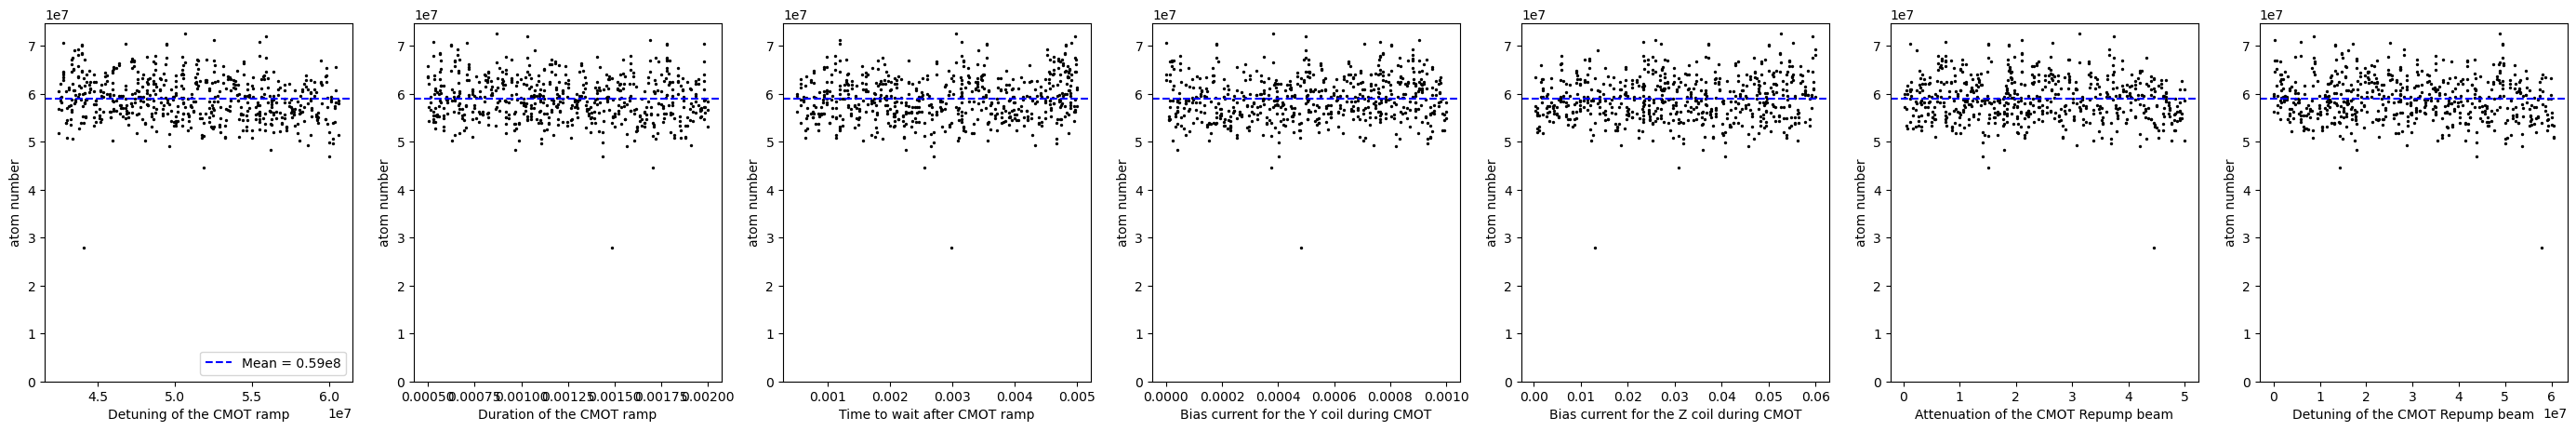

In [21]:
import matplotlib.pyplot as plt
import json
import numpy as np
from matplotlib import colors


axes = json.loads(db[f"ndscan.rid_{RID}.axes"][1])
num_axes = len(axes)

fig, ax = plt.subplots(1, num_axes, figsize=(5 * num_axes, 5))
if num_axes == 1:
    ax = [ax]  # Ensure ax is always a list for consistency
    # make scatter plot
for i in range(num_axes):
    ax[i].scatter(
        np.array(db[f"ndscan.rid_{RID}.points.axis_{i}"][1]),
        np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1]),
        s=2,
        color="k",
    )

    ax[i].set_xlabel(axes[i]["param"]["description"])
    ax[i].set_ylabel("atom number")
    ax[i].set_ylim(bottom=0)

numbers = np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
print(f"Num points: {len(numbers)}")

# count the nummber of failed shots (numbers < 1E8)

failed_shots = 0
for i in range(len(numbers)):
    if numbers[i] < 1e7:
        failed_shots += 1
print(f"Failed shots: {failed_shots / len(numbers) * 100:.2f}%")

for i in range(1, num_axes):
    ax[i].axhline(
        np.mean(numbers),
        color="b",
        linestyle="--",
    )
ax[0].axhline(np.mean(numbers), color='b', linestyle='--',
              label='Mean = {:.2f}e8'.format(np.mean(numbers) / 1e8))
ax[0].legend(loc="lower right")

# atom number and uncertainty
print(
    f"Mean atom number: {np.mean(numbers) / 1e8:.2f}e8 +- {np.std(numbers) / 1e8:.2f}e8"
)

# obtain current best optimization parameterss
objective = np.array(db.get(f"ndscan.rid_{RID}.points.channel_custom_objective")[1])
axes_array = np.array(db.get(f"ndscan.rid_{RID}.axes")[1])

# find best results
best_index = np.argmin(objective)
best_objective = objective[best_index]
best_axes = {}
for i in range(num_axes):
    name = axes[i]["param"]["description"]
    value = db.get(f"ndscan.rid_{RID}.points.axis_{i}")[1][best_index]
    best_axes[name] = value
print(
    f"Atom number at best parameters: {db.get(f'ndscan.rid_{RID}.points.channel_atom_number')[1][best_index] / 1e8:.2f}e8"
)
print(f"Best objective value: {best_objective}")
for name, value in best_axes.items():
    print(f"{name}: {value}")


In [12]:
# best index based on PSD
PSD = np.array(db.get(f"ndscan.rid_{RID}.points.channel_phase_space_density")[1])
best_index = np.argmax(PSD)
best_PSD = PSD[best_index]
best_axes = {}
best_sigma_x = db.get(f"ndscan.rid_{RID}.points.channel_sigmax_mm")[1][best_index]
best_sigma_y = db.get(f"ndscan.rid_{RID}.points.channel_sigmay_mm")[1][best_index]
for i in range(num_axes):
    name = axes[i]["param"]["description"]
    value = db.get(f"ndscan.rid_{RID}.points.axis_{i}")[1][best_index]
    best_axes[name] = value
print(
    f"Atom number at best PSD: {db.get(f'ndscan.rid_{RID}.points.channel_atom_number')[1][best_index] / 1e8:.2f}e8"
)
print(f"Best PSD: {best_PSD:.2e}")
print(f"Best sigma_x: {best_sigma_x:.2f} mm")
print(f"Best sigma_y: {best_sigma_y:.2f} mm")
for name, value in best_axes.items():
    print(f"{name}: {value}")

# # make a scatter plot of atom number vs total time = axis_0 + axis_1
# fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
# t1 = db[f"ndscan.rid_{RID}.points.axis_1"][1]
# t2 = db[f"ndscan.rid_{RID}.points.axis_2"][1]
# N = np.array(db[f"ndscan.rid_{RID}.points.channel_atom_number"][1])
# t_total = np.array(t1) + np.array(t2)
# t_frac = np.array(t1) / t_total

# ax[0].scatter(
#     t_total *1e3,
#     N,
#     s=2,color='k',)
# ax[0].set_xlabel("Total Time (ms)")
# ax[0].set_ylabel("Atom Number")
# ax[1].scatter(
#     t_frac,
#     N,
#     s=2,color='k',)
# ax[1].set_xlabel(f"Time Fraction : $t_{{ramp}}/t_{{total}}$")
# ax[1].set_ylabel("Atom Number")
# ax[0].set_title("Scatter Plot of Atom Number vs Total Time")
# ax[1].set_title("Scatter Plot of Atom Number vs Time Fraction")
# plt.show()


Atom number at best PSD: 0.71e8
Best PSD: 4.02e-08
Best sigma_x: 1.84 mm
Best sigma_y: 1.60 mm
Detuning of the CMOT ramp: 55484687.144138396
Duration of the CMOT ramp: 0.0005280604030146682
Time to wait after CMOT ramp: 0.0031543614282728066
Bias current for the Y coil during CMOT: 0.0007646531951804631
Bias current for the Z coil during CMOT: 0.023280142817127113
Attenuation of the CMOT Repump beam: 0.7545885995295676
Detuning of the CMOT Repump beam: 5876286.46708617


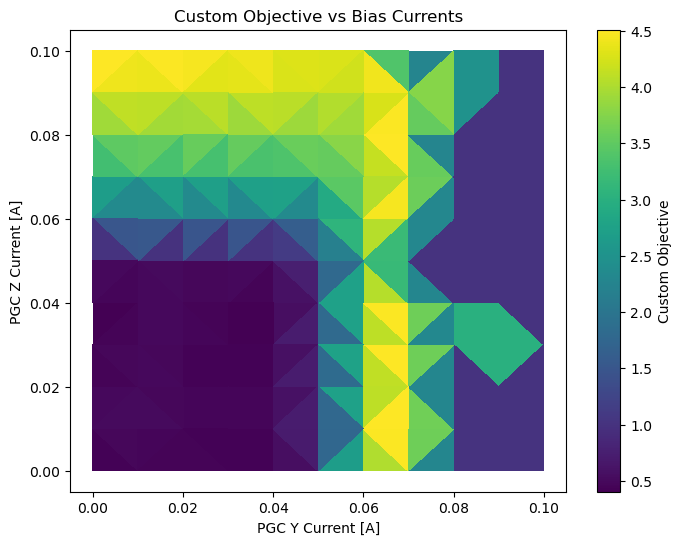

In [13]:
import pandas as pd

import pandas as pd

df1 = pd.DataFrame([
    {
        "point_index": 0,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 0.44442827214845687,
        "gaussian_fit_centre_y": 570.0260487388251,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (570, 0, 0.09107087887929405),\n            "centroid_pixel": (322, 310, 0.0),\n            "best_values_pixel": {\'A\': 0.10458951918144187, \'x0\': 0.44442827214845687, \'y0\': 570.0260487388251, \'sx\': 1.3756899121673756, \'sy\': 1.1596705748573726, \'theta\': 0, \'z0\': -0.03849395122403956},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09107087887929405,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.3756899121673756,\n            "sigmay": 1.1596705748573726,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.03908898649109944,\n            "sigmay_mm": 0.032950992104978205,\n        ',
        "peak_od": 0.09107087887929405,
        "phase_space_density": None,
        "sigmax": 1.3756899121673756,
        "sigmax_mm": 0.03908898649109944,
        "sigmay": 1.1596705748573726,
        "sigmay_mm": 0.032950992104978205,
    },
    {
        "point_index": 1,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 340153870.6788551,
        "custom_objective": 0.39601551521200395,
        "gaussian_fit_centre_x": 315.59463814265183,
        "gaussian_fit_centre_y": 233.942448983652,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 340153870.6788551,\n            "peak_pixel": (235, 322, 3.3425548895565402),\n            "centroid_pixel": (234, 317, 2.9322638683876985),\n            "best_values_pixel": {\'A\': 3.152081367806678, \'x0\': 315.59463814265183, \'y0\': 233.942448983652, \'sx\': 85.03793137487942, \'sy\': 71.20689807030008, \'theta\': 0, \'z0\': -0.03244020426324518},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1828338485274827.0, 2.961156035142131e-08, 4.7472322471312425e-08),\n            "peak_optical_density": 3.3425548895565402,\n            "Peak density (atoms/cm^3)": 1.83e+09,\n            "sigmax": 85.03793137487942,\n            "sigmay": 71.20689807030008,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.416276023647455,\n            "sigmay_mm": 2.0232797028785705,\n        ',
        "peak_od": 3.3425548895565402,
        "phase_space_density": 4.7472322471312425e-8,
        "sigmax": 85.03793137487942,
        "sigmax_mm": 2.416276023647455,
        "sigmay": 71.20689807030008,
        "sigmay_mm": 2.0232797028785705,
    },
    {
        "point_index": 2,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 344124248.61790115,
        "custom_objective": 0.3889708639818913,
        "gaussian_fit_centre_x": 315.5740540797919,
        "gaussian_fit_centre_y": 233.1241694263908,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 344124248.61790115,\n            "peak_pixel": (234, 322, 3.276332035842259),\n            "centroid_pixel": (233, 317, 2.881896471835699),\n            "best_values_pixel": {\'A\': 3.178644916820777, \'x0\': 315.5740540797919, \'y0\': 233.1241694263908, \'sx\': 85.53776111332239, \'sy\': 71.00634302327968, \'theta\': 0, \'z0\': -0.061597356244664725},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1833289274553048.8, 2.961156035142131e-08, 4.760086839811762e-08),\n            "peak_optical_density": 3.276332035842259,\n            "Peak density (atoms/cm^3)": 1.83e+09,\n            "sigmax": 85.53776111332239,\n            "sigmay": 71.00634302327968,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.430478234277222,\n            "sigmay_mm": 2.01758111233548,\n        ',
        "peak_od": 3.276332035842259,
        "phase_space_density": 4.760086839811762e-8,
        "sigmax": 85.53776111332239,
        "sigmax_mm": 2.430478234277222,
        "sigmay": 71.00634302327968,
        "sigmay_mm": 2.01758111233548,
    },
    {
        "point_index": 3,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 454.08140392638325,
        "gaussian_fit_centre_y": 193.75429745969723,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (173, 39, 0.0909813873294476),\n            "centroid_pixel": (266, 334, 0.013060379436811674),\n            "best_values_pixel": {\'A\': 0.030761427382331147, \'x0\': 454.08140392638325, \'y0\': 193.75429745969723, \'sx\': 270.2948960756552, \'sy\': 65.56357597009374, \'theta\': 0, \'z0\': -0.04343960634255765},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.0909813873294476,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 270.2948960756552,\n            "sigmay": 65.56357597009374,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 7.680185373074782,\n            "sigmay_mm": 1.8629298017934122,\n        ',
        "peak_od": 0.0909813873294476,
        "phase_space_density": None,
        "sigmax": 270.2948960756552,
        "sigmax_mm": 7.680185373074782,
        "sigmay": 65.56357597009374,
        "sigmay_mm": 1.8629298017934122,
    },
    {
        "point_index": 4,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 332771355.33715636,
        "custom_objective": 0.4080598075705172,
        "gaussian_fit_centre_x": 317.4350342200317,
        "gaussian_fit_centre_y": 233.82556818960535,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 332771355.33715636,\n            "peak_pixel": (234, 322, 3.2750015590175345),\n            "centroid_pixel": (234, 318, 2.8951269549066176),\n            "best_values_pixel": {\'A\': 3.103288412442356, \'x0\': 317.4350342200317, \'y0\': 233.82556818960535, \'sx\': 85.18034647317596, \'sy\': 70.62029772420908, \'theta\': 0, \'z0\': -0.062172498019563684},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1797488878763991.5, 2.961156035142131e-08, 4.6671320643592684e-08),\n            "peak_optical_density": 3.2750015590175345,\n            "Peak density (atoms/cm^3)": 1.80e+09,\n            "sigmax": 85.18034647317596,\n            "sigmay": 70.62029772420908,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4203226200527967,\n            "sigmay_mm": 2.0066119837936056,\n        ',
        "peak_od": 3.2750015590175345,
        "phase_space_density": 4.6671320643592684e-8,
        "sigmax": 85.18034647317596,
        "sigmax_mm": 2.4203226200527967,
        "sigmay": 70.62029772420908,
        "sigmay_mm": 2.0066119837936056,
    },
    {
        "point_index": 5,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 162.82714580123937,
        "gaussian_fit_centre_y": 599.9999999747109,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (600, 37, 0.09090704284144054),\n            "centroid_pixel": (345, 310, 0.0),\n            "best_values_pixel": {\'A\': 0.023445800268491777, \'x0\': 162.82714580123937, \'y0\': 599.9999999747109, \'sx\': 600.99999999999, \'sy\': 46.291483954195, \'theta\': 0, \'z0\': -0.06745406713038266},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09090704284144054,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 600.99999999999,\n            "sigmay": 46.291483954195,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 17.07687224669575,\n            "sigmay_mm": 1.3153307114738226,\n        ',
        "peak_od": 0.09090704284144054,
        "phase_space_density": None,
        "sigmax": 600.99999999999,
        "sigmax_mm": 17.07687224669575,
        "sigmay": 46.291483954195,
        "sigmay_mm": 1.3153307114738226,
    },
    {
        "point_index": 6,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 13867249.864745235,
        "custom_objective": 4.857792630932543,
        "gaussian_fit_centre_x": 406.96786713101835,
        "gaussian_fit_centre_y": 195.58714871733437,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 13867249.864745235,\n            "peak_pixel": (147, 595, 0.12182483810736282),\n            "centroid_pixel": (246, 339, 0.0574698497602378),\n            "best_values_pixel": {\'A\': 0.06707073304505817, \'x0\': 406.96786713101835, \'y0\': 195.58714871733437, \'sx\': 219.70854690319533, \'sy\': 63.92163460925319, \'theta\': 0, \'z0\': -0.05388171460512131},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (12438762915885.084, 2.961156035142131e-08, 3.229691706666332e-10),\n            "peak_optical_density": 0.12182483810736282,\n            "Peak density (atoms/cm^3)": 1.24e+07,\n            "sigmax": 219.70854690319533,\n            "sigmay": 63.92163460925319,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.2428199450467385,\n            "sigmay_mm": 1.8162755208356078,\n        ',
        "peak_od": 0.12182483810736282,
        "phase_space_density": 3.229691706666332e-10,
        "sigmax": 219.70854690319533,
        "sigmax_mm": 6.2428199450467385,
        "sigmay": 63.92163460925319,
        "sigmay_mm": 1.8162755208356078,
    },
    {
        "point_index": 7,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 326908173.37129146,
        "custom_objective": 0.7869545207895168,
        "gaussian_fit_centre_x": 309.5853021831825,
        "gaussian_fit_centre_y": 231.76594837513574,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 326908173.37129146,\n            "peak_pixel": (243, 306, 2.5052979081989863),\n            "centroid_pixel": (234, 312, 2.3812727840505516),\n            "best_values_pixel": {\'A\': 2.392160947011837, \'x0\': 309.5853021831825, \'y0\': 231.76594837513574, \'sx\': 106.94215730751513, \'sy\': 71.56068515699945, \'theta\': 0, \'z0\': -0.0644162467757113},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1105559275443562.8, 2.961156035142131e-08, 2.8705552531821407e-08),\n            "peak_optical_density": 2.5052979081989863,\n            "Peak density (atoms/cm^3)": 1.11e+09,\n            "sigmax": 106.94215730751513,\n            "sigmay": 71.56068515699945,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.038664822173888,\n            "sigmay_mm": 2.0333322434477816,\n        ',
        "peak_od": 2.5052979081989863,
        "phase_space_density": 2.8705552531821407e-8,
        "sigmax": 106.94215730751513,
        "sigmax_mm": 3.038664822173888,
        "sigmay": 71.56068515699945,
        "sigmay_mm": 2.0333322434477816,
    },
    {
        "point_index": 8,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 339967800.22103405,
        "custom_objective": 0.43813529070819746,
        "gaussian_fit_centre_x": 317.12433807266024,
        "gaussian_fit_centre_y": 233.2327130567677,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 339967800.22103405,\n            "peak_pixel": (235, 323, 3.2294435381155555),\n            "centroid_pixel": (233, 318, 2.870759915874355),\n            "best_values_pixel": {\'A\': 3.0642264418681693, \'x0\': 317.12433807266024, \'y0\': 233.2327130567677, \'sx\': 87.15022099757302, \'sy\': 71.43363729035137, \'theta\': 0, \'z0\': -0.02261619861270992},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1734309729491154.2, 2.961156035142131e-08, 4.503089083702299e-08),\n            "peak_optical_density": 3.2294435381155555,\n            "Peak density (atoms/cm^3)": 1.73e+09,\n            "sigmax": 87.15022099757302,\n            "sigmay": 71.43363729035137,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4762948257019644,\n            "sigmay_mm": 2.029722293051834,\n        ',
        "peak_od": 3.2294435381155555,
        "phase_space_density": 4.503089083702299e-8,
        "sigmax": 87.15022099757302,
        "sigmax_mm": 2.4762948257019644,
        "sigmay": 71.43363729035137,
        "sigmay_mm": 2.029722293051834,
    },
    {
        "point_index": 9,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 48230166.081711024,
        "custom_objective": 3.5915759598513155,
        "gaussian_fit_centre_x": 367.04882612234593,
        "gaussian_fit_centre_y": 210.1843327303107,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 48230166.081711024,\n            "peak_pixel": (223, 344, 0.25526840360969383),\n            "centroid_pixel": (221, 335, 0.22048086705046785),\n            "best_values_pixel": {\'A\': 0.22049172374669615, \'x0\': 367.04882612234593, \'y0\': 210.1843327303107, \'sx\': 199.00182559480015, \'sy\': 69.64919465552414, \'theta\': 0, \'z0\': -0.015189011876035014},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (48396857432021.69, 2.961156035142131e-08, 1.2566115306957049e-09),\n            "peak_optical_density": 0.25526840360969383,\n            "Peak density (atoms/cm^3)": 4.84e+07,\n            "sigmax": 199.00182559480015,\n            "sigmay": 69.64919465552414,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.6544571589711925,\n            "sigmay_mm": 1.979018967084276,\n        ',
        "peak_od": 0.25526840360969383,
        "phase_space_density": 1.2566115306957049e-9,
        "sigmax": 199.00182559480015,
        "sigmax_mm": 5.6544571589711925,
        "sigmay": 69.64919465552414,
        "sigmay_mm": 1.979018967084276,
    },
    {
        "point_index": 10,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0,
        "atom_number": 338930172.0680567,
        "custom_objective": 0.40683176735709314,
        "gaussian_fit_centre_x": 317.3376004774841,
        "gaussian_fit_centre_y": 234.6346529896451,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 338930172.0680567,\n            "peak_pixel": (235, 323, 3.284038891231913),\n            "centroid_pixel": (235, 319, 3.0637969735245005),\n            "best_values_pixel": {\'A\': 3.1268264499682927, \'x0\': 317.3376004774841, \'y0\': 234.6346529896451, \'sx\': 85.6611281108014, \'sy\': 71.02956154584415, \'theta\': 0, \'z0\': 0.02010546786008853},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1799832726414362.5, 2.961156035142131e-08, 4.673217802442133e-08),\n            "peak_optical_density": 3.284038891231913,\n            "Peak density (atoms/cm^3)": 1.80e+09,\n            "sigmax": 85.6611281108014,\n            "sigmay": 71.02956154584415,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4339835960998633,\n            "sigmay_mm": 2.0182408456858796,\n        ',
        "peak_od": 3.284038891231913,
        "phase_space_density": 4.673217802442133e-8,
        "sigmax": 85.6611281108014,
        "sigmax_mm": 2.4339835960998633,
        "sigmay": 71.02956154584415,
        "sigmay_mm": 2.0182408456858796,
    },
    {
        "point_index": 11,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 186.44724650508428,
        "gaussian_fit_centre_y": 599.9999999981745,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (74, 426, 0.08674686297300829),\n            "centroid_pixel": (345, 317, 0.0),\n            "best_values_pixel": {\'A\': 0.01614988940852115, \'x0\': 186.44724650508428, \'y0\': 599.9999999981745, \'sx\': 600.9999999999529, \'sy\': 48.62592042353195, \'theta\': 0, \'z0\': -0.06318944681522391},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08674686297300829,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 600.9999999999529,\n            "sigmay": 48.62592042353195,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 17.076872246694695,\n            "sigmay_mm": 1.3816616155585069,\n        ',
        "peak_od": 0.08674686297300829,
        "phase_space_density": None,
        "sigmax": 600.9999999999529,
        "sigmax_mm": 17.076872246694695,
        "sigmay": 48.62592042353195,
        "sigmay_mm": 1.3816616155585069,
    },
    {
        "point_index": 12,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 331996158.8704822,
        "custom_objective": 0.426494363883541,
        "gaussian_fit_centre_x": 317.16419600859433,
        "gaussian_fit_centre_y": 234.353813598671,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 331996158.8704822,\n            "peak_pixel": (243, 306, 3.230289054562566),\n            "centroid_pixel": (234, 318, 2.904425338010443),\n            "best_values_pixel": {\'A\': 3.063735247806735, \'x0\': 317.16419600859433, \'y0\': 234.353813598671, \'sx\': 85.7034187489271, \'sy\': 70.94681436111115, \'theta\': 0, \'z0\': -0.03439473738988358},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1763325514449410.8, 2.961156035142131e-08, 4.5784277975887246e-08),\n            "peak_optical_density": 3.230289054562566,\n            "Peak density (atoms/cm^3)": 1.76e+09,\n            "sigmax": 85.7034187489271,\n            "sigmay": 70.94681436111115,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4351852463902195,\n            "sigmay_mm": 2.0158896591593254,\n        ',
        "peak_od": 3.230289054562566,
        "phase_space_density": 4.5784277975887246e-8,
        "sigmax": 85.7034187489271,
        "sigmax_mm": 2.4351852463902195,
        "sigmay": 70.94681436111115,
        "sigmay_mm": 2.0158896591593254,
    },
    {
        "point_index": 13,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 305382213.3409177,
        "custom_objective": 0.4812629157966522,
        "gaussian_fit_centre_x": 317.66557043776675,
        "gaussian_fit_centre_y": 234.44078199330164,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 305382213.3409177,\n            "peak_pixel": (235, 322, 3.0271078874322956),\n            "centroid_pixel": (234, 319, 2.7806085612498914),\n            "best_values_pixel": {\'A\': 2.8730102140134886, \'x0\': 317.66557043776675, \'y0\': 234.44078199330164, \'sx\': 84.46657128686546, \'sy\': 70.61718806349519, \'theta\': 0, \'z0\': -0.018638921331226934},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1677614659708049.5, 2.961156035142131e-08, 4.3558818429778034e-08),\n            "peak_optical_density": 3.0271078874322956,\n            "Peak density (atoms/cm^3)": 1.68e+09,\n            "sigmax": 84.46657128686546,\n            "sigmay": 70.61718806349519,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4000413427325205,\n            "sigmay_mm": 2.0065236255927044,\n        ',
        "peak_od": 3.0271078874322956,
        "phase_space_density": 4.3558818429778034e-8,
        "sigmax": 84.46657128686546,
        "sigmax_mm": 2.4000413427325205,
        "sigmay": 70.61718806349519,
        "sigmay_mm": 2.0065236255927044,
    },
    {
        "point_index": 14,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 460.5554841767125,
        "gaussian_fit_centre_y": 199.47658703932743,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (317, 0, 0.08466362901801058),\n            "centroid_pixel": (270, 334, 0.014566808449274889),\n            "best_values_pixel": {\'A\': 0.03023906736208876, \'x0\': 460.5554841767125, \'y0\': 199.47658703932743, \'sx\': 269.02167559074286, \'sy\': 63.849525912515354, \'theta\': 0, \'z0\': -0.02550664357404301},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08466362901801058,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 269.02167559074286,\n            "sigmay": 63.849525912515354,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 7.644007962820666,\n            "sigmay_mm": 1.8142266173379913,\n        ',
        "peak_od": 0.08466362901801058,
        "phase_space_density": None,
        "sigmax": 269.02167559074286,
        "sigmax_mm": 7.644007962820666,
        "sigmay": 63.849525912515354,
        "sigmay_mm": 1.8142266173379913,
    },
    {
        "point_index": 15,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 321557415.7885781,
        "custom_objective": 0.5115805464970168,
        "gaussian_fit_centre_x": 313.672857730295,
        "gaussian_fit_centre_y": 233.23362892837235,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 321557415.7885781,\n            "peak_pixel": (235, 323, 3.028325450212552),\n            "centroid_pixel": (233, 315, 2.7383232874036647),\n            "best_values_pixel": {\'A\': 2.8636286753597355, \'x0\': 313.672857730295, \'y0\': 233.23362892837235, \'sx\': 87.95873632018622, \'sy\': 71.62050050458153, \'theta\': 0, \'z0\': -0.01969272412930694},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1606171222916524.8, 2.961156035142131e-08, 4.170380859590896e-08),\n            "peak_optical_density": 3.028325450212552,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 87.95873632018622,\n            "sigmay": 71.62050050458153,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.499268058437009,\n            "sigmay_mm": 2.0350318425310605,\n        ',
        "peak_od": 3.028325450212552,
        "phase_space_density": 4.170380859590896e-8,
        "sigmax": 87.95873632018622,
        "sigmax_mm": 2.499268058437009,
        "sigmay": 71.62050050458153,
        "sigmay_mm": 2.0350318425310605,
    },
    {
        "point_index": 16,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 6.021255867649432e-8,
        "gaussian_fit_centre_y": 468.9267997521797,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (468, 0, 0.07483193181457434),\n            "centroid_pixel": (293, 327, 0.0013697822005226956),\n            "best_values_pixel": {\'A\': 0.04803179231614213, \'x0\': 6.021255867649432e-08, \'y0\': 468.9267997521797, \'sx\': 6.29835488420088, \'sy\': 1.7080607526784135, \'theta\': 0, \'z0\': -0.03184945521701322},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07483193181457434,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 6.29835488420088,\n            "sigmay": 1.7080607526784135,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.1789620660929325,\n            "sigmay_mm": 0.048533003765532004,\n        ',
        "peak_od": 0.07483193181457434,
        "phase_space_density": None,
        "sigmax": 6.29835488420088,
        "sigmax_mm": 0.1789620660929325,
        "sigmay": 1.7080607526784135,
        "sigmay_mm": 0.048533003765532004,
    },
    {
        "point_index": 17,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 14769482.069781171,
        "custom_objective": 4.9755286742228195,
        "gaussian_fit_centre_x": 411.7743237132432,
        "gaussian_fit_centre_y": 206.64324687372158,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 14769482.069781171,\n            "peak_pixel": (80, 446, 0.10287033927836078),\n            "centroid_pixel": (240, 342, 0.07251952613334106),\n            "best_values_pixel": {\'A\': 0.06697939918307698, \'x0\': 411.7743237132432, \'y0\': 206.64324687372158, \'sx\': 239.09073992276817, \'sy\': 66.26284737275577, \'theta\': 0, \'z0\': -0.03946338225225369},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (10791909258241.865, 2.961156035142131e-08, 2.802090534737012e-10),\n            "peak_optical_density": 0.10287033927836078,\n            "Peak density (atoms/cm^3)": 1.08e+07,\n            "sigmax": 239.09073992276817,\n            "sigmay": 66.26284737275577,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.793547455955306,\n            "sigmay_mm": 1.8827989671994478,\n        ',
        "peak_od": 0.10287033927836078,
        "phase_space_density": 2.802090534737012e-10,
        "sigmax": 239.09073992276817,
        "sigmax_mm": 6.793547455955306,
        "sigmay": 66.26284737275577,
        "sigmay_mm": 1.8827989671994478,
    },
    {
        "point_index": 18,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 341218613.9655836,
        "custom_objective": 0.8468976569794903,
        "gaussian_fit_centre_x": 305.3382180155498,
        "gaussian_fit_centre_y": 231.10109587101317,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 341218613.9655836,\n            "peak_pixel": (235, 323, 2.435209431797223),\n            "centroid_pixel": (233, 308, 2.3565339417648787),\n            "best_values_pixel": {\'A\': 2.331877802532644, \'x0\': 305.3382180155498, \'y0\': 231.10109587101317, \'sx\': 113.97003530049727, \'sy\': 71.9105627175696, \'theta\': 0, \'z0\': -0.025823547024058882},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1011084113965916.8, 2.961156035142131e-08, 2.6252530092422302e-08),\n            "peak_optical_density": 2.435209431797223,\n            "Peak density (atoms/cm^3)": 1.01e+09,\n            "sigmax": 113.97003530049727,\n            "sigmay": 71.9105627175696,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.238355628582411,\n            "sigmay_mm": 2.0432736983626603,\n        ',
        "peak_od": 2.435209431797223,
        "phase_space_density": 2.6252530092422302e-8,
        "sigmax": 113.97003530049727,
        "sigmax_mm": 3.238355628582411,
        "sigmay": 71.9105627175696,
        "sigmay_mm": 2.0432736983626603,
    },
    {
        "point_index": 19,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 322168382.5439064,
        "custom_objective": 0.47195011231803136,
        "gaussian_fit_centre_x": 318.7923802713879,
        "gaussian_fit_centre_y": 232.6787708701467,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 322168382.5439064,\n            "peak_pixel": (235, 322, 3.119870921804357),\n            "centroid_pixel": (232, 320, 2.9404618964708695),\n            "best_values_pixel": {\'A\': 2.94217649638581, \'x0\': 318.7923802713879, \'y0\': 232.6787708701467, \'sx\': 86.14268782223856, \'sy\': 71.31375749921978, \'theta\': 0, \'z0\': -0.021994409708940076},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1685005741363609.8, 2.961156035142131e-08, 4.375072589909535e-08),\n            "peak_optical_density": 3.119870921804357,\n            "Peak density (atoms/cm^3)": 1.69e+09,\n            "sigmax": 86.14268782223856,\n            "sigmay": 71.31375749921978,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.447666680411624,\n            "sigmay_mm": 2.0263160170483148,\n        ',
        "peak_od": 3.119870921804357,
        "phase_space_density": 4.375072589909535e-8,
        "sigmax": 86.14268782223856,
        "sigmax_mm": 2.447666680411624,
        "sigmay": 71.31375749921978,
        "sigmay_mm": 2.0263160170483148,
    },
    {
        "point_index": 20,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 46242163.377997085,
        "custom_objective": 3.6359984070356606,
        "gaussian_fit_centre_x": 369.0315138717142,
        "gaussian_fit_centre_y": 209.5427662319226,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 46242163.377997085,\n            "peak_pixel": (223, 351, 0.2452978410443878),\n            "centroid_pixel": (221, 336, 0.22582112869766902),\n            "best_values_pixel": {\'A\': 0.21217191343077418, \'x0\': 369.0315138717142, \'y0\': 209.5427662319226, \'sx\': 200.77298401315738, \'sy\': 69.14207770602279, \'theta\': 0, \'z0\': -0.03000525952513729},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (45921259959006.66, 2.961156035142131e-08, 1.1923333007647355e-09),\n            "peak_optical_density": 0.2452978410443878,\n            "Peak density (atoms/cm^3)": 4.59e+07,\n            "sigmax": 200.77298401315738,\n            "sigmay": 69.14207770602279,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.704783025924516,\n            "sigmay_mm": 1.9646096969332463,\n        ',
        "peak_od": 0.2452978410443878,
        "phase_space_density": 1.1923333007647355e-9,
        "sigmax": 200.77298401315738,
        "sigmax_mm": 5.704783025924516,
        "sigmay": 69.14207770602279,
        "sigmay_mm": 1.9646096969332463,
    },
    {
        "point_index": 21,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.01,
        "atom_number": 331511109.947922,
        "custom_objective": 0.47887777416178157,
        "gaussian_fit_centre_x": 314.1696490922051,
        "gaussian_fit_centre_y": 234.36355610083953,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 331511109.947922,\n            "peak_pixel": (235, 322, 3.112148121830632),\n            "centroid_pixel": (234, 315, 2.8782852955544036),\n            "best_values_pixel": {\'A\': 2.9575521156161613, \'x0\': 314.1696490922051, \'y0\': 234.36355610083953, \'sx\': 87.76803747420989, \'sy\': 71.67008094539264, \'theta\': 0, \'z0\': -0.016820370097164243},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1661942686616750.5, 2.961156035142131e-08, 4.315189981687138e-08),\n            "peak_optical_density": 3.112148121830632,\n            "Peak density (atoms/cm^3)": 1.66e+09,\n            "sigmax": 87.76803747420989,\n            "sigmay": 71.67008094539264,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4938495229456112,\n            "sigmay_mm": 2.0364406259814207,\n        ',
        "peak_od": 3.112148121830632,
        "phase_space_density": 4.315189981687138e-8,
        "sigmax": 87.76803747420989,
        "sigmax_mm": 2.4938495229456112,
        "sigmay": 71.67008094539264,
        "sigmay_mm": 2.0364406259814207,
    },
    {
        "point_index": 22,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 9.380484737741684,
        "gaussian_fit_centre_y": 599.999993573547,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (84, 143, 0.07243950977812032),\n            "centroid_pixel": (297, 337, 0.0017464766212029331),\n            "best_values_pixel": {\'A\': 0.03043531087351961, \'x0\': 9.380484737741684, \'y0\': 599.999993573547, \'sx\': 2.0301765359498547, \'sy\': 13.135646646662218, \'theta\': 0, \'z0\': -0.03368042063911297},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07243950977812032,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 2.0301765359498547,\n            "sigmay": 13.135646646662218,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.05768563284967648,\n            "sigmay_mm": 0.37323753687652556,\n        ',
        "peak_od": 0.07243950977812032,
        "phase_space_density": None,
        "sigmax": 2.0301765359498547,
        "sigmax_mm": 0.05768563284967648,
        "sigmay": 13.135646646662218,
        "sigmay_mm": 0.37323753687652556,
    },
    {
        "point_index": 23,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 39140786.444988914,
        "custom_objective": 4.530268603426062,
        "gaussian_fit_centre_x": 328.13462606091207,
        "gaussian_fit_centre_y": 231.48434014979904,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 39140786.444988914,\n            "peak_pixel": (235, 323, 0.17277711587893446),\n            "centroid_pixel": (265, 325, 0.13120568270074887),\n            "best_values_pixel": {\'A\': 0.11369673899911889, \'x0\': 328.13462606091207, \'y0\': 231.48434014979904, \'sx\': 196.4986873518026, \'sy\': 114.74489944954188, \'theta\': 0, \'z0\': 0.02844068888318316},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (24451498277433.008, 2.961156035142131e-08, 6.348766491990999e-10),\n            "peak_optical_density": 0.17277711587893446,\n            "Peak density (atoms/cm^3)": 2.45e+07,\n            "sigmax": 196.4986873518026,\n            "sigmay": 114.74489944954188,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.583332746339765,\n            "sigmay_mm": 3.2603726936103303,\n        ',
        "peak_od": 0.17277711587893446,
        "phase_space_density": 6.348766491990999e-10,
        "sigmax": 196.4986873518026,
        "sigmax_mm": 5.583332746339765,
        "sigmay": 114.74489944954188,
        "sigmay_mm": 3.2603726936103303,
    },
    {
        "point_index": 24,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 37016949.101637036,
        "custom_objective": 4.565608378559895,
        "gaussian_fit_centre_x": 326.5878249595325,
        "gaussian_fit_centre_y": 229.6380737256501,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 37016949.101637036,\n            "peak_pixel": (233, 356, 0.16379411260111412),\n            "centroid_pixel": (264, 323, 0.12742343036787127),\n            "best_values_pixel": {\'A\': 0.10891355525765636, \'x0\': 326.5878249595325, \'y0\': 229.6380737256501, \'sx\': 194.6414831165779, \'sy\': 114.27123835142999, \'theta\': 0, \'z0\': 0.01978516115108516},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (23665817047537.516, 2.961156035142131e-08, 6.144766450392304e-10),\n            "peak_optical_density": 0.16379411260111412,\n            "Peak density (atoms/cm^3)": 2.37e+07,\n            "sigmax": 194.6414831165779,\n            "sigmay": 114.27123835142999,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.5305619652067275,\n            "sigmay_mm": 3.2469140412630986,\n        ',
        "peak_od": 0.16379411260111412,
        "phase_space_density": 6.144766450392304e-10,
        "sigmax": 194.6414831165779,
        "sigmax_mm": 5.5305619652067275,
        "sigmay": 114.27123835142999,
        "sigmay_mm": 3.2469140412630986,
    },
    {
        "point_index": 25,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 431.4977748050993,
        "gaussian_fit_centre_y": 196.22903986825068,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (61, 325, 0.09232549669326923),\n            "centroid_pixel": (260, 339, 0.03221697377354962),\n            "best_values_pixel": {\'A\': 0.037253391768432356, \'x0\': 431.4977748050993, \'y0\': 196.22903986825068, \'sx\': 235.33806941313324, \'sy\': 69.78694179337398, \'theta\': 0, \'z0\': -0.043672551004432195},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09232549669326923,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 235.33806941313324,\n            "sigmay": 69.78694179337398,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.6869187123996,\n            "sigmay_mm": 1.9829329276090844,\n        ',
        "peak_od": 0.09232549669326923,
        "phase_space_density": None,
        "sigmax": 235.33806941313324,
        "sigmax_mm": 6.6869187123996,
        "sigmay": 69.78694179337398,
        "sigmay_mm": 1.9829329276090844,
    },
    {
        "point_index": 26,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 36568433.12712688,
        "custom_objective": 4.595001188899011,
        "gaussian_fit_centre_x": 327.5044166210334,
        "gaussian_fit_centre_y": 232.17891540541208,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 36568433.12712688,\n            "peak_pixel": (230, 354, 0.16112893941042666),\n            "centroid_pixel": (267, 325, 0.11878422783035719),\n            "best_values_pixel": {\'A\': 0.10625740468605413, \'x0\': 327.5044166210334, \'y0\': 232.17891540541208, \'sx\': 196.28955304714802, \'sy\': 114.61876640885556, \'theta\': 0, \'z0\': 0.024021541018324096},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (22918430611775.17, 2.961156035142131e-08, 5.950709550234335e-10),\n            "peak_optical_density": 0.16112893941042666,\n            "Peak density (atoms/cm^3)": 2.29e+07,\n            "sigmax": 196.28955304714802,\n            "sigmay": 114.61876640885556,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.577390383938787,\n            "sigmay_mm": 3.256788737167922,\n        ',
        "peak_od": 0.16112893941042666,
        "phase_space_density": 5.950709550234335e-10,
        "sigmax": 196.28955304714802,
        "sigmax_mm": 5.577390383938787,
        "sigmay": 114.61876640885556,
        "sigmay_mm": 3.256788737167922,
    },
    {
        "point_index": 27,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 448.55571734657343,
        "gaussian_fit_centre_y": 191.81040427651115,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (194, 600, 0.07474589676856577),\n            "centroid_pixel": (275, 341, 0.009493230548296129),\n            "best_values_pixel": {\'A\': 0.023539553261930392, \'x0\': 448.55571734657343, \'y0\': 191.81040427651115, \'sx\': 237.92721210155122, \'sy\': 65.76092579045292, \'theta\': 0, \'z0\': -0.035157301956487044},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07474589676856577,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 237.92721210155122,\n            "sigmay": 65.76092579045292,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.760486863678437,\n            "sigmay_mm": 1.868537318715512,\n        ',
        "peak_od": 0.07474589676856577,
        "phase_space_density": None,
        "sigmax": 237.92721210155122,
        "sigmax_mm": 6.760486863678437,
        "sigmay": 65.76092579045292,
        "sigmay_mm": 1.868537318715512,
    },
    {
        "point_index": 28,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 406.68348873826955,
        "gaussian_fit_centre_y": 206.6687394457847,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (214, 556, 0.09728745817988693),\n            "centroid_pixel": (241, 350, 0.07295634801646911),\n            "best_values_pixel": {\'A\': 0.06468619322304439, \'x0\': 406.68348873826955, \'y0\': 206.6687394457847, \'sx\': 211.14363752630754, \'sy\': 66.22225209284603, \'theta\': 0, \'z0\': -0.046649167358444564},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09728745817988693,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 211.14363752630754,\n            "sigmay": 66.22225209284603,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.999455779932527,\n            "sigmay_mm": 1.8816454889817482,\n        ',
        "peak_od": 0.09728745817988693,
        "phase_space_density": None,
        "sigmax": 211.14363752630754,
        "sigmax_mm": 5.999455779932527,
        "sigmay": 66.22225209284603,
        "sigmay_mm": 1.8816454889817482,
    },
    {
        "point_index": 29,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 33341186.56711581,
        "custom_objective": 4.370189894492029,
        "gaussian_fit_centre_x": 333.21622328748583,
        "gaussian_fit_centre_y": 226.80482817328087,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 33341186.56711581,\n            "peak_pixel": (213, 332, 0.165914213256853),\n            "centroid_pixel": (258, 329, 0.13772651500615585),\n            "best_values_pixel": {\'A\': 0.11264376941794232, \'x0\': 333.21622328748583, \'y0\': 226.80482817328087, \'sx\': 174.1323352460026, \'sy\': 104.57641632068382, \'theta\': 0, \'z0\': 0.011669335136234102},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (29101613811464.793, 2.961156035142131e-08, 7.556156622091738e-10),\n            "peak_optical_density": 0.165914213256853,\n            "Peak density (atoms/cm^3)": 2.91e+07,\n            "sigmax": 174.1323352460026,\n            "sigmay": 104.57641632068382,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.947813049941483,\n            "sigmay_mm": 2.971444428495201,\n        ',
        "peak_od": 0.165914213256853,
        "phase_space_density": 7.556156622091738e-10,
        "sigmax": 174.1323352460026,
        "sigmax_mm": 4.947813049941483,
        "sigmay": 104.57641632068382,
        "sigmay_mm": 2.971444428495201,
    },
    {
        "point_index": 30,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 38374365.87274564,
        "custom_objective": 4.564740738917824,
        "gaussian_fit_centre_x": 325.9113709952114,
        "gaussian_fit_centre_y": 230.37332267995768,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 38374365.87274564,\n            "peak_pixel": (241, 362, 0.16415211242606573),\n            "centroid_pixel": (265, 324, 0.12251434536472533),\n            "best_values_pixel": {\'A\': 0.11091325642325722, \'x0\': 325.9113709952114, \'y0\': 230.37332267995768, \'sx\': 196.44218052709766, \'sy\': 115.90800890112233, \'theta\': 0, \'z0\': 0.016958871602011396},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (23745805117146.523, 2.961156035142131e-08, 6.165535139915161e-10),\n            "peak_optical_density": 0.16415211242606573,\n            "Peak density (atoms/cm^3)": 2.37e+07,\n            "sigmax": 196.44218052709766,\n            "sigmay": 115.90800890112233,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.581727155946166,\n            "sigmay_mm": 3.2934213982918012,\n        ',
        "peak_od": 0.16415211242606573,
        "phase_space_density": 6.165535139915161e-10,
        "sigmax": 196.44218052709766,
        "sigmax_mm": 5.581727155946166,
        "sigmay": 115.90800890112233,
        "sigmay_mm": 3.2934213982918012,
    },
    {
        "point_index": 31,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 18622819.79464438,
        "custom_objective": 4.331778542806997,
        "gaussian_fit_centre_x": 374.28860394954546,
        "gaussian_fit_centre_y": 216.31922647669677,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 18622819.79464438,\n            "peak_pixel": (241, 312, 0.12045461372808657),\n            "centroid_pixel": (238, 345, 0.10111795343603061),\n            "best_values_pixel": {\'A\': 0.09487934277896852, \'x0\': 374.28860394954546, \'y0\': 216.31922647669677, \'sx\': 185.7154374903484, \'sy\': 64.8216688227037, \'theta\': 0, \'z0\': -0.05447483254031116},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (23054613550112.145, 2.961156035142131e-08, 5.986069087956103e-10),\n            "peak_optical_density": 0.12045461372808657,\n            "Peak density (atoms/cm^3)": 2.31e+07,\n            "sigmax": 185.7154374903484,\n            "sigmay": 64.8216688227037,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.276936439703731,\n            "sigmay_mm": 1.8418491802045762,\n        ',
        "peak_od": 0.12045461372808657,
        "phase_space_density": 5.986069087956103e-10,
        "sigmax": 185.7154374903484,
        "sigmax_mm": 5.276936439703731,
        "sigmay": 64.8216688227037,
        "sigmay_mm": 1.8418491802045762,
    },
    {
        "point_index": 32,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.1,
        "atom_number": 31491499.422998413,
        "custom_objective": 4.376904155839064,
        "gaussian_fit_centre_x": 322.97376144403415,
        "gaussian_fit_centre_y": 215.87341713438624,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 31491499.422998413,\n            "peak_pixel": (240, 361, 0.16657498466938245),\n            "centroid_pixel": (254, 322, 0.13467685589044115),\n            "best_values_pixel": {\'A\': 0.11002236247997678, \'x0\': 322.97376144403415, \'y0\': 215.87341713438624, \'sx\': 169.6081810886148, \'sy\': 103.82100269226521, \'theta\': 0, \'z0\': -0.02235331516530426},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (29183888152317.37, 2.961156035142131e-08, 7.577518935861998e-10),\n            "peak_optical_density": 0.16657498466938245,\n            "Peak density (atoms/cm^3)": 2.92e+07,\n            "sigmax": 169.6081810886148,\n            "sigmay": 103.82100269226521,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.819263295249187,\n            "sigmay_mm": 2.949980032445421,\n        ',
        "peak_od": 0.16657498466938245,
        "phase_space_density": 7.577518935861998e-10,
        "sigmax": 169.6081810886148,
        "sigmax_mm": 4.819263295249187,
        "sigmay": 103.82100269226521,
        "sigmay_mm": 2.949980032445421,
    },
    {
        "point_index": 33,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 208.77544984391778,
        "gaussian_fit_centre_y": 599.9999999999999,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (92, 485, 0.0830387060588883),\n            "centroid_pixel": (334, 305, 0.0),\n            "best_values_pixel": {\'A\': 0.017721071707319864, \'x0\': 208.77544984391778, \'y0\': 599.9999999999999, \'sx\': 600.9999999984177, \'sy\': 33.0870766480623, \'theta\': 0, \'z0\': -0.05846831988876573},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.0830387060588883,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 600.9999999984177,\n            "sigmay": 33.0870766480623,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 17.076872246651075,\n            "sigmay_mm": 0.9401394025550741,\n        ',
        "peak_od": 0.0830387060588883,
        "phase_space_density": None,
        "sigmax": 600.9999999984177,
        "sigmax_mm": 17.076872246651075,
        "sigmay": 33.0870766480623,
        "sigmay_mm": 0.9401394025550741,
    },
    {
        "point_index": 34,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 316747256.9222579,
        "custom_objective": 0.5241383589372615,
        "gaussian_fit_centre_x": 318.0543616060832,
        "gaussian_fit_centre_y": 236.64989408417395,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 316747256.9222579,\n            "peak_pixel": (228, 333, 2.960427624320041),\n            "centroid_pixel": (236, 319, 2.8033633103894404),\n            "best_values_pixel": {\'A\': 2.8253997200561374, \'x0\': 318.0543616060832, \'y0\': 236.64989408417395, \'sx\': 86.77878313218174, \'sy\': 72.47276952155197, \'theta\': 0, \'z0\': -0.04189555683946643},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1606347559653578.8, 2.961156035142131e-08, 4.170838713238478e-08),\n            "peak_optical_density": 2.960427624320041,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 86.77878313218174,\n            "sigmay": 72.47276952155197,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.465740754196353,\n            "sigmay_mm": 2.0592482969780184,\n        ',
        "peak_od": 2.960427624320041,
        "phase_space_density": 4.170838713238478e-8,
        "sigmax": 86.77878313218174,
        "sigmax_mm": 2.465740754196353,
        "sigmay": 72.47276952155197,
        "sigmay_mm": 2.0592482969780184,
    },
    {
        "point_index": 35,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 315364962.58735794,
        "custom_objective": 0.5455929470496531,
        "gaussian_fit_centre_x": 315.8784042110275,
        "gaussian_fit_centre_y": 237.26026492221266,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 315364962.58735794,\n            "peak_pixel": (252, 301, 2.9194343464599144),\n            "centroid_pixel": (237, 317, 2.853785037698539),\n            "best_values_pixel": {\'A\': 2.78184923540773, \'x0\': 315.8784042110275, \'y0\': 237.26026492221266, \'sx\': 87.77188118468527, \'sy\': 72.47337158263879, \'theta\': 0, \'z0\': -0.018511519021413056},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1563337650168141.5, 2.961156035142131e-08, 4.059164627230944e-08),\n            "peak_optical_density": 2.9194343464599144,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 87.77188118468527,\n            "sigmay": 72.47337158263879,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.493958738507577,\n            "sigmay_mm": 2.059265404000089,\n        ',
        "peak_od": 2.9194343464599144,
        "phase_space_density": 4.059164627230944e-8,
        "sigmax": 87.77188118468527,
        "sigmax_mm": 2.493958738507577,
        "sigmay": 72.47337158263879,
        "sigmay_mm": 2.059265404000089,
    },
    {
        "point_index": 36,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 0.0018678718755769808,
        "gaussian_fit_centre_y": 550.9126038368508,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (551, 0, 0.08639769023037326),\n            "centroid_pixel": (251, 349, 0.03087316845064167),\n            "best_values_pixel": {\'A\': 0.0879165945818929, \'x0\': 0.0018678718755769808, \'y0\': 550.9126038368508, \'sx\': 0.9486609527026736, \'sy\': 1.6553631281782244, \'theta\': 0, \'z0\': -0.036502063978741166},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08639769023037326,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 0.9486609527026736,\n            "sigmay": 1.6553631281782244,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.026955344250802836,\n            "sigmay_mm": 0.04703564835572487,\n        ',
        "peak_od": 0.08639769023037326,
        "phase_space_density": None,
        "sigmax": 0.9486609527026736,
        "sigmax_mm": 0.026955344250802836,
        "sigmay": 1.6553631281782244,
        "sigmay_mm": 0.04703564835572487,
    },
    {
        "point_index": 37,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 325959017.57569647,
        "custom_objective": 0.5180214808015129,
        "gaussian_fit_centre_x": 315.8738741267534,
        "gaussian_fit_centre_y": 236.68792153373758,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 325959017.57569647,\n            "peak_pixel": (251, 317, 3.010093555273924),\n            "centroid_pixel": (237, 317, 2.9474905847045583),\n            "best_values_pixel": {\'A\': 2.862650039029089, \'x0\': 315.8738741267534, \'y0\': 236.68792153373758, \'sx\': 87.60286079193794, \'sy\': 72.87846205710127, \'theta\': 0, \'z0\': -0.03637587244418286},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1613079783757144.2, 2.961156035142131e-08, 4.188318754060654e-08),\n            "peak_optical_density": 3.010093555273924,\n            "Peak density (atoms/cm^3)": 1.61e+09,\n            "sigmax": 87.60286079193794,\n            "sigmay": 72.87846205710127,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.489156176687223,\n            "sigmay_mm": 2.0707756840013354,\n        ',
        "peak_od": 3.010093555273924,
        "phase_space_density": 4.188318754060654e-8,
        "sigmax": 87.60286079193794,
        "sigmax_mm": 2.489156176687223,
        "sigmay": 72.87846205710127,
        "sigmay_mm": 2.0707756840013354,
    },
    {
        "point_index": 38,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 475.93574640795237,
        "gaussian_fit_centre_y": 194.6884697288516,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (184, 600, 0.08177264896816483),\n            "centroid_pixel": (284, 331, 0.008888897383473478),\n            "best_values_pixel": {\'A\': 0.018639449222012022, \'x0\': 475.93574640795237, \'y0\': 194.6884697288516, \'sx\': 292.83731786651254, \'sy\': 63.569941504633775, \'theta\': 0, \'z0\': -0.02632810455845118},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08177264896816483,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 292.83731786651254,\n            "sigmay": 63.569941504633775,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 8.320707930568307,\n            "sigmay_mm": 1.8062824788761578,\n        ',
        "peak_od": 0.08177264896816483,
        "phase_space_density": None,
        "sigmax": 292.83731786651254,
        "sigmax_mm": 8.320707930568307,
        "sigmay": 63.569941504633775,
        "sigmay_mm": 1.8062824788761578,
    },
    {
        "point_index": 39,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 400.3663847735147,
        "gaussian_fit_centre_y": 199.3587633646517,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (182, 595, 0.09568215789864898),\n            "centroid_pixel": (235, 341, 0.0675816782331666),\n            "best_values_pixel": {\'A\': 0.07036541513969671, \'x0\': 400.3663847735147, \'y0\': 199.3587633646517, \'sx\': 218.6741666738145, \'sy\': 68.11854832550738, \'theta\': 0, \'z0\': -0.04592530779911821},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09568215789864898,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 218.6741666738145,\n            "sigmay": 68.11854832550738,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.2134289649608085,\n            "sigmay_mm": 1.9355270339186015,\n        ',
        "peak_od": 0.09568215789864898,
        "phase_space_density": None,
        "sigmax": 218.6741666738145,
        "sigmax_mm": 6.2134289649608085,
        "sigmay": 68.11854832550738,
        "sigmay_mm": 1.9355270339186015,
    },
    {
        "point_index": 40,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 340555212.377171,
        "custom_objective": 0.8581416067333609,
        "gaussian_fit_centre_x": 305.9923052896874,
        "gaussian_fit_centre_y": 232.81517536323827,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 340555212.377171,\n            "peak_pixel": (243, 306, 2.4140362699519367),\n            "centroid_pixel": (235, 309, 2.3152592415545037),\n            "best_values_pixel": {\'A\': 2.311868137882953, \'x0\': 305.9923052896874, \'y0\': 232.81517536323827, \'sx\': 112.98219687030036, \'sy\': 72.99033495740454, \'theta\': 0, \'z0\': -0.03931911281643791},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1011651127987718.9, 2.961156035142131e-08, 2.6267252460684816e-08),\n            "peak_optical_density": 2.4140362699519367,\n            "Peak density (atoms/cm^3)": 1.01e+09,\n            "sigmax": 112.98219687030036,\n            "sigmay": 72.99033495740454,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.2102870916891506,\n            "sigmay_mm": 2.07395445143286,\n        ',
        "peak_od": 2.4140362699519367,
        "phase_space_density": 2.6267252460684816e-8,
        "sigmax": 112.98219687030036,
        "sigmax_mm": 3.2102870916891506,
        "sigmay": 72.99033495740454,
        "sigmay_mm": 2.07395445143286,
    },
    {
        "point_index": 41,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 333240900.4238916,
        "custom_objective": 0.4790166586405826,
        "gaussian_fit_centre_x": 315.6593781981729,
        "gaussian_fit_centre_y": 236.39289273337582,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 333240900.4238916,\n            "peak_pixel": (235, 322, 3.156180986438724),\n            "centroid_pixel": (236, 317, 2.952920419775328),\n            "best_values_pixel": {\'A\': 2.9602430530569395, \'x0\': 315.6593781981729, \'y0\': 236.39289273337582, \'sx\': 86.89856750544469, \'sy\': 72.64549446472812, \'theta\': 0, \'z0\': -0.06713504976348406},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1681330168305874.8, 2.961156035142131e-08, 4.3655290622274915e-08),\n            "peak_optical_density": 3.156180986438724,\n            "Peak density (atoms/cm^3)": 1.68e+09,\n            "sigmax": 86.89856750544469,\n            "sigmay": 72.64549446472812,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.469144318987305,\n            "sigmay_mm": 2.0641561202532874,\n        ',
        "peak_od": 3.156180986438724,
        "phase_space_density": 4.3655290622274915e-8,
        "sigmax": 86.89856750544469,
        "sigmax_mm": 2.469144318987305,
        "sigmay": 72.64549446472812,
        "sigmay_mm": 2.0641561202532874,
    },
    {
        "point_index": 42,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 47334995.89209403,
        "custom_objective": 3.646248856749695,
        "gaussian_fit_centre_x": 365.2511166100179,
        "gaussian_fit_centre_y": 214.04861493389274,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 47334995.89209403,\n            "peak_pixel": (215, 336, 0.2465695699498449),\n            "centroid_pixel": (227, 335, 0.22380099807517206),\n            "best_values_pixel": {\'A\': 0.21332996126562873, \'x0\': 365.2511166100179, \'y0\': 214.04861493389274, \'sx\': 202.31771285131384, \'sy\': 70.16885696723068, \'theta\': 0, \'z0\': 0.017410020678589225},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (45614062501013.76, 2.961156035142131e-08, 1.1843570004758893e-09),\n            "peak_optical_density": 0.2465695699498449,\n            "Peak density (atoms/cm^3)": 4.56e+07,\n            "sigmax": 202.31771285131384,\n            "sigmay": 70.16885696723068,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.748675100841297,\n            "sigmay_mm": 1.993784702372854,\n        ',
        "peak_od": 0.2465695699498449,
        "phase_space_density": 1.1843570004758893e-9,
        "sigmax": 202.31771285131384,
        "sigmax_mm": 5.748675100841297,
        "sigmay": 70.16885696723068,
        "sigmay_mm": 1.993784702372854,
    },
    {
        "point_index": 43,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.05,
        "atom_number": 330761798.68750554,
        "custom_objective": 0.5056469398851179,
        "gaussian_fit_centre_x": 315.40503896093713,
        "gaussian_fit_centre_y": 236.76538345979668,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 330761798.68750554,\n            "peak_pixel": (247, 327, 3.0595238844314143),\n            "centroid_pixel": (237, 317, 2.975339229033947),\n            "best_values_pixel": {\'A\': 2.9018215647356604, \'x0\': 315.40503896093713, \'y0\': 236.76538345979668, \'sx\': 87.51736412984356, \'sy\': 73.05927514466607, \'theta\': 0, \'z0\': -0.015628883843913796},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1635988147902134.5, 2.961156035142131e-08, 4.247799712249737e-08),\n            "peak_optical_density": 3.0595238844314143,\n            "Peak density (atoms/cm^3)": 1.64e+09,\n            "sigmax": 87.51736412984356,\n            "sigmay": 73.05927514466607,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.486726866244453,\n            "sigmay_mm": 2.0759133245951373,\n        ',
        "peak_od": 3.0595238844314143,
        "phase_space_density": 4.247799712249737e-8,
        "sigmax": 87.51736412984356,
        "sigmax_mm": 2.486726866244453,
        "sigmay": 73.05927514466607,
        "sigmay_mm": 2.0759133245951373,
    },
    {
        "point_index": 44,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 561.6832004909248,
        "gaussian_fit_centre_y": 133.18331956072404,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (278, 0, 0.0746243970933195),\n            "centroid_pixel": (319, 313, 0.0016099388026389189),\n            "best_values_pixel": {\'A\': 0.009369923148293558, \'x0\': 561.6832004909248, \'y0\': 133.18331956072404, \'sx\': 354.32632260725876, \'sy\': 81.41566793030132, \'theta\': 0, \'z0\': -0.041663493296306434},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.0746243970933195,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 354.32632260725876,\n            "sigmay": 81.41566793030132,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 10.067862470558673,\n            "sigmay_mm": 2.3133526790768437,\n        ',
        "peak_od": 0.0746243970933195,
        "phase_space_density": None,
        "sigmax": 354.32632260725876,
        "sigmax_mm": 10.067862470558673,
        "sigmay": 81.41566793030132,
        "sigmay_mm": 2.3133526790768437,
    },
    {
        "point_index": 45,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 321202013.0842879,
        "custom_objective": 0.4622329619653608,
        "gaussian_fit_centre_x": 317.8410959399355,
        "gaussian_fit_centre_y": 235.6586550867575,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 321202013.0842879,\n            "peak_pixel": (252, 316, 3.0785528173322643),\n            "centroid_pixel": (235, 319, 2.8951103658525663),\n            "best_values_pixel": {\'A\': 2.959817485789679, \'x0\': 317.8410959399355, \'y0\': 235.6586550867575, \'sx\': 85.79949912991023, \'sy\': 70.9943537866884, \'theta\': 0, \'z0\': -0.017911265313347337},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1701036247035762.2, 2.961156035142131e-08, 4.4166953715101884e-08),\n            "peak_optical_density": 3.0785528173322643,\n            "Peak density (atoms/cm^3)": 1.70e+09,\n            "sigmax": 85.79949912991023,\n            "sigmay": 70.9943537866884,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4379152836472286,\n            "sigmay_mm": 2.017240449005022,\n        ',
        "peak_od": 3.0785528173322643,
        "phase_space_density": 4.4166953715101884e-8,
        "sigmax": 85.79949912991023,
        "sigmax_mm": 2.4379152836472286,
        "sigmay": 70.9943537866884,
        "sigmay_mm": 2.017240449005022,
    },
    {
        "point_index": 46,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 327379080.8549155,
        "custom_objective": 0.42813258544988353,
        "gaussian_fit_centre_x": 316.72726986615,
        "gaussian_fit_centre_y": 234.04328578667287,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 327379080.8549155,\n            "peak_pixel": (235, 322, 3.1992048071606503),\n            "centroid_pixel": (234, 318, 2.900077428259986),\n            "best_values_pixel": {\'A\': 3.04659724306207, \'x0\': 316.72726986615, \'y0\': 234.04328578667287, \'sx\': 85.11659857660949, \'sy\': 70.8494272578137, \'theta\': 0, \'z0\': -0.06186300375712994},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1765284412057129.5, 2.961156035142131e-08, 4.583514023124688e-08),\n            "peak_optical_density": 3.1992048071606503,\n            "Peak density (atoms/cm^3)": 1.77e+09,\n            "sigmax": 85.11659857660949,\n            "sigmay": 70.8494272578137,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.418511281141547,\n            "sigmay_mm": 2.013122492567834,\n        ',
        "peak_od": 3.1992048071606503,
        "phase_space_density": 4.583514023124688e-8,
        "sigmax": 85.11659857660949,
        "sigmax_mm": 2.418511281141547,
        "sigmay": 70.8494272578137,
        "sigmay_mm": 2.013122492567834,
    },
    {
        "point_index": 47,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 471.4426355668619,
        "gaussian_fit_centre_y": 196.66704040543846,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (184, 583, 0.09118171799582014),\n            "centroid_pixel": (266, 335, 0.0),\n            "best_values_pixel": {\'A\': 0.029721930966513706, \'x0\': 471.4426355668619, \'y0\': 196.66704040543846, \'sx\': 297.2851525725531, \'sy\': 66.60348856595701, \'theta\': 0, \'z0\': -0.02950973439956067},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09118171799582014,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 297.2851525725531,\n            "sigmay": 66.60348856595701,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 8.447089136973423,\n            "sigmay_mm": 1.8924779790767519,\n        ',
        "peak_od": 0.09118171799582014,
        "phase_space_density": None,
        "sigmax": 297.2851525725531,
        "sigmax_mm": 8.447089136973423,
        "sigmay": 66.60348856595701,
        "sigmay_mm": 1.8924779790767519,
    },
    {
        "point_index": 48,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 305986315.2849928,
        "custom_objective": 0.542957806974528,
        "gaussian_fit_centre_x": 313.7089896588716,
        "gaussian_fit_centre_y": 233.68869379685486,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 305986315.2849928,\n            "peak_pixel": (225, 308, 2.8828001593903028),\n            "centroid_pixel": (233, 315, 2.617707369787445),\n            "best_values_pixel": {\'A\': 2.7588238588525003, \'x0\': 313.7089896588716, \'y0\': 233.68869379685486, \'sx\': 87.02763844563046, \'sy\': 71.5109856900548, \'theta\': 0, \'z0\': -0.01935918016629304},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1563664106170782.8, 2.961156035142131e-08, 4.0600122615587725e-08),\n            "peak_optical_density": 2.8828001593903028,\n            "Peak density (atoms/cm^3)": 1.56e+09,\n            "sigmax": 87.02763844563046,\n            "sigmay": 71.5109856900548,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.472811753190821,\n            "sigmay_mm": 2.0319200779773277,\n        ',
        "peak_od": 2.8828001593903028,
        "phase_space_density": 4.0600122615587725e-8,
        "sigmax": 87.02763844563046,
        "sigmax_mm": 2.472811753190821,
        "sigmay": 71.5109856900548,
        "sigmay_mm": 2.0319200779773277,
    },
    {
        "point_index": 49,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 501.53155946860346,
        "gaussian_fit_centre_y": 173.04791838427687,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (551, 548, 0.08111056357129143),\n            "centroid_pixel": (294, 337, 0.010140116847119875),\n            "best_values_pixel": {\'A\': 0.016431376511571675, \'x0\': 501.53155946860346, \'y0\': 173.04791838427687, \'sx\': 272.6827799613784, \'sy\': 67.68502956316281, \'theta\': 0, \'z0\': -0.039239720774068294},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08111056357129143,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 272.6827799613784,\n            "sigmay": 67.68502956316281,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 7.748034937228592,\n            "sigmay_mm": 1.9232089897903089,\n        ',
        "peak_od": 0.08111056357129143,
        "phase_space_density": None,
        "sigmax": 272.6827799613784,
        "sigmax_mm": 7.748034937228592,
        "sigmay": 67.68502956316281,
        "sigmay_mm": 1.9232089897903089,
    },
    {
        "point_index": 50,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 13467904.800242748,
        "custom_objective": 4.886556887539949,
        "gaussian_fit_centre_x": 404.96468717411165,
        "gaussian_fit_centre_y": 198.10463670439367,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 13467904.800242748,\n            "peak_pixel": (193, 591, 0.10331809338809805),\n            "centroid_pixel": (242, 340, 0.06273137599536187),\n            "best_values_pixel": {\'A\': 0.06473841241623286, \'x0\': 404.96468717411165, \'y0\': 198.10463670439367, \'sx\': 216.23974922100015, \'sy\': 64.92727834484889, \'theta\': 0, \'z0\': -0.05531332887265484},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (12278078526671.934, 2.961156035142131e-08, 3.187970432393171e-10),\n            "peak_optical_density": 0.10331809338809805,\n            "Peak density (atoms/cm^3)": 1.23e+07,\n            "sigmax": 216.23974922100015,\n            "sigmay": 64.92727834484889,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.14425719152181,\n            "sigmay_mm": 1.8448499794020936,\n        ',
        "peak_od": 0.10331809338809805,
        "phase_space_density": 3.187970432393171e-10,
        "sigmax": 216.23974922100015,
        "sigmax_mm": 6.14425719152181,
        "sigmay": 64.92727834484889,
        "sigmay_mm": 1.8448499794020936,
    },
    {
        "point_index": 51,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 343657009.86240095,
        "custom_objective": 0.8256531901188379,
        "gaussian_fit_centre_x": 306.1127390385384,
        "gaussian_fit_centre_y": 232.59082766040882,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 343657009.86240095,\n            "peak_pixel": (235, 307, 2.46290642869198),\n            "centroid_pixel": (235, 309, 2.39516586346451),\n            "best_values_pixel": {\'A\': 2.3721488099369723, \'x0\': 306.1127390385384, \'y0\': 232.59082766040882, \'sx\': 112.39886170641196, \'sy\': 72.23242835306795, \'theta\': 0, \'z0\': -0.0066816681511578865},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1042312126767303.8, 2.961156035142131e-08, 2.706335713882825e-08),\n            "peak_optical_density": 2.46290642869198,\n            "Peak density (atoms/cm^3)": 1.04e+09,\n            "sigmax": 112.39886170641196,\n            "sigmay": 72.23242835306795,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.1937121498077405,\n            "sigmay_mm": 2.0524192197237365,\n        ',
        "peak_od": 2.46290642869198,
        "phase_space_density": 2.706335713882825e-8,
        "sigmax": 112.39886170641196,
        "sigmax_mm": 3.1937121498077405,
        "sigmay": 72.23242835306795,
        "sigmay_mm": 2.0524192197237365,
    },
    {
        "point_index": 52,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 324915940.6194274,
        "custom_objective": 0.4308479216613245,
        "gaussian_fit_centre_x": 314.80315688844445,
        "gaussian_fit_centre_y": 235.46356096381066,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 324915940.6194274,\n            "peak_pixel": (243, 306, 3.182923386314741),\n            "centroid_pixel": (235, 316, 3.074901264983609),\n            "best_values_pixel": {\'A\': 3.035933961391033, \'x0\': 314.80315688844445, \'y0\': 235.46356096381066, \'sx\': 85.25642460473145, \'sy\': 70.50550932684303, \'theta\': 0, \'z0\': 0.024641027877657953},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1754778716102111.8, 2.961156035142131e-08, 4.5562362630064794e-08),\n            "peak_optical_density": 3.182923386314741,\n            "Peak density (atoms/cm^3)": 1.75e+09,\n            "sigmax": 85.25642460473145,\n            "sigmay": 70.50550932684303,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4224843114560253,\n            "sigmay_mm": 2.00335037514598,\n        ',
        "peak_od": 3.182923386314741,
        "phase_space_density": 4.5562362630064794e-8,
        "sigmax": 85.25642460473145,
        "sigmax_mm": 2.4224843114560253,
        "sigmay": 70.50550932684303,
        "sigmay_mm": 2.00335037514598,
    },
    {
        "point_index": 53,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 44202199.885387026,
        "custom_objective": 3.771266531493935,
        "gaussian_fit_centre_x": 368.6116792372708,
        "gaussian_fit_centre_y": 217.17088001119978,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 44202199.885387026,\n            "peak_pixel": (228, 354, 0.2306845182650999),\n            "centroid_pixel": (231, 335, 0.21357749504482032),\n            "best_values_pixel": {\'A\': 0.1955391435975255, \'x0\': 368.6116792372708, \'y0\': 217.17088001119978, \'sx\': 210.31052293715135, \'sy\': 70.0951533182948, \'theta\': 0, \'z0\': 0.03350633914136608},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (39460493540901.125, 2.961156035142131e-08, 1.0245812191440125e-09),\n            "peak_optical_density": 0.2306845182650999,\n            "Peak density (atoms/cm^3)": 3.95e+07,\n            "sigmax": 210.31052293715135,\n            "sigmay": 70.0951533182948,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.975783581253859,\n            "sigmay_mm": 1.991690479748905,\n        ',
        "peak_od": 0.2306845182650999,
        "phase_space_density": 1.0245812191440125e-9,
        "sigmax": 210.31052293715135,
        "sigmax_mm": 5.975783581253859,
        "sigmay": 70.0951533182948,
        "sigmay_mm": 1.991690479748905,
    },
    {
        "point_index": 54,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.02,
        "atom_number": 322183378.67196983,
        "custom_objective": 0.44324782659650946,
        "gaussian_fit_centre_x": 317.12492925516693,
        "gaussian_fit_centre_y": 235.07686193056537,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 322183378.67196983,\n            "peak_pixel": (258, 318, 3.145423747597591),\n            "centroid_pixel": (234, 318, 2.822007886419323),\n            "best_values_pixel": {\'A\': 2.999831184203969, \'x0\': 317.12492925516693, \'y0\': 235.07686193056537, \'sx\': 85.03756849088546, \'sy\': 70.8735551463209, \'theta\': 0, \'z0\': -0.01268576575245112},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1739906340973481.2, 2.961156035142131e-08, 4.517620536558291e-08),\n            "peak_optical_density": 3.145423747597591,\n            "Peak density (atoms/cm^3)": 1.74e+09,\n            "sigmax": 85.03756849088546,\n            "sigmay": 70.8735551463209,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4162657126264806,\n            "sigmay_mm": 2.013808064730263,\n        ',
        "peak_od": 3.145423747597591,
        "phase_space_density": 4.517620536558291e-8,
        "sigmax": 85.03756849088546,
        "sigmax_mm": 2.4162657126264806,
        "sigmay": 70.8735551463209,
        "sigmay_mm": 2.013808064730263,
    },
    {
        "point_index": 55,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 584.2109376424163,
        "gaussian_fit_centre_y": 189.88944348669764,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (585, 17, 0.07622662313469367),\n            "centroid_pixel": (307, 312, 0.0),\n            "best_values_pixel": {\'A\': 0.010581116286724698, \'x0\': 584.2109376424163, \'y0\': 189.88944348669764, \'sx\': 374.4665234240811, \'sy\': 66.20963558776553, \'theta\': 0, \'z0\': -0.024129937306137546},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07622662313469367,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 374.4665234240811,\n            "sigmay": 66.20963558776553,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 10.6401280884816,\n            "sigmay_mm": 1.8812870023836459,\n        ',
        "peak_od": 0.07622662313469367,
        "phase_space_density": None,
        "sigmax": 374.4665234240811,
        "sigmax_mm": 10.6401280884816,
        "sigmay": 66.20963558776553,
        "sigmay_mm": 1.8812870023836459,
    },
    {
        "point_index": 56,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 107092343.41435628,
        "custom_objective": 3.7709128498058266,
        "gaussian_fit_centre_x": 289.20226905889274,
        "gaussian_fit_centre_y": 243.1539732074267,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107092343.41435628,\n            "peak_pixel": (244, 169, 0.31542052446841695),\n            "centroid_pixel": (280, 307, 0.2680536937962633),\n            "best_values_pixel": {\'A\': 0.26730189111862246, \'x0\': 289.20226905889274, \'y0\': 243.1539732074267, \'sx\': 187.37416870812768, \'sy\': 141.88829326070427, \'theta\': 0, \'z0\': 0.020025144266165928},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (59500558769415.87, 2.961156035142131e-08, 1.5449161825745858e-09),\n            "peak_optical_density": 0.31542052446841695,\n            "Peak density (atoms/cm^3)": 5.95e+07,\n            "sigmax": 187.37416870812768,\n            "sigmay": 141.88829326070427,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.324067789283803,\n            "sigmay_mm": 4.031627715997984,\n        ',
        "peak_od": 0.31542052446841695,
        "phase_space_density": 1.5449161825745858e-9,
        "sigmax": 187.37416870812768,
        "sigmax_mm": 5.324067789283803,
        "sigmay": 141.88829326070427,
        "sigmay_mm": 4.031627715997984,
    },
    {
        "point_index": 57,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 113581134.08936481,
        "custom_objective": 3.736581369883892,
        "gaussian_fit_centre_x": 291.8605865074445,
        "gaussian_fit_centre_y": 244.04621866632343,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 113581134.08936481,\n            "peak_pixel": (242, 307, 0.3261260409132445),\n            "centroid_pixel": (281, 308, 0.27414740305828816),\n            "best_values_pixel": {\'A\': 0.2797642835387094, \'x0\': 291.8605865074445, \'y0\': 244.04621866632343, \'sx\': 188.72815391649297, \'sy\': 143.1895957532642, \'theta\': 0, \'z0\': 0.02624239263350554},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (61638204487548.65, 2.961156035142131e-08, 1.6004195850779608e-09),\n            "peak_optical_density": 0.3261260409132445,\n            "Peak density (atoms/cm^3)": 6.16e+07,\n            "sigmax": 188.72815391649297,\n            "sigmay": 143.1895957532642,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.362540056217531,\n            "sigmay_mm": 4.068603051139005,\n        ',
        "peak_od": 0.3261260409132445,
        "phase_space_density": 1.6004195850779608e-9,
        "sigmax": 188.72815391649297,
        "sigmax_mm": 5.362540056217531,
        "sigmay": 143.1895957532642,
        "sigmay_mm": 4.068603051139005,
    },
    {
        "point_index": 58,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 449.99399755602576,
        "gaussian_fit_centre_y": 201.29955888738328,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (199, 600, 0.08385126535512924),\n            "centroid_pixel": (254, 343, 0.030813009295281243),\n            "best_values_pixel": {\'A\': 0.03797939608978088, \'x0\': 449.99399755602576, \'y0\': 201.29955888738328, \'sx\': 260.93072755732845, \'sy\': 64.72297803735077, \'theta\': 0, \'z0\': -0.026487412244660172},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08385126535512924,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 260.93072755732845,\n            "sigmay": 64.72297803735077,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 7.4141109812544865,\n            "sigmay_mm": 1.8390449706648124,\n        ',
        "peak_od": 0.08385126535512924,
        "phase_space_density": None,
        "sigmax": 260.93072755732845,
        "sigmax_mm": 7.4141109812544865,
        "sigmay": 64.72297803735077,
        "sigmay_mm": 1.8390449706648124,
    },
    {
        "point_index": 59,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 116610542.23748615,
        "custom_objective": 3.7078425731496867,
        "gaussian_fit_centre_x": 285.83191501991297,
        "gaussian_fit_centre_y": 242.45273733498135,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 116610542.23748615,\n            "peak_pixel": (259, 142, 0.34457734122208045),\n            "centroid_pixel": (280, 306, 0.283997312989343),\n            "best_values_pixel": {\'A\': 0.2892918239492015, \'x0\': 285.83191501991297, \'y0\': 242.45273733498135, \'sx\': 191.36333404461215, \'sy\': 140.9904731701009, \'theta\': 0, \'z0\': 0.03442971058575904},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (62511398367122.72, 2.961156035142131e-08, 1.6230918319102457e-09),\n            "peak_optical_density": 0.34457734122208045,\n            "Peak density (atoms/cm^3)": 6.25e+07,\n            "sigmax": 191.36333404461215,\n            "sigmay": 140.9904731701009,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.437416319769816,\n            "sigmay_mm": 4.00611696893018,\n        ',
        "peak_od": 0.34457734122208045,
        "phase_space_density": 1.6230918319102457e-9,
        "sigmax": 191.36333404461215,
        "sigmax_mm": 5.437416319769816,
        "sigmay": 140.9904731701009,
        "sigmay_mm": 4.00611696893018,
    },
    {
        "point_index": 60,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 8.58688464102237e-10,
        "gaussian_fit_centre_y": 590.5374246320988,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (591, 0, 0.06110207706493142),\n            "centroid_pixel": (257, 343, 0.0016200767168509638),\n            "best_values_pixel": {\'A\': 0.05579922710309462, \'x0\': 8.58688464102237e-10, \'y0\': 590.5374246320988, \'sx\': 1.9631344684600023, \'sy\': 1.377825770078226, \'theta\': 0, \'z0\': -0.017116974313044257},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.06110207706493142,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.9631344684600023,\n            "sigmay": 1.377825770078226,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.05578069304655072,\n            "sigmay_mm": 0.03914967496477778,\n        ',
        "peak_od": 0.06110207706493142,
        "phase_space_density": None,
        "sigmax": 1.9631344684600023,
        "sigmax_mm": 0.05578069304655072,
        "sigmay": 1.377825770078226,
        "sigmay_mm": 0.03914967496477778,
    },
    {
        "point_index": 61,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 16548300.119902046,
        "custom_objective": 4.80491208111432,
        "gaussian_fit_centre_x": 407.97167660081385,
        "gaussian_fit_centre_y": 205.76436055334418,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 16548300.119902046,\n            "peak_pixel": (201, 488, 0.1102452087680938),\n            "centroid_pixel": (234, 347, 0.08335002473191405),\n            "best_values_pixel": {\'A\': 0.07532328259706894, \'x0\': 407.97167660081385, \'y0\': 205.76436055334418, \'sx\': 223.323217168845, \'sy\': 68.30080561798768, \'theta\': 0, \'z0\': -0.03547792688012988},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (13445855395033.846, 2.961156035142131e-08, 3.491180590227173e-10),\n            "peak_optical_density": 0.1102452087680938,\n            "Peak density (atoms/cm^3)": 1.34e+07,\n            "sigmax": 223.323217168845,\n            "sigmay": 68.30080561798768,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.345527536295375,\n            "sigmay_mm": 1.940705710290839,\n        ',
        "peak_od": 0.1102452087680938,
        "phase_space_density": 3.491180590227173e-10,
        "sigmax": 223.323217168845,
        "sigmax_mm": 6.345527536295375,
        "sigmay": 68.30080561798768,
        "sigmay_mm": 1.940705710290839,
    },
    {
        "point_index": 62,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 79373603.45415388,
        "custom_objective": 3.7891135871754704,
        "gaussian_fit_centre_x": 301.62551368451153,
        "gaussian_fit_centre_y": 239.86233349736983,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 79373603.45415388,\n            "peak_pixel": (240, 311, 0.28732186653772734),\n            "centroid_pixel": (272, 312, 0.22815596816907274),\n            "best_values_pixel": {\'A\': 0.22834331019747456, \'x0\': 301.62551368451153, \'y0\': 239.86233349736983, \'sx\': 183.82230088601582, \'sy\': 119.8964127256191, \'theta\': 0, \'z0\': 0.0288363151822481},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (54225321714190.66, 2.961156035142131e-08, 1.4079460555356505e-09),\n            "peak_optical_density": 0.28732186653772734,\n            "Peak density (atoms/cm^3)": 5.42e+07,\n            "sigmax": 183.82230088601582,\n            "sigmay": 119.8964127256191,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.223144672752432,\n            "sigmay_mm": 3.4067482911023923,\n        ',
        "peak_od": 0.28732186653772734,
        "phase_space_density": 1.4079460555356505e-9,
        "sigmax": 183.82230088601582,
        "sigmax_mm": 5.223144672752432,
        "sigmay": 119.8964127256191,
        "sigmay_mm": 3.4067482911023923,
    },
    {
        "point_index": 63,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 116617756.96836741,
        "custom_objective": 3.819502062241886,
        "gaussian_fit_centre_x": 296.3674710568368,
        "gaussian_fit_centre_y": 248.71653195963543,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 116617756.96836741,\n            "peak_pixel": (234, 336, 0.3279624053033137),\n            "centroid_pixel": (285, 310, 0.26268669435271647),\n            "best_values_pixel": {\'A\': 0.2721047928155808, \'x0\': 296.3674710568368, \'y0\': 248.71653195963543, \'sx\': 196.77411514218645, \'sy\': 147.71587619091414, \'theta\': 0, \'z0\': 0.009413436491280501},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (56432617944159.19, 2.961156035142131e-08, 1.4652579150532974e-09),\n            "peak_optical_density": 0.3279624053033137,\n            "Peak density (atoms/cm^3)": 5.64e+07,\n            "sigmax": 196.77411514218645,\n            "sigmay": 147.71587619091414,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.591158778269174,\n            "sigmay_mm": 4.1972132221647405,\n        ',
        "peak_od": 0.3279624053033137,
        "phase_space_density": 1.4652579150532974e-9,
        "sigmax": 196.77411514218645,
        "sigmax_mm": 5.591158778269174,
        "sigmay": 147.71587619091414,
        "sigmay_mm": 4.1972132221647405,
    },
    {
        "point_index": 64,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 31653795.574187204,
        "custom_objective": 3.850359102815096,
        "gaussian_fit_centre_x": 365.1418286738501,
        "gaussian_fit_centre_y": 214.04014140544584,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 31653795.574187204,\n            "peak_pixel": (224, 349, 0.1977198007407405),\n            "centroid_pixel": (232, 340, 0.1672933646811938),\n            "best_values_pixel": {\'A\': 0.15530297374606927, \'x0\': 365.1418286738501, \'y0\': 214.04014140544584, \'sx\': 187.26036550273744, \'sy\': 66.42384999533364, \'theta\': 0, \'z0\': -0.049597496551505055},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (37613057752783.25, 2.961156035142131e-08, 9.766130402838535e-10),\n            "peak_optical_density": 0.1977198007407405,\n            "Peak density (atoms/cm^3)": 3.76e+07,\n            "sigmax": 187.26036550273744,\n            "sigmay": 66.42384999533364,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.3208341739764595,\n            "sigmay_mm": 1.8873737113211537,\n        ',
        "peak_od": 0.1977198007407405,
        "phase_space_density": 9.766130402838535e-10,
        "sigmax": 187.26036550273744,
        "sigmax_mm": 5.3208341739764595,
        "sigmay": 66.42384999533364,
        "sigmay_mm": 1.8873737113211537,
    },
    {
        "point_index": 65,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.08,
        "atom_number": 107148629.38544133,
        "custom_objective": 3.80436634619986,
        "gaussian_fit_centre_x": 292.6690167713449,
        "gaussian_fit_centre_y": 244.55520043760754,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 107148629.38544133,\n            "peak_pixel": (255, 161, 0.32699028134486385),\n            "centroid_pixel": (282, 309, 0.27043223025741964),\n            "best_values_pixel": {\'A\': 0.2627410174811346, \'x0\': 292.6690167713449, \'y0\': 244.55520043760754, \'sx\': 189.40775573771822, \'sy\': 143.58082251291597, \'theta\': 0, \'z0\': 0.021620462814710348},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (57573587497504.77, 2.961156035142131e-08, 1.49488288603247e-09),\n            "peak_optical_density": 0.32699028134486385,\n            "Peak density (atoms/cm^3)": 5.76e+07,\n            "sigmax": 189.40775573771822,\n            "sigmay": 143.58082251291597,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.3818503282303185,\n            "sigmay_mm": 4.079719406204,\n        ',
        "peak_od": 0.32699028134486385,
        "phase_space_density": 1.49488288603247e-9,
        "sigmax": 189.40775573771822,
        "sigmax_mm": 5.3818503282303185,
        "sigmay": 143.58082251291597,
        "sigmay_mm": 4.079719406204,
    },
    {
        "point_index": 66,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 590.558072986819,
        "gaussian_fit_centre_y": 403.6125814096441,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (529, 0, 0.06973659582477904),\n            "centroid_pixel": (305, 318, 0.001223075292607522),\n            "best_values_pixel": {\'A\': 0.02915343758735522, \'x0\': 590.558072986819, \'y0\': 403.6125814096441, \'sx\': 3.8177781881742394, \'sy\': 1.6972424809566422, \'theta\': 0, \'z0\': -0.02141851096316492},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.06973659582477904,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 3.8177781881742394,\n            "sigmay": 1.6972424809566422,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.10847871944371737,\n            "sigmay_mm": 0.048225612344362734,\n        ',
        "peak_od": 0.06973659582477904,
        "phase_space_density": None,
        "sigmax": 3.8177781881742394,
        "sigmax_mm": 0.10847871944371737,
        "sigmay": 1.6972424809566422,
        "sigmay_mm": 0.048225612344362734,
    },
    {
        "point_index": 67,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 200748989.1151297,
        "custom_objective": 3.040764255160738,
        "gaussian_fit_centre_x": 299.63560886076186,
        "gaussian_fit_centre_y": 250.43278769647907,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 200748989.1151297,\n            "peak_pixel": (253, 302, 0.5750596663996941),\n            "centroid_pixel": (286, 312, 0.5026256804923903),\n            "best_values_pixel": {\'A\': 0.51731753534482, \'x0\': 299.63560886076186, \'y0\': 250.43278769647907, \'sx\': 161.70069172535437, \'sy\': 153.62952897882332, \'theta\': 0, \'z0\': -0.02825749856910068},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (138319540541001.73, 2.961156035142131e-08, 3.5914300801140684e-09),\n            "peak_optical_density": 0.5750596663996941,\n            "Peak density (atoms/cm^3)": 1.38e+08,\n            "sigmax": 161.70069172535437,\n            "sigmay": 153.62952897882332,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.594579126116897,\n            "sigmay_mm": 4.365244325609737,\n        ',
        "peak_od": 0.5750596663996941,
        "phase_space_density": 3.5914300801140684e-9,
        "sigmax": 161.70069172535437,
        "sigmax_mm": 4.594579126116897,
        "sigmay": 153.62952897882332,
        "sigmay_mm": 4.365244325609737,
    },
    {
        "point_index": 68,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 212591077.52443153,
        "custom_objective": 3.029680020181974,
        "gaussian_fit_centre_x": 298.39287613825223,
        "gaussian_fit_centre_y": 255.3512547897842,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 212591077.52443153,\n            "peak_pixel": (262, 304, 0.5934840470926682),\n            "centroid_pixel": (287, 310, 0.523621215887311),\n            "best_values_pixel": {\'A\': 0.5319874739516093, \'x0\': 298.39287613825223, \'y0\': 255.3512547897842, \'sx\': 172.9019277840573, \'sy\': 148.17398829341957, \'theta\': 0, \'z0\': 0.03664065575052997},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (132831787421375.62, 2.961156035142131e-08, 3.448942029987682e-09),\n            "peak_optical_density": 0.5934840470926682,\n            "Peak density (atoms/cm^3)": 1.33e+08,\n            "sigmax": 172.9019277840573,\n            "sigmay": 148.17398829341957,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.912852133071231,\n            "sigmay_mm": 4.210230063843859,\n        ',
        "peak_od": 0.5934840470926682,
        "phase_space_density": 3.448942029987682e-9,
        "sigmax": 172.9019277840573,
        "sigmax_mm": 4.912852133071231,
        "sigmay": 148.17398829341957,
        "sigmay_mm": 4.210230063843859,
    },
    {
        "point_index": 69,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 420.4057284971693,
        "gaussian_fit_centre_y": 180.91777352550187,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (583, 4, 0.07800117329100763),\n            "centroid_pixel": (272, 335, 0.012594758461440772),\n            "best_values_pixel": {\'A\': 0.029233408078018098, \'x0\': 420.4057284971693, \'y0\': 180.91777352550187, \'sx\': 221.78869426575298, \'sy\': 69.87654408991797, \'theta\': 0, \'z0\': -0.0662262207985478},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07800117329100763,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 221.78869426575298,\n            "sigmay": 69.87654408991797,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.301925453806637,\n            "sigmay_mm": 1.9854788959470082,\n        ',
        "peak_od": 0.07800117329100763,
        "phase_space_density": None,
        "sigmax": 221.78869426575298,
        "sigmax_mm": 6.301925453806637,
        "sigmay": 69.87654408991797,
        "sigmay_mm": 1.9854788959470082,
    },
    {
        "point_index": 70,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 201776218.1274426,
        "custom_objective": 3.041936662041266,
        "gaussian_fit_centre_x": 298.6139710311113,
        "gaussian_fit_centre_y": 251.44891734706422,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 201776218.1274426,\n            "peak_pixel": (243, 234, 0.5771572578997418),\n            "centroid_pixel": (285, 311, 0.49896635425635255),\n            "best_values_pixel": {\'A\': 0.5174192087119551, \'x0\': 298.6139710311113, \'y0\': 251.44891734706422, \'sx\': 166.56209651016405, \'sy\': 149.77095023297653, \'theta\': 0, \'z0\': -0.009934939100092036},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (134406001247641.11, 2.961156035142131e-08, 3.489816073279529e-09),\n            "peak_optical_density": 0.5771572578997418,\n            "Peak density (atoms/cm^3)": 1.34e+08,\n            "sigmax": 166.56209651016405,\n            "sigmay": 149.77095023297653,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.732711552821842,\n            "sigmay_mm": 4.255606295166072,\n        ',
        "peak_od": 0.5771572578997418,
        "phase_space_density": 3.489816073279529e-9,
        "sigmax": 166.56209651016405,
        "sigmax_mm": 4.732711552821842,
        "sigmay": 149.77095023297653,
        "sigmay_mm": 4.255606295166072,
    },
    {
        "point_index": 71,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 1.6859876942391057,
        "gaussian_fit_centre_y": 576.6713253465927,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (590, 4, 0.06797298427508372),\n            "centroid_pixel": (277, 340, 0.006120760963121405),\n            "best_values_pixel": {\'A\': 0.05896678513296232, \'x0\': 1.6859876942391057, \'y0\': 576.6713253465927, \'sx\': 1.4308336392922636, \'sy\': 2.786272593078173, \'theta\': 0, \'z0\': -0.017449454534700752},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.06797298427508372,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.4308336392922636,\n            "sigmay": 2.786272593078173,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.04065584569795198,\n            "sigmay_mm": 0.07916941949495249,\n        ',
        "peak_od": 0.06797298427508372,
        "phase_space_density": None,
        "sigmax": 1.4308336392922636,
        "sigmax_mm": 0.04065584569795198,
        "sigmay": 2.786272593078173,
        "sigmay_mm": 0.07916941949495249,
    },
    {
        "point_index": 72,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 16812084.25867441,
        "custom_objective": 4.874488101869421,
        "gaussian_fit_centre_x": 408.81218932074785,
        "gaussian_fit_centre_y": 204.67471249905768,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 16812084.25867441,\n            "peak_pixel": (196, 600, 0.11597204993767211),\n            "centroid_pixel": (233, 342, 0.07607671122060118),\n            "best_values_pixel": {\'A\': 0.07472216540625204, \'x0\': 408.81218932074785, \'y0\': 204.67471249905768, \'sx\': 236.91728487944107, \'sy\': 68.15316919233358, \'theta\': 0, \'z0\': -0.030033516086315926},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (12163838167959.217, 2.961156035142131e-08, 3.158308227108282e-10),\n            "peak_optical_density": 0.11597204993767211,\n            "Peak density (atoms/cm^3)": 1.22e+07,\n            "sigmax": 236.91728487944107,\n            "sigmay": 68.15316919233358,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.73179069371099,\n            "sigmay_mm": 1.9365107545839275,\n        ',
        "peak_od": 0.11597204993767211,
        "phase_space_density": 3.158308227108282e-10,
        "sigmax": 236.91728487944107,
        "sigmax_mm": 6.73179069371099,
        "sigmay": 68.15316919233358,
        "sigmay_mm": 1.9365107545839275,
    },
    {
        "point_index": 73,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 147830246.6880375,
        "custom_objective": 3.107896561267516,
        "gaussian_fit_centre_x": 292.9479723849348,
        "gaussian_fit_centre_y": 246.3007551757516,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 147830246.6880375,\n            "peak_pixel": (252, 303, 0.4984749390411455),\n            "centroid_pixel": (275, 307, 0.42767842423916336),\n            "best_values_pixel": {\'A\': 0.43015292712471775, \'x0\': 292.9479723849348, \'y0\': 246.3007551757516, \'sx\': 167.3638604454933, \'sy\': 126.58093765414107, \'theta\': 0, \'z0\': -0.022419958158595866},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (115398522587347.66, 2.961156035142131e-08, 2.9962919454469266e-09),\n            "peak_optical_density": 0.4984749390411455,\n            "Peak density (atoms/cm^3)": 1.15e+08,\n            "sigmax": 167.3638604454933,\n            "sigmay": 126.58093765414107,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.75549295098428,\n            "sigmay_mm": 3.596683030260836,\n        ',
        "peak_od": 0.4984749390411455,
        "phase_space_density": 2.9962919454469266e-9,
        "sigmax": 167.3638604454933,
        "sigmax_mm": 4.75549295098428,
        "sigmay": 126.58093765414107,
        "sigmay_mm": 3.596683030260836,
    },
    {
        "point_index": 74,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 191730092.5813341,
        "custom_objective": 3.0848279699130736,
        "gaussian_fit_centre_x": 298.21679613509247,
        "gaussian_fit_centre_y": 251.24588092278324,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 191730092.5813341,\n            "peak_pixel": (238, 293, 0.5540277391114784),\n            "centroid_pixel": (285, 310, 0.47701429884257945),\n            "best_values_pixel": {\'A\': 0.4934409941830077, \'x0\': 298.21679613509247, \'y0\': 251.24588092278324, \'sx\': 165.9229356563925, \'sy\': 149.53029237064564, \'theta\': 0, \'z0\': -0.011938542372759733},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (128907111961428.27, 2.961156035142131e-08, 3.3470388755496997e-09),\n            "peak_optical_density": 0.5540277391114784,\n            "Peak density (atoms/cm^3)": 1.29e+08,\n            "sigmax": 165.9229356563925,\n            "sigmay": 149.53029237064564,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.714550374377672,\n            "sigmay_mm": 4.248768219342133,\n        ',
        "peak_od": 0.5540277391114784,
        "phase_space_density": 3.3470388755496997e-9,
        "sigmax": 165.9229356563925,
        "sigmax_mm": 4.714550374377672,
        "sigmay": 149.53029237064564,
        "sigmay_mm": 4.248768219342133,
    },
    {
        "point_index": 75,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 42032525.170533836,
        "custom_objective": 3.704872272404155,
        "gaussian_fit_centre_x": 358.064635433596,
        "gaussian_fit_centre_y": 215.46954295336545,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 42032525.170533836,\n            "peak_pixel": (219, 341, 0.2298820789546557),\n            "centroid_pixel": (228, 335, 0.21542743602787817),\n            "best_values_pixel": {\'A\': 0.1919336119170829, \'x0\': 358.064635433596, \'y0\': 215.46954295336545, \'sx\': 196.7035619772135, \'sy\': 69.33322373395703, \'theta\': 0, \'z0\': -0.014984562161995897},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (43365890056951.18, 2.961156035142131e-08, 1.125983800931487e-09),\n            "peak_optical_density": 0.2298820789546557,\n            "Peak density (atoms/cm^3)": 4.34e+07,\n            "sigmax": 196.7035619772135,\n            "sigmay": 69.33322373395703,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.589154073801881,\n            "sigmay_mm": 1.9700409386961357,\n        ',
        "peak_od": 0.2298820789546557,
        "phase_space_density": 1.125983800931487e-9,
        "sigmax": 196.7035619772135,
        "sigmax_mm": 5.589154073801881,
        "sigmay": 69.33322373395703,
        "sigmay_mm": 1.9700409386961357,
    },
    {
        "point_index": 76,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.07,
        "atom_number": 179893111.4588577,
        "custom_objective": 3.1677481264405225,
        "gaussian_fit_centre_x": 302.9630924086452,
        "gaussian_fit_centre_y": 250.6314613242064,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 179893111.4588577,\n            "peak_pixel": (239, 294, 0.5166660508772152),\n            "centroid_pixel": (284, 313, 0.46515031017398717),\n            "best_values_pixel": {\'A\': 0.45952685036689295, \'x0\': 302.9630924086452, \'y0\': 250.6314613242064, \'sx\': 168.63138134926925, \'sy\': 149.0234293495109, \'theta\': 0, \'z0\': -0.016206622510736547},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (117492950569620.61, 2.961156035142131e-08, 3.0506732109336927e-09),\n            "peak_optical_density": 0.5166660508772152,\n            "Peak density (atoms/cm^3)": 1.17e+08,\n            "sigmax": 168.63138134926925,\n            "sigmay": 149.0234293495109,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.791508412787606,\n            "sigmay_mm": 4.234366164336323,\n        ',
        "peak_od": 0.5166660508772152,
        "phase_space_density": 3.0506732109336927e-9,
        "sigmax": 168.63138134926925,
        "sigmax_mm": 4.791508412787606,
        "sigmay": 149.0234293495109,
        "sigmay_mm": 4.234366164336323,
    },
    {
        "point_index": 77,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 0.0010922546610156259,
        "gaussian_fit_centre_y": 259.9315405985191,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (260, 0, 0.07110737652060131),\n            "centroid_pixel": (299, 324, 0.006751580167542157),\n            "best_values_pixel": {\'A\': 0.0719628072940784, \'x0\': 0.0010922546610156259, \'y0\': 259.9315405985191, \'sx\': 1.3361272762076526, \'sy\': 0.9443174881514713, \'theta\': 0, \'z0\': 0.014278300939379412},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07110737652060131,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.3361272762076526,\n            "sigmay": 0.9443174881514713,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.03796484991867559,\n            "sigmay_mm": 0.026831928628092465,\n        ',
        "peak_od": 0.07110737652060131,
        "phase_space_density": None,
        "sigmax": 1.3361272762076526,
        "sigmax_mm": 0.03796484991867559,
        "sigmay": 0.9443174881514713,
        "sigmay_mm": 0.026831928628092465,
    },
    {
        "point_index": 78,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 321854986.9965612,
        "custom_objective": 0.42479238337305575,
        "gaussian_fit_centre_x": 318.1938548352008,
        "gaussian_fit_centre_y": 235.0036849685031,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 321854986.9965612,\n            "peak_pixel": (229, 333, 3.242008987448425),\n            "centroid_pixel": (234, 319, 2.9796507661229534),\n            "best_values_pixel": {\'A\': 3.037022251010245, \'x0\': 318.1938548352008, \'y0\': 235.0036849685031, \'sx\': 84.88830531702838, \'sy\': 70.08232983216236, \'theta\': 0, \'z0\': -0.03181378519702298},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1763943253122013.8, 2.961156035142131e-08, 4.580031739621614e-08),\n            "peak_optical_density": 3.242008987448425,\n            "Peak density (atoms/cm^3)": 1.76e+09,\n            "sigmax": 84.88830531702838,\n            "sigmay": 70.08232983216236,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4120245343384714,\n            "sigmay_mm": 1.9913261119711327,\n        ',
        "peak_od": 3.242008987448425,
        "phase_space_density": 4.580031739621614e-8,
        "sigmax": 84.88830531702838,
        "sigmax_mm": 2.4120245343384714,
        "sigmay": 70.08232983216236,
        "sigmay_mm": 1.9913261119711327,
    },
    {
        "point_index": 79,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 337438308.32328004,
        "custom_objective": 0.42005286482037374,
        "gaussian_fit_centre_x": 315.013353603983,
        "gaussian_fit_centre_y": 234.67937464469748,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 337438308.32328004,\n            "peak_pixel": (235, 323, 3.260987979428367),\n            "centroid_pixel": (234, 316, 3.059443028349463),\n            "best_values_pixel": {\'A\': 3.094045924285917, \'x0\': 315.013353603983, \'y0\': 234.67937464469748, \'sx\': 86.05786742633055, \'sy\': 71.11856943041052, \'theta\': 0, \'z0\': -0.0420300659739806},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1773204556756630.0, 2.961156035142131e-08, 4.604078468178068e-08),\n            "peak_optical_density": 3.260987979428367,\n            "Peak density (atoms/cm^3)": 1.77e+09,\n            "sigmax": 86.05786742633055,\n            "sigmay": 71.11856943041052,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4452565854618147,\n            "sigmay_mm": 2.0207699243442634,\n        ',
        "peak_od": 3.260987979428367,
        "phase_space_density": 4.604078468178068e-8,
        "sigmax": 86.05786742633055,
        "sigmax_mm": 2.4452565854618147,
        "sigmay": 71.11856943041052,
        "sigmay_mm": 2.0207699243442634,
    },
    {
        "point_index": 80,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 480.70735791722586,
        "gaussian_fit_centre_y": 244.16883518290118,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (114, 551, 0.09838782413657333),\n            "centroid_pixel": (288, 326, 0.03637403019874795),\n            "best_values_pixel": {\'A\': 0.0388550947483675, \'x0\': 480.70735791722586, \'y0\': 244.16883518290118, \'sx\': 438.6870453446437, \'sy\': 118.02975197559446, \'theta\': 0, \'z0\': 0.014000026916232939},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09838782413657333,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 438.6870453446437,\n            "sigmay": 118.02975197559446,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 12.464896222347805,\n            "sigmay_mm": 3.35370881164134,\n        ',
        "peak_od": 0.09838782413657333,
        "phase_space_density": None,
        "sigmax": 438.6870453446437,
        "sigmax_mm": 12.464896222347805,
        "sigmay": 118.02975197559446,
        "sigmay_mm": 3.35370881164134,
    },
    {
        "point_index": 81,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 329903620.36716264,
        "custom_objective": 0.4486728131657396,
        "gaussian_fit_centre_x": 318.3537278371687,
        "gaussian_fit_centre_y": 234.04663590490864,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 329903620.36716264,\n            "peak_pixel": (239, 312, 3.123535256238822),\n            "centroid_pixel": (234, 319, 2.8746425499282195),\n            "best_values_pixel": {\'A\': 3.012858064404676, \'x0\': 318.3537278371687, \'y0\': 234.04663590490864, \'sx\': 85.90307459919094, \'sy\': 71.53408147870795, \'theta\': 0, \'z0\': 0.008658398547313158},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1729757750862862.5, 2.961156035142131e-08, 4.491269992266814e-08),\n            "peak_optical_density": 3.123535256238822,\n            "Peak density (atoms/cm^3)": 1.73e+09,\n            "sigmax": 85.90307459919094,\n            "sigmay": 71.53408147870795,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.440858287069522,\n            "sigmay_mm": 2.0325763239544767,\n        ',
        "peak_od": 3.123535256238822,
        "phase_space_density": 4.491269992266814e-8,
        "sigmax": 85.90307459919094,
        "sigmax_mm": 2.440858287069522,
        "sigmay": 71.53408147870795,
        "sigmay_mm": 2.0325763239544767,
    },
    {
        "point_index": 82,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 36.468765327790685,
        "gaussian_fit_centre_y": 410.9849148842804,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (593, 544, 0.07128539808071932),\n            "centroid_pixel": (294, 324, 0.0),\n            "best_values_pixel": {\'A\': 0.0706115115646896, \'x0\': 36.468765327790685, \'y0\': 410.9849148842804, \'sx\': 1.4136225558964697, \'sy\': 1.6888425669985294, \'theta\': 0, \'z0\': -0.020360974807500917},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07128539808071932,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.4136225558964697,\n            "sigmay": 1.6888425669985294,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.04016680830630938,\n            "sigmay_mm": 0.047986936375068345,\n        ',
        "peak_od": 0.07128539808071932,
        "phase_space_density": None,
        "sigmax": 1.4136225558964697,
        "sigmax_mm": 0.04016680830630938,
        "sigmay": 1.6888425669985294,
        "sigmay_mm": 0.047986936375068345,
    },
    {
        "point_index": 83,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 14024558.898236617,
        "custom_objective": 4.841821035440925,
        "gaussian_fit_centre_x": 413.11006663377714,
        "gaussian_fit_centre_y": 202.29265221203548,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 14024558.898236617,\n            "peak_pixel": (61, 327, 0.11301049993787105),\n            "centroid_pixel": (246, 341, 0.06828287344395136),\n            "best_values_pixel": {\'A\': 0.06760801356188703, \'x0\': 413.11006663377714, \'y0\': 202.29265221203548, \'sx\': 216.1665573504284, \'sy\': 64.7661349803706, \'theta\': 0, \'z0\': -0.06560961917261136},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (12826047472677.295, 2.961156035142131e-08, 3.3302491117435184e-10),\n            "peak_optical_density": 0.11301049993787105,\n            "Peak density (atoms/cm^3)": 1.28e+07,\n            "sigmax": 216.1665573504284,\n            "sigmay": 64.7661349803706,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.142177510617899,\n            "sigmay_mm": 1.840271236226389,\n        ',
        "peak_od": 0.11301049993787105,
        "phase_space_density": 3.3302491117435184e-10,
        "sigmax": 216.1665573504284,
        "sigmax_mm": 6.142177510617899,
        "sigmay": 64.7661349803706,
        "sigmay_mm": 1.840271236226389,
    },
    {
        "point_index": 84,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 330195435.875293,
        "custom_objective": 0.8685921879932047,
        "gaussian_fit_centre_x": 307.15974096703815,
        "gaussian_fit_centre_y": 232.12899089986408,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 330195435.875293,\n            "peak_pixel": (243, 306, 2.3879447160351637),\n            "centroid_pixel": (235, 310, 2.2771090164032293),\n            "best_values_pixel": {\'A\': 2.2752213753325243, \'x0\': 307.15974096703815, \'y0\': 232.12899089986408, \'sx\': 113.36898854858951, \'sy\': 71.7567139676424, \'theta\': 0, \'z0\': 0.019437750384809434},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (990942841573584.5, 2.961156035142131e-08, 2.5729567311902142e-08),\n            "peak_optical_density": 2.3879447160351637,\n            "Peak density (atoms/cm^3)": 9.91e+08,\n            "sigmax": 113.36898854858951,\n            "sigmay": 71.7567139676424,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.221277427922477,\n            "sigmay_mm": 2.038902225071777,\n        ',
        "peak_od": 2.3879447160351637,
        "phase_space_density": 2.5729567311902142e-8,
        "sigmax": 113.36898854858951,
        "sigmax_mm": 3.221277427922477,
        "sigmay": 71.7567139676424,
        "sigmay_mm": 2.038902225071777,
    },
    {
        "point_index": 85,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 315264686.6498099,
        "custom_objective": 0.5044884755017653,
        "gaussian_fit_centre_x": 313.80013352237074,
        "gaussian_fit_centre_y": 234.10042416578014,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 315264686.6498099,\n            "peak_pixel": (235, 322, 3.010351208671727),\n            "centroid_pixel": (234, 315, 2.8621390098601354),\n            "best_values_pixel": {\'A\': 2.8619067251080366, \'x0\': 313.80013352237074, \'y0\': 234.10042416578014, \'sx\': 86.69793182434448, \'sy\': 71.3726949770429, \'theta\': 0, \'z0\': 0.019291303409533795},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1626501176629145.0, 2.961156035142131e-08, 4.223167043672521e-08),\n            "peak_optical_density": 3.010351208671727,\n            "Peak density (atoms/cm^3)": 1.63e+09,\n            "sigmax": 86.69793182434448,\n            "sigmay": 71.3726949770429,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.463443437299656,\n            "sigmay_mm": 2.0279906722551835,\n        ',
        "peak_od": 3.010351208671727,
        "phase_space_density": 4.223167043672521e-8,
        "sigmax": 86.69793182434448,
        "sigmax_mm": 2.463443437299656,
        "sigmay": 71.3726949770429,
        "sigmay_mm": 2.0279906722551835,
    },
    {
        "point_index": 86,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 45202118.76123547,
        "custom_objective": 3.683962448031137,
        "gaussian_fit_centre_x": 365.72273967259855,
        "gaussian_fit_centre_y": 210.0865881853056,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 45202118.76123547,\n            "peak_pixel": (215, 349, 0.24213319584392182),\n            "centroid_pixel": (223, 334, 0.2177661539506764),\n            "best_values_pixel": {\'A\': 0.20371298798237017, \'x0\': 365.72273967259855, \'y0\': 210.0865881853056, \'sx\': 201.57400019223857, \'sy\': 70.0348113248514, \'theta\': 0, \'z0\': -0.026559508029954687},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (43964731520269.53, 2.961156035142131e-08, 1.1415325602475546e-09),\n            "peak_optical_density": 0.24213319584392182,\n            "Peak density (atoms/cm^3)": 4.40e+07,\n            "sigmax": 201.57400019223857,\n            "sigmay": 70.0348113248514,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.727543177268452,\n            "sigmay_mm": 1.9899759164990816,\n        ',
        "peak_od": 0.24213319584392182,
        "phase_space_density": 1.1415325602475546e-9,
        "sigmax": 201.57400019223857,
        "sigmax_mm": 5.727543177268452,
        "sigmay": 70.0348113248514,
        "sigmay_mm": 1.9899759164990816,
    },
    {
        "point_index": 87,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.04,
        "atom_number": 340823710.0671556,
        "custom_objective": 0.38785483070301296,
        "gaussian_fit_centre_x": 316.490616953234,
        "gaussian_fit_centre_y": 235.00145091412674,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 340823710.0671556,\n            "peak_pixel": (243, 306, 3.2952811105752593),\n            "centroid_pixel": (234, 317, 2.999628170377482),\n            "best_values_pixel": {\'A\': 3.17237973044488, \'x0\': 316.490616953234, \'y0\': 235.00145091412674, \'sx\': 84.9956928142596, \'sy\': 70.94873627047825, \'theta\': 0, \'z0\': -0.02583632464114535},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1840432628140321.8, 2.961156035142131e-08, 4.778634367403222e-08),\n            "peak_optical_density": 3.2952811105752593,\n            "Peak density (atoms/cm^3)": 1.84e+09,\n            "sigmax": 84.9956928142596,\n            "sigmay": 70.94873627047825,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.415075853092398,\n            "sigmay_mm": 2.015944268478347,\n        ',
        "peak_od": 3.2952811105752593,
        "phase_space_density": 4.778634367403222e-8,
        "sigmax": 84.9956928142596,
        "sigmax_mm": 2.415075853092398,
        "sigmay": 70.94873627047825,
        "sigmay_mm": 2.015944268478347,
    },
    {
        "point_index": 88,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 565.2778119332906,
        "gaussian_fit_centre_y": 119.15256914374856,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (108, 536, 0.09451144684873393),\n            "centroid_pixel": (318, 325, 0.0),\n            "best_values_pixel": {\'A\': 0.05879803048158849, \'x0\': 565.2778119332906, \'y0\': 119.15256914374856, \'sx\': 3.982671615138787, \'sy\': 4.043455516073714, \'theta\': 0, \'z0\': -0.021359923056607433},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09451144684873393,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 3.982671615138787,\n            "sigmay": 4.043455516073714,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.11316401725834878,\n            "sigmay_mm": 0.11489113691046456,\n        ',
        "peak_od": 0.09451144684873393,
        "phase_space_density": None,
        "sigmax": 3.982671615138787,
        "sigmax_mm": 0.11316401725834878,
        "sigmay": 4.043455516073714,
        "sigmay_mm": 0.11489113691046456,
    },
    {
        "point_index": 89,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 294295225.3341749,
        "custom_objective": 1.9814103117308866,
        "gaussian_fit_centre_x": 304.0417640718328,
        "gaussian_fit_centre_y": 252.8280922053767,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 294295225.3341749,\n            "peak_pixel": (240, 294, 1.1511520359502567),\n            "centroid_pixel": (269, 310, 1.0766431760672819),\n            "best_values_pixel": {\'A\': 1.0790071375781445, \'x0\': 304.0417640718328, \'y0\': 252.8280922053767, \'sx\': 132.200603766563, \'sy\': 119.67184579665077, \'theta\': 0, \'z0\': -0.06209107601707685},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (389451135580131.2, 2.961156035142131e-08, 1.0111995149683541e-08),\n            "peak_optical_density": 1.1511520359502567,\n            "Peak density (atoms/cm^3)": 3.89e+08,\n            "sigmax": 132.200603766563,\n            "sigmay": 119.67184579665077,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.7563607678164375,\n            "sigmay_mm": 3.4003674246184907,\n        ',
        "peak_od": 1.1511520359502567,
        "phase_space_density": 1.0111995149683541e-8,
        "sigmax": 132.200603766563,
        "sigmax_mm": 3.7563607678164375,
        "sigmay": 119.67184579665077,
        "sigmay_mm": 3.4003674246184907,
    },
    {
        "point_index": 90,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 313946959.60730594,
        "custom_objective": 1.9659545453497556,
        "gaussian_fit_centre_x": 305.1801717390032,
        "gaussian_fit_centre_y": 255.10395799368558,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 313946959.60730594,\n            "peak_pixel": (261, 295, 1.1936770974364306),\n            "centroid_pixel": (270, 311, 1.1416281258379877),\n            "best_values_pixel": {\'A\': 1.1123301864929782, \'x0\': 305.1801717390032, \'y0\': 255.10395799368558, \'sx\': 137.58868872095707, \'sy\': 118.8182552224702, \'theta\': 0, \'z0\': 0.006710443351253777},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (386310286603505.5, 2.961156035142131e-08, 1.0030443841403962e-08),\n            "peak_optical_density": 1.1936770974364306,\n            "Peak density (atoms/cm^3)": 3.86e+08,\n            "sigmax": 137.58868872095707,\n            "sigmay": 118.8182552224702,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.909458335903846,\n            "sigmay_mm": 3.376113419316884,\n        ',
        "peak_od": 1.1936770974364306,
        "phase_space_density": 1.0030443841403962e-8,
        "sigmax": 137.58868872095707,
        "sigmax_mm": 3.909458335903846,
        "sigmay": 118.8182552224702,
        "sigmay_mm": 3.376113419316884,
    },
    {
        "point_index": 91,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 478.954427676069,
        "gaussian_fit_centre_y": 237.73225052588342,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (198, 594, 0.08206448022716459),\n            "centroid_pixel": (278, 333, 0.03146764043730138),\n            "best_values_pixel": {\'A\': 0.03884724930451296, \'x0\': 478.954427676069, \'y0\': 237.73225052588342, \'sx\': 374.4218786430238, \'sy\': 93.355367296163, \'theta\': 0, \'z0\': -0.007996768370878243},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08206448022716459,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 374.4218786430238,\n            "sigmay": 93.355367296163,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 10.63885954734583,\n            "sigmay_mm": 2.6526084540099175,\n        ',
        "peak_od": 0.08206448022716459,
        "phase_space_density": None,
        "sigmax": 374.4218786430238,
        "sigmax_mm": 10.63885954734583,
        "sigmay": 93.355367296163,
        "sigmay_mm": 2.6526084540099175,
    },
    {
        "point_index": 92,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 301229386.13517344,
        "custom_objective": 2.03211171927789,
        "gaussian_fit_centre_x": 300.8045868762798,
        "gaussian_fit_centre_y": 254.85688408138574,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 301229386.13517344,\n            "peak_pixel": (242, 296, 1.1301360424459665),\n            "centroid_pixel": (271, 308, 1.0601317036488895),\n            "best_values_pixel": {\'A\': 1.052736367806799, \'x0\': 300.8045868762798, \'y0\': 254.85688408138574, \'sx\': 139.49035206085426, \'sy\': 119.15261164545937, \'theta\': 0, \'z0\': 0.02296963727118167},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (359611900504816.1, 2.961156035142131e-08, 9.337227347549942e-09),\n            "peak_optical_density": 1.1301360424459665,\n            "Peak density (atoms/cm^3)": 3.60e+08,\n            "sigmax": 139.49035206085426,\n            "sigmay": 119.15261164545937,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.963492382345859,\n            "sigmay_mm": 3.385613855124286,\n        ',
        "peak_od": 1.1301360424459665,
        "phase_space_density": 9.337227347549942e-9,
        "sigmax": 139.49035206085426,
        "sigmax_mm": 3.963492382345859,
        "sigmay": 119.15261164545937,
        "sigmay_mm": 3.385613855124286,
    },
    {
        "point_index": 93,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 523.1595177747087,
        "gaussian_fit_centre_y": 189.6685835897539,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (133, 590, 0.08979596076997923),\n            "centroid_pixel": (285, 324, 0.0001989397694210221),\n            "best_values_pixel": {\'A\': 0.01799804135572226, \'x0\': 523.1595177747087, \'y0\': 189.6685835897539, \'sx\': 304.3706099785158, \'sy\': 68.44026592030772, \'theta\': 0, \'z0\': -0.02454981659094989},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.08979596076997923,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 304.3706099785158,\n            "sigmay": 68.44026592030772,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 8.64841601040276,\n            "sigmay_mm": 1.9446683488369374,\n        ',
        "peak_od": 0.08979596076997923,
        "phase_space_density": None,
        "sigmax": 304.3706099785158,
        "sigmax_mm": 8.64841601040276,
        "sigmay": 68.44026592030772,
        "sigmay_mm": 1.9446683488369374,
    },
    {
        "point_index": 94,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 14004071.999812065,
        "custom_objective": 4.910869534431738,
        "gaussian_fit_centre_x": 409.56734478213895,
        "gaussian_fit_centre_y": 196.07491067969727,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 14004071.999812065,\n            "peak_pixel": (218, 600, 0.1085129427952953),\n            "centroid_pixel": (246, 339, 0.06306455391273405),\n            "best_values_pixel": {\'A\': 0.0653126685458537, \'x0\': 409.56734478213895, \'y0\': 196.07491067969727, \'sx\': 219.87124980586586, \'sy\': 66.60953152839409, \'theta\': 0, \'z0\': -0.06423173130618157},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (12036762480179.428, 2.961156035142131e-08, 3.125313362770352e-10),\n            "peak_optical_density": 0.1085129427952953,\n            "Peak density (atoms/cm^3)": 1.20e+07,\n            "sigmax": 219.87124980586586,\n            "sigmay": 66.60953152839409,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.247443001091782,\n            "sigmay_mm": 1.8926496843971006,\n        ',
        "peak_od": 0.1085129427952953,
        "phase_space_density": 3.125313362770352e-10,
        "sigmax": 219.87124980586586,
        "sigmax_mm": 6.247443001091782,
        "sigmay": 66.60953152839409,
        "sigmay_mm": 1.8926496843971006,
    },
    {
        "point_index": 95,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 282924906.09894925,
        "custom_objective": 2.0012442167227875,
        "gaussian_fit_centre_x": 300.0877397941745,
        "gaussian_fit_centre_y": 250.0519454225298,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 282924906.09894925,\n            "peak_pixel": (242, 295, 1.1492792645054413),\n            "centroid_pixel": (265, 308, 1.0825081436317565),\n            "best_values_pixel": {\'A\': 1.0422807240553327, \'x0\': 300.0877397941745, \'y0\': 250.0519454225298, \'sx\': 140.92702744445836, \'sy\': 110.80659677344421, \'theta\': 0, \'z0\': -0.0173223358163479},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (355832495202603.2, 2.961156035142131e-08, 9.239096094118786e-09),\n            "peak_optical_density": 1.1492792645054413,\n            "Peak density (atoms/cm^3)": 3.56e+08,\n            "sigmax": 140.92702744445836,\n            "sigmay": 110.80659677344421,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 4.0043142159328475,\n            "sigmay_mm": 3.1484693796859693,\n        ',
        "peak_od": 1.1492792645054413,
        "phase_space_density": 9.239096094118786e-9,
        "sigmax": 140.92702744445836,
        "sigmax_mm": 4.0043142159328475,
        "sigmay": 110.80659677344421,
        "sigmay_mm": 3.1484693796859693,
    },
    {
        "point_index": 96,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 307246272.0815302,
        "custom_objective": 1.9892017864088012,
        "gaussian_fit_centre_x": 304.2016517075427,
        "gaussian_fit_centre_y": 255.54201275838432,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 307246272.0815302,\n            "peak_pixel": (259, 293, 1.185999614216082),\n            "centroid_pixel": (271, 310, 1.0793762269191616),\n            "best_values_pixel": {\'A\': 1.0864449193293781, \'x0\': 304.2016517075427, \'y0\': 255.54201275838432, \'sx\': 138.48143495478683, \'sy\': 118.18399689148804, \'theta\': 0, \'z0\': 0.027055642283422412},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (375209187164488.56, 2.961156035142131e-08, 9.742206747124397e-09),\n            "peak_optical_density": 1.185999614216082,\n            "Peak density (atoms/cm^3)": 3.75e+08,\n            "sigmax": 138.48143495478683,\n            "sigmay": 118.18399689148804,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.9348249139135465,\n            "sigmay_mm": 3.3580915416303867,\n        ',
        "peak_od": 1.185999614216082,
        "phase_space_density": 9.742206747124397e-9,
        "sigmax": 138.48143495478683,
        "sigmax_mm": 3.9348249139135465,
        "sigmay": 118.18399689148804,
        "sigmay_mm": 3.3580915416303867,
    },
    {
        "point_index": 97,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 48964394.75019522,
        "custom_objective": 3.584043755856219,
        "gaussian_fit_centre_x": 355.03568859648095,
        "gaussian_fit_centre_y": 209.57322787469622,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 48964394.75019522,\n            "peak_pixel": (214, 360, 0.2601977432468299),\n            "centroid_pixel": (222, 330, 0.23898994460224987),\n            "best_values_pixel": {\'A\': 0.21943786836589588, \'x0\': 355.03568859648095, \'y0\': 209.57322787469622, \'sx\': 196.47100993396026, \'sy\': 70.9036035045937, \'theta\': 0, \'z0\': -0.029698412606159293},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (49515794606453.31, 2.961156035142131e-08, 1.285664436816517e-09),\n            "peak_optical_density": 0.2601977432468299,\n            "Peak density (atoms/cm^3)": 4.95e+07,\n            "sigmax": 196.47100993396026,\n            "sigmay": 70.9036035045937,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.582546317506799,\n            "sigmay_mm": 2.0146618616944023,\n        ',
        "peak_od": 0.2601977432468299,
        "phase_space_density": 1.285664436816517e-9,
        "sigmax": 196.47100993396026,
        "sigmax_mm": 5.582546317506799,
        "sigmay": 70.9036035045937,
        "sigmay_mm": 2.0146618616944023,
    },
    {
        "point_index": 98,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.06,
        "atom_number": 306272758.5702085,
        "custom_objective": 1.9677843934826855,
        "gaussian_fit_centre_x": 305.0665468017783,
        "gaussian_fit_centre_y": 254.27579093756134,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 306272758.5702085,\n            "peak_pixel": (254, 302, 1.183923581507074),\n            "centroid_pixel": (270, 311, 1.1244345256385113),\n            "best_values_pixel": {\'A\': 1.1032357076203254, \'x0\': 305.0665468017783, \'y0\': 254.27579093756134, \'sx\': 134.27057861936666, \'sy\': 119.90838757982203, \'theta\': 0, \'z0\': -0.031801884480243146},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (392126065169592.8, 2.961156035142131e-08, 1.0181448984999976e-08),\n            "peak_optical_density": 1.183923581507074,\n            "Peak density (atoms/cm^3)": 3.92e+08,\n            "sigmax": 134.27057861936666,\n            "sigmay": 119.90838757982203,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.815177233898303,\n            "sigmay_mm": 3.4070885457702733,\n        ',
        "peak_od": 1.183923581507074,
        "phase_space_density": 1.0181448984999976e-8,
        "sigmax": 134.27057861936666,
        "sigmax_mm": 3.815177233898303,
        "sigmay": 119.90838757982203,
        "sigmay_mm": 3.4070885457702733,
    },
    {
        "point_index": 99,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 599.9999999999795,
        "gaussian_fit_centre_y": 529.8959876017784,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (529, 600, 0.07507359395226423),\n            "centroid_pixel": (315, 322, 0.0),\n            "best_values_pixel": {\'A\': 0.07443885290641598, \'x0\': 599.9999999999795, \'y0\': 529.8959876017784, \'sx\': 1.1681590182195352, \'sy\': 1.7134015173118138, \'theta\': 0, \'z0\': -0.04226822979506516},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07507359395226423,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.1681590182195352,\n            "sigmay": 1.7134015173118138,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.03319218355733921,\n            "sigmay_mm": 0.04868475676943259,\n        ',
        "peak_od": 0.07507359395226423,
        "phase_space_density": None,
        "sigmax": 1.1681590182195352,
        "sigmax_mm": 0.03319218355733921,
        "sigmay": 1.7134015173118138,
        "sigmay_mm": 0.04868475676943259,
    },
    {
        "point_index": 100,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 351490895.9449739,
        "custom_objective": 0.39524021324258796,
        "gaussian_fit_centre_x": 315.3961255048465,
        "gaussian_fit_centre_y": 234.84131272467056,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 351490895.9449739,\n            "peak_pixel": (240, 312, 3.3005678291727683),\n            "centroid_pixel": (235, 316, 3.1214892360243987),\n            "best_values_pixel": {\'A\': 3.1904539320376495, \'x0\': 315.3961255048465, \'y0\': 234.84131272467056, \'sx\': 86.77332924133196, \'sy\': 71.28800537531487, \'theta\': 0, \'z0\': 0.040993682342463006},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1812398615190230.5, 2.961156035142131e-08, 4.7058447984229663e-08),\n            "peak_optical_density": 3.3005678291727683,\n            "Peak density (atoms/cm^3)": 1.81e+09,\n            "sigmax": 86.77332924133196,\n            "sigmay": 71.28800537531487,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4655857868131767,\n            "sigmay_mm": 2.02558429370388,\n        ',
        "peak_od": 3.3005678291727683,
        "phase_space_density": 4.7058447984229663e-8,
        "sigmax": 86.77332924133196,
        "sigmax_mm": 2.4655857868131767,
        "sigmay": 71.28800537531487,
        "sigmay_mm": 2.02558429370388,
    },
    {
        "point_index": 101,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 354574505.91684157,
        "custom_objective": 0.37745643371785065,
        "gaussian_fit_centre_x": 315.5562718022341,
        "gaussian_fit_centre_y": 234.38666284306294,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 354574505.91684157,\n            "peak_pixel": (243, 306, 3.35594682964927),\n            "centroid_pixel": (234, 317, 3.1307424583195056),\n            "best_values_pixel": {\'A\': 3.2350915103065803, \'x0\': 315.5562718022341, \'y0\': 234.38666284306294, \'sx\': 85.83320427857063, \'sy\': 71.63535493153141, \'theta\': 0, \'z0\': -0.0354554497247971},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1859508051520238.5, 2.961156035142131e-08, 4.8281631968438e-08),\n            "peak_optical_density": 3.35594682964927,\n            "Peak density (atoms/cm^3)": 1.86e+09,\n            "sigmax": 85.83320427857063,\n            "sigmay": 71.63535493153141,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4388729850078437,\n            "sigmay_mm": 2.035453917658051,\n        ',
        "peak_od": 3.35594682964927,
        "phase_space_density": 4.8281631968438e-8,
        "sigmax": 85.83320427857063,
        "sigmax_mm": 2.4388729850078437,
        "sigmay": 71.63535493153141,
        "sigmay_mm": 2.035453917658051,
    },
    {
        "point_index": 102,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 202.8468560003668,
        "gaussian_fit_centre_y": 597.7752888298868,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (95, 101, 0.07916840842387776),\n            "centroid_pixel": (277, 340, 0.005312759075254671),\n            "best_values_pixel": {\'A\': 0.014427299682354733, \'x0\': 202.8468560003668, \'y0\': 597.7752888298868, \'sx\': 600.9999999999999, \'sy\': 22.134699746237345, \'theta\': 0, \'z0\': -0.06206713091920799},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.07916840842387776,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 600.9999999999999,\n            "sigmay": 22.134699746237345,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 17.07687224669603,\n            "sigmay_mm": 0.6289375038027791,\n        ',
        "peak_od": 0.07916840842387776,
        "phase_space_density": None,
        "sigmax": 600.9999999999999,
        "sigmax_mm": 17.07687224669603,
        "sigmay": 22.134699746237345,
        "sigmay_mm": 0.6289375038027791,
    },
    {
        "point_index": 103,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 310688978.347611,
        "custom_objective": 0.505822179232288,
        "gaussian_fit_centre_x": 315.3120103793736,
        "gaussian_fit_centre_y": 233.89540577966486,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 310688978.347611,\n            "peak_pixel": (235, 323, 2.97729448385431),\n            "centroid_pixel": (234, 316, 2.820534649766237),\n            "best_values_pixel": {\'A\': 2.8416423806403133, \'x0\': 315.3120103793736, \'y0\': 233.89540577966486, \'sx\': 86.4405629285576, \'sy\': 70.95392205750068, \'theta\': 0, \'z0\': -0.0631821592086282},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1621970281429819.0, 2.961156035142131e-08, 4.211402694799572e-08),\n            "peak_optical_density": 2.97729448385431,\n            "Peak density (atoms/cm^3)": 1.62e+09,\n            "sigmax": 86.4405629285576,\n            "sigmay": 70.95392205750068,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4561305325515264,\n            "sigmay_mm": 2.016091617933389,\n        ',
        "peak_od": 2.97729448385431,
        "phase_space_density": 4.211402694799572e-8,
        "sigmax": 86.4405629285576,
        "sigmax_mm": 2.4561305325515264,
        "sigmay": 70.95392205750068,
        "sigmay_mm": 2.016091617933389,
    },
    {
        "point_index": 104,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 36356006.42975894,
        "custom_objective": 7.007797299368768,
        "gaussian_fit_centre_x": 410.12611145832915,
        "gaussian_fit_centre_y": 291.79652458095705,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 36356006.42975894,\n            "peak_pixel": (123, 570, 0.10942342003324959),\n            "centroid_pixel": (322, 311, 0.04617553009950687),\n            "best_values_pixel": {\'A\': 0.05301176748545706, \'x0\': 410.12611145832915, \'y0\': 291.79652458095705, \'sx\': 600.9999999999999, \'sy\': 186.28062291761455, \'theta\': 0, \'z0\': 0.008725844180868345},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1495506039213.5144, 2.961156035142131e-08, 3.883041653562716e-11),\n            "peak_optical_density": 0.10942342003324959,\n            "Peak density (atoms/cm^3)": 1.50e+06,\n            "sigmax": 600.9999999999999,\n            "sigmay": 186.28062291761455,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 17.07687224669603,\n            "sigmay_mm": 5.292995673209751,\n        ',
        "peak_od": 0.10942342003324959,
        "phase_space_density": 3.883041653562716e-11,
        "sigmax": 600.9999999999999,
        "sigmax_mm": 17.07687224669603,
        "sigmay": 186.28062291761455,
        "sigmay_mm": 5.292995673209751,
    },
    {
        "point_index": 105,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 17687733.544654798,
        "custom_objective": 4.946142469230233,
        "gaussian_fit_centre_x": 414.20390281462414,
        "gaussian_fit_centre_y": 220.56699711272455,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 17687733.544654798,\n            "peak_pixel": (150, 600, 0.11963163903749915),\n            "centroid_pixel": (249, 340, 0.07795529963454036),\n            "best_values_pixel": {\'A\': 0.07551526189813425, \'x0\': 414.20390281462414, \'y0\': 220.56699711272455, \'sx\': 252.5174332848476, \'sy\': 69.38057905107837, \'theta\': 0, \'z0\': -0.0005097938702027123},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (11065732300005.836, 2.961156035142131e-08, 2.873187959220427e-10),\n            "peak_optical_density": 0.11963163903749915,\n            "Peak density (atoms/cm^3)": 1.11e+07,\n            "sigmax": 252.5174332848476,\n            "sigmay": 69.38057905107837,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 7.175054822410868,\n            "sigmay_mm": 1.9713864972663235,\n        ',
        "peak_od": 0.11963163903749915,
        "phase_space_density": 2.873187959220427e-10,
        "sigmax": 252.5174332848476,
        "sigmax_mm": 7.175054822410868,
        "sigmay": 69.38057905107837,
        "sigmay_mm": 1.9713864972663235,
    },
    {
        "point_index": 106,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 327280160.5068135,
        "custom_objective": 0.8582461562168493,
        "gaussian_fit_centre_x": 306.3531135355427,
        "gaussian_fit_centre_y": 232.31974715996085,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 327280160.5068135,\n            "peak_pixel": (242, 295, 2.3753133337512593),\n            "centroid_pixel": (234, 309, 2.3119198549957387),\n            "best_values_pixel": {\'A\': 2.282107351875506, \'x0\': 306.3531135355427, \'y0\': 232.31974715996085, \'sx\': 111.41455824500238, \'sy\': 72.08614444310794, \'theta\': 0, \'z0\': -0.028470438792484596},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1012307889526007.6, 2.961156035142131e-08, 2.6284305099341993e-08),\n            "peak_optical_density": 2.3753133337512593,\n            "Peak density (atoms/cm^3)": 1.01e+09,\n            "sigmax": 111.41455824500238,\n            "sigmay": 72.08614444310794,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 3.1657440558601997,\n            "sigmay_mm": 2.0482626945288374,\n        ',
        "peak_od": 2.3753133337512593,
        "phase_space_density": 2.6284305099341993e-8,
        "sigmax": 111.41455824500238,
        "sigmax_mm": 3.1657440558601997,
        "sigmay": 72.08614444310794,
        "sigmay_mm": 2.0482626945288374,
    },
    {
        "point_index": 107,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 308587305.80604815,
        "custom_objective": 0.477928243654882,
        "gaussian_fit_centre_x": 317.63528653027277,
        "gaussian_fit_centre_y": 233.69313555827895,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 308587305.80604815,\n            "peak_pixel": (235, 322, 3.069194932335756),\n            "centroid_pixel": (233, 319, 2.8238091673809294),\n            "best_values_pixel": {\'A\': 2.890449580338931, \'x0\': 317.63528653027277, \'y0\': 233.69313555827895, \'sx\': 84.50096654989801, \'sy\': 70.92363750784659, \'theta\': 0, \'z0\': -0.02353131655506985},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1686523229141235.5, 2.961156035142131e-08, 4.3790127065622185e-08),\n            "peak_optical_density": 3.069194932335756,\n            "Peak density (atoms/cm^3)": 1.69e+09,\n            "sigmax": 84.50096654989801,\n            "sigmay": 70.92363750784659,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.401018653069789,\n            "sigmay_mm": 2.0152311098044513,\n        ',
        "peak_od": 3.069194932335756,
        "phase_space_density": 4.3790127065622185e-8,
        "sigmax": 84.50096654989801,
        "sigmax_mm": 2.401018653069789,
        "sigmay": 70.92363750784659,
        "sigmay_mm": 2.0152311098044513,
    },
    {
        "point_index": 108,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 44962748.64337366,
        "custom_objective": 3.6805911755604903,
        "gaussian_fit_centre_x": 364.16197602329964,
        "gaussian_fit_centre_y": 209.5321004427528,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 44962748.64337366,\n            "peak_pixel": (228, 323, 0.24138658633741286),\n            "centroid_pixel": (222, 334, 0.20323551223102732),\n            "best_values_pixel": {\'A\': 0.20278320863563226, \'x0\': 364.16197602329964, \'y0\': 209.5321004427528, \'sx\': 200.3166751776107, \'sy\': 70.0677219280052, \'theta\': 0, \'z0\': -0.03139076382336323},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (44261820578425.48, 2.961156035142131e-08, 1.149246398623252e-09),\n            "peak_optical_density": 0.24138658633741286,\n            "Peak density (atoms/cm^3)": 4.43e+07,\n            "sigmax": 200.3166751776107,\n            "sigmay": 70.0677219280052,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.691817422447528,\n            "sigmay_mm": 1.9909110415666673,\n        ',
        "peak_od": 0.24138658633741286,
        "phase_space_density": 1.149246398623252e-9,
        "sigmax": 200.3166751776107,
        "sigmax_mm": 5.691817422447528,
        "sigmay": 70.0677219280052,
        "sigmay_mm": 1.9909110415666673,
    },
    {
        "point_index": 109,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.03,
        "atom_number": 337564526.7934653,
        "custom_objective": 0.43175546701582024,
        "gaussian_fit_centre_x": 315.23947642777046,
        "gaussian_fit_centre_y": 234.60753665773288,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 337564526.7934653,\n            "peak_pixel": (252, 317, 3.235351528235441),\n            "centroid_pixel": (235, 316, 3.0915051420113135),\n            "best_values_pixel": {\'A\': 3.070831606022267, \'x0\': 315.23947642777046, \'y0\': 234.60753665773288, \'sx\': 86.31923082110502, \'sy\': 71.47638155432377, \'theta\': 0, \'z0\': 0.02120729471409067},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (1754315680917994.2, 2.961156035142131e-08, 4.555034004466662e-08),\n            "peak_optical_density": 3.235351528235441,\n            "Peak density (atoms/cm^3)": 1.75e+09,\n            "sigmax": 86.31923082110502,\n            "sigmay": 71.47638155432377,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 2.4526829902913097,\n            "sigmay_mm": 2.0309368327109616,\n        ',
        "peak_od": 3.235351528235441,
        "phase_space_density": 4.555034004466662e-8,
        "sigmax": 86.31923082110502,
        "sigmax_mm": 2.4526829902913097,
        "sigmay": 71.47638155432377,
        "sigmay_mm": 2.0309368327109616,
    },
    {
        "point_index": 110,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.1,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 57.0076830125294,
        "gaussian_fit_centre_y": 599.5973009997153,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (70, 391, 0.06679807113903419),\n            "centroid_pixel": (297, 327, 0.01285439473232324),\n            "best_values_pixel": {\'A\': 0.08495832822008259, \'x0\': 57.0076830125294, \'y0\': 599.5973009997153, \'sx\': 4.868775640670151, \'sy\': 0.3483036120127473, \'theta\': 0, \'z0\': -0.022937723551009356},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.06679807113903419,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 4.868775640670151,\n            "sigmay": 0.3483036120127473,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.13834186291772013,\n            "sigmay_mm": 0.0098967325880274,\n        ',
        "peak_od": 0.06679807113903419,
        "phase_space_density": None,
        "sigmax": 4.868775640670151,
        "sigmax_mm": 0.13834186291772013,
        "sigmay": 0.3483036120127473,
        "sigmay_mm": 0.0098967325880274,
    },
    {
        "point_index": 111,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.03,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 59759613.47080166,
        "custom_objective": 4.172987501215907,
        "gaussian_fit_centre_x": 284.5278705511774,
        "gaussian_fit_centre_y": 235.3462051454703,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 59759613.47080166,\n            "peak_pixel": (221, 340, 0.22294103695188),\n            "centroid_pixel": (269, 305, 0.1719910797615132),\n            "best_values_pixel": {\'A\': 0.16844617604698564, \'x0\': 284.5278705511774, \'y0\': 235.3462051454703, \'sx\': 203.01670256586578, \'sy\': 116.04772234123146, \'theta\': 0, \'z0\': 0.027679105920804255},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (34580896231877.844, 2.961156035142131e-08, 8.978837728835179e-10),\n            "peak_optical_density": 0.22294103695188,\n            "Peak density (atoms/cm^3)": 3.46e+07,\n            "sigmax": 203.01670256586578,\n            "sigmay": 116.04772234123146,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.768536262334071,\n            "sigmay_mm": 3.297391229519572,\n        ',
        "peak_od": 0.22294103695188,
        "phase_space_density": 8.978837728835179e-10,
        "sigmax": 203.01670256586578,
        "sigmax_mm": 5.768536262334071,
        "sigmay": 116.04772234123146,
        "sigmay_mm": 3.297391229519572,
    },
    {
        "point_index": 112,
        "repository.fragments.mot.MOT.PGC_Y_current": 0,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 57635364.88893922,
        "custom_objective": 4.327536880411669,
        "gaussian_fit_centre_x": 297.35747460345056,
        "gaussian_fit_centre_y": 237.1903877788093,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 57635364.88893922,\n            "peak_pixel": (238, 342, 0.210506271882332),\n            "centroid_pixel": (274, 311, 0.1565498497987594),\n            "best_values_pixel": {\'A\': 0.15207163778370086, \'x0\': 297.35747460345056, \'y0\': 237.1903877788093, \'sx\': 203.9750501132653, \'sy\': 124.9852649925001, \'theta\': 0, \'z0\': 0.028466807868472783},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (30676425977861.227, 2.961156035142131e-08, 7.965052412433755e-10),\n            "peak_optical_density": 0.210506271882332,\n            "Peak density (atoms/cm^3)": 3.07e+07,\n            "sigmax": 203.9750501132653,\n            "sigmay": 124.9852649925001,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.79576684242538,\n            "sigmay_mm": 3.55134343260628,\n        ',
        "peak_od": 0.210506271882332,
        "phase_space_density": 7.965052412433755e-10,
        "sigmax": 203.9750501132653,
        "sigmax_mm": 5.79576684242538,
        "sigmay": 124.9852649925001,
        "sigmay_mm": 3.55134343260628,
    },
    {
        "point_index": 113,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.08,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 8540091.990766082,
        "custom_objective": 5.499971760933267,
        "gaussian_fit_centre_x": 439.5462174020859,
        "gaussian_fit_centre_y": 208.84307338879128,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 8540091.990766082,\n            "peak_pixel": (160, 600, 0.10915135912264089),\n            "centroid_pixel": (256, 345, 0.0324331850692477),\n            "best_values_pixel": {\'A\': 0.04023825714819867, \'x0\': 439.5462174020859, \'y0\': 208.84307338879128, \'sx\': 242.3663614680202, \'sy\': 64.35770093408274, \'theta\': 0, \'z0\': -0.030081988854102043},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (6252388657159.671, 2.961156035142131e-08, 1.623416084817818e-10),\n            "peak_optical_density": 0.10915135912264089,\n            "Peak density (atoms/cm^3)": 6.25e+06,\n            "sigmax": 242.3663614680202,\n            "sigmay": 64.35770093408274,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.8866212840032155,\n            "sigmay_mm": 1.8286659516512496,\n        ',
        "peak_od": 0.10915135912264089,
        "phase_space_density": 1.623416084817818e-10,
        "sigmax": 242.3663614680202,
        "sigmax_mm": 6.8866212840032155,
        "sigmay": 64.35770093408274,
        "sigmay_mm": 1.8286659516512496,
    },
    {
        "point_index": 114,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.01,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 62691690.86210186,
        "custom_objective": 4.301196598806448,
        "gaussian_fit_centre_x": 307.92042519072896,
        "gaussian_fit_centre_y": 238.52647879471965,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 62691690.86210186,\n            "peak_pixel": (233, 342, 0.2153986874345318),\n            "centroid_pixel": (276, 317, 0.1703675865312596),\n            "best_values_pixel": {\'A\': 0.16002880144081477, \'x0\': 307.92042519072896, \'y0\': 238.52647879471965, \'sx\': 205.28175073684767, \'sy\': 129.06441557834592, \'theta\': 0, \'z0\': 0.027041467374171072},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (31902991157510.543, 2.961156035142131e-08, 8.283526798929224e-10),\n            "peak_optical_density": 0.2153986874345318,\n            "Peak density (atoms/cm^3)": 3.19e+07,\n            "sigmax": 205.28175073684767,\n            "sigmay": 129.06441557834592,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.832895560584437,\n            "sigmay_mm": 3.667248812688683,\n        ',
        "peak_od": 0.2153986874345318,
        "phase_space_density": 8.283526798929224e-10,
        "sigmax": 205.28175073684767,
        "sigmax_mm": 5.832895560584437,
        "sigmay": 129.06441557834592,
        "sigmay_mm": 3.667248812688683,
    },
    {
        "point_index": 115,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.09,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": None,
        "custom_objective": 1,
        "gaussian_fit_centre_x": 14.7006149409737,
        "gaussian_fit_centre_y": 599.9999999773852,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": -inf,\n            "peak_pixel": (600, 14, 0.09348720943022344),\n            "centroid_pixel": (269, 342, 2.2626076138725082e-05),\n            "best_values_pixel": {\'A\': 0.06996427183474482, \'x0\': 14.7006149409737, \'y0\': 599.9999999773852, \'sx\': 1.0980097618251026, \'sy\': 4.211194285940028, \'theta\': 0, \'z0\': -0.02548588028109319},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (-inf, 2.961156035142131e-08, -inf),\n            "peak_optical_density": 0.09348720943022344,\n            "Peak density (atoms/cm^3)": -inf,\n            "sigmax": 1.0980097618251026,\n            "sigmay": 4.211194285940028,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 0.03119895578754146,\n            "sigmay_mm": 0.11965728257406685,\n        ',
        "peak_od": 0.09348720943022344,
        "phase_space_density": None,
        "sigmax": 1.0980097618251026,
        "sigmax_mm": 0.03119895578754146,
        "sigmay": 4.211194285940028,
        "sigmay_mm": 0.11965728257406685,
    },
    {
        "point_index": 116,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.07,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 14057053.62039799,
        "custom_objective": 4.799157608456554,
        "gaussian_fit_centre_x": 408.1109843134236,
        "gaussian_fit_centre_y": 207.8733720069247,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 14057053.62039799,\n            "peak_pixel": (198, 542, 0.10718085079533103),\n            "centroid_pixel": (247, 345, 0.0683935118085923),\n            "best_values_pixel": {\'A\': 0.06843057394335578, \'x0\': 408.1109843134236, \'y0\': 207.8733720069247, \'sx\': 211.21518587851256, \'sy\': 64.52515852656323, \'theta\': 0, \'z0\': -0.06734425651579447},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (13515856336358.639, 2.961156035142131e-08, 3.509356148454656e-10),\n            "peak_optical_density": 0.10718085079533103,\n            "Peak density (atoms/cm^3)": 1.35e+07,\n            "sigmax": 211.21518587851256,\n            "sigmay": 64.52515852656323,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 6.001488761746281,\n            "sigmay_mm": 1.8334241079133602,\n        ',
        "peak_od": 0.10718085079533103,
        "phase_space_density": 3.509356148454656e-10,
        "sigmax": 211.21518587851256,
        "sigmax_mm": 6.001488761746281,
        "sigmay": 64.52515852656323,
        "sigmay_mm": 1.8334241079133602,
    },
    {
        "point_index": 117,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.05,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 54188027.64800133,
        "custom_objective": 4.151651107189979,
        "gaussian_fit_centre_x": 305.9700107700867,
        "gaussian_fit_centre_y": 235.16340119407312,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 54188027.64800133,\n            "peak_pixel": (251, 334, 0.22180574841426715),\n            "centroid_pixel": (268, 314, 0.1737934985221482),\n            "best_values_pixel": {\'A\': 0.15984328782718668, \'x0\': 305.9700107700867, \'y0\': 235.16340119407312, \'sx\': 191.93254854595733, \'sy\': 113.37203732100137, \'theta\': 0, \'z0\': 0.036159382993624485},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (35911104083650.92, 2.961156035142131e-08, 9.324222659480288e-10),\n            "peak_optical_density": 0.22180574841426715,\n            "Peak density (atoms/cm^3)": 3.59e+07,\n            "sigmax": 191.93254854595733,\n            "sigmay": 113.37203732100137,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.453590035777201,\n            "sigmay_mm": 3.221364056037263,\n        ',
        "peak_od": 0.22180574841426715,
        "phase_space_density": 9.324222659480288e-10,
        "sigmax": 191.93254854595733,
        "sigmax_mm": 5.453590035777201,
        "sigmay": 113.37203732100137,
        "sigmay_mm": 3.221364056037263,
    },
    {
        "point_index": 118,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.02,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 55581299.71446103,
        "custom_objective": 4.28887189362749,
        "gaussian_fit_centre_x": 299.7451982381941,
        "gaussian_fit_centre_y": 234.32575543394597,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 55581299.71446103,\n            "peak_pixel": (224, 344, 0.20541381612519596),\n            "centroid_pixel": (269, 313, 0.1636396469178122),\n            "best_values_pixel": {\'A\': 0.15339698007017108, \'x0\': 299.7451982381941, \'y0\': 234.32575543394597, \'sx\': 206.66278432668128, \'sy\': 117.34700993969903, \'theta\': 0, \'z0\': 0.016642830410147413},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (30694512679046.676, 2.961156035142131e-08, 7.969748576289808e-10),\n            "peak_optical_density": 0.20541381612519596,\n            "Peak density (atoms/cm^3)": 3.07e+07,\n            "sigmax": 206.66278432668128,\n            "sigmay": 117.34700993969903,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.872136382850635,\n            "sigmay_mm": 3.334309313264576,\n        ',
        "peak_od": 0.20541381612519596,
        "phase_space_density": 7.969748576289808e-10,
        "sigmax": 206.66278432668128,
        "sigmax_mm": 5.872136382850635,
        "sigmay": 117.34700993969903,
        "sigmay_mm": 3.334309313264576,
    },
    {
        "point_index": 119,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.06,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 25123153.640796073,
        "custom_objective": 4.152253546507579,
        "gaussian_fit_centre_x": 365.6172342434478,
        "gaussian_fit_centre_y": 220.3470200904092,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 25123153.640796073,\n            "peak_pixel": (227, 352, 0.1554421933601558),\n            "centroid_pixel": (235, 342, 0.133529460452347),\n            "best_values_pixel": {\'A\': 0.12134199703925543, \'x0\': 365.6172342434478, \'y0\': 220.3470200904092, \'sx\': 199.24730965479523, \'sy\': 65.44609617024616, \'theta\': 0, \'z0\': -0.014144819694270025},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (26762957299799.277, 2.961156035142131e-08, 6.94893067916284e-10),\n            "peak_optical_density": 0.1554421933601558,\n            "Peak density (atoms/cm^3)": 2.68e+07,\n            "sigmax": 199.24730965479523,\n            "sigmay": 65.44609617024616,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.6614323668433,\n            "sigmay_mm": 1.859591719374836,\n        ',
        "peak_od": 0.1554421933601558,
        "phase_space_density": 6.94893067916284e-10,
        "sigmax": 199.24730965479523,
        "sigmax_mm": 5.6614323668433,
        "sigmay": 65.44609617024616,
        "sigmay_mm": 1.859591719374836,
    },
    {
        "point_index": 120,
        "repository.fragments.mot.MOT.PGC_Y_current": 0.04,
        "repository.fragments.mot.MOT.PGC_Z_current": 0.09,
        "atom_number": 51970232.42003409,
        "custom_objective": 4.307253030899967,
        "gaussian_fit_centre_x": 309.4157874068703,
        "gaussian_fit_centre_y": 229.8283391840359,
        "info": '\n            "wavelength": 7.8024602089e-07,\n            "detuning": 0.0,\n            "linewidth": 6065000.0,\n            "pixel_size": 6.45e-06,\n            "magnification": 0.227,\n            "atom_number": 51970232.42003409,\n            "peak_pixel": (235, 323, 0.1940752071452875),\n            "centroid_pixel": (269, 319, 0.15767422858730593),\n            "best_values_pixel": {\'A\': 0.14637958012213628, \'x0\': 309.4157874068703, \'y0\': 229.8283391840359, \'sx\': 196.83036081882472, \'sy\': 119.26547457849199, \'theta\': 0, \'z0\': -0.006459583296964256},\n            "multiply_by_me_to_convert_pixel_to_SI": 2.8414096916299556e-05,\n            "physical_scale": 2.8414096916299556e-05,\n            "phase_space_density": (31130376008770.867, 2.961156035142131e-08, 8.08291933054966e-10),\n            "peak_optical_density": 0.1940752071452875,\n            "Peak density (atoms/cm^3)": 3.11e+07,\n            "sigmax": 196.83036081882472,\n            "sigmay": 119.26547457849199,\n            "time_of_flight": 0.025,\n            "sigmax_mm": 5.592756948376297,\n            "sigmay_mm": 3.3888207534417325,\n        ',
        "peak_od": 0.1940752071452875,
        "phase_space_density": 8.08291933054966e-10,
        "sigmax": 196.83036081882472,
        "sigmax_mm": 5.592756948376297,
        "sigmay": 119.26547457849199,
        "sigmay_mm": 3.3888207534417325,
    },
])



bias_y1 = np.array(df1["repository.fragments.mot.MOT.PGC_Y_current"])
bias_z1 = np.array(df1["repository.fragments.mot.MOT.PGC_Z_current"])
obj1 = np.array(df1["custom_objective"])

fig, ax = plt.subplots(figsize=(8, 6))
plt.tripcolor(bias_y1, bias_z1, obj1, cmap="viridis")


plt.colorbar(label='Custom Objective')
plt.xlabel('PGC Y Current [A]')
plt.ylabel('PGC Z Current [A]')
plt.title('Custom Objective vs Bias Currents')
plt.show()


In [14]:
# import numpy as np
# import matplotlib.pyplot as plt

# loading = np.asarray(db[f"ndscan.rid_{RID}.points.channel_mot_voltages"][1])

# fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# for i in range(len(numbers)):
#     color = 'r' if numbers[i] < 1e8 else 'b'
#     ax[1].plot(np.arange(0,30,3), loading[i], color=color, alpha=0.5, linewidth=0.5)

# ax[1].legend(title="Number of atoms", labels=["< 1e8", "> 1e8"])
# ax[1].set_xlabel("Loading time (s)")
# ax[1].set_ylabel("MOT photodiode voltage (V)")

# ax[0].scatter(
#     db[f"ndscan.rid_{RID}.points.axis_0"][1],
#     db[f"ndscan.rid_{RID}.points.channel_atom_number"][1],
#     s=2,
#     color=['r' if n < 1e8 else 'b' for n in numbers])
# ax[0].axhline(1e8, color='k', linestyle='--', linewidth=0.5)
# ax[0].set_xlabel(axes[0]["param"]["description"])
# ax[0].set_ylabel("Number of atoms")